# 16. Regime Switching Portfolio Selection


Main parts of the project:

- Build a feature set from cross-asset ETFs, Treasury rates, macro/FCI signals, breadth, volatility, drawdown, and correlation.
- Define realized future regimes from forward risk-versus-defensive outcomes.
- Compare unsupervised regime discovery, Markov-switching models, hidden Markov models, and supervised classifiers.
- Turn regime probabilities into portfolio weights through state-conditioned sleeves and risk budgets.
- Compare regime-aware portfolios against repeated portfolio baselines from earlier projects.
- Repeat the full idea on a sector ETF universe using the packaged library implementation.

This one should be read as two connected courses inside one finance application:

1. **Econometrics and stochastic processes**, especially Markov chains, Markov regression, and hidden Markov models.
2. **Machine learning**, including unsupervised learning, supervised classification, feature selection, model validation, and probability-driven portfolio decisions.

The financial problem is simple to state but hard to solve: markets don't behave the same way in every environment. A portfolio that works in a calm growth regime can be completely wrong during inflation stress, credit stress, or volatility clustering. The hard part is that the regime isn't directly visible. We don't observe a label on the market saying "today is defensive." We observe returns, rates, spreads, drawdowns, correlations, macro blocks, and sector behavior. The model has to infer the state from those signals.

We already used macro conditions in [Project 12: Financial Conditions Index](https://ramtin-asadi.github.io/Quantitative-Finance-Lab/notebooks/12_financial_conditions_index.html), and we already built portfolio baselines in [Project 2: Portfolio Optimization and MV Models](https://ramtin-asadi.github.io/Quantitative-Finance-Lab/notebooks/02_portfolio_optimization_MV_models.html), [Project 6: Black-Litterman Portfolio](https://ramtin-asadi.github.io/Quantitative-Finance-Lab/notebooks/06_portfolio_black_litterman.html), and [Project 10: Tail, Parity, and Robust Portfolio Models](https://ramtin-asadi.github.io/Quantitative-Finance-Lab/notebooks/10_portfolio_tail_parity_robust.html). Here we don't re-teach those baseline models. We reuse them as comparison portfolios and spend the depth on the new layer: **regime inference**.


## 1) Regime Learning Pipeline

We start with the full learning pipeline because it gives the right mental model before the code starts producing features and models.

At a high level, we move through this chain:

$$
\text{prices} \rightarrow \text{features} \rightarrow \text{diagnostics} \rightarrow \text{regime models} \rightarrow \text{probabilities} \rightarrow \text{weights} \rightarrow \text{backtest}
$$

Each block has a specific statistical role.

| Pipeline block | Statistical role | Financial role |
|---|---|---|
| Daily ETF prices | Raw observations | Market behavior across equity, credit, bonds, commodities, and sectors |
| Returns and rolling features | Predictors $X_t$ | Market state variables available at date $t$ |
| Diagnostics | Feature quality control | Avoid unstable features, redundancy, and leakage |
| Clusters, HMM, classifiers | Regime inference | Estimate whether the environment is risk-on, neutral, or defensive |
| Month-end probabilities | Decision signal | Translate daily state estimates into rebalancing inputs |
| Regime-aware weights | Portfolio policy | Change risk exposure based on state probabilities |
| Costed backtest | Out-of-sample evaluation | Check whether the regime layer adds value after trading costs |

The important design choice is that we **sample information daily but trade monthly**. Daily observations give the model enough data to learn regime structure. Monthly rebalancing keeps the portfolio from becoming a noisy high-turnover trading system. A regime probability doesn't need to trigger a trade every day. It needs to make the month-end allocation more aware of the current environment.

The pipeline diagram shows this exactly. The dashed line under the features means the model only uses information that would've been available at the rebalance date. That matters because regime models are very easy to overstate if future outcomes accidentally leak into the features. The realized future regime labels are used only for training and evaluation, not as live inputs at the rebalance date.


In [1]:
from pathlib import Path
import math
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import display
from sklearn.calibration import CalibratedClassifierCV
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    log_loss,
    silhouette_score,
)
from sklearn.mixture import BayesianGaussianMixture, GaussianMixture
from sklearn.model_selection import TimeSeriesSplit
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression

try:
    from hmmlearn.hmm import GaussianHMM
    hmm_available = True
except Exception:
    GaussianHMM = None
    hmm_available = False

try:
    from lightgbm import LGBMClassifier
    lgbm_available = True
except Exception:
    LGBMClassifier = None
    lgbm_available = False

from quantfinlab.backtest.portfolio import run_many_weights_backtests
from quantfinlab.dataio import load_macro_factors, load_par_yield_curve, load_yfinance_panel, prices_to_returns_panel
from quantfinlab.macro.indicators import (condition_blocks, expanding_zscore, external_demand_stress,
                                          external_vulnerability, goldilocks_support, growth_acceleration_stress,
                                          growth_breadth_stress, growth_momentum_stress, housing_impulse_stress, housing_rate_squeeze,
                                          inflation_acceleration, inflation_diffusion, inflation_impulse, inflation_level_pressure,
                                          labor_cooling, policy_catchup_risk, policy_shock, policy_tightness,
                                          real_rate_squeeze, sahm_pressure, severe_stress_breadth, stagflation_pressure,
                                          stress_breadth, survey_warning)
from quantfinlab.macro.models import economic_fci, pca_fci
from quantfinlab.plotting.curves import LAB_COLORS, set_plot_style
from quantfinlab.plotting.diagrams import (agglomerative_tree, bayesian_mixture, ensemble_bagging, gmm_mixture, hidden_markov_model,
                                           kmeans_geometry, knn_neighbors, lda_projection, logistic_boundary, markov_chain, 
                                           ml_pipeline, svm_margin, unsupervised_supervised, walkforward_split)

from quantfinlab.plotting.portfolio import plot_strategy_drawdowns, plot_strategy_nav, plot_turnover
from quantfinlab.plotting.risk import plot_corr_heatmap
from quantfinlab.portfolio import covariance, expected_returns, make_rebalance_dates, optimizers, selection
from quantfinlab.portfolio.cvar import mean_cvar_weight_frame
from quantfinlab.portfolio.robust import wasserstein_weight_frame
from quantfinlab.portfolio.walkforward import run_walkforward_grid
from quantfinlab.reports import risk_report

warnings.filterwarnings("ignore")
set_plot_style()
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

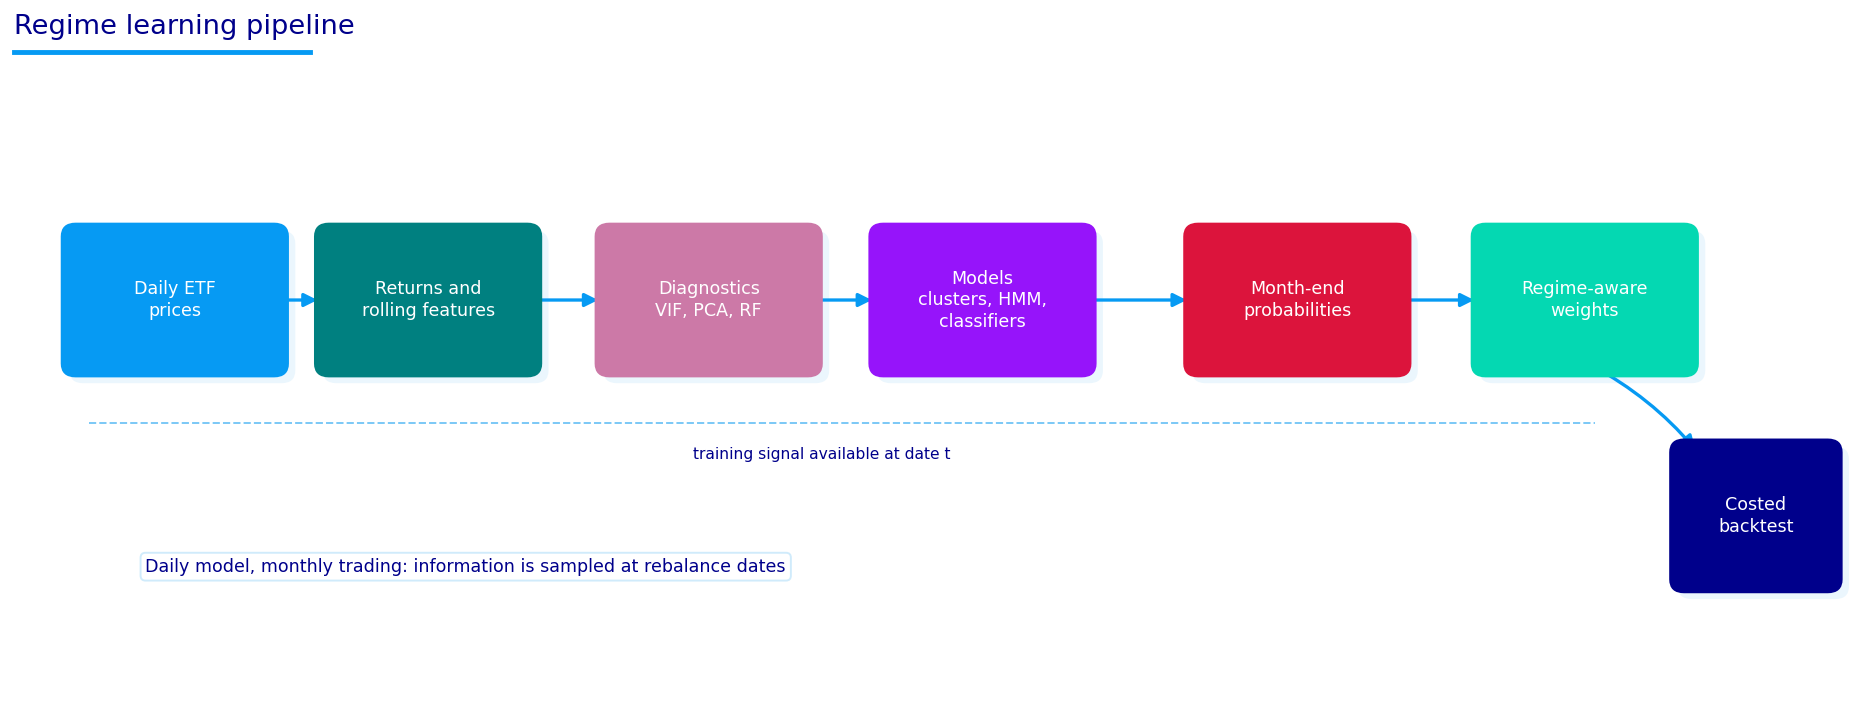

In [2]:
fig, ax = ml_pipeline()
plt.show()

The diagram also separates **learning** from **trading**. A model can learn on daily observations, but the portfolio can still rebalance monthly. This is a good compromise in finance because regimes usually persist longer than one day, while daily noise is high.

For a learner, the useful way to read the rest of the project is:

- **Features** describe today's market.
- **Labels** describe what happened over the next 63 or 126 trading days.
- **Unsupervised models** try to discover regimes from the features without seeing labels.
- **Supervised models** learn a direct mapping from features to realized future regime labels.
- **Markov models** add time dependence, meaning today's state is related to yesterday's state.
- **Portfolio rules** convert probabilities into allocations instead of converting hard labels into all-or-nothing trades.

That last point is important. A regime model rarely knows the state with certainty. The output is usually something like $P(\text{risk-on})=0.60$, $P(\text{neutral})=0.25$, and $P(\text{defensive})=0.15$. That probability vector carries much more information than a single hard label. It lets us build a portfolio that leans risk-on without pretending the defensive risk has disappeared.


The pipeline diagram is also useful because it separates three ideas that often get mixed together:

- **Feature learning**: turning market history into a matrix $X_t$ that describes the current state.
- **Regime inference**: estimating probabilities for states such as risk-on, neutral, or defensive.
- **Portfolio action**: turning those probabilities into weights, costs, and realized performance.

These three layers have different failure modes. A weak feature set can make every model bad. A good feature set can still be handled badly if the model overfits or produces unstable probabilities. A good probability model can still fail if the portfolio mapping is too aggressive, too slow, or too costly.

So the project isn't only about asking which classifier has the highest accuracy. The real workflow is:

$$
\text{Market data} \rightarrow X_t \rightarrow \hat{p}_t(S_t=k) \rightarrow w_t \rightarrow R_{p,t+1}
$$

where $X_t$ is the feature vector observed at time $t$, $\hat{p}_t(S_t=k)$ is the estimated probability of regime $k$, $w_t$ is the portfolio weight vector chosen at the rebalance date, and $R_{p,t+1}$ is the next realized portfolio return.

The important design choice is that we keep the **learning horizon** and **trading horizon** separate. The model can read daily data and learn daily state changes, but the strategy still trades monthly. This avoids the common mistake of building a very active model just because daily predictions are available. In real portfolios, daily switching across ETFs creates cost, slippage, and model noise. Monthly rebalancing forces the regime signal to be economically meaningful enough to survive a practical trading schedule.

A useful way to think about the whole project is this:

> We don't try to predict tomorrow's return directly. We try to estimate the market environment that makes some portfolio sleeves more attractive than others.

That difference matters. Predicting one-day returns is extremely noisy. Predicting whether the market is in a broad risk-on, neutral, or defensive condition over the next few months is still difficult, but it matches how allocators usually think. A portfolio manager doesn't usually say "SPY will return 0.12% tomorrow." They are more likely to say "credit is strong, breadth is healthy, volatility is falling, and duration isn't being rewarded, so the portfolio can carry more risky exposure." This project turns that kind of reasoning into a machine-learning and econometric system.


## 2) Data, Reused Inputs, and Portfolio Baselines

The raw data is mostly reused from earlier projects, so we keep the data explanation focused on how the data is used in this regime-learning setup.

Data reproducibility folders:

- Cross-asset ETFs: [data/core_cross_asset_etfs](https://github.com/ramtin-asadi/Quantitative-Finance-Lab/tree/main/data/core_cross_asset_etfs)
- Sector ETFs: [data/sector_etfs](https://github.com/ramtin-asadi/Quantitative-Finance-Lab/tree/main/data/sector_etfs)
- US macro factors: [data/us_macro_factors](https://github.com/ramtin-asadi/Quantitative-Finance-Lab/tree/main/data/us_macro_factors)
- US Treasury yields: [data/us_treasury_yields](https://github.com/ramtin-asadi/Quantitative-Finance-Lab/tree/main/data/us_treasury_yields)

We use a cross-asset ETF universe for the main regime model:

- **Risk assets**: SPY, QQQ, IWM, EFA, EEM, VNQ, HYG.
- **Real assets and inflation-sensitive assets**: DBC and GLD.
- **Rates and credit assets**: IEF, TLT, LQD, HYG, SHY.
- **Context tickers**: XLE and XLU are included because energy and utilities help identify inflation and defensive rotations.

The cash-like ticker is **SHY**, which behaves as short-duration Treasury exposure. It isn't pure cash, but it gives a conservative low-duration place for the portfolio to move when the regime model becomes defensive.

The baseline portfolios reuse machinery from earlier projects:

- Equal weight and mean-variance logic come from [Project 2](https://ramtin-asadi.github.io/Quantitative-Finance-Lab/notebooks/02_portfolio_optimization_MV_models.html).
- Mean-CVaR and Wasserstein robust optimization come from [Project 10](https://ramtin-asadi.github.io/Quantitative-Finance-Lab/notebooks/10_portfolio_tail_parity_robust.html).
- Financial conditions and macro blocks are based on [Project 12](https://ramtin-asadi.github.io/Quantitative-Finance-Lab/notebooks/12_financial_conditions_index.html).

We don't need to re-explain Ledoit-Wolf, Bayes-Stein, CVaR, or Wasserstein DRO here. The important part is how regime probabilities change the portfolio relative to those baselines.


In [3]:
etf_path = ["../data/core_cross_asset_etfs.csv", "../data/sector_etfs.csv"]
macro_path = "../data/us_macro_factors.csv"
par_yield_path = "../data/us_treasury_yields.csv"

assets = [
    "SPY", "QQQ", "IWM", "EFA", "EEM",
    "VNQ", "DBC", "GLD", "IEF", "TLT",
    "LQD", "HYG",
]
cash_ticker = "SHY"
risk_assets = ["SPY", "QQQ", "IWM", "EFA", "EEM", "VNQ", "HYG"]
defensive_assets = ["IEF", "TLT", "GLD", "SHY"]
outcome_assets = ["SPY", "HYG", "TLT", "DBC", "GLD", "EEM"]
context_tickers = ["XLE", "XLU"]
all_tickers = assets + [cash_ticker] + context_tickers

annualization = 252.0
cost_bps = 10.0
train_days = 1260
horizon = 63
horizon_slow = 126
rf_daily = (1.0 + 0.04) ** (1.0 / annualization) - 1.0
regime_names = ["risk_on", "neutral", "defensive"]


In [4]:
panels = load_yfinance_panel(
    etf_path,
    fields=("close", "volume"),
    tickers=sorted(set(all_tickers + outcome_assets)),
    lowercase=False,
)
close = panels["close"].ffill(limit=3).reindex(columns=sorted(set(all_tickers + outcome_assets)))
volume = panels["volume"].ffill(limit=3).reindex(columns=close.columns)
coverage = pd.DataFrame(
    {
        "first": close.apply(pd.Series.first_valid_index),
        "last": close.apply(pd.Series.last_valid_index),
        "observations": close.notna().sum(),
    }
)
display(coverage.loc[all_tickers])

,first,last,observations
SPY,1999-01-04,2026-06-17,6906
QQQ,1999-03-10,2026-06-17,6861
IWM,2000-05-26,2026-06-17,6553
EFA,2001-08-27,2026-06-17,6238
EEM,2003-04-14,2026-06-17,5832
VNQ,2004-09-29,2026-06-17,5464
DBC,2006-02-06,2026-06-17,5123
GLD,2004-11-18,2026-06-17,5428
IEF,2002-07-30,2026-06-17,6010
TLT,2002-07-30,2026-06-17,6010


In [5]:
returns = prices_to_returns_panel(close, kind="simple").fillna(0.0)
returns = returns.reindex(columns=close.columns).fillna(0.0)
monthly_prices = close.resample("ME").last()
rebalance_dates_all = make_rebalance_dates(returns.index, freq="ME", min_history_days=train_days)
print(close.index.min().date(), "to", close.index.max().date())
print("daily rows:", len(close), "rebalance dates:", len(rebalance_dates_all))

1999-01-04 to 2026-06-17
daily rows: 6906 rebalance dates: 270


In [6]:
rates = load_par_yield_curve(par_yield_path, source="us_treasury").reindex(close.index).ffill()
rates = rates[["3M", "2Y", "10Y"]].dropna(how="all").reindex(close.index).ffill()

x_rates = pd.DataFrame(index=close.index)
x_rates["rate_3m"] = rates["3M"]
x_rates["rate_2y"] = rates["2Y"]
x_rates["rate_10y"] = rates["10Y"]
x_rates["slope_10y_3m"] = rates["10Y"] - rates["3M"]
x_rates["slope_10y_2y"] = rates["10Y"] - rates["2Y"]
x_rates["slope_10y_3m_change_21"] = x_rates["slope_10y_3m"].diff(21)
x_rates["slope_10y_3m_change_63"] = x_rates["slope_10y_3m"].diff(63)
x_rates["slope_10y_3m_change_126"] = x_rates["slope_10y_3m"].diff(126)
x_rates["slope_10y_2y_change_63"] = x_rates["slope_10y_2y"].diff(63)
x_rates["rate_10y_change_63"] = rates["10Y"].diff(63)
x_rates["rate_2y_change_63"] = rates["2Y"].diff(63)
display(x_rates.dropna().tail().round(4))

,rate_3m,rate_2y,rate_10y,slope_10y_3m,slope_10y_2y,slope_10y_3m_change_21,slope_10y_3m_change_63,slope_10y_3m_change_126,slope_10y_2y_change_63,rate_10y_change_63,rate_2y_change_63
date,,,,,,,,,,,
2026-06-11,0.0368,0.0356,0.0426,0.0058,0.007,0.0,0.0,0.0013,0.0,0.0,0.0
2026-06-12,0.0368,0.0356,0.0426,0.0058,0.007,0.0,0.0,0.0014,0.0,0.0,0.0
2026-06-15,0.0368,0.0356,0.0426,0.0058,0.007,0.0,0.0,0.0010,0.0,0.0,0.0
2026-06-16,0.0368,0.0356,0.0426,0.0058,0.007,0.0,0.0,0.0002,0.0,0.0,0.0
2026-06-17,0.0368,0.0356,0.0426,0.0058,0.007,0.0,0.0,0.0005,0.0,0.0,0.0


In [7]:
macro_factors = load_macro_factors(macro_path, start="1990-01-01")
min_macro_history = 60

inflation = pd.concat(
    [
        inflation_level_pressure(macro_factors, min_history=min_macro_history),
        inflation_impulse(macro_factors, min_history=min_macro_history),
        inflation_acceleration(macro_factors, min_history=min_macro_history),
        inflation_diffusion(macro_factors, min_history=min_macro_history),
    ],
    axis=1,
)
policy = pd.concat(
    [
        policy_tightness(macro_factors, min_history=min_macro_history),
        policy_shock(macro_factors, min_history=min_macro_history),
    ],
    axis=1,
)
policy["real_rate_squeeze"] = real_rate_squeeze(policy["policy_tightness"], inflation["inflation_impulse"], min_history=min_macro_history)
policy["policy_catchup_risk"] = policy_catchup_risk(inflation["inflation_level_pressure"], policy["policy_tightness"], min_history=min_macro_history)
growth_macro = pd.concat(
    [
        growth_momentum_stress(macro_factors, min_history=min_macro_history),
        growth_acceleration_stress(macro_factors, min_history=min_macro_history),
        growth_breadth_stress(macro_factors, min_history=min_macro_history),
        survey_warning(macro_factors, min_history=min_macro_history),
    ],
    axis=1,
)
labor = pd.concat(
    [
        labor_cooling(macro_factors, min_history=min_macro_history),
        sahm_pressure(macro_factors, min_history=min_macro_history),
    ],
    axis=1,
)
housing = pd.concat([housing_impulse_stress(macro_factors, min_history=min_macro_history)], axis=1)
housing["housing_rate_squeeze"] = housing_rate_squeeze(housing["housing_impulse_stress"], policy["policy_tightness"])
external = pd.concat(
    [
        external_demand_stress(macro_factors, min_history=min_macro_history),
        external_vulnerability(macro_factors, min_history=min_macro_history),
    ],
    axis=1,
)
macro_signals = pd.concat([inflation, policy, growth_macro, labor, housing, external], axis=1)
macro_breadth = pd.concat(
    [
        stress_breadth(macro_signals, min_history=min_macro_history),
        severe_stress_breadth(macro_signals, min_history=min_macro_history),
        stagflation_pressure(macro_signals),
        goldilocks_support(macro_signals),
    ],
    axis=1,
)
macro_signals = pd.concat([macro_signals, macro_breadth], axis=1)
macro_blocks = condition_blocks(macro_signals)
fci_econ = economic_fci(macro_blocks, min_history=min_macro_history).rename("fci_econ")
fci_pca = pca_fci(macro_blocks, min_history=min_macro_history, min_blocks=5).rename("fci_pca")
fci_blend = expanding_zscore(0.60 * fci_econ + 0.40 * fci_pca, min_history=24).rename("fci_blend")

x_macro_m = pd.concat(
    [
        fci_blend,
        fci_econ,
        fci_pca,
        macro_blocks[[
            "inflation_pressure_block",
            "policy_rate_pressure_block",
            "growth_recession_block",
            "labor_cooling_block",
            "macro_breadth_conflict_block",
        ]],
        macro_breadth[["stress_breadth", "stagflation_pressure", "goldilocks_support"]],
    ],
    axis=1,
)
x_macro_m["fci_change_3m"] = x_macro_m["fci_blend"].diff(3)
x_macro_m["fci_change_6m"] = x_macro_m["fci_blend"].diff(6)
x_macro = x_macro_m.shift(1).reindex(close.index, method="ffill")
display(x_macro_m.dropna(how="all").tail(12).round(3))

,fci_blend,fci_econ,fci_pca,inflation_pressure_block,policy_rate_pressure_block,growth_recession_block,labor_cooling_block,macro_breadth_conflict_block,stress_breadth,stagflation_pressure,goldilocks_support,fci_change_3m,fci_change_6m
date,,,,,,,,,,,,,
2025-02-28,0.380,0.513,-0.050,1.171,-0.353,0.018,-0.579,0.386,0.473,0.348,-0.031,0.574,0.499
2025-03-31,0.316,0.418,-0.058,0.860,-0.271,0.079,-0.588,0.129,0.064,0.319,-0.002,0.507,0.435
2025-04-30,-0.393,-0.386,-0.526,0.221,-0.112,-0.098,-0.553,-0.321,-1.158,0.308,0.005,-0.635,-0.309
2025-05-31,-0.295,-0.319,-0.396,-0.065,0.109,-0.223,-0.578,-0.128,-0.340,0.277,0.019,-0.674,-0.100
2025-06-30,-0.205,-0.121,-0.484,0.639,-0.092,-0.206,-0.610,-0.221,-0.748,0.302,0.007,-0.521,-0.013
2025-07-31,-0.055,0.064,-0.408,0.921,-0.136,-0.296,-0.593,-0.010,0.071,0.314,-0.004,0.338,-0.296
2025-08-31,-0.049,0.028,-0.340,0.822,-0.237,-0.144,-0.563,0.023,-0.339,0.299,0.002,0.246,-0.429
2025-09-30,-0.290,-0.240,-0.503,0.586,-0.246,-0.157,-0.515,-0.230,-0.747,0.275,0.018,-0.084,-0.605
2025-10-31,-0.419,-0.433,-0.517,0.320,-0.249,-0.048,-0.494,-0.331,-1.154,0.276,0.017,-0.364,-0.026


In [8]:
asset_ret = returns[assets]
asset_summary = pd.DataFrame(
    {
        "ann_return": asset_ret.mean() * annualization,
        "ann_vol": asset_ret.std(ddof=1) * np.sqrt(annualization),
        "sharpe": asset_ret.mean() / asset_ret.std(ddof=1) * np.sqrt(annualization),
        "max_drawdown": (close[assets] / close[assets].cummax() - 1.0).min(),
        "first_price": close[assets].apply(pd.Series.first_valid_index),
    }
).sort_values("sharpe", ascending=False)
display(asset_summary.round(4))

,ann_return,ann_vol,sharpe,max_drawdown,first_price
GLD,0.0922,0.1612,0.5722,-0.4556,2004-11-18
LQD,0.0426,0.0779,0.5467,-0.2495,2002-07-30
SPY,0.1015,0.1927,0.5265,-0.5519,1999-01-04
QQQ,0.1389,0.2686,0.5173,-0.8296,1999-03-10
IEF,0.0327,0.0635,0.5150,-0.2392,2002-07-30
IWM,0.1070,0.2329,0.4593,-0.5864,2000-05-26
EEM,0.1132,0.2490,0.4544,-0.6643,2003-04-14
HYG,0.0378,0.0911,0.4149,-0.3425,2007-04-11
EFA,0.0764,0.1978,0.3865,-0.6104,2001-08-27
VNQ,0.0897,0.2527,0.3551,-0.7307,2004-09-29


The coverage table confirms that the ETF panel is long enough to support a regime-learning workflow. SPY starts in 1999, QQQ in 1999, IWM in 2000, EFA in 2001, and the fixed-income ETFs in 2002. Some assets start later: EEM starts in 2003, VNQ in 2004, DBC in 2006, and HYG in 2007. Because HYG and DBC are important for credit and commodity regimes, the effective fully usable cross-asset regime sample naturally starts later than SPY's history.

The daily panel runs from 1999-01-04 to 2026-06-17, with 6906 daily rows and 270 monthly rebalance dates after the training-history requirement. This gives enough observations for daily ML fitting, but the number of monthly backtest decisions is much smaller. That distinction matters. Classification metrics are evaluated on many daily observations, while portfolio performance is evaluated on monthly decisions and daily returns between rebalances.

The asset summary shows a wide range of behavior. GLD has the highest sample Sharpe among the listed assets, followed by LQD, SPY, QQQ, and IEF. QQQ has high annualized return but also very high volatility and a huge historical drawdown. DBC has weak Sharpe and a massive drawdown, which fits its commodity-futures behavior over long samples. TLT has a positive long-run return but large rate-cycle drawdowns, especially after the 2021-2022 rate shock.

This matters for regime learning because the labels shouldn't just identify "stocks up" or "stocks down." They need to distinguish between:

- broad risk-on periods where equities and credit lead,
- neutral periods where defensive assets may still do fine,
- stress periods where defensive assets and gold can dominate risky sleeves,
- inflation-rate stress where bonds don't protect equity drawdowns well.

The model has to learn from cross-asset relationships, not just from one equity index.


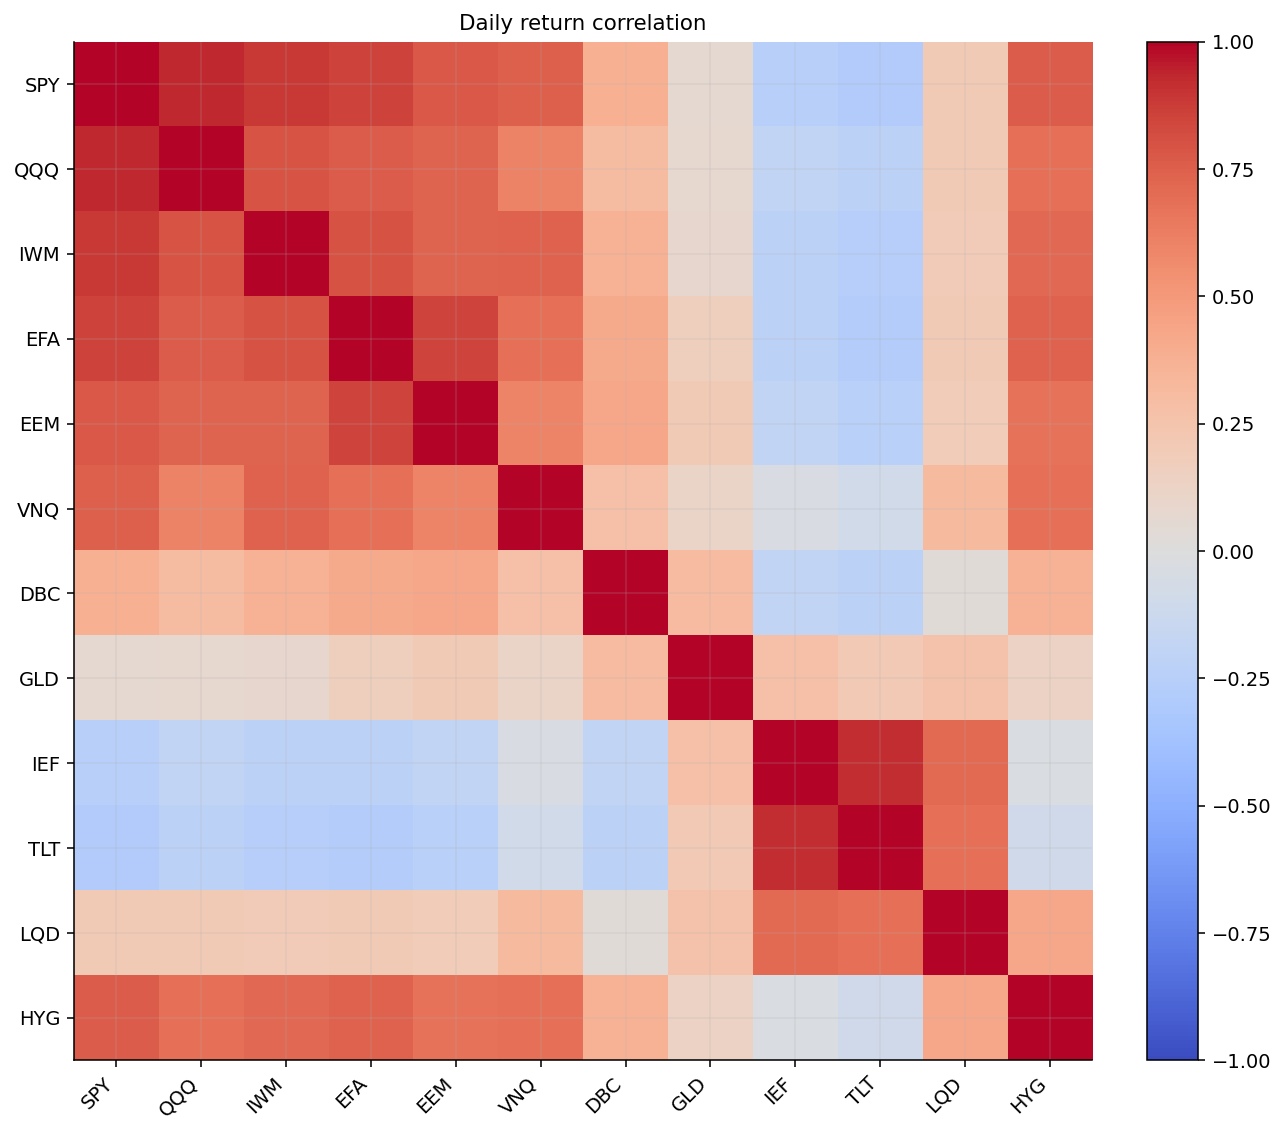

In [12]:
growth = close[assets].dropna(how="all").ffill()
growth = growth.divide(growth.dropna(how="all").iloc[0])
drawdowns = growth / growth.cummax() - 1.0

fig, ax = plt.subplots(figsize=(10.5, 8.2))
plot_corr_heatmap(ax, asset_ret.loc["2010":].corr(), title="Daily return correlation", annotate=False)
plt.tight_layout()
plt.show()

The correlation heatmap after the asset summary shows the expected block structure. Equity ETFs and high-yield credit cluster together. Treasury ETFs cluster together. GLD and DBC are less tightly connected to the equity-credit block, which is exactly why they can help distinguish inflation, risk-off, and diversification regimes.

For regime learning, correlation structure isn't only a diversification object. It also acts as a **state variable**. In calm markets, risky assets may rise together but correlations aren't necessarily extreme. In panic markets, correlations across risky assets often jump because investors sell everything liquid at the same time. In inflation/rate stress, the stock-bond correlation can become less negative or even positive, reducing the protection from long duration.

So when we later build features like average rolling correlation, correlation shocks, and SPY-TLT correlation, we are turning this market structure into predictors. The regime model doesn't only look at returns. It also asks whether the market's internal relationships are behaving like a normal expansion, a defensive rotation, or a correlated stress event.


In [10]:
benchmark_train_end = pd.Timestamp("2018-12-31")
backtest_cols = assets + [cash_ticker]
benchmark_cov_lookback = 756
benchmark_mu_lookback = 252
benchmark_ewma_lambda = 0.97
benchmark_w_min = 0.0
benchmark_w_max = 0.40
benchmark_mv_lambda = 6.0
benchmark_alt_mv_lambda = 3.0
benchmark_dates = make_rebalance_dates(
    returns.index,
    freq="ME",
    min_history_days=max(benchmark_cov_lookback, benchmark_mu_lookback),
)

w_equal_all = pd.DataFrame(0.0, index=benchmark_dates, columns=backtest_cols)
w_equal_all.loc[:, assets] = 1.0 / len(assets)
display(w_equal_all.head().round(4))

,SPY,QQQ,IWM,EFA,EEM,VNQ,DBC,GLD,IEF,TLT,LQD,HYG,SHY
2002-01-31,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0
2002-02-28,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0
2002-03-28,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0
2002-04-30,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0
2002-05-31,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0


In [11]:
fixed_universe_by_date = {
    pd.Timestamp(dt): {"tickers": list(assets), "avg_dollar_volume": pd.Series(1.0, index=assets)}
    for dt in benchmark_dates
}
benchmark_cov_models = {
    "LedoitWolf": covariance.ledoit_wolf_covariance,
    "OAS": covariance.oas_covariance,
    "EWMA": covariance.ewma_covariance,
}
benchmark_mu_models = {
    "Momentum": expected_returns.momentum_mu,
    "BayesStein": expected_returns.bayes_stein_mu,
    "BayesSteinMomentum": expected_returns.bayes_stein_momentum_mu,
}
mv_specs = [
    {"name": f"{optimizer_name} ({cov_name}, {mu_name})", "optimizer": optimizer_name, "cov_model": cov_name, "mu_model": mu_name}
    for optimizer_name in ["MV", "MaxSharpe"]
    for cov_name in benchmark_cov_models
    for mu_name in benchmark_mu_models
]
mv_grid = run_walkforward_grid(
    returns=returns[assets],
    close=close[assets],
    rebalance_dates=benchmark_dates,
    universe_by_date=fixed_universe_by_date,
    cov_models=benchmark_cov_models,
    mu_models=benchmark_mu_models,
    optimizers={"MV": optimizers.mean_variance, "MaxSharpe": optimizers.max_sharpe_slsqp},
    strategy_specs=mv_specs,
    cov_lookback=benchmark_cov_lookback,
    mu_lookback=benchmark_mu_lookback,
    min_cov_observations=benchmark_cov_lookback - 1,
    min_mu_observations=benchmark_mu_lookback - 1,
    max_weight=benchmark_w_max,
    min_weight=benchmark_w_min,
    trading_cost_bps=cost_bps,
    turnover_penalty_bps=cost_bps,
    fallback="equal",
    annualization=annualization,
    rf_daily=rf_daily,
    ewma_lambda=benchmark_ewma_lambda,
    optimizer_params={"MV": {"mv_lambda": benchmark_mv_lambda}},
)

mv_train_rows = []
for name, res in mv_grid.backtests.items():
    r = res.net_returns.loc[:benchmark_train_end]
    v = (1.0 + r).cumprod()
    m = selection.performance_metrics(r, v, rf_daily=rf_daily, annualization=annualization)
    optimizer_name, mu_name, cov_name = selection.parse_strategy_spec(name, res)
    mv_train_rows.append({"strategy": name, "Optimizer": optimizer_name, "Mu model": mu_name, "Covariance model": cov_name, **m})
mv_train_table = pd.DataFrame(mv_train_rows).set_index("strategy").sort_values(["Sharpe", "Max Drawdown"], ascending=[False, False])
mv_choice = str(
    mv_train_table[mv_train_table["Optimizer"].eq("MV")]
    .sort_values(["Sharpe", "Max Drawdown", "CAGR"], ascending=[False, False, False])
    .index[0]
)
maxsharpe_candidates = mv_grid.results.loc[mv_grid.results["Optimizer"].eq("MaxSharpe")].dropna(subset=["Sharpe"])
maxsharpe_source = str(
    maxsharpe_candidates.sort_values(["Sharpe", "Max Drawdown", "Turnover", "CAGR"], ascending=[False, False, True, False]).index[0]
    if not maxsharpe_candidates.empty
    else mv_choice
)
w_mv_all = mv_grid.backtests[mv_choice].weights.reindex(index=benchmark_dates, columns=assets).fillna(0.0)
w_mv_all[cash_ticker] = 0.0
w_mv_all = w_mv_all.reindex(columns=backtest_cols).fillna(0.0)

_, maxsharpe_mu_model, maxsharpe_cov_model = selection.parse_strategy_spec(maxsharpe_source, mv_grid.backtests[maxsharpe_source])

def prepare_benchmark_weights(w):
    out = w.reindex(index=benchmark_dates, columns=assets).ffill()
    out = out.fillna(1.0 / len(assets))
    out[cash_ticker] = 0.0
    return out.reindex(columns=backtest_cols).fillna(0.0)

w_mean_cvar_all = prepare_benchmark_weights(
    mean_cvar_weight_frame(
        cache=mv_grid.cache,
        rebalance_dates=benchmark_dates,
        cov_model=maxsharpe_cov_model,
        mu_model=maxsharpe_mu_model,
        reference="equal",
        alpha=0.95,
        budget_scale=0.90,
        w_min=benchmark_w_min,
        w_max=benchmark_w_max,
    )
)

w_wasserstein_all = prepare_benchmark_weights(
    wasserstein_weight_frame(
        cache=mv_grid.cache,
        rebalance_dates=benchmark_dates,
        cov_model="LedoitWolf",
        mu_model="Momentum",
        radius=1.0,
        mv_lambda=1.5,
        w_min=benchmark_w_min,
        w_max=benchmark_w_max,
    )
)

display(mv_train_table.round(4))
print("MV choice:", mv_choice)
print("MaxSharpe source for Mean-CVaR/Wasserstein:", maxsharpe_source)
display(pd.DataFrame(
    {
        "MV source": [mv_choice],
        "Mean-CVaR source": [maxsharpe_source],
        "Mean-CVaR cov": [maxsharpe_cov_model],
        "Mean-CVaR mu": [maxsharpe_mu_model],
        "Wasserstein source": ["LedoitWolf/Momentum robust prior"],
        "Wasserstein cov": ["LedoitWolf"],
        "Wasserstein mu": ["Momentum"],
        "Wasserstein radius": [1.0],
        "Wasserstein lambda": [1.5],
    }
))

,Optimizer,Mu model,Covariance model,CAGR,Vol,Sharpe,Max Drawdown,Calmar,Sortino
strategy,,,,,,,,,
"MV (EWMA, BayesSteinMomentum)",MV,BayesSteinMomentum,EWMA,0.0641,0.0620,0.4003,-0.0735,0.8717,0.5432
"MaxSharpe (LedoitWolf, BayesSteinMomentum)",MaxSharpe,BayesSteinMomentum,LedoitWolf,0.0773,0.1033,0.3932,-0.0987,0.7839,0.5076
"MaxSharpe (LedoitWolf, Momentum)",MaxSharpe,Momentum,LedoitWolf,0.0771,0.1028,0.3920,-0.1005,0.7670,0.5062
"MaxSharpe (OAS, BayesSteinMomentum)",MaxSharpe,BayesSteinMomentum,OAS,0.0771,0.1032,0.3918,-0.0982,0.7853,0.5057
"MaxSharpe (OAS, Momentum)",MaxSharpe,Momentum,OAS,0.0768,0.1026,0.3908,-0.1005,0.7646,0.5040
"MV (EWMA, Momentum)",MV,Momentum,EWMA,0.0645,0.0656,0.3874,-0.0844,0.7639,0.5235
"MV (EWMA, BayesStein)",MV,BayesStein,EWMA,0.0637,0.0667,0.3718,-0.0855,0.7457,0.4945
"MV (LedoitWolf, BayesStein)",MV,BayesStein,LedoitWolf,0.0598,0.0662,0.3183,-0.0998,0.5995,0.4267
"MV (OAS, BayesStein)",MV,BayesStein,OAS,0.0584,0.0622,0.3123,-0.0910,0.6410,0.4196


MV choice: MV (EWMA, BayesSteinMomentum)
MaxSharpe source for Mean-CVaR/Wasserstein: MaxSharpe (OAS, BayesSteinMomentum)


,MV source,Mean-CVaR source,Mean-CVaR cov,Mean-CVaR mu,Wasserstein source,Wasserstein cov,Wasserstein mu,Wasserstein radius,Wasserstein lambda
0,"MV (EWMA, BayesSteinMomentum)","MaxSharpe (OAS, BayesSteinMomentum)",OAS,BayesSteinMomentum,LedoitWolf/Momentum robust prior,LedoitWolf,Momentum,1.0,1.5


The baseline grid is intentionally short in this project. The mean-variance and MaxSharpe baselines are used to create comparison portfolios and an anchor for the regime allocations. The training-period selection picks **MV (EWMA, BayesSteinMomentum)** as the MV source in the first main backtest, and it uses a MaxSharpe variant as the source for Mean-CVaR and Wasserstein robust portfolios.

The main lesson from this output is that the baselines are already non-trivial. We aren't comparing the regime layer only against a weak equal-weight portfolio. We also compare against:

- a shrinkage-based MV portfolio,
- a Mean-CVaR portfolio that explicitly cares about downside tail risk,
- and a Wasserstein robust portfolio that penalizes fragile optimization under distributional uncertainty.

That makes the final comparison more serious. If regime learning only beats equal weight but loses to robust optimization, the result is still useful, but it tells us the ML layer is more of a risk-shaping overlay than a complete replacement for robust portfolio construction.


The new contribution is what we build on top of these pieces: a regime-learning layer that compares unsupervised clustering, Markov models, hidden Markov models, and supervised classifiers, then asks whether their state probabilities improve allocation decisions after costs.

This also explains why the data has to be broad. A regime model trained only on SPY returns would mostly learn equity trend and volatility. That would miss many important transition signals. Credit can weaken before equities sell off. Treasury duration can stop diversifying when inflation becomes the dominant risk. Gold can behave differently in liquidity crises and inflation shocks. International equities can reveal dollar and global-growth pressure. Macro factors add another lens by measuring inflation, growth, labor, policy, and financial conditions.

So the feature space is deliberately cross-asset and macro-aware. The goal isn't to create a perfect return forecast. The goal is to give the model enough economically meaningful information to distinguish different market environments.


## 3) Feature Engineering for Financial Regimes

A regime model is only as good as its feature space. The feature vector at date $t$ is:

$$
X_t = \begin{bmatrix} x_{t,1} & x_{t,2} & \cdots & x_{t,p} \end{bmatrix}^\top
$$

where each feature is a market condition that would've been observable at time $t$. The model later learns either:

$$
\hat{S}_t = f(X_t)
$$

for unsupervised/discovery models, or:

$$
P(Y_t = k \mid X_t)
$$

for supervised classifiers, where $Y_t$ is a realized future regime label.

The feature set is designed around economic blocks, not random technical indicators. The blocks are:

1. **Equity trend and leadership**, such as SPY momentum, QQQ vs SPY, small-cap vs large-cap, international vs US, and EM vs developed ex-US.
2. **Credit health**, such as HYG vs LQD, high-yield drawdown, high-yield downside volatility, and HYG vs SHY.
3. **Duration and rates**, such as TLT vs SHY, IEF vs SHY, Treasury yields, and curve-slope changes.
4. **Real assets and inflation**, such as DBC, GLD, DBC vs IEF, GLD vs SPY, and energy vs utilities.
5. **Cross-asset pressure**, such as risk-on assets versus defensive assets, credit-equity divergence, inflation-duration spread, and duration-equity divergence.
6. **Market internals**, such as breadth, dispersion, volatility shock, drawdown level, drawdown speed, average correlation, and equity-bond correlation.
7. **Macro/FCI blocks**, reused from Project 12: inflation pressure, policy pressure, growth recession pressure, labor cooling, housing stress, external vulnerability, FCI blend, stagflation pressure, and goldilocks support.

The reason we use blocks is that regimes aren't one-dimensional. A high SPY return can happen in several different environments. It can be a broad growth rally, a narrow mega-cap rally, a relief rally after a crash, or an inflationary nominal rally. The regime label becomes more meaningful when the model sees equity, credit, rates, real assets, correlation, and macro conditions together.


### 3.1 Equity Leadership Features

The first feature block measures equity momentum and leadership.

A basic total return feature over a window $L$ is:

$$
R_{t}^{(L)}(i) = \frac{P_{t,i}}{P_{t-L,i}} - 1
$$

where $P_{t,i}$ is the adjusted price of asset $i$ at date $t$. This says how much the asset has gained or lost over the last $L$ trading days.

For momentum with a skip window, we use:

$$
R_{t}^{(L,\text{skip})}(i) = \frac{P_{t-\text{skip},i}}{P_{t-L,i}} - 1
$$

The skip avoids letting very recent reversal noise dominate the signal. For SPY, the feature `spy_252_21` measures roughly 12-month momentum excluding the latest month.

Relative return features take the difference between two total returns:

$$
\text{RelRet}_{t}^{(L)}(i,j) = R_{t}^{(L)}(i) - R_{t}^{(L)}(j)
$$

These are more regime-informative than standalone returns. For example:

- `qqq_spy_126` measures growth/mega-cap tech leadership relative to the broad market.
- `iwm_spy_126` measures small-cap cyclicality relative to large-cap quality.
- `efa_spy_126` measures developed international equity relative to US equity.
- `eem_efa_126` measures emerging markets relative to developed international.


In [13]:
def total_ret(ticker, window):
    return close[ticker].astype(float) / close[ticker].astype(float).shift(int(window)) - 1.0

def rel_ret(left, right, window):
    return total_ret(left, window) - total_ret(right, window)

def skip_ret(ticker, lookback=252, skip=21):
    return close[ticker].shift(int(skip)) / close[ticker].shift(int(lookback)) - 1.0

In [14]:
x_eq = pd.DataFrame(index=close.index)
x_eq["spy_252_21"] = skip_ret("SPY", 252, 21)
x_eq["spy_126"] = total_ret("SPY", 126)
x_eq["qqq_spy_126"] = rel_ret("QQQ", "SPY", 126)
x_eq["iwm_spy_126"] = rel_ret("IWM", "SPY", 126)
x_eq["efa_spy_126"] = rel_ret("EFA", "SPY", 126)
x_eq["eem_efa_126"] = rel_ret("EEM", "EFA", 126)
display(x_eq.tail().round(4))

,spy_252_21,spy_126,qqq_spy_126,iwm_spy_126,efa_spy_126,eem_efa_126
date,,,,,,
2026-06-11,0.2380,0.0863,0.0640,0.0749,0.0317,0.1376
2026-06-12,0.2485,0.0849,0.0673,0.0706,0.0238,0.1400
2026-06-15,0.2534,0.1015,0.0908,0.0500,0.0081,0.1862
2026-06-16,0.2523,0.1068,0.0856,0.0524,0.0111,0.1723
2026-06-17,0.2397,0.0947,0.0917,0.0646,0.0108,0.1871


From the latest table, EEM vs EFA is strongly positive near the end of the sample, while QQQ vs SPY and IWM vs SPY are also positive. This tells us the latest equity leadership isn't purely defensive. It has signs of EM strength, growth strength, and some small-cap participation. That doesn't automatically mean the portfolio should be fully risk-on, but it gives the supervised and unsupervised models positive evidence on the risky side.


### 3.2 Credit, Duration, and Real-Asset Features

Credit features are central because credit often turns before equity. HYG is high-yield corporate credit, and LQD is investment-grade corporate credit. The spread-like relative return:

$$
\text{CreditRisk}_{t}^{(L)} = R_{t}^{(L)}(\text{HYG}) - R_{t}^{(L)}(\text{LQD})
$$

acts like a price-based credit sentiment indicator. When HYG outperforms LQD, credit investors are accepting default risk and liquidity risk. When HYG underperforms, the market is usually moving toward quality and safety.

We also use high-yield drawdown and downside semi-volatility. If $r_t$ is the daily return, downside semi-volatility keeps only the negative return side:

$$
\sigma^{-}_{t,L} = \sqrt{252}\cdot \operatorname{Std}\left(\min(r_s,0) : s=t-L+1,\dots,t\right)
$$

This is useful because credit pain is asymmetric. A few bad credit days can carry much more information than a smooth low-volatility carry period.

Duration features compare long and intermediate Treasuries against short duration:

$$
\text{Duration}_{t}^{(L)} = R_{t}^{(L)}(\text{TLT}) - R_{t}^{(L)}(\text{SHY})
$$

When this is positive, long-duration bonds are beating short bills, usually because yields are falling or investors are paying for duration protection. When it is negative, duration is under pressure, usually because rates are rising or inflation risk is high.

Real-asset features use commodities, gold, and energy:

$$
\text{InflationDuration}_{t}^{(L)} = \frac{1}{2}\left(R_{t}^{(L)}(\text{DBC}) + R_{t}^{(L)}(\text{GLD})\right) - \frac{1}{2}\left(R_{t}^{(L)}(\text{IEF}) + R_{t}^{(L)}(\text{TLT})\right)
$$

This feature is powerful in environments like 2022, where real assets and energy can hold up while duration bonds fall. In a normal equity crash with falling yields, this feature may behave very differently because Treasuries can rally. That difference helps the model separate classic risk-off from inflation/rate stress.


In [15]:
x_credit = pd.DataFrame(index=close.index)
x_credit["hyg_lqd_126"] = rel_ret("HYG", "LQD", 126)
x_credit["hyg_lqd_63"] = rel_ret("HYG", "LQD", 63)
x_credit["hyg_lqd_change_21"] = x_credit["hyg_lqd_126"] - x_credit["hyg_lqd_126"].shift(21)
x_credit["hyg_lqd_change_63"] = x_credit["hyg_lqd_126"] - x_credit["hyg_lqd_126"].shift(63)
x_credit["hyg_63"] = total_ret("HYG", 63)
x_credit["hyg_dd_252"] = close["HYG"] / close["HYG"].rolling(252, min_periods=63).max() - 1.0
x_credit["hyg_dd_speed_21"] = x_credit["hyg_dd_252"] - x_credit["hyg_dd_252"].shift(21)
x_credit["hyg_vol_63"] = returns["HYG"].rolling(63).std(ddof=1) * np.sqrt(annualization)
x_credit["hyg_downside_semivar_63"] = returns["HYG"].clip(upper=0.0).rolling(63).std(ddof=1) * np.sqrt(annualization)
x_credit["hyg_shy_126"] = rel_ret("HYG", "SHY", 126)
x_credit["lqd_shy_126"] = rel_ret("LQD", "SHY", 126)
x_credit["lqd_ief_126"] = rel_ret("LQD", "IEF", 126)

x_duration = pd.DataFrame(index=close.index)
x_duration["tlt_shy_126"] = rel_ret("TLT", "SHY", 126)
x_duration["ief_shy_126"] = rel_ret("IEF", "SHY", 126)
x_duration["tlt_ief_126"] = rel_ret("TLT", "IEF", 126)

x_real = pd.DataFrame(index=close.index)
x_real["dbc_126"] = total_ret("DBC", 126)
x_real["gld_126"] = total_ret("GLD", 126)
x_real["dbc_ief_126"] = rel_ret("DBC", "IEF", 126)
x_real["gld_spy_126"] = rel_ret("GLD", "SPY", 126)
x_real["xle_spy_126"] = rel_ret("XLE", "SPY", 126)
x_real["xle_xlu_126"] = rel_ret("XLE", "XLU", 126)
display(pd.concat([x_credit, x_duration, x_real], axis=1).tail().round(4))

,hyg_lqd_126,hyg_lqd_63,hyg_lqd_change_21,hyg_lqd_change_63,hyg_63,hyg_dd_252,hyg_dd_speed_21,hyg_vol_63,hyg_downside_semivar_63,hyg_shy_126,lqd_shy_126,lqd_ief_126,tlt_shy_126,ief_shy_126,tlt_ief_126,dbc_126,gld_126,dbc_ief_126,gld_spy_126,xle_spy_126,xle_xlu_126
date,,,,,,,,,,,,,,,,,,,,,
2026-06-11,0.0134,0.0062,-0.0072,-0.0033,0.0228,0.0000,0.0045,0.0540,0.0304,0.0133,-0.0001,0.0095,-0.0105,-0.0096,-0.0008,0.2971,-0.0028,0.2966,-0.0891,0.1825,0.2234
2026-06-12,0.0153,0.0050,-0.0024,-0.0053,0.0248,0.0000,0.0040,0.0538,0.0304,0.0118,-0.0035,0.0091,-0.0148,-0.0126,-0.0022,0.2759,-0.0065,0.2802,-0.0914,0.1801,0.2078
2026-06-15,0.0154,0.0082,-0.0050,-0.0028,0.0228,0.0000,0.0047,0.0535,0.0304,0.0129,-0.0026,0.0094,-0.0144,-0.0120,-0.0024,0.2622,0.0084,0.2656,-0.0931,0.1254,0.1723
2026-06-16,0.0099,0.0079,-0.0129,-0.0076,0.0181,-0.0001,0.0095,0.0529,0.0304,0.0145,0.0046,0.0115,0.0007,-0.0069,0.0076,0.2582,0.0055,0.2564,-0.1013,0.1280,0.1675
2026-06-17,0.0100,0.0071,-0.0149,-0.0075,0.0195,-0.0039,0.0047,0.0524,0.0298,0.0138,0.0039,0.0132,0.0053,-0.0094,0.0146,0.2557,-0.0182,0.2600,-0.1129,0.1334,0.1844


The latest credit and duration table shows high-yield credit still positive over the recent 63-day window, with HYG drawdown near zero and high-yield volatility low. That supports a calmer credit environment. At the same time, several duration-relative features can be weak when long bonds lag short duration. This combination gives the model a more nuanced state: risk appetite isn't collapsing, but duration isn't necessarily attractive.

This is exactly why regime learning can be useful. A simple stock-only rule might say "risk-on." A cross-asset model can say "risky assets are strong, credit isn't breaking, but the rate environment still makes long duration risky." Later, the portfolio weights reflect that nuance by holding risky assets and gold/IEF together rather than simply going all in on equities.


### 3.3 Market Pressure and Internal Structure

The pressure features combine sleeves. We compare average risky performance against defensive performance:

$$
\text{RiskOn}_{t}^{(L)} = \frac{1}{|A_R|}\sum_{i\in A_R} R_{t}^{(L)}(i) - \frac{1}{|A_D|}\sum_{j\in A_D} R_{t}^{(L)}(j)
$$

where $A_R$ is the risk asset set and $A_D$ is the defensive set. This gives one broad "risk appetite" measure.

Breadth measures the fraction of assets with positive returns:

$$
\text{Breadth}_{t}^{(L)} = \frac{1}{N}\sum_{i=1}^{N} \mathbf{1}\left(R_{t}^{(L)}(i)>0\right)
$$

A market where SPY is up but breadth is weak is more fragile than a market where most risky assets are rising together. The model also uses dispersion:

$$
\text{Dispersion}_{t}^{(L)} = \operatorname{Std}\left(R_{t}^{(L)}(1),\dots,R_{t}^{(L)}(N)\right)
$$

High dispersion means assets are separating strongly. That can occur during sector rotation, inflation shocks, growth leadership, or stress.

Volatility shock compares short-run realized volatility to medium-run realized volatility:

$$
\text{VolShock}_t = \frac{\sigma_{t,21}(\text{SPY})}{\sigma_{t,126}(\text{SPY})}
$$

If this ratio jumps above 1, short-term volatility is rising faster than the slower volatility baseline. Drawdown level and drawdown speed measure whether SPY is already below its rolling high and whether the drawdown is worsening.

Correlation features use rolling correlations across assets:

$$
\bar{\rho}_{t,L} = \frac{2}{N(N-1)}\sum_{i<j}\rho_{ij,t}^{(L)}
$$

In stress periods, $\bar{\rho}_{t,L}$ often rises because diversification inside risky assets disappears. We also track correlation shocks, which compare short-window correlation to long-window correlation. This makes the model sensitive to sudden changes in market structure, not only levels.


In [16]:
def avg_total_return(tickers, window):
    return pd.concat([total_ret(t, window) for t in tickers], axis=1).mean(axis=1)

x_pressure = pd.DataFrame(index=close.index)
x_pressure["risk_on_63"] = avg_total_return(risk_assets, 63) - avg_total_return(defensive_assets, 63)
x_pressure["risk_on_126"] = avg_total_return(risk_assets, 126) - avg_total_return(defensive_assets, 126)
x_pressure["growth_duration_126"] = rel_ret("QQQ", "TLT", 126)
x_pressure["credit_equity_63"] = rel_ret("HYG", "SPY", 63)
x_pressure["credit_equity_divergence_63"] = rel_ret("HYG", "LQD", 63) - rel_ret("SPY", "IEF", 63)
x_pressure["credit_momentum_minus_equity_126"] = total_ret("HYG", 126) - total_ret("SPY", 126)
x_pressure["hyg_spy_divergence_63"] = total_ret("HYG", 63) - total_ret("SPY", 63)
x_pressure["inflation_duration_126"] = avg_total_return(["DBC", "GLD"], 126) - avg_total_return(["IEF", "TLT"], 126)
x_pressure["inflation_equity_126"] = avg_total_return(["DBC", "GLD", "XLE"], 126) - total_ret("SPY", 126)
x_pressure["duration_stress_63"] = rel_ret("TLT", "SPY", 63)
x_pressure["duration_equity_divergence_126"] = rel_ret("TLT", "IEF", 126) - total_ret("SPY", 126)
display(x_pressure.tail().round(4))

,risk_on_63,risk_on_126,growth_duration_126,credit_equity_63,credit_equity_divergence_63,credit_momentum_minus_equity_126,hyg_spy_divergence_63,inflation_duration_126,inflation_equity_126,duration_stress_63,duration_equity_divergence_126
date,,,,,,,,,,,
2026-06-11,0.1637,0.1288,0.1505,-0.0878,-0.1087,-0.0628,-0.0878,0.1470,0.1014,-0.1105,-0.0871
2026-06-12,0.1716,0.1304,0.1588,-0.0983,-0.1229,-0.0649,-0.0983,0.1402,0.0932,-0.1204,-0.0871
2026-06-15,0.1699,0.1389,0.1981,-0.1085,-0.1314,-0.0800,-0.1085,0.1399,0.0643,-0.1369,-0.1039
2026-06-16,0.1549,0.1376,0.1831,-0.1035,-0.1213,-0.0836,-0.1035,0.1263,0.0594,-0.1245,-0.0993
2026-06-17,0.1577,0.1366,0.1761,-0.1038,-0.1244,-0.0758,-0.1038,0.1157,0.0605,-0.1190,-0.0800


In [17]:
def breadth(tickers, window):
    data = pd.concat([total_ret(t, window) for t in tickers], axis=1)
    return data.gt(0.0).mean(axis=1)

def dispersion(tickers, window):
    data = pd.concat([total_ret(t, window) for t in tickers], axis=1)
    return data.std(axis=1, ddof=1)

def realized_vol(ticker, window):
    return returns[ticker].rolling(int(window)).std(ddof=1) * np.sqrt(annualization)

def drawdown_level(ticker, window):
    return close[ticker] / close[ticker].rolling(int(window), min_periods=max(63, int(window) // 4)).max() - 1.0

def rolling_avg_corr(tickers, window):
    data = returns[tickers].astype(float)
    pairs = []
    for i, left in enumerate(tickers):
        for right in tickers[i + 1:]:
            pairs.append(data[left].rolling(int(window)).corr(data[right]))
    return pd.concat(pairs, axis=1).mean(axis=1)

In [18]:
x_internal = pd.DataFrame(index=close.index)
x_internal["breadth_63"] = breadth(risk_assets, 63)
x_internal["breadth_126"] = breadth(risk_assets, 126)
x_internal["dispersion_21"] = dispersion(risk_assets, 21)
x_internal["dispersion_63"] = dispersion(risk_assets, 63)
x_internal["vol_shock"] = realized_vol("SPY", 21) / realized_vol("SPY", 126)
x_internal["vol_level"] = realized_vol("SPY", 63)
x_internal["vol_change_21"] = x_internal["vol_level"] - x_internal["vol_level"].shift(21)
x_internal["vol_change_63"] = x_internal["vol_level"] - x_internal["vol_level"].shift(63)
x_internal["dd_level"] = drawdown_level("SPY", 252)
x_internal["dd_speed"] = x_internal["dd_level"] - x_internal["dd_level"].shift(21)
x_internal["corr_level"] = rolling_avg_corr(all_tickers, 252)
x_internal["corr_shock"] = rolling_avg_corr(all_tickers, 63) - rolling_avg_corr(all_tickers, 252)
x_internal["corr_change_21"] = x_internal["corr_level"] - x_internal["corr_level"].shift(21)
x_internal["corr_change_63"] = x_internal["corr_level"] - x_internal["corr_level"].shift(63)
x_internal["eq_bond_corr"] = returns["SPY"].rolling(252).corr(returns["TLT"])
x_internal["breadth_speed_21"] = x_internal["breadth_63"] - x_internal["breadth_63"].shift(21)
x_internal["breadth_speed_63"] = x_internal["breadth_126"] - x_internal["breadth_126"].shift(63)
display(x_internal.tail().round(4))

,breadth_63,breadth_126,dispersion_21,dispersion_63,vol_shock,vol_level,vol_change_21,vol_change_63,dd_level,dd_speed,corr_level,corr_shock,corr_change_21,corr_change_63,eq_bond_corr,breadth_speed_21,breadth_speed_63
date,,,,,,,,,,,,,,,,,
2026-06-11,1.0,1.0,0.0102,0.0683,1.1036,0.1522,0.0057,0.0363,-0.0287,-0.0272,0.3001,0.0768,0.0144,-0.0429,0.1880,0.1429,0.0
2026-06-12,1.0,1.0,0.0130,0.0712,1.1038,0.1516,0.0049,0.0362,-0.0235,-0.0235,0.3001,0.0774,0.0088,-0.0431,0.1879,0.1429,0.0
2026-06-15,1.0,1.0,0.0133,0.0809,1.1593,0.1540,0.0107,0.0367,-0.0062,-0.0062,0.2980,0.0735,0.0065,-0.0474,0.1836,0.1429,0.0
2026-06-16,1.0,1.0,0.0186,0.0701,1.1306,0.1548,0.0089,0.0393,-0.0122,-0.0001,0.2973,0.0700,0.0012,-0.0489,0.1716,0.2857,0.0
2026-06-17,1.0,1.0,0.0231,0.0758,1.1684,0.1542,0.0083,0.0355,-0.0245,-0.0118,0.3017,0.0648,0.0071,-0.0468,0.1779,0.2857,0.0


The internal market-state table near the end of the sample shows full breadth across risky assets, relatively moderate SPY volatility, and drawdown levels close to zero. That leans risk-on. But the average correlation level and correlation changes also matter because high correlation can turn a seemingly diversified risky sleeve into one large equity-credit bet.

The important point for the model is that features are allowed to disagree. We don't force every signal to say the same thing. A regime classifier can learn that strong breadth with rising volatility means something different from strong breadth with falling volatility. It can learn that gold strength with credit stress means something different from gold strength during a broad commodity rally. The feature set is intentionally redundant at first because the next steps, VIF, PCA, and RandomForest importance, help us diagnose and reduce that redundancy.


A feature matrix for regime learning is different from a feature matrix for a normal cross-sectional prediction problem. In a normal stock-selection problem, each row might be a stock and each column might be a characteristic. Here each row is a **date**, and each column is a market-state measurement observed on that date.

We can write the full feature vector as:

$$
X_t = \begin{bmatrix} X_t^{\text{equity}} & X_t^{\text{credit}} & X_t^{\text{duration}} & X_t^{\text{real}} & X_t^{\text{internal}} & X_t^{\text{macro}} \end{bmatrix}
$$

Each block answers a different economic question:

| Block | Economic question | Typical signal |
|---|---|---|
| Equity leadership | Is risk appetite broad or concentrated? | SPY, QQQ, IWM, EFA, EEM relative trends |
| Credit | Are risky borrowers being rewarded or punished? | HYG vs LQD, HYG drawdown, credit volatility |
| Duration | Are long bonds working as diversifiers? | TLT/IEF/SHY relative returns, stock-bond correlation |
| Real assets | Is inflation or commodity strength visible? | DBC, GLD, XLE vs XLU |
| Internal structure | Is market breadth healthy or fragile? | breadth, dispersion, volatility shock, correlations |
| Macro/FCI | Are financial conditions tightening? | FCI, policy, inflation, labor, recession blocks |

The important point is that a regime is usually not visible in one variable. A market can have positive equity momentum but deteriorating credit. It can have strong breadth but rising inflation pressure. It can have high Treasury returns because growth is weakening, or because policy rates are falling in a calm disinflationary environment. The same raw asset return can mean different things depending on the rest of the state vector.

A simple relative-return feature has the form:

$$
x_t^{A/B,L} = \left(\frac{P_{t,A}}{P_{t-L,A}} - 1\right) - \left(\frac{P_{t,B}}{P_{t-L,B}} - 1\right)
$$

where $A$ and $B$ are two assets and $L$ is the lookback window. If $A=\text{HYG}$ and $B=\text{LQD}$, this feature asks whether high-yield credit is outperforming investment-grade credit. If it is positive, credit markets are usually accepting more default risk. If it is negative, investors are usually moving toward safer credit quality.

A drawdown feature has a different meaning:

$$
DD_{t}^{(L)} = \frac{P_t}{\max(P_{t-L},\dots,P_t)} - 1
$$

This is always less than or equal to zero. A value near zero means the asset is near its local high. A value like $-0.20$ means the asset is down 20% from its recent peak. In regime learning, drawdown is useful because it measures accumulated damage, not just recent volatility. A market can be volatile but still near highs; it can also be in a slow grind-down with moderate daily volatility but deep drawdown.

Volatility-shock features measure whether volatility itself is changing:

$$
\Delta \sigma_t^{(L)} = \sigma_t^{(L)} - \sigma_{t-m}^{(L)}
$$

where $\sigma_t^{(L)}$ is a rolling volatility estimate and $m$ is a change window such as 21 or 63 trading days. Rising volatility often marks a transition from calm risk-on to unstable neutral or defensive states. Falling volatility after a selloff can mark recovery.

Correlation features are especially important in this project. A cross-asset portfolio usually depends on diversification. If equities, credit, commodities, and bonds start moving together, the portfolio's true risk can rise even if individual asset volatilities don't explode. A rolling average correlation can be written as:

$$
\bar{\rho}_t = \frac{2}{N(N-1)}\sum_{i<j}\rho_{ij,t}^{(L)}
$$

where $\rho_{ij,t}^{(L)}$ is the rolling correlation between assets $i$ and $j$ over window $L$. High $\bar{\rho}_t$ means diversification is weaker. A correlation shock can turn many separate trades into one large macro trade.

This is why the feature set starts broad. We aren't assuming one variable defines the state. We first collect many economically meaningful measurements, then use diagnostics and selection to decide which ones are usable for the models.


Feature scaling matters more here than it might seem at first. Many models in this project are geometry-based. KMeans, GMM, SVM, and KNN all depend on distances, margins, or Gaussian densities in feature space. If one feature is measured in percentage points and another is measured in basis points, the larger-scale feature can dominate the model even if it isn't economically more important.

So we standardize features before fitting most models:

$$
z_{t,j} = \frac{x_{t,j} - \mu_j}{s_j}
$$

where $x_{t,j}$ is feature $j$ at date $t$, $\mu_j$ is the training-window mean, and $s_j$ is the training-window standard deviation. After this transformation, each feature is measured in "number of standard deviations from its normal level."

In financial language, this makes features comparable as stress signals. A $+2$ value for `vol_change_63` means volatility has risen strongly relative to its own history. A $+2$ value for `fci_blend` means financial conditions are meaningfully tight relative to their own history. The units are different, but the z-score puts them on a comparable abnormality scale.

There is also a subtle leakage point here. Scaling parameters must be estimated only from the training window in a walk-forward setting. If we standardize the whole sample using future means and standard deviations, the model learns from the future indirectly. For example, the volatility distribution after 2020 isn't the same as before 2020. Using full-sample scaling tells the pre-2020 model how extreme future crisis volatility will be, which isn't available in real time.

The clean walk-forward transformation is:

$$
z_{t,j}^{\text{train}} = \frac{x_{t,j} - \mu_{j,\text{train}}}{s_{j,\text{train}}}
$$

and for a new observation:

$$
z_{\tau,j}^{\text{test}} = \frac{x_{\tau,j} - \mu_{j,\text{train}}}{s_{j,\text{train}}}
$$

The same training mean and training standard deviation are used for the test observation. This is exactly the same logic as fitting a scaler in a normal ML pipeline, but in finance the chronological order is more important because market distributions change through time.

> The feature matrix isn't only a numerical input. It is the economic vocabulary that all later models are allowed to speak.


A good regime model should have features that are interpretable after the fact. This matters because portfolio decisions need explanation. If the model reduces risk, we want to know whether it is because credit weakened, volatility rose, breadth broke, macro pressure tightened, or duration stopped diversifying.

The selected feature list gives us a compact economic dashboard:

**FCI and macro blocks** describe the macro backdrop. Tight financial conditions usually pressure risky assets because discount rates rise, credit becomes less available, and liquidity becomes less supportive. A high `fci_blend` can therefore push the model toward defensive or neutral states even before equities fully sell off.

**Volatility and drawdown features** describe market damage. `vol_change_63` captures acceleration in uncertainty. `dd_level` captures realized drawdown pressure. These features often separate normal pullbacks from real regime shifts.

**Credit features** describe balance-sheet risk. HYG downside semivariance and HYG volatility show whether lower-quality credit is becoming unstable. Credit weakness is especially important because equity markets can remain calm for a while even when credit risk starts repricing.

**Duration features** describe the rate side. Features such as `ief_shy_126`, `tlt_shy_126`, and `tlt_ief_126` tell us whether duration is being rewarded or punished. This is crucial after the 2022 experience, where long bonds weren't always defensive.

**International leadership features** describe global risk appetite. EFA vs SPY, EEM vs EFA, and IWM vs SPY help identify whether leadership is broad or narrow. EM strength can indicate global liquidity and dollar conditions are supportive. Small-cap strength can indicate domestic cyclicality and credit appetite.

**Correlation and breadth features** describe internal market structure. Strong breadth means many risky assets are participating. High correlation means diversification is weaker. A market with strong breadth and low correlation is healthier than a market with high correlation and falling breadth.

This feature interpretation is one of the reasons Project 16 can work as a learning source. The model isn't a black box sitting on random numbers. Each variable is tied to a market mechanism, and the diagnostics show which mechanisms ended up mattering most.


In [19]:
x_all = pd.concat([x_eq, x_credit, x_duration, x_real, x_pressure, x_rates, x_macro, x_internal], axis=1)
x_all = x_all.replace([np.inf, -np.inf], np.nan).dropna()
feature_summary = x_all.describe(percentiles=[0.05, 0.50, 0.95]).T
feature_summary = feature_summary[["mean", "std", "min", "5%", "50%", "95%", "max"]]
display(feature_summary.round(4))
print("candidate features:", x_all.shape)

,mean,std,min,5%,50%,95%,max
spy_252_21,0.1098,0.1600,-0.4927,-0.1959,0.1372,0.3323,0.7580
spy_126,0.0595,0.1148,-0.4545,-0.1280,0.0744,0.2164,0.5177
qqq_spy_126,0.0260,0.0561,-0.1268,-0.0583,0.0243,0.1359,0.2450
iwm_spy_126,-0.0073,0.0731,-0.1908,-0.1123,-0.0118,0.1040,0.3861
efa_spy_126,-0.0282,0.0631,-0.1735,-0.1183,-0.0351,0.0985,0.1993
...,...,...,...,...,...,...,...
corr_change_21,0.0005,0.0193,-0.0838,-0.0240,-0.0005,0.0296,0.1490
corr_change_63,0.0014,0.0373,-0.1011,-0.0566,-0.0020,0.0736,0.1380
eq_bond_corr,-0.2961,0.2572,-0.7660,-0.6849,-0.3610,0.1478,0.3163
breadth_speed_21,0.0026,0.3126,-1.0000,-0.5714,0.0000,0.5714,1.0000


candidate features: (4639, 79)


## 4) Feature Quality Control and Selection

Before we fit regime models, we inspect the feature matrix. Financial features are usually correlated because they are constructed from overlapping prices and overlapping horizons. For example, `tlt_shy_126`, `tlt_ief_126`, and `ief_shy_126` are mathematically connected. If TLT beats IEF and IEF beats SHY, then TLT should also beat SHY. That creates multicollinearity.

The **variance inflation factor** for feature $j$ is:

$$
\text{VIF}_j = \frac{1}{1 - R_j^2}
$$

where $R_j^2$ comes from regressing feature $x_j$ on all the other features. If $R_j^2$ is close to 1, the feature is almost explained by the others, and $\text{VIF}_j$ explodes. A high VIF doesn't mean the feature is useless. It means linear models may have unstable coefficients because the model can't uniquely assign credit to one correlated feature.

PCA gives another view. If $X$ is the standardized feature matrix, PCA decomposes it into orthogonal directions:

$$
X = UDV^\top
$$

The columns of $V$ are loading vectors, and each principal component is:

$$
PC_{t,k} = X_t v_k
$$

The explained variance ratio for component $k$ is:

$$
\text{EVR}_k = \frac{\lambda_k}{\sum_{j=1}^{p}\lambda_j}
$$

where $\lambda_k$ is the variance explained by component $k$. If the first few PCs explain a large share of the variance, the feature space has strong common structure. If the variance is spread across many PCs, the features contain more independent dimensions.

RandomForest permutation importance answers a more predictive question. After training a model, we shuffle one feature and see how much the score falls:

$$
I_j = \text{Score}(M, X, y) - \text{Score}(M, X_{\pi(j)}, y)
$$

where $X_{\pi(j)}$ is the feature matrix with column $j$ permuted. If shuffling feature $j$ hurts balanced accuracy, that feature carries useful predictive information.


In [20]:
def feature_vif_local(x):
    z0 = x.replace([np.inf, -np.inf], np.nan).dropna().astype(float)
    rows = []
    for col in z0.columns:
        other = [c for c in z0.columns if c != col]
        if not other:
            rows.append({"feature": col, "r2": np.nan, "vif": np.nan})
            continue
        y0 = z0[col].to_numpy(dtype=float)
        X0 = z0[other].to_numpy(dtype=float)
        r2 = LinearRegression().fit(X0, y0).score(X0, y0)
        vif = np.inf if r2 >= 1.0 - 1e-12 else 1.0 / (1.0 - r2)
        rows.append({"feature": col, "r2": r2, "vif": vif})
    return pd.DataFrame(rows).set_index("feature").sort_values("vif", ascending=False)

def pca_tables_local(x, n_components=10):
    z0 = x.replace([np.inf, -np.inf], np.nan).dropna().astype(float)
    arr = StandardScaler().fit_transform(z0)
    n = min(int(n_components), min(arr.shape))
    pca = PCA(n_components=n, random_state=42).fit(arr)
    cols = [f"PC{i + 1}" for i in range(n)]
    explained = pd.DataFrame(
        {
            "explained_variance": pca.explained_variance_,
            "explained_variance_ratio": pca.explained_variance_ratio_,
            "cumulative": np.cumsum(pca.explained_variance_ratio_),
        },
        index=cols,
    )
    loadings = pd.DataFrame(pca.components_.T, index=z0.columns, columns=cols)
    return explained, loadings

In [21]:
vif_all = feature_vif_local(x_all)
pca_explained_all, pca_loadings_all = pca_tables_local(x_all, n_components=10)
display(vif_all.head(20).round(2))
display(pca_explained_all.round(4))

,r2,vif
feature,,
spy_126,1.0,inf
qqq_spy_126,1.0,inf
hyg_lqd_126,1.0,inf
credit_equity_63,1.0,inf
xle_spy_126,1.0,inf
gld_spy_126,1.0,inf
dbc_ief_126,1.0,inf
gld_126,1.0,inf
dbc_126,1.0,inf


,explained_variance,explained_variance_ratio,cumulative
PC1,19.8153,0.2508,0.2508
PC2,10.4570,0.1323,0.3831
PC3,7.7404,0.0980,0.4811
PC4,6.0963,0.0772,0.5582
PC5,4.5235,0.0572,0.6155
PC6,3.5803,0.0453,0.6608
PC7,3.1412,0.0398,0.7005
PC8,2.1417,0.0271,0.7276
PC9,1.9679,0.0249,0.7525
PC10,1.8560,0.0235,0.7760


The first diagnostic output shows exactly the expected multicollinearity problem. In the full candidate set, many VIFs are infinite because several features are deterministic or near-deterministic combinations of others. This isn't surprising. Relative-return features share the same assets, slope changes share the same Treasury yields, and macro blocks are intentionally related.

The PCA output on all 79 candidate features shows that PC1 explains about 25.1% of the variance, PC2 explains 13.2%, and the first 10 PCs explain about 77.6%. This means the feature set has strong common structure, but the regime information isn't one-dimensional. A single "risk-on/risk-off" axis wouldn't capture the full state. Rates, inflation, credit, equity leadership, correlation stress, and macro pressure all matter.

The correlation/PCA plot makes the same point visually. There are large blocks of correlated features, but there are also pockets of independent behavior. That is exactly the kind of setting where we shouldn't feed every raw feature into every model. We first let a RandomForest selector identify variables that actually help predict the realized regime labels.


The VIF output looks extreme, but it is actually a useful warning. VIF, or variance inflation factor, asks how well one feature can be explained by the other features. For feature $j$, we regress it on all other features and compute the $R^2$ from that auxiliary regression:

$$
x_j = a + X_{-j}b + e
$$

Then:

$$
VIF_j = \frac{1}{1-R_j^2}
$$

If $R_j^2$ is close to zero, the other features don't explain feature $j$, so $VIF_j$ is close to 1. If $R_j^2$ is close to 1, feature $j$ is almost a linear combination of the others, so $VIF_j$ becomes huge. If $R_j^2=1$, the VIF is infinite.

In this project, infinite VIF is expected because many features are built from the same underlying assets. For example, `tlt_shy_126`, `ief_shy_126`, and `tlt_ief_126` are mathematically related. If we know two of them, the third contains very little new information. Similarly, many macro blocks share inflation, policy, and financial-condition components. This doesn't mean the features are useless. It means some models will over-count the same signal if we feed all features blindly.

The model impact depends on the method:

- **Linear models** can get unstable coefficients because correlated variables compete with each other.
- **LDA** needs covariance estimation, so correlated variables can make $\Sigma^{-1}$ unstable unless we use shrinkage.
- **KMeans and KNN** can over-weight repeated directions because distance counts every dimension.
- **GMM/HMM** can overfit covariance structure if we use too flexible covariance matrices.
- **Tree ensembles** can handle correlation better, but importance may be split across related features.

PCA gives a complementary view. Instead of asking whether each individual variable is redundant, PCA asks how many independent directions explain the feature space. For standardized feature vector $Z_t$, PCA finds orthogonal directions $v_1,\dots,v_p$ such that the first component explains maximum variance:

$$
PC_{1,t} = v_1^\top Z_t
$$

with:

$$
v_1 = \arg\max_{\|v\|=1} Var(v^\top Z_t)
$$

The next component is the highest-variance direction orthogonal to the first one. In matrix form, PCA is based on the eigen-decomposition of the correlation/covariance matrix:

$$
S = V\Lambda V^\top
$$

where $V$ contains eigenvectors and $\Lambda$ contains eigenvalues. The explained-variance ratio of component $m$ is:

$$
\text{EVR}_m = \frac{\lambda_m}{\sum_{j=1}^{p}\lambda_j}
$$

In the full candidate set, the first PC explains about 25% of the variance and the first 10 PCs explain about 78%. This tells us the features have strong common structure, but they aren't reducible to a single risk factor. The selected set is cleaner: PC1 is about 22%, PC2 about 19%, and the first 8 PCs explain about 84%.

That is exactly the kind of structure that makes regime learning interesting. There is enough commonality for regimes to exist, but enough separate information for different models to disagree. If all features collapsed into one component, the project would only need a one-dimensional risk indicator. If every feature were independent noise, regime learning would fail. The actual result sits between those extremes: a structured but multi-dimensional market-state space.


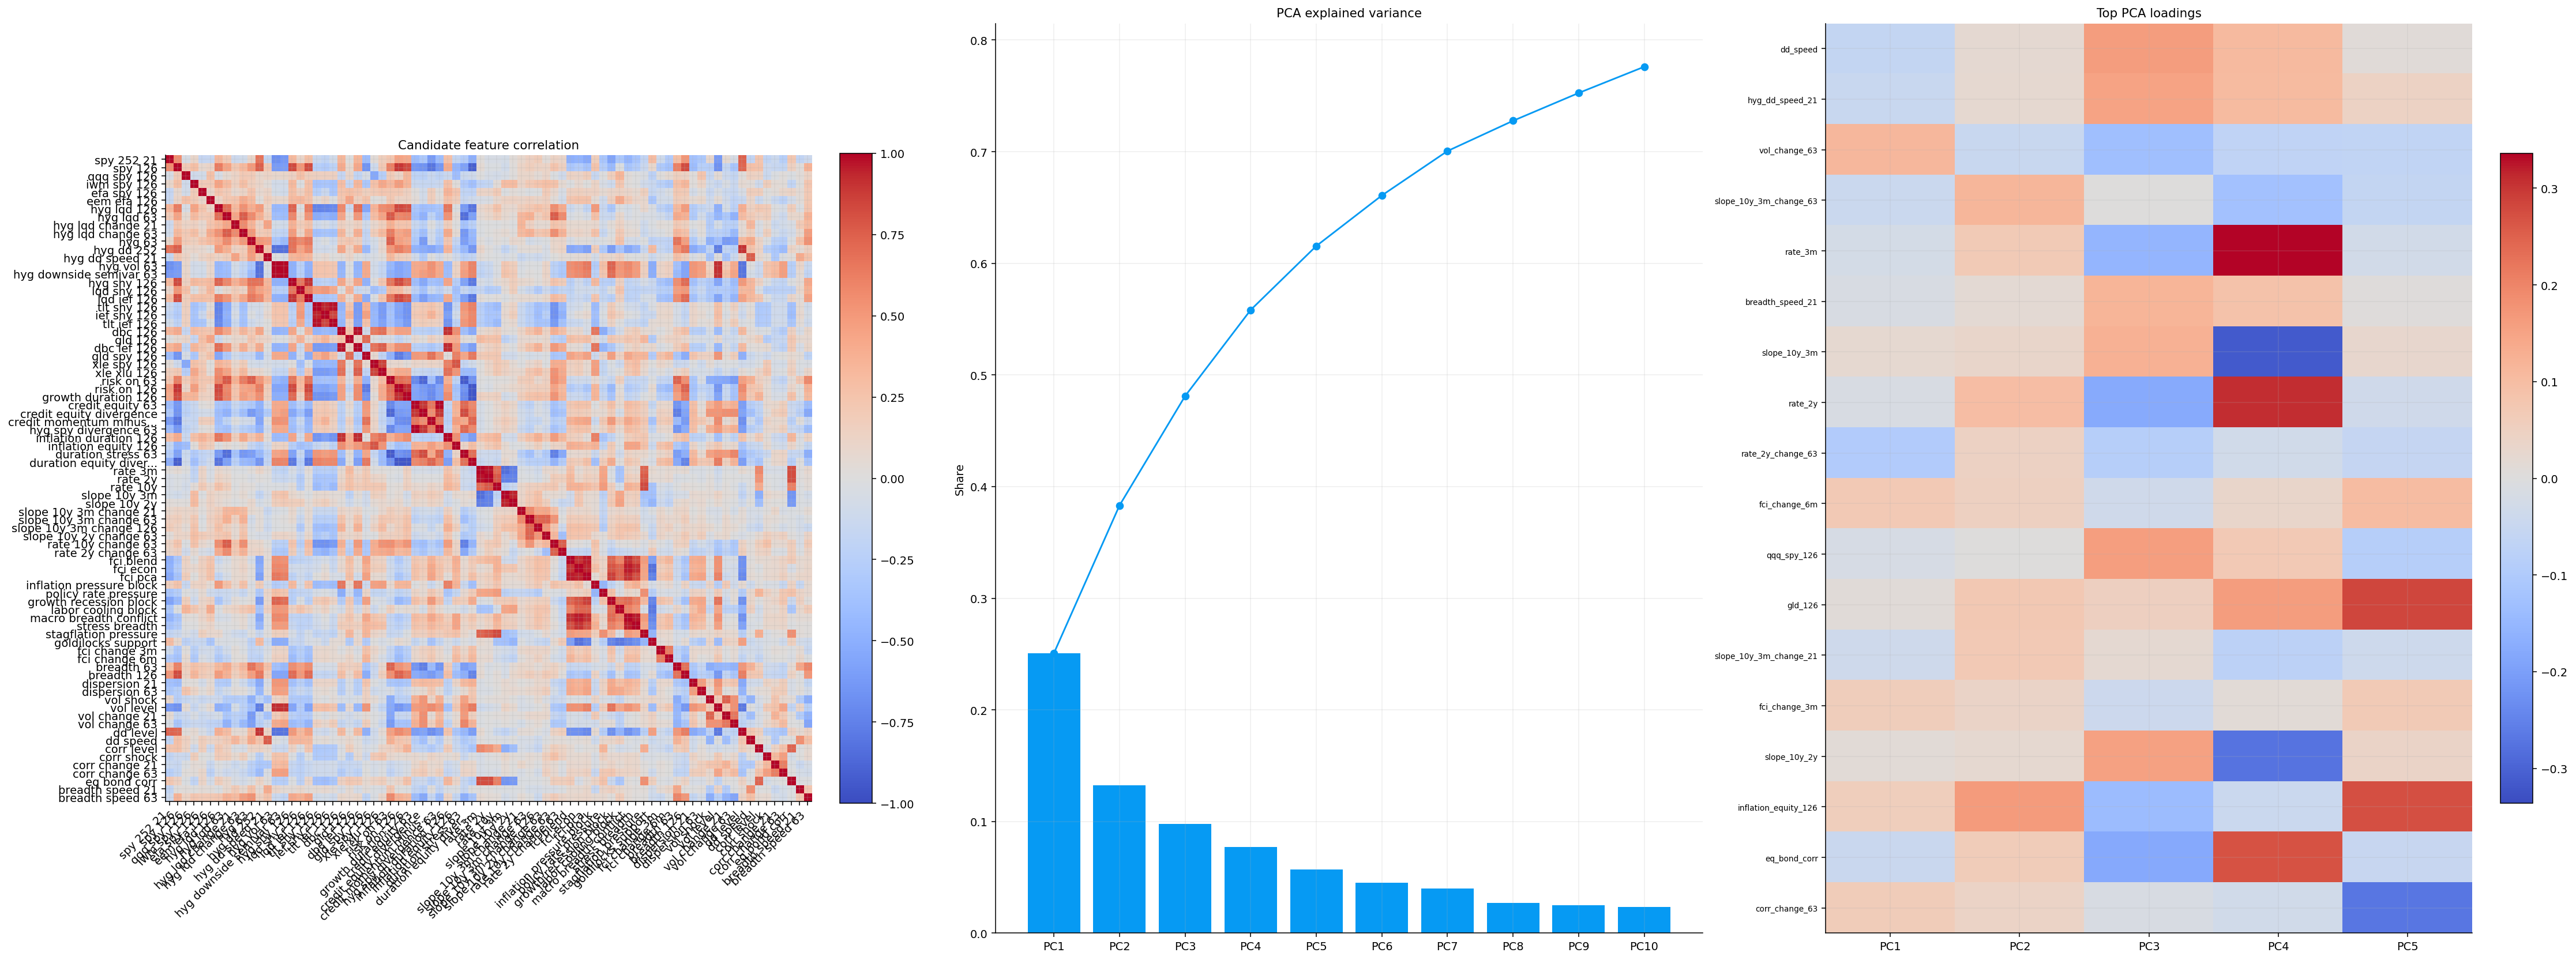

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(32, 12))
plot_corr_heatmap(axes[0], x_all.corr(), title="Candidate feature correlation", annotate=False)
axes[1].bar(range(len(pca_explained_all)), pca_explained_all["explained_variance_ratio"])
axes[1].plot(range(len(pca_explained_all)), pca_explained_all["cumulative"], marker="o")
axes[1].set_xticks(range(len(pca_explained_all)))
axes[1].set_xticklabels(pca_explained_all.index)
axes[1].set_title("PCA explained variance")
axes[1].set_ylabel("Share")
top_loading_rows = pca_loadings_all.abs().max(axis=1).sort_values(ascending=False).head(18).index
load_show = pca_loadings_all.loc[top_loading_rows, pca_loadings_all.columns[:5]]
im = axes[2].imshow(load_show.values, aspect="auto", cmap="coolwarm", vmin=-abs(load_show.values).max(), vmax=abs(load_show.values).max())
axes[2].set_yticks(range(len(load_show.index)))
axes[2].set_yticklabels(load_show.index, fontsize=7)
axes[2].set_xticks(range(len(load_show.columns)))
axes[2].set_xticklabels(load_show.columns)
axes[2].set_title("Top PCA loadings")
fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## 5) Realized Regime Labels from Future Outcomes

For supervised learning, we need labels. We don't label regimes by hand. We define them from forward returns of two sleeves:

- a **risk sleeve**, built from SPY, QQQ, IWM, EFA, and HYG,
- a **defensive sleeve**, built from IEF, SHY, TLT, and GLD.

The 63-day forward return of a sleeve with weights $w_i$ is:

$$
R_{t,t+63}^{\text{sleeve}} = \sum_{i=1}^{N} w_i \left(\frac{P_{t+63,i}}{P_{t,i}} - 1\right)
$$

Then the main forward spread is:

$$
\Delta_{t}^{63} = R_{t,t+63}^{\text{risk}} - R_{t,t+63}^{\text{defensive}}
$$

The realized label is:

$$
Y_t =
\begin{cases}
0 & \text{if } \Delta_{t}^{63} > 0.02 \\
1 & \text{if } -0.02 \le \Delta_{t}^{63} \le 0.02 \\
2 & \text{if } \Delta_{t}^{63} < -0.02
\end{cases}
$$

We map these labels to:

- $0$: risk-on,
- $1$: neutral,
- $2$: defensive.

The threshold avoids labeling tiny differences as meaningful regimes. If the risk sleeve beats the defensive sleeve by only a few basis points, that isn't enough to call the market risk-on. A regime label should represent an economically meaningful future difference.

We also build a slower 126-day label:

$$
\Delta_{t}^{126} = R_{t,t+126}^{\text{risk}} - R_{t,t+126}^{\text{defensive}}
$$

with wider thresholds of $\pm 0.04$. This slower label is useful later when walk-forward classifiers need a more persistent target.


The target construction is one of the most important econometric choices in the project. A bad label can make even a strong model useless. Here the label isn't "SPY up or down." It is the future return difference between a risk sleeve and a defensive sleeve. That makes the target directly aligned with allocation.

The risk sleeve represents assets that usually benefit when investors accept growth, credit, and equity risk. The defensive sleeve represents assets that usually benefit when investors want duration, cash-like safety, or crisis hedges. The target spread:

$$
\Delta_t^{63} = R_{t,t+63}^{\text{risk}} - R_{t,t+63}^{\text{defensive}}
$$

is positive when risk assets beat defensive assets over the next 63 trading days. It is negative when defensive assets beat risk assets.

This target is better aligned with portfolio selection than a single-asset return label because a regime strategy is making a relative allocation decision. It doesn't only care whether SPY is positive. It cares whether carrying risk beats holding defensive exposure. For example, SPY could rise 2% over a quarter, but if GLD and IEF rise 6%, a defensive allocation was still better. A regime model should capture that.

The threshold creates a buffer zone:

$$
Y_t =
\begin{cases}
\text{risk-on} & \Delta_t^{63} > 2\% \\
\text{neutral} & |\Delta_t^{63}| \le 2\% \\
\text{defensive} & \Delta_t^{63} < -2\%
\end{cases}
$$

The neutral class is important because not every date deserves a strong risk-on or defensive label. Financial markets often sit in mixed environments where risky and defensive sleeves perform similarly. If we forced every observation into risk-on or defensive, the model would learn noisy boundaries around tiny return differences. The neutral label reduces that noise.

The 126-day label adds a slower horizon. A 63-day label captures quarter-like tactical conditions. A 126-day label captures a more persistent half-year macro regime. In practice, a strong regime model shouldn't only recognize short-term market stress; it should also understand slower macro environments such as tightening financial conditions, persistent inflation pressure, or extended growth leadership.


In [30]:
def state_profile_local(features, labels, outcomes=None):
    lab = pd.Series(labels, name="state")
    parts = [features.copy()]
    if outcomes is not None:
        out = outcomes.copy()
        if isinstance(out, pd.Series):
            out = out.to_frame()
        parts.append(out.add_prefix("outcome_"))
    z0 = pd.concat(parts + [lab], axis=1).replace([np.inf, -np.inf], np.nan).dropna(subset=["state"])
    cols = [c for c in z0.columns if c != "state"]
    prof = z0.groupby("state")[cols].mean()
    prof.insert(0, "share", z0.groupby("state").size() / len(z0))
    prof.insert(0, "observations", z0.groupby("state").size())
    prof.index = prof.index.astype(int)
    return prof.sort_index()

def sort_profile_states(profile):
    cols = [c for c in profile.columns if c not in {"observations", "share"}]
    z0 = profile[cols].astype(float)
    z0 = (z0 - z0.mean(axis=0)) / z0.std(axis=0, ddof=0).replace(0.0, np.nan)
    z0 = z0.fillna(0.0)
    score = pd.Series(0.0, index=profile.index)
    for col in z0.columns:
        name = str(col).lower()
        if "risk_defensive_spread" in name:
            score += 3.0 * z0[col]
            continue
        if any(k in name for k in ["spy", "qqq", "iwm", "efa", "eem", "hyg", "risk_on", "breadth", "growth", "credit", "cyclical", "sector_ew"]):
            score += z0[col]
        if any(k in name for k in ["vol", "corr", "dispersion"]):
            score -= z0[col]
        if "dd" in name or "drawdown" in name:
            score += z0[col]
        if "defensive_sleeve" in name:
            score -= 0.5 * z0[col]
        if "tlt" in name and "outcome" in name:
            score -= 0.5 * z0[col]
    return score.sort_values(ascending=False).index.astype(int).tolist()

def remap_series(labels, order):
    mapping = {int(old): int(new) for new, old in enumerate(order)}
    return pd.Series(labels).map(mapping).astype(int)

In [31]:
target_risk_weights = pd.Series({"SPY": 0.35, "QQQ": 0.20, "IWM": 0.15, "EFA": 0.15, "HYG": 0.15})
target_defensive_weights = pd.Series({"IEF": 0.45, "SHY": 0.25, "TLT": 0.15, "GLD": 0.15})

def forward_sleeve_return(weights, days):
    fwd = close[weights.index].shift(-int(days)) / close[weights.index] - 1.0
    return fwd.mul(weights, axis=1).sum(axis=1)

risk_forward_63 = forward_sleeve_return(target_risk_weights, horizon)
defensive_forward_63 = forward_sleeve_return(target_defensive_weights, horizon)
spread_63 = risk_forward_63 - defensive_forward_63

risk_forward_126 = forward_sleeve_return(target_risk_weights, horizon_slow)
defensive_forward_126 = forward_sleeve_return(target_defensive_weights, horizon_slow)
spread_126 = risk_forward_126 - defensive_forward_126

future_assets_63 = close[outcome_assets].shift(-horizon) / close[outcome_assets] - 1.0
future_assets_126 = close[outcome_assets].shift(-horizon_slow) / close[outcome_assets] - 1.0
future_for_quality = pd.concat(
    [
        future_assets_63.add_suffix("_63"),
        future_assets_126.add_suffix("_126"),
        risk_forward_63.rename("risk_sleeve_63"),
        defensive_forward_63.rename("defensive_sleeve_63"),
        spread_63.rename("risk_defensive_spread_63"),
        risk_forward_126.rename("risk_sleeve_126"),
        defensive_forward_126.rename("defensive_sleeve_126"),
        spread_126.rename("risk_defensive_spread_126"),
    ],
    axis=1,
).reindex(x_all.index).dropna()

y = pd.Series(1, index=future_for_quality.index, name="realized_regime")
y.loc[spread_63.reindex(y.index) > 0.02] = 0
y.loc[spread_63.reindex(y.index) < -0.02] = 2

y_slow = pd.Series(1, index=future_for_quality.index, name="slow_regime")
y_slow.loc[spread_126.reindex(y_slow.index) > 0.04] = 0
y_slow.loc[spread_126.reindex(y_slow.index) < -0.04] = 2

stress_label = (
    (future_assets_63["SPY"].reindex(future_for_quality.index) < -0.08)
    | (spread_63.reindex(future_for_quality.index) < -0.05)
).astype(int).rename("stress_63")

model_index = x_all.index.intersection(y.index)
x_model = x_all.loc[model_index]
y = y.loc[model_index].astype(int)
y_slow = y_slow.loc[model_index].astype(int)
stress_label = stress_label.loc[model_index].astype(int)
future_for_quality = future_for_quality.loc[model_index]
future_profile = state_profile_local(future_for_quality, y, future_for_quality)
future_profile.index = regime_names
display(future_profile.round(4))

,observations,share,SPY_63,HYG_63,TLT_63,DBC_63,GLD_63,EEM_63,SPY_126,HYG_126,TLT_126,DBC_126,GLD_126,EEM_126,risk_sleeve_63,defensive_sleeve_63,risk_defensive_spread_63,risk_sleeve_126,defensive_sleeve_126,risk_defensive_spread_126,outcome_SPY_63,outcome_HYG_63,outcome_TLT_63,outcome_DBC_63,outcome_GLD_63,outcome_EEM_63,outcome_SPY_126,outcome_HYG_126,outcome_TLT_126,outcome_DBC_126,outcome_GLD_126,outcome_EEM_126,outcome_risk_sleeve_63,outcome_defensive_sleeve_63,outcome_risk_defensive_spread_63,outcome_risk_sleeve_126,outcome_defensive_sleeve_126,outcome_risk_defensive_spread_126
risk_on,2557,0.5666,0.0759,0.0319,-0.0139,0.0378,0.0101,0.0596,0.1077,0.0455,-0.0075,0.0447,0.0355,0.0706,0.0727,-0.0017,0.0744,0.1008,0.0066,0.0942,0.0759,0.0319,-0.0139,0.0378,0.0101,0.0596,0.1077,0.0455,-0.0075,0.0447,0.0355,0.0706,0.0727,-0.0017,0.0744,0.1008,0.0066,0.0942
neutral,875,0.1939,0.0196,0.0110,0.0151,-0.0002,0.0437,0.0103,0.0581,0.0258,0.0210,0.0098,0.0640,0.0322,0.0161,0.0138,0.0023,0.0517,0.0213,0.0304,0.0196,0.0110,0.0151,-0.0002,0.0437,0.0103,0.0581,0.0258,0.0210,0.0098,0.0640,0.0322,0.0161,0.0138,0.0023,0.0517,0.0213,0.0304
defensive,1081,0.2395,-0.0662,-0.0248,0.0592,-0.0736,0.0469,-0.0853,-0.0370,-0.0091,0.0776,-0.0751,0.0787,-0.0575,-0.0661,0.0328,-0.0989,-0.0374,0.0475,-0.0849,-0.0662,-0.0248,0.0592,-0.0736,0.0469,-0.0853,-0.0370,-0.0091,0.0776,-0.0751,0.0787,-0.0575,-0.0661,0.0328,-0.0989,-0.0374,0.0475,-0.0849


The forward regime profile confirms that the labels have real economic meaning. The risk-on class has strong positive 63-day and 126-day forward outcomes for SPY, HYG, DBC, EEM, and the risk sleeve. The defensive class has negative forward SPY and EEM outcomes, strong TLT and GLD outcomes, and a negative risk-defensive spread. The neutral class sits between those two.

The class balance isn't perfectly equal. Risk-on is the largest class, neutral is smaller, and defensive is meaningful but less frequent. This is normal for market regimes. Most days aren't crisis days. But this creates an ML problem: raw accuracy can reward a model that mostly predicts risk-on. That is why balanced accuracy and macro F1 matter later.

Balanced accuracy is:

$$
\text{Balanced Accuracy} = \frac{1}{K}\sum_{k=1}^{K}\frac{TP_k}{TP_k + FN_k}
$$

It averages recall across classes. A model must recognize defensive observations too, not only the common risk-on regime.

Macro F1 is:

$$
\text{Macro F1} = \frac{1}{K}\sum_{k=1}^{K}\frac{2\cdot \text{Precision}_k \cdot \text{Recall}_k}{\text{Precision}_k + \text{Recall}_k}
$$

This punishes models that perform well only on one class. In finance, that is crucial because the rare class is often the one we care about most. A model that misses defensive periods can still have acceptable accuracy, but it can fail as a portfolio tool.


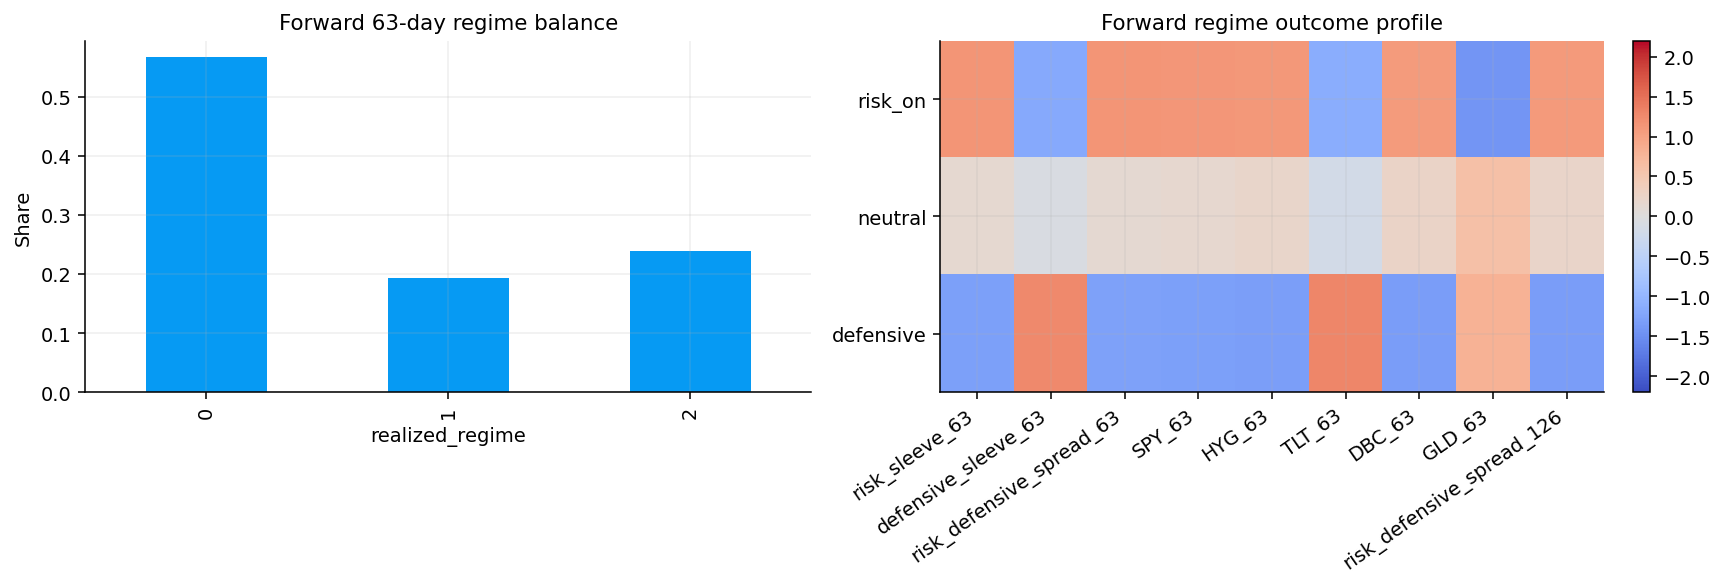

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.3))
y.value_counts(normalize=True).sort_index().plot(kind="bar", ax=axes[0])
axes[0].set_title("Forward 63-day regime balance")
axes[0].set_ylabel("Share")
profile_cols = [
    c for c in [
        "outcome_risk_sleeve_63",
        "outcome_defensive_sleeve_63",
        "outcome_risk_defensive_spread_63",
        "outcome_SPY_63",
        "outcome_HYG_63",
        "outcome_TLT_63",
        "outcome_DBC_63",
        "outcome_GLD_63",
        "outcome_risk_defensive_spread_126",
    ]
    if c in future_profile.columns
]
profile_z = future_profile[profile_cols]
profile_z = (profile_z - profile_z.mean()) / profile_z.std(ddof=0).replace(0, np.nan)
im = axes[1].imshow(profile_z.fillna(0.0).values, aspect="auto", cmap="coolwarm", vmin=-2.2, vmax=2.2)
axes[1].set_yticks(range(len(profile_z.index)))
axes[1].set_yticklabels(profile_z.index)
axes[1].set_xticks(range(len(profile_z.columns)))
axes[1].set_xticklabels([c.replace("outcome_", "") for c in profile_z.columns], rotation=35, ha="right")
axes[1].set_title("Forward regime outcome profile")
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

The class distribution also teaches an important ML lesson. Risk-on observations are the largest class because most market days aren't stress days. Defensive regimes are less frequent, but they matter disproportionately for portfolio outcomes because they usually coincide with large drawdowns or rapid rotations.

This is why raw accuracy can be misleading. Suppose risk-on is 57% of observations. A lazy model that always predicts risk-on could get decent raw accuracy while being useless in crises. In a portfolio context, missing the defensive class is more costly than missing a few neutral periods.

Balanced accuracy fixes part of that problem by averaging recall across classes:

$$
\text{Balanced Accuracy} = \frac{1}{K}\sum_{k=1}^{K}\frac{TP_k}{TP_k+FN_k}
$$

where $TP_k$ is the number of true positives for class $k$ and $FN_k$ is the number of missed observations from class $k$. This metric gives equal importance to risk-on, neutral, and defensive regimes even if they aren't equally common.

Macro F1 combines precision and recall:

$$
F1_k = \frac{2\cdot \text{Precision}_k \cdot \text{Recall}_k}{\text{Precision}_k+\text{Recall}_k}
$$

and:

$$
\text{Macro F1} = \frac{1}{K}\sum_{k=1}^{K}F1_k
$$

Precision asks whether predicted class $k$ observations really belong to class $k$. Recall asks whether the model finds the actual class $k$ observations. In regime switching, both matter. If the model predicts defensive too often, the portfolio may sit in safe assets and miss rallies. If it predicts defensive too rarely, it may stay risk-on into drawdowns. The metrics help us detect those two different errors.


In [35]:
feature_train_end = pd.Timestamp("2018-12-31")
train_mask = x_model.index <= feature_train_end
test_mask = x_model.index > feature_train_end

rf_selector = RandomForestClassifier(
    n_estimators=500,
    min_samples_leaf=20,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=1,
)
rf_selector.fit(x_model.loc[train_mask], y.loc[train_mask])
perm = permutation_importance(
    rf_selector,
    x_model.loc[train_mask],
    y.loc[train_mask],
    n_repeats=8,
    random_state=42,
    scoring="balanced_accuracy",
    n_jobs=1,
)
importance = pd.DataFrame(
    {
        "feature": x_model.columns,
        "importance": rf_selector.feature_importances_,
        "permutation_importance": perm.importances_mean,
        "permutation_std": perm.importances_std,
    }
).sort_values(["permutation_importance", "importance"], ascending=False)

selected_features = list(dict.fromkeys(importance.head(25)["feature"].tolist()))
display(importance.head(18).round(4))
display(pd.DataFrame({"selected_features": selected_features}))

,feature,importance,permutation_importance,permutation_std
49,fci_blend,0.0195,0.0065,0.0008
69,vol_change_63,0.0158,0.0064,0.0014
70,dd_level,0.0152,0.0057,0.0014
56,macro_breadth_conflict_block,0.0336,0.0048,0.0014
4,efa_spy_126,0.0268,0.0035,0.0016
3,iwm_spy_126,0.0112,0.0032,0.0010
59,goldilocks_support,0.0323,0.0031,0.0012
5,eem_efa_126,0.0160,0.0030,0.0008
19,ief_shy_126,0.0125,0.0030,0.0009
40,rate_10y,0.0307,0.0027,0.0025


,selected_features
0,fci_blend
1,vol_change_63
2,dd_level
3,macro_breadth_conflict_block
4,efa_spy_126
5,iwm_spy_126
6,goldilocks_support
7,eem_efa_126
8,ief_shy_126
9,rate_10y


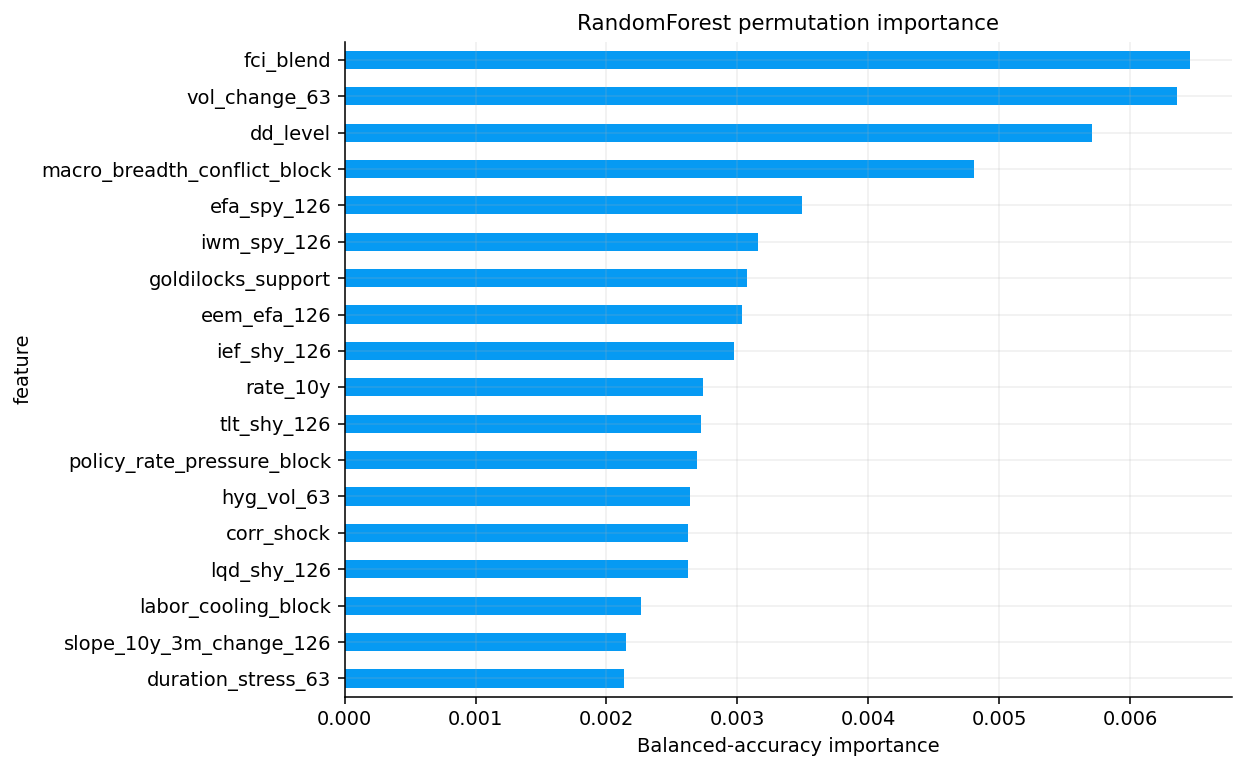

In [36]:
fig, ax = plt.subplots(figsize=(9.0, 5.6))
importance.head(18).sort_values("permutation_importance").plot(
    x="feature",
    y="permutation_importance",
    kind="barh",
    ax=ax,
    legend=False,
)
ax.set_title("RandomForest permutation importance")
ax.set_xlabel("Balanced-accuracy importance")
plt.tight_layout()
plt.show()

The RandomForest importance table selects features that are economically meaningful, not just statistically convenient. The top features include:

- `fci_blend`, linking the regime model to the macro/financial-condition framework from Project 12.
- `vol_change_63`, showing that rising volatility carries regime information.
- `dd_level`, because deep drawdowns often separate defensive states from normal volatility.
- `macro_breadth_conflict_block`, which captures disagreement between macro stress blocks and market breadth.
- international and cross-asset relative returns such as `efa_spy_126`, `iwm_spy_126`, and `eem_efa_126`.
- duration and policy features such as `ief_shy_126`, `rate_10y`, `tlt_shy_126`, and `policy_rate_pressure_block`.
- credit and downside risk features such as `hyg_vol_63`, `hyg_downside_semivar_63`, and `hyg_lqd_change_63`.

This is a good feature-selection result because it doesn't collapse into one category. The selected set includes macro pressure, volatility, drawdown, international leadership, credit, duration, and inflation. That gives the regime models enough information to distinguish:

- equity-led risk-on,
- credit-supported risk-on,
- neutral defensive yield environments,
- inflation-rate stress,
- and broad market stress.

After selection, we transform features with an expanding z-score:

$$
z_{t,j} = \operatorname{clip}\left(\frac{x_{t,j}-\bar{x}_{t-1,j}}{s_{t-1,j}}, -4, 4\right)
$$

where $\bar{x}_{t-1,j}$ and $s_{t-1,j}$ are computed only from observations before date $t$. This avoids lookahead. The clip at $\pm 4$ prevents extreme crisis observations from dominating the scale forever.

The selected-feature VIF table still shows high VIF for duration features, especially `tlt_shy_126`, `tlt_ief_126`, and `ief_shy_126`. This is expected because those spreads share assets. The model doesn't remove all redundancy. Instead, it keeps economically useful redundancy and relies on methods like PCA-HMM, tree models, regularization, and validation to handle it.


RandomForest feature selection is used as a pragmatic filter, not as the final truth about causality. The idea is to ask: if a nonlinear tree ensemble tries to predict future regime labels, which features actually help out of sample?

Permutation importance is especially useful because it measures the loss of predictive performance when one feature is randomly shuffled. If feature $j$ is important, shuffling it breaks its relationship with the target and model performance drops. If shuffling it barely changes performance, the feature may be redundant or uninformative.

A simplified version is:

$$
I_j = \text{Score}(f, X, Y) - \text{Score}(f, X^{\pi_j}, Y)
$$

where $X^{\pi_j}$ is the same feature matrix after randomly permuting column $j$. The bigger $I_j$ is, the more the model depended on that feature.

The selected features make economic sense. `fci_blend` is the highest-ranked feature, which means the macro/financial-condition system from Project 12 carries information about future cross-asset regimes. `vol_change_63` and `dd_level` are also near the top, which means recent volatility acceleration and drawdown damage matter. `macro_breadth_conflict_block` is important because markets often become vulnerable when price breadth and macro conditions disagree. Relative equity features such as `efa_spy_126`, `iwm_spy_126`, and `eem_efa_126` show whether leadership is U.S.-centric, small-cap-led, or international/EM-led.

This feature selection stage also helps with interpretability. Instead of saying "the model saw 79 variables," we can say the final regime models are mostly learning from:

- financial conditions,
- volatility acceleration,
- drawdown pressure,
- macro-market disagreement,
- international leadership,
- duration and policy pressure,
- credit downside risk,
- and inflation/stagflation blocks.

That is a coherent economic state space. It gives the model a chance to separate regimes in ways that match market intuition.


In [37]:
def selected_feature_transform(x, min_history=252, clip=4.0):
    base = x.replace([np.inf, -np.inf], np.nan).astype(float)
    mean = base.expanding(min_periods=int(min_history)).mean().shift(1)
    std = base.expanding(min_periods=int(min_history)).std(ddof=1).shift(1).replace(0.0, np.nan)
    transformed = ((base - mean) / std).clip(-float(clip), float(clip))
    return transformed

x_raw_unscaled = x_model[selected_features].copy()
x_raw = selected_feature_transform(x_raw_unscaled).dropna(how="any")
common_selected = x_raw.index.intersection(y.index)
x_raw = x_raw.loc[common_selected]
y = y.loc[common_selected].astype(int)
y_slow = y_slow.loc[common_selected].astype(int)
stress_label = stress_label.loc[common_selected].astype(int)
future_for_quality = future_for_quality.loc[common_selected]
train_mask = x_raw.index <= feature_train_end
test_mask = x_raw.index > feature_train_end
scaler = StandardScaler()
z = pd.DataFrame(scaler.fit_transform(x_raw), index=x_raw.index, columns=x_raw.columns)
vif_selected = feature_vif_local(x_raw)
pca_explained, pca_loadings = pca_tables_local(x_raw, n_components=min(8, x_raw.shape[1]))
display(vif_selected.round(2))
display(pca_explained.round(4))

,r2,vif
feature,,
tlt_shy_126,1.00,5471.79
tlt_ief_126,1.00,2033.51
ief_shy_126,1.00,1051.27
hyg_downside_semivar_63,0.99,67.02
hyg_vol_63,0.98,60.65
fci_blend,0.95,20.97
goldilocks_support,0.95,20.43
labor_cooling_block,0.95,19.96
stagflation_pressure,0.94,16.68


,explained_variance,explained_variance_ratio,cumulative
PC1,5.4924,0.2196,0.2196
PC2,4.6684,0.1867,0.4063
PC3,3.6193,0.1447,0.5511
PC4,2.3122,0.0925,0.6435
PC5,1.7186,0.0687,0.7123
PC6,1.2408,0.0496,0.7619
PC7,1.0295,0.0412,0.8031
PC8,0.8837,0.0353,0.8384


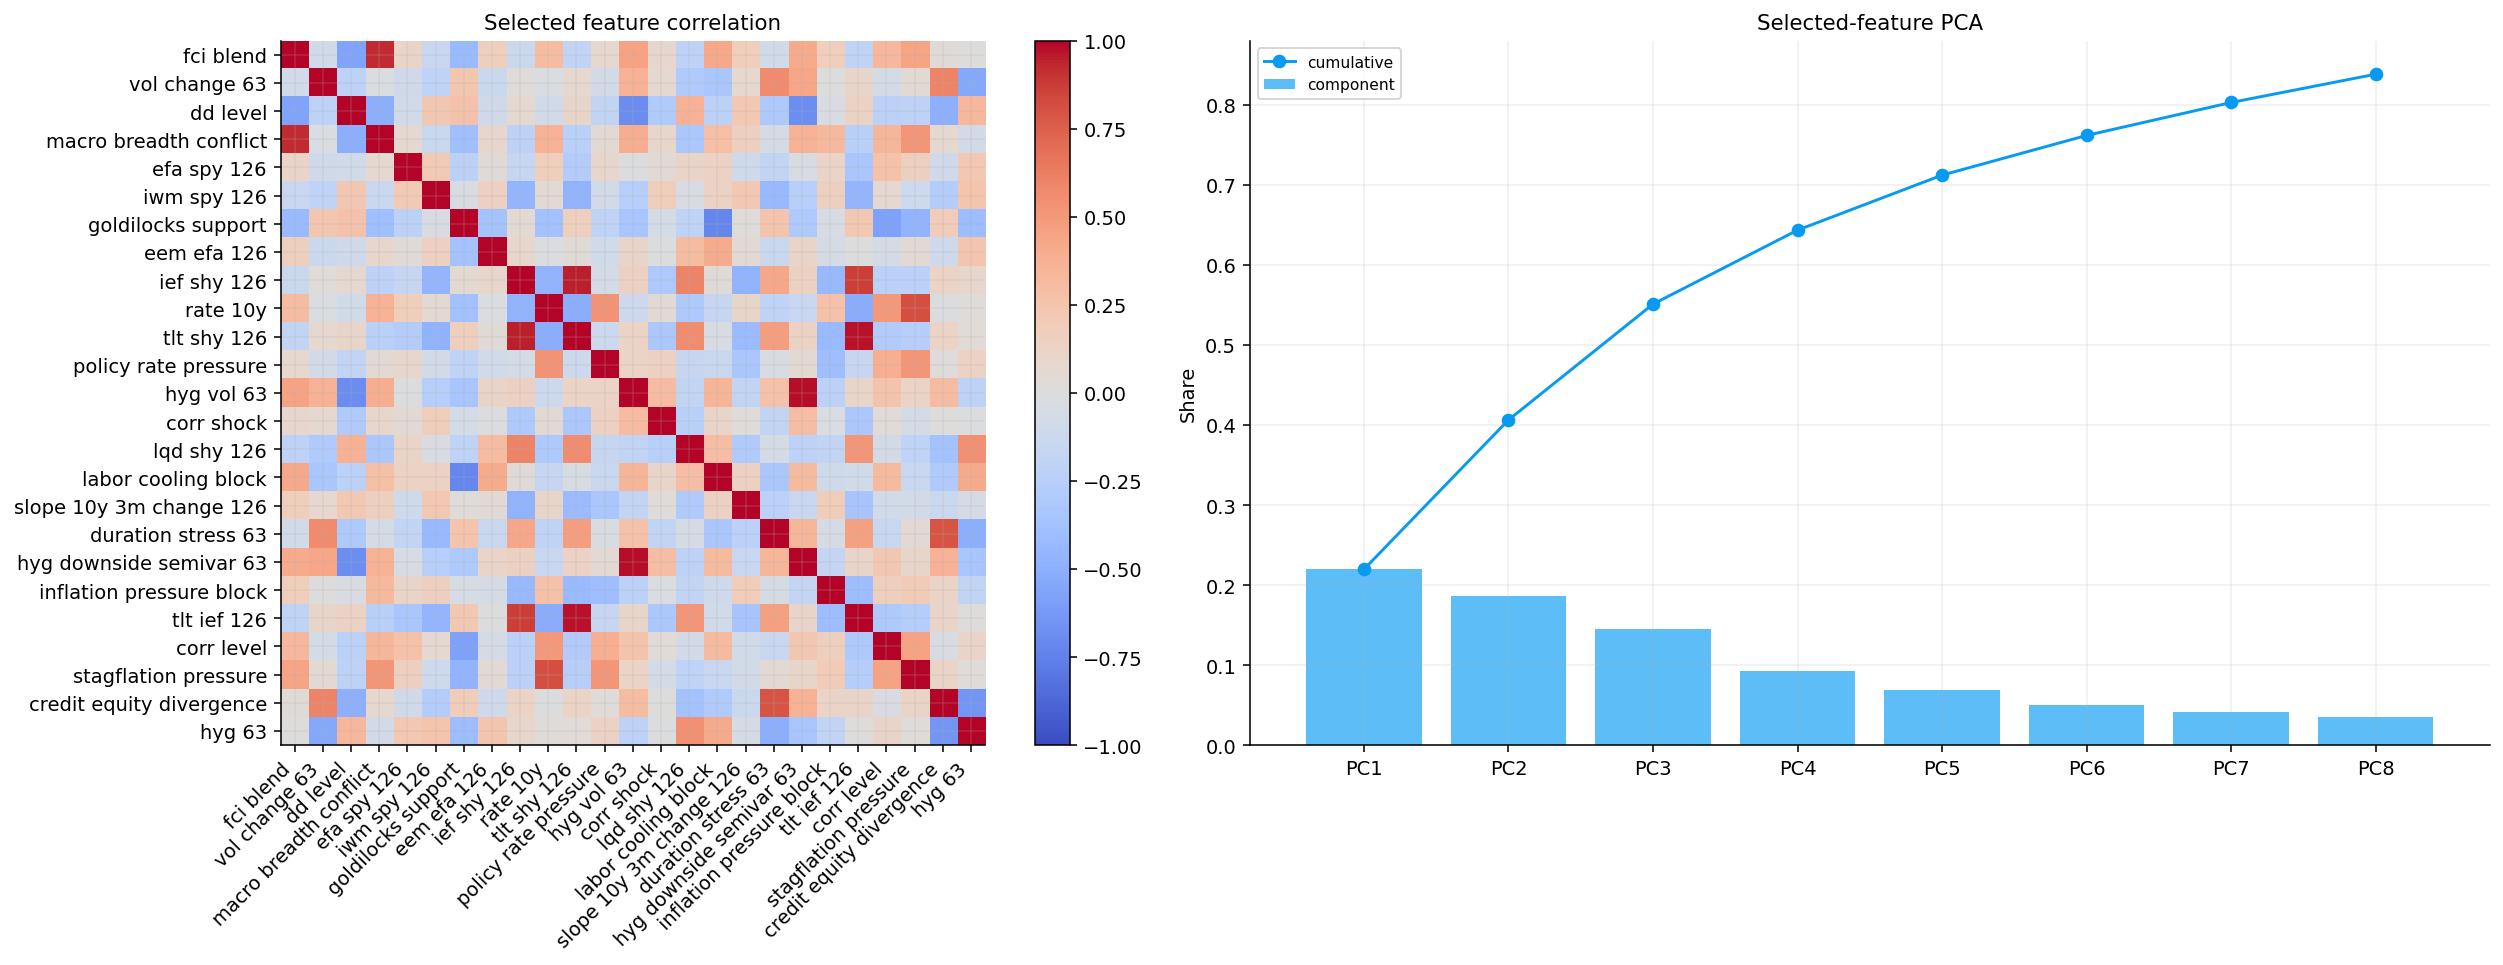

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
plot_corr_heatmap(axes[0], x_raw.corr(), title="Selected feature correlation", annotate=False)
axes[1].plot(pca_explained.index, pca_explained["cumulative"], marker="o", label="cumulative")
axes[1].bar(pca_explained.index, pca_explained["explained_variance_ratio"], alpha=0.65, label="component")
axes[1].set_title("Selected-feature PCA")
axes[1].set_ylabel("Share")
axes[1].legend()
plt.tight_layout()
plt.show()

The selected-feature PCA is cleaner than the full candidate PCA. PC1 explains about 22.0%, PC2 about 18.7%, and the first 8 components explain about 83.8%. So the selected feature set is still strongly structured, but it is less bloated than the 79-feature candidate set.

This matters for the models:

- **KMeans** and **GMM** can be sensitive to correlated dimensions because distance and Gaussian density can over-count repeated information.
- **PCA-HMM** deliberately compresses features before fitting the sequence model.
- **LDA** benefits from shrinkage because class covariance estimates can become unstable when predictors are correlated.
- **RandomForest and boosting** can handle correlated features better, but importance can be split across related variables.
- **SVM and KNN** depend on geometry, so scaling and redundancy strongly affect the margin and nearest-neighbor structure.

This diagnostic stage isn't just a plot-making step. It tells us what kind of model risk each method faces before we compare the results.


## 6) Unsupervised Learning for Regime Discovery

We now split the problem into two learning styles.

**Unsupervised learning** sees only $X_t$. It tries to discover structure in the feature space without using future labels. The output is a state assignment:

$$
\hat{S}_t = g(X_t)
$$

The model doesn't know the future risk-defensive spread. After fitting, we profile each discovered state by looking at its realized future outcomes. Then we order the states as risk-on, neutral, or defensive.

**Supervised learning** sees pairs $(X_t, Y_t)$ during training. It directly learns:

$$
P(Y_t = k \mid X_t)
$$

and evaluates whether those probabilities predict future regimes.

The teaching plot in this section shows the difference cleanly. Discovery takes today's features and finds latent states. Prediction uses future labels during training and then predicts the next realized state.

For finance, both styles are useful.

Unsupervised models are closer to econometric regime discovery. They ask: "What clusters or latent states exist in the market data?" Supervised models are closer to forecasting. They ask: "Given today's features, which future sleeve outcome is most likely?"

We include both because regime modeling has two separate goals:

1. **Interpretation**, which benefits from unsupervised and Markov-style models.
2. **Prediction**, which benefits from supervised classifiers and explicit out-of-sample labels.


Unsupervised learning is the discovery layer. It doesn't use the forward regime labels when fitting the states. It only sees the feature matrix $X_t$ and tries to find structure. Afterward, we evaluate whether the discovered states correspond to economically meaningful future outcomes.

This gives us a useful separation:

1. **Discovery**: identify clusters or latent states from today's market conditions.
2. **Economic mapping**: inspect future returns conditional on those states.
3. **Portfolio usefulness**: test whether the states produce useful weights after costs.

In notation, unsupervised models estimate:

$$
\hat{S}_t = g(X_t)
$$

or, for probabilistic models:

$$
\hat{p}_{t,k} = P(S_t=k \mid X_t)
$$

without directly using $Y_t$ during fitting. That makes them appealing for regime discovery because they can find states we did not label by hand. The danger is that a statistically clean cluster can still be financially weak. A cluster might separate high volatility from low volatility, but if both clusters have similar future risk-defensive spreads, the separation doesn't help allocation.

So every unsupervised model is judged on both statistical and economic criteria:

- **Silhouette**: are observations geometrically well separated?
- **Minimum state share**: is every state large enough to matter?
- **Average duration**: are states persistent enough for monthly allocation?
- **Transitions per year**: is the state path too jumpy?
- **Posterior confidence**: are probabilities decisive or diffuse?
- **Economic separation**: do states actually differ in future returns?

This is why the output table is more important than the individual model label. We aren't looking for a pretty clustering result. We are looking for a state representation that can support a real portfolio policy.


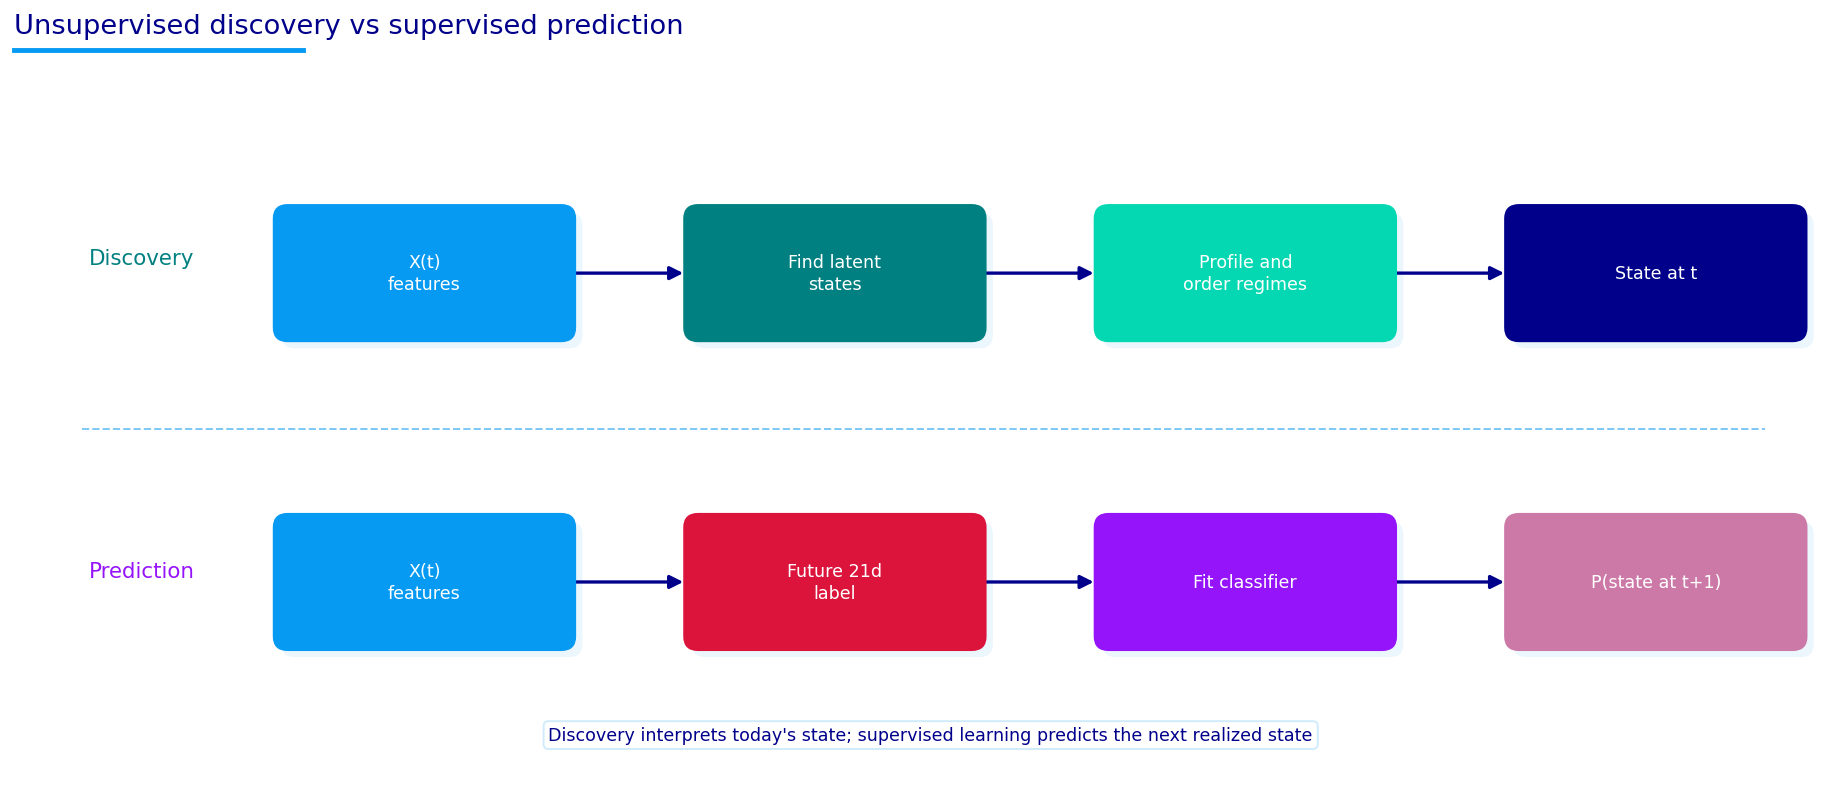

In [40]:
fig, ax = unsupervised_supervised()
plt.show()

In [41]:
def state_durations(labels):
    s = pd.Series(labels).dropna().astype(int)
    if s.empty:
        return []
    groups = (s != s.shift()).cumsum()
    return s.groupby(groups).size().astype(int).tolist()

def quality_row_local(name, labels, x=None, proba=None, outcomes=None, loglike=np.nan, aic=np.nan, bic=np.nan):
    lab = pd.Series(labels).dropna().astype(int)
    row = {
        "model": name,
        "states": lab.nunique(),
        "loglike": loglike,
        "aic": aic,
        "bic": bic,
        "silhouette": np.nan,
        "min_state_share": lab.value_counts(normalize=True).min() if len(lab) else np.nan,
        "avg_state_duration": np.mean(state_durations(lab)) if len(lab) else np.nan,
        "transitions_per_year": np.nan,
        "posterior_confidence": np.nan,
        "economic_separation": np.nan,
    }
    if isinstance(lab.index, pd.DatetimeIndex) and len(lab) > 1:
        years = max((lab.index[-1] - lab.index[0]).days / 365.25, 1.0 / annualization)
        row["transitions_per_year"] = ((lab != lab.shift()).sum() - 1) / years
    elif len(lab) > 1:
        row["transitions_per_year"] = ((lab != lab.shift()).sum() - 1) / (len(lab) / annualization)
    if x is not None and lab.nunique() > 1:
        try:
            Xq = x.loc[lab.index].to_numpy(dtype=float) if isinstance(x, pd.DataFrame) else np.asarray(x, dtype=float)
            row["silhouette"] = silhouette_score(Xq, lab.to_numpy(dtype=int))
        except Exception:
            pass
    if proba is not None:
        P = proba.loc[lab.index] if isinstance(proba, pd.DataFrame) else pd.DataFrame(proba, index=lab.index)
        row["posterior_confidence"] = P.max(axis=1).mean()
    if outcomes is not None and lab.nunique() > 1:
        out = outcomes.reindex(lab.index)
        joined = pd.concat([out, lab.rename("state")], axis=1).dropna()
        if not joined.empty:
            by_state = joined.groupby("state")[out.columns].mean()
            denom = joined[out.columns].std(ddof=1).replace(0.0, np.nan)
            row["economic_separation"] = (by_state.max() - by_state.min()).div(denom).mean()
    return row

eco_rows = []
eco_outputs = {}

### 6.1 KMeans

KMeans is the simplest clustering model in the project. It assigns each observation to the nearest centroid. If we want $K$ clusters, KMeans solves:

$$
\min_{\{c_t\}, \{\mu_k\}} \sum_{t=1}^{T} \left\|X_t - \mu_{c_t}\right\|_2^2
$$

where:

- $X_t$ is the feature vector at time $t$,
- $c_t \in \{1,\dots,K\}$ is the cluster assigned to observation $t$,
- $\mu_k$ is the centroid of cluster $k$.

The algorithm alternates between two steps:

1. **Assignment step**: assign each point to the closest centroid.

$$
c_t = \arg\min_k \left\|X_t - \mu_k\right\|_2^2
$$

2. **Update step**: replace each centroid with the mean of the points assigned to it.

$$
\mu_k = \frac{1}{N_k}\sum_{t:c_t=k}X_t
$$

The geometry plot shows the result in a two-dimensional teaching example. Each colored region is the area closest to one centroid. The boundaries are straight lines because the model is using Euclidean distance. That makes KMeans easy to understand, but it also creates limitations. Regime clusters in finance are rarely spherical, equally sized, or separated by straight boundaries.

For example, a defensive regime may not be a compact cloud. It can include the COVID crash, the 2022 inflation-rate shock, and smaller volatility shocks. Those episodes may share "stress" behavior, but they don't need to occupy one neat ball in feature space. KMeans can still be useful as a baseline, but we shouldn't expect it to be the most realistic regime model.


The KMeans objective is simple but powerful. For $K$ clusters, it chooses centroids $\mu_1,\dots,\mu_K$ and assignments $c_t$ to minimize within-cluster squared distance:

$$
\min_{\{c_t\},\{\mu_k\}}\sum_{t=1}^{T}\left\|X_t-\mu_{c_t}\right\|_2^2
$$

Each centroid is the average feature vector of observations assigned to that cluster. The algorithm alternates between:

- assigning each observation to the nearest centroid,
- recomputing each centroid as the mean of assigned observations.

The financial interpretation is that each centroid becomes a typical market environment. One centroid might represent calm risk-on: positive breadth, low volatility, healthy credit, and normal financial conditions. Another might represent stress: negative breadth, rising volatility, weak credit, and tight FCI. A third might represent mixed conditions.

The main weakness is the geometry assumption. KMeans works best when clusters are roughly spherical and similar in size after scaling. Financial regimes rarely behave like clean spherical clusters. Stress states can be smaller, more extreme, and more stretched. Neutral states can be broad and overlapping. Because KMeans uses hard assignments, it also doesn't express uncertainty. A date just on the boundary is treated as fully belonging to one state.

The teaching plot helps here: cluster boundaries are straight Voronoi regions around centroids. In a real market-state space, that means the model assigns regimes based on nearest average environment. This is clear and interpretable, but it can miss nonlinear or overlapping regimes.


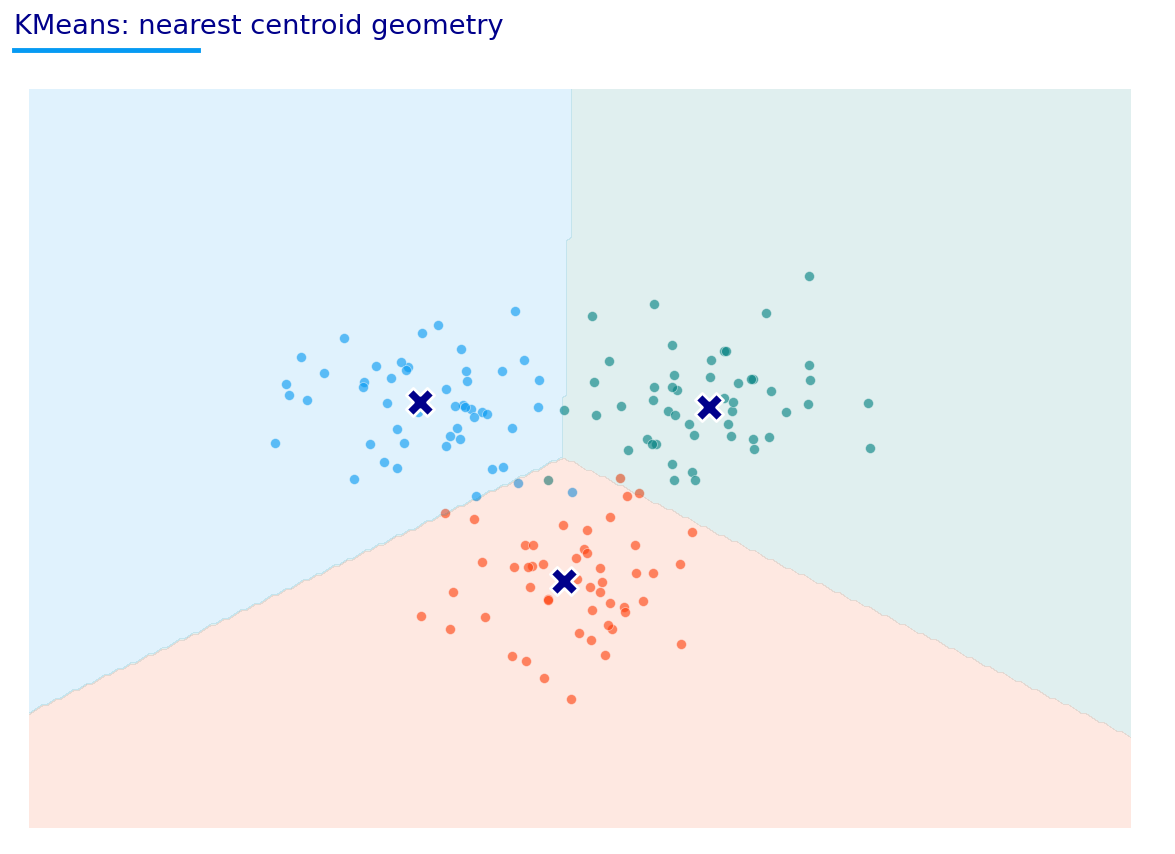

In [42]:
fig, ax = kmeans_geometry()
plt.show()

In [43]:
kmeans3 = KMeans(n_clusters=3, n_init=50, random_state=42)
lab = pd.Series(kmeans3.fit_predict(z), index=z.index, name="state")
order = sort_profile_states(state_profile_local(x_raw, lab, future_for_quality))
lab = remap_series(lab, order).set_axis(z.index)
eco_outputs["KMeans 3"] = {"labels": lab, "proba": pd.get_dummies(lab).reindex(columns=range(3), fill_value=0.0)}
eco_rows.append(quality_row_local("KMeans 3", lab, x=z, outcomes=future_for_quality))

kmeans4 = KMeans(n_clusters=4, n_init=50, random_state=42)
lab = pd.Series(kmeans4.fit_predict(z), index=z.index, name="state")
order = sort_profile_states(state_profile_local(x_raw, lab, future_for_quality))
lab = remap_series(lab, order).set_axis(z.index)
eco_outputs["KMeans 4"] = {"labels": lab, "proba": pd.get_dummies(lab).reindex(columns=range(4), fill_value=0.0)}
eco_rows.append(quality_row_local("KMeans 4", lab, x=z, outcomes=future_for_quality))

### 6.2 Agglomerative Clustering

Agglomerative clustering builds a hierarchy. It starts with every observation as its own cluster and then repeatedly merges the closest groups. The teaching diagram shows this as a dendrogram. Cutting the tree at a chosen height gives the number of clusters.

With Ward linkage, the merge cost between two clusters $A$ and $B$ is:

$$
\Delta(A,B) = \frac{|A||B|}{|A|+|B|}\left\|\bar{X}_A-\bar{X}_B\right\|_2^2
$$

where:

- $|A|$ and $|B|$ are the cluster sizes,
- $\bar{X}_A$ and $\bar{X}_B$ are cluster centroids.

Ward linkage tries to merge clusters in a way that increases within-cluster variance as little as possible. That makes it somewhat similar to KMeans, but the hierarchical path is different. Once two observations are merged, they stay together.

The useful part for market regimes is the nested structure. A broad stress group may contain subgroups: credit stress, rate stress, and equity crash. Agglomerative clustering can reveal that hierarchy. The limitation is that it still doesn't model sequence dynamics. It doesn't know that regimes tend to persist over time.


Agglomerative clustering builds the state structure from the bottom up. At the start, every observation is its own cluster. Then the algorithm repeatedly merges the closest clusters until only $K$ clusters remain. The merge rule depends on the linkage method. A common choice is Ward linkage, which merges clusters that create the smallest increase in within-cluster variance.

If $A$ and $B$ are two clusters, Ward linkage chooses the merge that minimizes the increase in:

$$
W = \sum_{k=1}^{K}\sum_{t\in C_k}\left\|X_t-\bar{X}_{C_k}\right\|_2^2
$$

This produces a hierarchical tree, or dendrogram. The tree diagram in we is important because it shows that clustering doesn't have to be a flat one-step assignment. The same data can have nested structure. For example, the top-level split might separate stress from normal markets. Inside normal markets, another split might separate growth leadership from reflation leadership. Inside stress, another split might separate inflation stress from recession stress.

In portfolio terms, hierarchy is useful because regimes often have nested meanings. A two-state model might say "risk-on vs risk-off." A three-state model might add neutral. A four-state model might split defensive into "duration works" and "duration fails." Agglomerative clustering helps us see whether such nested structure exists.

The smoother state duration in the output suggests that hierarchical clusters are less jumpy than KMeans here. That is good for turnover, but it also means the model may be slow to detect sudden transitions. This tradeoff appears repeatedly in regime modeling: fast models adapt quickly but can whipsaw; slow models are stable but can lag.


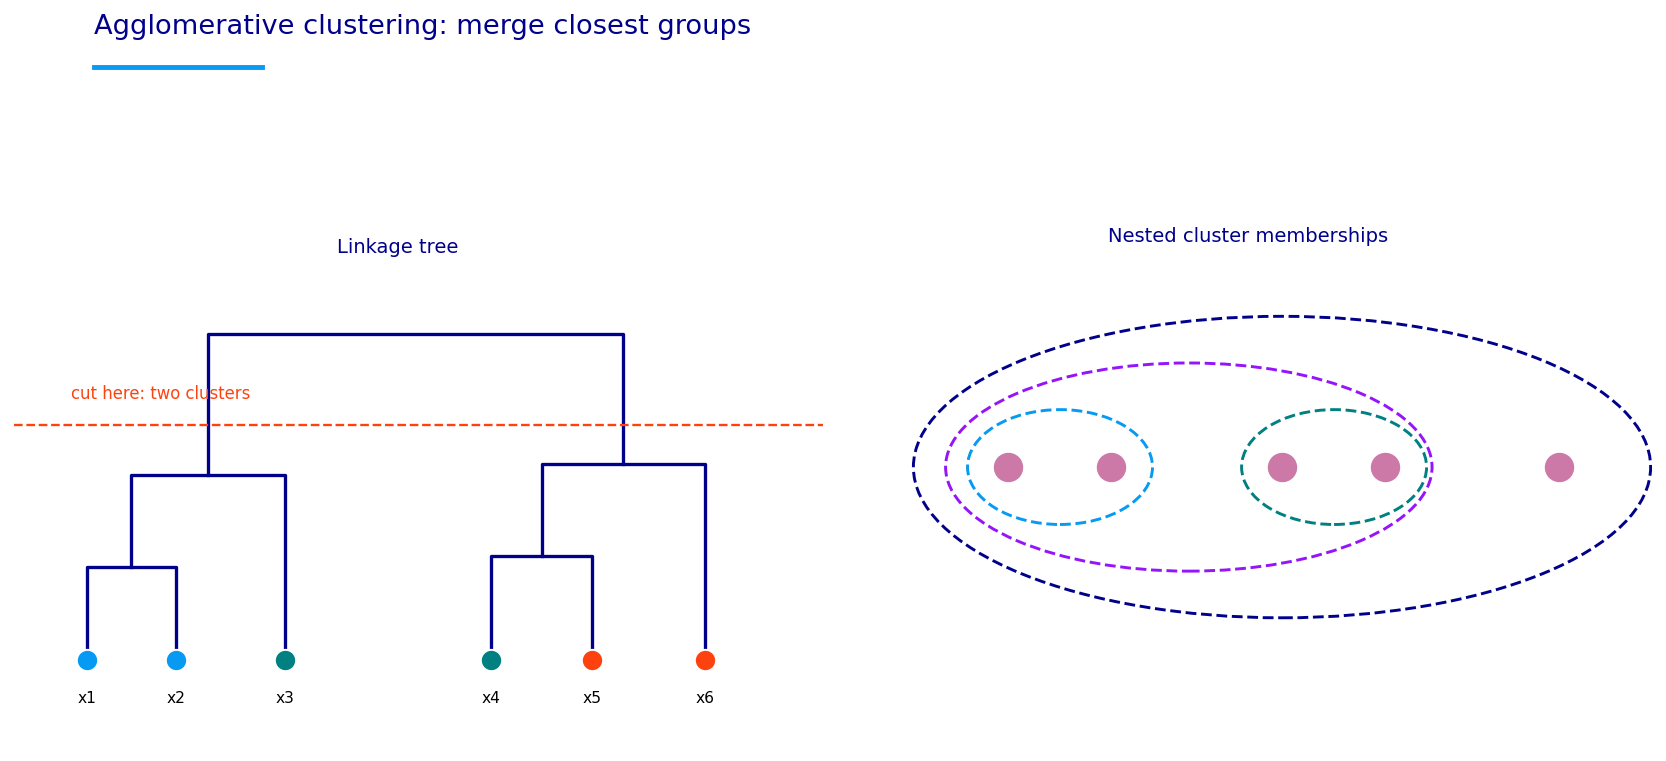

In [44]:
fig, axes = agglomerative_tree()
plt.show()

In [45]:
agg3 = AgglomerativeClustering(n_clusters=3, linkage="ward")
lab = pd.Series(agg3.fit_predict(z), index=z.index, name="state")
order = sort_profile_states(state_profile_local(x_raw, lab, future_for_quality))
lab = remap_series(lab, order).set_axis(z.index)
eco_outputs["Agglomerative 3"] = {"labels": lab, "proba": pd.get_dummies(lab).reindex(columns=range(3), fill_value=0.0)}
eco_rows.append(quality_row_local("Agglomerative 3", lab, x=z, outcomes=future_for_quality))

agg4 = AgglomerativeClustering(n_clusters=4, linkage="ward")
lab = pd.Series(agg4.fit_predict(z), index=z.index, name="state")
order = sort_profile_states(state_profile_local(x_raw, lab, future_for_quality))
lab = remap_series(lab, order).set_axis(z.index)
eco_outputs["Agglomerative 4"] = {"labels": lab, "proba": pd.get_dummies(lab).reindex(columns=range(4), fill_value=0.0)}
eco_rows.append(quality_row_local("Agglomerative 4", lab, x=z, outcomes=future_for_quality))

### 6.3 Gaussian Mixture Models

KMeans assigns each observation to one nearest centroid. A Gaussian Mixture Model (GMM) is more flexible. It assumes the feature distribution is a weighted sum of Gaussian components:

$$
p(X_t) = \sum_{k=1}^{K}\pi_k \mathcal{N}(X_t \mid \mu_k, \Sigma_k)
$$

where:

- $\pi_k$ is the mixture weight for component $k$,
- $\mu_k$ is the component mean,
- $\Sigma_k$ is the covariance matrix,
- $\sum_{k=1}^{K}\pi_k = 1$.

The important output is the **responsibility**:

$$
\gamma_{t,k} = P(S_t=k \mid X_t) = \frac{\pi_k \mathcal{N}(X_t \mid \mu_k,\Sigma_k)}{\sum_{\ell=1}^{K}\pi_\ell \mathcal{N}(X_t \mid \mu_\ell,\Sigma_\ell)}
$$

This is a soft membership probability. Instead of saying "today is exactly state 1," the model can say today's feature vector is 70% close to risk-on, 20% close to neutral, and 10% close to defensive.

GMM parameters are usually estimated by expectation-maximization (EM). The EM logic is:

1. **E-step**: compute responsibilities $\gamma_{t,k}$ using current parameters.
2. **M-step**: update $\pi_k$, $\mu_k$, and $\Sigma_k$ using those responsibilities.

The weighted mean update is:

$$
\mu_k = \frac{\sum_{t=1}^{T}\gamma_{t,k}X_t}{\sum_{t=1}^{T}\gamma_{t,k}}
$$

The covariance update is:

$$
\Sigma_k = \frac{\sum_{t=1}^{T}\gamma_{t,k}(X_t-\mu_k)(X_t-\mu_k)^\top}{\sum_{t=1}^{T}\gamma_{t,k}}
$$

The mixture plot shows why this is more realistic than KMeans. The component ellipses can overlap. Financial states often overlap because the transition from expansion to stress is gradual. GMM captures that uncertainty with probabilities.


A Gaussian mixture model adds probability to clustering. Instead of saying each date belongs entirely to one cluster, it says each date has a probability of coming from each component:

$$
p(X_t) = \sum_{k=1}^{K}\pi_k \mathcal{N}(X_t \mid \mu_k,\Sigma_k)
$$

where:

- $\pi_k$ is the mixture weight of state $k$,
- $\mu_k$ is the mean feature vector of state $k$,
- $\Sigma_k$ is the covariance matrix of state $k$,
- $\mathcal{N}(X_t \mid \mu_k,\Sigma_k)$ is the Gaussian density for that state.

The posterior probability of state $k$ is:

$$
P(S_t=k \mid X_t) = \frac{\pi_k \mathcal{N}(X_t \mid \mu_k,\Sigma_k)}{\sum_{\ell=1}^{K}\pi_\ell \mathcal{N}(X_t \mid \mu_\ell,\Sigma_\ell)}
$$

This soft assignment is more useful for portfolios than KMeans hard labels. If a date is 55% risk-on and 45% neutral, the allocation can be blended. It doesn't need to jump fully from one sleeve to another.

The diagonal covariance choice is conservative. A full covariance matrix for state $k$ has $p(p+1)/2$ parameters, where $p$ is the number of features. With many correlated features and a limited number of stress observations, that can overfit badly. A diagonal covariance only estimates one variance per feature inside each state:

$$
\Sigma_k = \operatorname{diag}(\sigma_{k,1}^2,\dots,\sigma_{k,p}^2)
$$

This assumes conditional independence across features within each state. That assumption isn't literally true in markets, but it can be a good regularization choice. It lets each state have different feature volatility without trying to estimate every cross-feature covariance.

The Bayesian mixture goes one step further by making component weights uncertain. A Dirichlet prior gives the model a way to shrink unused components:

$$
\pi \sim \operatorname{Dirichlet}(\alpha_1,\dots,\alpha_K)
$$

If the data doesn't support a component, its posterior weight can become small. This is useful because we often don't know the right number of regimes. Financial markets may have two dominant regimes in one era, four in another, and several small transition states around crises. A Bayesian mixture can start with more possible components and let weak ones fade.


The main implementation uses diagonal covariance for the GMM variants. A diagonal covariance means each state has its own variance per feature, but it doesn't estimate all feature-to-feature covariance inside each component:

$$
\Sigma_k = \operatorname{diag}(\sigma_{k,1}^2,\dots,\sigma_{k,p}^2)
$$

This is a practical design choice. With many correlated features and limited regime history, a full covariance GMM can overfit badly. Diagonal covariance sacrifices some flexibility but makes the density estimate more stable.


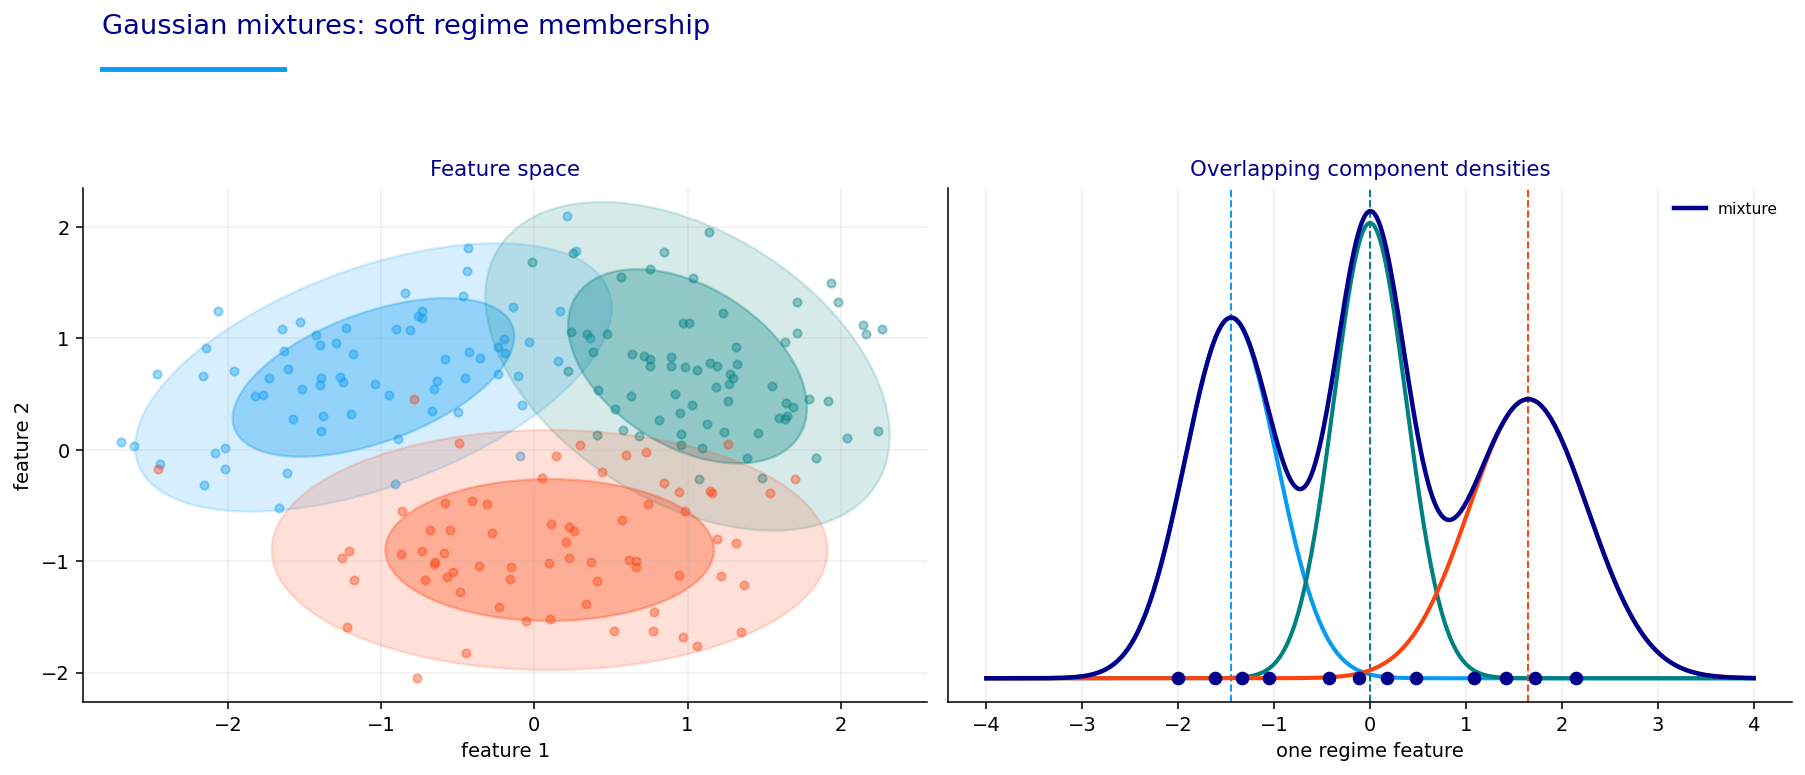

In [46]:
fig, axes = gmm_mixture()
plt.show()

In [47]:
gmm3 = GaussianMixture(n_components=3, covariance_type="diag", n_init=10, random_state=42, reg_covar=1e-5)
lab = pd.Series(gmm3.fit_predict(z), index=z.index, name="state")
proba = pd.DataFrame(gmm3.predict_proba(z), index=z.index)
order = sort_profile_states(state_profile_local(x_raw, lab, future_for_quality))
lab = remap_series(lab, order).set_axis(z.index)
proba = proba[order].set_axis(range(3), axis=1)
eco_outputs["GMM 3 diag"] = {"labels": lab, "proba": proba}
eco_rows.append(quality_row_local("GMM 3 diag", lab, x=z, proba=proba, outcomes=future_for_quality, loglike=gmm3.score(z) * len(z), aic=gmm3.aic(z), bic=gmm3.bic(z)))

gmm4 = GaussianMixture(n_components=4, covariance_type="diag", n_init=10, random_state=42, reg_covar=1e-5)
lab = pd.Series(gmm4.fit_predict(z), index=z.index, name="state")
proba = pd.DataFrame(gmm4.predict_proba(z), index=z.index)
order = sort_profile_states(state_profile_local(x_raw, lab, future_for_quality))
lab = remap_series(lab, order).set_axis(z.index)
proba = proba[order].set_axis(range(4), axis=1)
eco_outputs["GMM 4 diag"] = {"labels": lab, "proba": proba}
eco_rows.append(quality_row_local("GMM 4 diag", lab, x=z, proba=proba, outcomes=future_for_quality, loglike=gmm4.score(z) * len(z), aic=gmm4.aic(z), bic=gmm4.bic(z)))

### 6.4 Bayesian Gaussian Mixture

The Bayesian Gaussian mixture adds a prior over component weights. In we, we start with an upper bound of six candidate components, but the prior lets weak components shrink away. This is useful when we don't know the right number of states.

A standard mixture weight vector is:

$$
\pi = \begin{bmatrix}\pi_1 & \pi_2 & \cdots & \pi_K\end{bmatrix}
$$

with $\pi_k \ge 0$ and $\sum_k \pi_k=1$. In a Bayesian mixture, we put a prior on $\pi$. A common choice is a Dirichlet prior:

$$
\pi \sim \operatorname{Dirichlet}(\alpha_1,\dots,\alpha_K)
$$

If the prior concentration is small, the posterior can push unsupported components toward very low weights. In a Dirichlet-process-style mixture, this acts like "let the data decide how many components are active."

The teaching plot shows six possible component densities, but only the supported components remain meaningfully weighted. This is helpful because market data may have a dominant risk-on regime, a neutral regime, a stress regime, and maybe a few smaller transition states. We don't want to force every candidate component to matter.


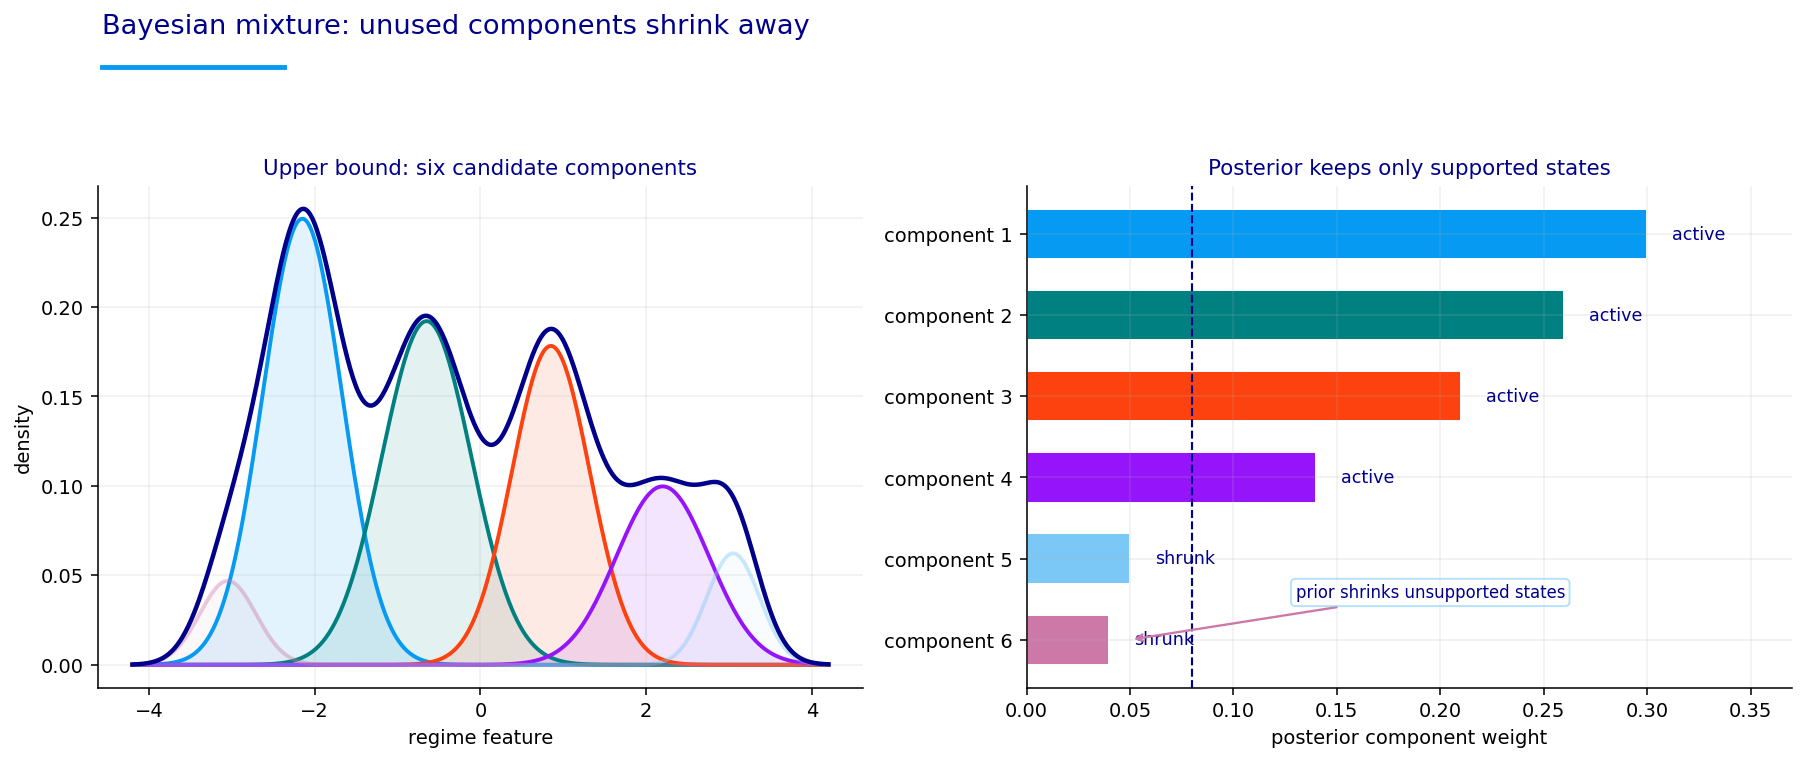

In [48]:
fig, ax = bayesian_mixture()
plt.show()

In [49]:
bgmm = BayesianGaussianMixture(
    n_components=6,
    covariance_type="diag",
    random_state=42,
    max_iter=500,
    weight_concentration_prior_type="dirichlet_process",
    weight_concentration_prior=0.25,
)
lab = pd.Series(bgmm.fit_predict(z), index=z.index, name="state")
active_states = sorted(lab.value_counts().loc[lambda s: s > 20].index.tolist())
lab = lab.where(lab.isin(active_states), lab.mode().iloc[0])
proba = pd.DataFrame(bgmm.predict_proba(z), index=z.index).reindex(columns=active_states, fill_value=0.0)
order = sort_profile_states(state_profile_local(x_raw, lab, future_for_quality))
lab = remap_series(lab, order).set_axis(z.index)
proba = proba[order].set_axis(range(len(order)), axis=1)
eco_outputs["Bayesian GMM"] = {"labels": lab, "proba": proba}
eco_rows.append(quality_row_local("Bayesian GMM", lab, x=z, proba=proba, outcomes=future_for_quality, loglike=bgmm.score(z) * len(z)))
display(pd.Series(bgmm.weights_, name="component_weight").round(4))

0    0.3174
1    0.2134
2    0.0138
3    0.1479
4    0.0491
5    0.2582
Name: component_weight, dtype: float64

### 6.5 Regime Ordering and Economic Profiles

Unsupervised labels are arbitrary. If a KMeans model returns labels 0, 1, and 2, those numbers don't automatically mean risk-on, neutral, and defensive. The model only knows geometry. It doesn't know finance.

So after fitting, we build an economic profile for each discovered state. For state $k$, the profile is:

$$
\text{Profile}_k = E[Z_t \mid \hat{S}_t=k]
$$

for features, and:

$$
\text{OutcomeProfile}_k = E[R_{t,t+h}^{\text{future}} \mid \hat{S}_t=k]
$$

for future returns and sleeve spreads.

Then we order states by economic meaning. A state with high future risk-sleeve return and high risk-defensive spread becomes risk-on. A state with low future risky returns, better defensive returns, and negative spread becomes defensive. A state in the middle becomes neutral.

This step is crucial. Without economic ordering, a cluster label could flip between runs. The model could call risk-on "cluster 2" in one run and "cluster 0" in another. Portfolio rules need stable names, so we remap discovered states into a consistent economic order.

The profile table is also a guard against fake regimes. If two clusters have very similar future outcomes, they may be statistically separated but financially unimportant. A good regime isn't only a pretty cluster. It should correspond to different future asset behavior.


## 7) Markov Chains and State Persistence

The next step is the stochastic-process part of the project. A regime process is a sequence:

$$
S_1, S_2, \dots, S_T
$$

where each $S_t$ takes one of a small number of states, such as risk-on, neutral, or defensive.

A **Markov chain** assumes the next state depends on the current state, not the full past path:

$$
P(S_t=j \mid S_{t-1}=i, S_{t-2},\dots,S_1) = P(S_t=j \mid S_{t-1}=i)
$$

The transition probabilities are collected in a transition matrix $A$:

$$
A_{ij} = P(S_t=j \mid S_{t-1}=i)
$$

Each row sums to one:

$$
\sum_{j=1}^{K}A_{ij}=1
$$

For a 3-state regime model, $A$ might look like:

$$
A =
\begin{bmatrix}
0.82 & 0.12 & 0.06 \\
0.09 & 0.67 & 0.24 \\
0.07 & 0.17 & 0.76
\end{bmatrix}
$$

The diagonal entries are persistence probabilities. If $A_{00}=0.82$, then a risk-on day has an 82% probability of being followed by another risk-on day. The expected duration of state $i$ is:

$$
E[D_i] = \frac{1}{1-A_{ii}}
$$

So if a state has a self-transition probability of 0.82, its expected duration is about:

$$
E[D] = \frac{1}{1-0.82} \approx 5.56
$$

observations, under the geometric-duration assumption. If the self-transition probability is 0.98, the expected duration becomes 50 observations. This is why small changes in diagonal probabilities can create much smoother regime paths.


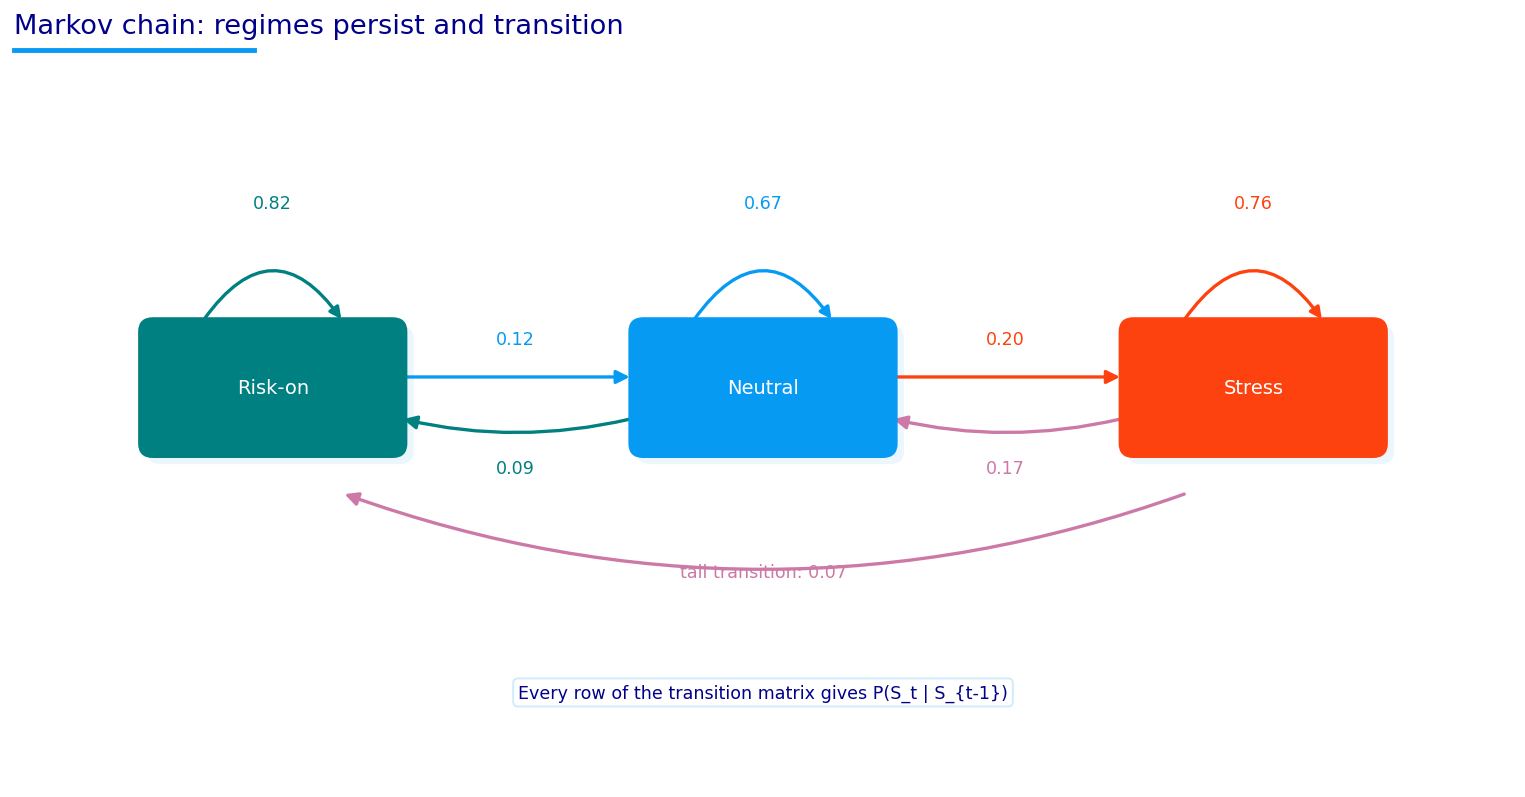

In [50]:
fig, ax = markov_chain()
plt.show()

The Markov chain diagram in we is a teaching simplification. It shows risk-on, neutral, and stress states with self-transition probabilities and cross-transition probabilities. The point is that regimes usually persist. A stress state doesn't usually appear for one isolated day and vanish forever. A risk-on trend can persist for months. A neutral state can act as a transition zone.

We can update a state distribution forward through time using:

$$
p_t = p_{t-1}A
$$

where $p_t$ is a row vector of state probabilities. If today's distribution is $p_t = [0.70, 0.20, 0.10]$, and $A$ has strong diagonal probabilities, tomorrow's distribution will still be mostly risk-on unless the observed features provide strong contrary evidence.

This persistence is financially useful because it reduces whipsaw. A clustering model can flip states whenever the feature vector crosses a boundary. A Markov model adds inertia. It says the market can change regimes, but the prior probability of staying in the same state is usually high.


A Markov chain is the first true stochastic-process model in the project. It models a sequence of states:

$$
S_1,S_2,\dots,S_T
$$

where each $S_t$ belongs to a finite state space such as:

$$
S_t \in \{0,1,2\} = \{\text{risk-on},\text{neutral},\text{defensive}\}
$$

The Markov assumption says the next state depends on the current state, not the entire past path:

$$
P(S_{t+1}=j \mid S_t=i,S_{t-1},S_{t-2},\dots) = P(S_{t+1}=j \mid S_t=i)
$$

This is a simplification, but it is extremely useful. It turns regime persistence into a transition matrix:

$$
A =
\begin{bmatrix}
P(0\to 0) & P(0\to 1) & P(0\to 2) \\
P(1\to 0) & P(1\to 1) & P(1\to 2) \\
P(2\to 0) & P(2\to 1) & P(2\to 2)
\end{bmatrix}
$$

Each row sums to one:

$$
\sum_{j=1}^{K}A_{ij}=1
$$

The diagonal entries are persistence probabilities. If $A_{00}=0.95$, a risk-on state tends to remain risk-on. If $A_{22}=0.80$, defensive states also persist, but less strongly. Off-diagonal entries describe transitions. For example, $A_{02}$ is the probability of jumping from risk-on directly to defensive.

A state distribution evolves by multiplication:

$$
p_{t+1} = p_t A
$$

If today's probability vector is $p_t=[0.70,0.20,0.10]$, then tomorrow's prior state distribution is the weighted average of the transition rows. This is the "state inertia" that clustering lacks.

The $n$-step transition matrix is:

$$
A^n = \underbrace{A A \cdots A}_{n\text{ times}}
$$

The entry $(A^n)_{ij}$ gives the probability of being in state $j$ after $n$ steps if we start in state $i$. This is useful for thinking about multi-month regimes. If the strategy rebalances monthly, we caren't only about tomorrow's state but whether a state is likely to persist long enough to justify a portfolio tilt.

The expected duration of state $i$ is approximately:

$$
E[D_i] = \frac{1}{1-A_{ii}}
$$

If $A_{ii}=0.90$, expected duration is about 10 periods. If $A_{ii}=0.50$, expected duration is only 2 periods. This formula comes from the geometric distribution: if the probability of leaving the state each period is $1-A_{ii}$, the expected waiting time before leaving is the inverse of that exit probability.

This duration formula is one of the cleanest links between stochastic-process math and trading. A model with very low state duration creates high turnover and unstable allocations. A model with very high duration may fail to adapt. The transition matrix lets us quantify that tradeoff rather than describe it vaguely.


### 7.1 Markov Regression

The Markov regression model in this project is a regime-switching time-series model applied to the global equal-weight return series. Instead of clustering a multivariate feature vector, it models a univariate return process whose mean and variance can switch by regime.

A simple Markov-switching regression can be written as:

$$
y_t = \mu_{S_t} + \varepsilon_t
$$

with:

$$
\varepsilon_t \mid S_t=k \sim \mathcal{N}(0,\sigma_k^2)
$$

Here:

- $y_t$ is the observed return,
- $S_t$ is the hidden regime,
- $\mu_{S_t}$ is the regime-specific mean,
- $\sigma_{S_t}^2$ is the regime-specific variance,
- $S_t$ follows a Markov chain.

The likelihood must sum over unobserved state paths. Directly summing over all possible paths would be impossible for long time series because there are $K^T$ possible state sequences. Instead, the Hamilton filter updates state probabilities recursively.

The filtered probability is:

$$
P(S_t=k \mid y_1,\dots,y_t)
$$

It combines two pieces:

1. the predicted probability from yesterday's state distribution and the transition matrix,
2. the likelihood of today's return under each regime.

For a regime with low volatility and positive mean, a calm positive return gets high likelihood. For a high-volatility stress regime, a large negative return gets higher likelihood. The filter updates the posterior regime probabilities accordingly.

The MarkovRegression output has strong likelihood diagnostics because it is directly a time-series likelihood model, but its economic separation in the main table isn't the highest. That makes sense. It sees one return series, while the feature-based models see macro, credit, rates, commodities, and internal market structure.


The transition matrix gives several diagnostics that are useful beyond the basic state plot.

**Stationary distribution.** If a Markov chain is stable and ergodic, it has a long-run distribution $\pi$ satisfying:

$$
\pi = \pi A
$$

with:

$$
\sum_{k=1}^{K}\pi_k = 1
$$

This means that if we keep applying the transition matrix for a very long time, the state distribution tends toward $\pi$ regardless of the starting state. In finance, the stationary distribution can be interpreted as the model's long-run regime mix. If $\pi_{\text{risk-on}}$ is very high, the model believes risk-on is the dominant long-run environment. If $\pi_{\text{defensive}}$ is too small, the model may underrepresent crises.

A stationary distribution isn't a forecast that the future must match the historical regime mix. It is a diagnostic of the fitted transition structure. If the stationary distribution says the defensive state is basically impossible, but the realized sample contains meaningful stress periods, the transition model may be too optimistic.

**Expected duration.** The formula:

$$
E[D_i]=\frac{1}{1-A_{ii}}
$$

turns transition probabilities into a trading concept. If the state is expected to last only a few days, monthly allocation won't benefit much from detecting it. If the state lasts several months, it can support a regime sleeve.

For example, if a defensive state has $A_{22}=0.96$, then:

$$
E[D_2]=\frac{1}{1-0.96}=25
$$

If the time unit is daily observations, this is roughly one trading month. If the model is fit on monthly observations, the same number would mean 25 months, which would be far too persistent. So duration must always be interpreted together with the observation frequency.

**Transition asymmetry.** Market regimes are often asymmetric. Risk-on may drift slowly into neutral before turning defensive. Defensive states may recover quickly after policy support or liquidity intervention. This asymmetry appears in off-diagonal transition probabilities:

$$
A_{\text{risk-on},\text{neutral}},\quad A_{\text{neutral},\text{defensive}},\quad A_{\text{defensive},\text{risk-on}}
$$

A chain with high $A_{\text{risk-on},\text{defensive}}$ allows direct crash transitions. A chain with low direct transition but high risk-on-to-neutral and neutral-to-defensive movement implies deterioration tends to pass through a transition state.

For portfolio construction, the transition path matters. If the model often moves through neutral before defensive, the portfolio can gradually reduce risk. If direct risk-on-to-defensive transitions are common, the strategy needs faster risk controls.

**Regime entropy.** A Markov or HMM probability vector can be summarized by entropy:

$$
H(p_t)=-\frac{\sum_{k=1}^{K}p_{t,k}\log p_{t,k}}{\log K}
$$

Entropy is close to 0 when one state dominates and close to 1 when probabilities are spread evenly. This becomes a risk-control input later because uncertain probabilities shouldn't create extreme allocations. A confident 80% defensive probability and a mixed 35/35/30 probability have different portfolio meanings even if defensive is the largest class in both.

This is why Markov models fit portfolio work so naturally. They produce probabilities, persistence, duration, transition risk, and uncertainty. Those are exactly the objects a portfolio layer can use.


A small numerical Markov example makes the persistence idea concrete. Suppose the transition matrix is:

$$
A =
\begin{bmatrix}
0.92 & 0.07 & 0.01 \\
0.20 & 0.65 & 0.15 \\
0.05 & 0.20 & 0.75
\end{bmatrix}
$$

The first row says a risk-on state stays risk-on with 92% probability, moves to neutral with 7%, and jumps directly to defensive with 1%. The third row says a defensive state stays defensive with 75%, recovers to neutral with 20%, and jumps back to risk-on with 5%.

If today's state distribution is:

$$
p_t = \begin{bmatrix}0.80 & 0.15 & 0.05\end{bmatrix}
$$

then tomorrow's prior state distribution before seeing new features is:

$$
p_{t+1}=p_tA
$$

Multiplying the vector by the matrix gives:

$$
p_{t+1} =
\begin{bmatrix}
0.80(0.92)+0.15(0.20)+0.05(0.05) &
0.80(0.07)+0.15(0.65)+0.05(0.20) &
0.80(0.01)+0.15(0.15)+0.05(0.75)
\end{bmatrix}
$$

So:

$$
p_{t+1} \approx \begin{bmatrix}0.7685 & 0.1635 & 0.0680\end{bmatrix}
$$

Even before observing tomorrow's features, the model is still mostly risk-on because the transition matrix has persistence. But defensive probability rises slightly from 5% to 6.8% because there is some chance of deterioration through neutral or direct transition.

Now suppose tomorrow's features show a strong volatility shock and weak credit. The HMM emission likelihood for the defensive state rises, and the filtering update can move the defensive probability much more. The transition matrix gives inertia, while the emission likelihood gives evidence. The final probability is the balance between both.

This is the whole appeal of Markov regime modeling in finance. We don't want the model to forget yesterday's regime instantly, and we don't want it to ignore today's new stress evidence either.


In [51]:
global_ew_ret = returns[assets].mean(axis=1).reindex(z.index).dropna() * 100.0
try:
    mr3 = MarkovRegression(global_ew_ret, k_regimes=3, trend="c", switching_variance=True)
    mr3_res = mr3.fit(search_reps=12, em_iter=8, maxiter=120, disp=False)
    p = mr3_res.smoothed_marginal_probabilities
    proba = pd.DataFrame(np.asarray(p), index=global_ew_ret.index)
    lab = proba.idxmax(axis=1).astype(int)
    order = sort_profile_states(state_profile_local(x_raw.reindex(lab.index), lab, future_for_quality.reindex(lab.index)))
    lab = remap_series(lab, order).set_axis(lab.index)
    proba = proba[order].set_axis(range(len(order)), axis=1)
    eco_outputs["MarkovRegression 3"] = {"labels": lab, "proba": proba}
    eco_rows.append(quality_row_local("MarkovRegression 3", lab, x=z.reindex(lab.index), proba=proba, outcomes=future_for_quality, loglike=mr3_res.llf, aic=mr3_res.aic, bic=mr3_res.bic))
except Exception as exc:
    print("MarkovRegression skipped:", exc)

## 8) Hidden Markov Models

A Hidden Markov Model (HMM) combines two ideas:

1. A hidden state process $S_t$ follows a Markov chain.
2. The observed feature vector $X_t$ is generated from a state-specific distribution.

The model is:

$$
P(S_t=j \mid S_{t-1}=i) = A_{ij}
$$

and:

$$
X_t \mid S_t=k \sim p_k(X_t)
$$

For a Gaussian HMM, the emission density is:

$$
p_k(X_t) = \mathcal{N}(X_t \mid \mu_k, \Sigma_k)
$$

With diagonal covariance:

$$
p_k(X_t) = \prod_{m=1}^{p} \frac{1}{\sqrt{2\pi\sigma_{k,m}^2}}\exp\left(-\frac{(x_{t,m}-\mu_{k,m})^2}{2\sigma_{k,m}^2}\right)
$$

This means each hidden state has its own average feature profile and feature volatility. A risk-on state might have high breadth, positive credit momentum, lower volatility pressure, and positive equity leadership. A defensive state might have negative breadth, higher drawdown, high volatility shock, stronger GLD/TLT behavior, and worse risk-defensive forward outcomes.

The joint probability of states and observations is:

$$
P(S_{1:T},X_{1:T}) = \pi_{S_1}p_{S_1}(X_1)\prod_{t=2}^{T} A_{S_{t-1},S_t}p_{S_t}(X_t)
$$

where $\pi_{S_1}$ is the initial state probability.

This equation is the full HMM story in one line. The state path has Markov persistence, and each state emits observations according to its own feature distribution.


### 8.1 Filtering, Smoothing, and State Probabilities

The HMM doesn't observe $S_t$ directly. It infers probabilities. The forward recursion computes:

$$
\alpha_t(j) = P(X_1,\dots,X_t, S_t=j)
$$

The update is:

$$
\alpha_t(j) = p_j(X_t)\sum_{i=1}^{K}\alpha_{t-1}(i)A_{ij}
$$

Each part has a clear role:

- $\alpha_{t-1}(i)$ is yesterday's joint probability of being in state $i$.
- $A_{ij}$ moves probability from state $i$ to state $j$.
- $p_j(X_t)$ checks whether today's features look likely under state $j$.

For numerical stability, the probabilities are normalized at each step. The normalized version gives filtered probabilities:

$$
P(S_t=j \mid X_1,\dots,X_t)
$$

Smoothing uses the full sample:

$$
P(S_t=j \mid X_1,\dots,X_T)
$$

Filtering is closer to real-time use. Smoothing is helpful for diagnostics because it uses future observations to classify historical states more cleanly. In backtesting, we need walk-forward probabilities, so the model is refit through time and probabilities are produced using information available up to the decision date.

The HMM teaching diagram shows hidden states at the top and observed features at the bottom. The state sequence transitions through time, and each state emits feature observations. This is exactly the right structure for markets: the regime is latent, but returns, volatility, credit, rates, and macro conditions are observable emissions of that latent regime.


A Hidden Markov Model adds one more layer: the regime state isn't directly observed. We only observe market features. The state is hidden, and the model infers it from the feature sequence.

The HMM has two equations:

$$
S_t \mid S_{t-1} \sim \text{Categorical}(A_{S_{t-1},:})
$$

and:

$$
X_t \mid S_t=k \sim \mathcal{N}(\mu_k,\Sigma_k)
$$

The first equation is the **transition model**. It says how hidden regimes move through time. The second equation is the **emission model**. It says what feature vectors we expect to observe inside each regime.

The joint probability of a full state path and observation sequence is:

$$
P(S_{1:T},X_{1:T}) = P(S_1)\prod_{t=2}^{T}P(S_t\mid S_{t-1})\prod_{t=1}^{T}P(X_t\mid S_t)
$$

This formula is the backbone of the model. It combines persistence from the transition matrix with feature evidence from the emission densities.

There are three probability objects that matter:

**Filtering** estimates the current state using observations up to today:

$$
\alpha_t(k) = P(S_t=k \mid X_{1:t})
$$

This is what a real-time strategy can use. At date $t$, we only know $X_{1:t}$.

**Smoothing** estimates the state using the full sample:

$$
\gamma_t(k) = P(S_t=k \mid X_{1:T})
$$

This is useful for diagnosis because it uses future observations to better infer what historical states probably were. It isn't a real-time trading probability.

**Prediction** projects the state distribution forward:

$$
P(S_{t+1}=j \mid X_{1:t}) = \sum_{i=1}^{K}P(S_t=i \mid X_{1:t})A_{ij}
$$

This is how the model carries state persistence into the future.

The forward recursion computes filtered probabilities. In unnormalized form:

$$
\tilde{\alpha}_t(j) = f_j(X_t)\sum_{i=1}^{K}\alpha_{t-1}(i)A_{ij}
$$

where $f_j(X_t)$ is the emission density of observation $X_t$ under state $j$. The probability is then normalized:

$$
\alpha_t(j)=\frac{\tilde{\alpha}_t(j)}{\sum_{\ell=1}^{K}\tilde{\alpha}_t(\ell)}
$$

This update has a clear intuition. A state gets high probability if:

- it was likely based on yesterday's state distribution and transition matrix,
- today's features look likely under that state's emission distribution.

For example, suppose the model was mostly risk-on yesterday. If today's features show low volatility, strong breadth, and healthy credit, the risk-on probability remains high. If today's features suddenly show volatility shock, credit stress, and falling breadth, the emission likelihood of the defensive state rises and the probability can shift.

The backward recursion computes future evidence:

$$
\beta_t(i) = P(X_{t+1:T}\mid S_t=i)
$$

Then smoothing combines forward and backward information:

$$
\gamma_t(i)=P(S_t=i\mid X_{1:T})=\frac{\alpha_t(i)\beta_t(i)}{\sum_{j=1}^{K}\alpha_t(j)\beta_t(j)}
$$

This is useful for analyzing historical plots. Smoothed probabilities usually look cleaner than filtered probabilities because they know what happened afterward. But for live portfolio construction, filtered or walk-forward probabilities are the honest object.


The HMM filtering update can also be understood with a simple probability example. Suppose the prior state probability after applying the transition matrix is:

$$
P(S_t=\text{risk-on})=0.70,\qquad P(S_t=\text{neutral})=0.20,\qquad P(S_t=\text{defensive})=0.10
$$

Now today's feature vector arrives. The emission densities say how likely today's features are under each state. Suppose the features are moderately stressful:

$$
f_{\text{risk-on}}(X_t)=0.20,\qquad f_{\text{neutral}}(X_t)=0.50,\qquad f_{\text{defensive}}(X_t)=0.80
$$

The unnormalized filtered probabilities multiply prior probability by feature likelihood:

$$
\tilde{p}_{\text{risk-on}}=0.70\cdot0.20=0.14
$$

$$
\tilde{p}_{\text{neutral}}=0.20\cdot0.50=0.10
$$

$$
\tilde{p}_{\text{defensive}}=0.10\cdot0.80=0.08
$$

Then we normalize:

$$
p_{\text{risk-on}}=\frac{0.14}{0.14+0.10+0.08}=0.4375
$$

$$
p_{\text{neutral}}=\frac{0.10}{0.32}=0.3125
$$

$$
p_{\text{defensive}}=\frac{0.08}{0.32}=0.2500
$$

The result is still not fully defensive because the prior was heavily risk-on. But defensive probability rises from 10% to 25% because today's features look more defensive than risk-on. That is the filtering logic.

This example also explains why HMM probabilities often move smoothly. The model needs enough evidence to overcome the transition prior. A single noisy feature movement may not flip the state. A persistent sequence of stressful observations can.


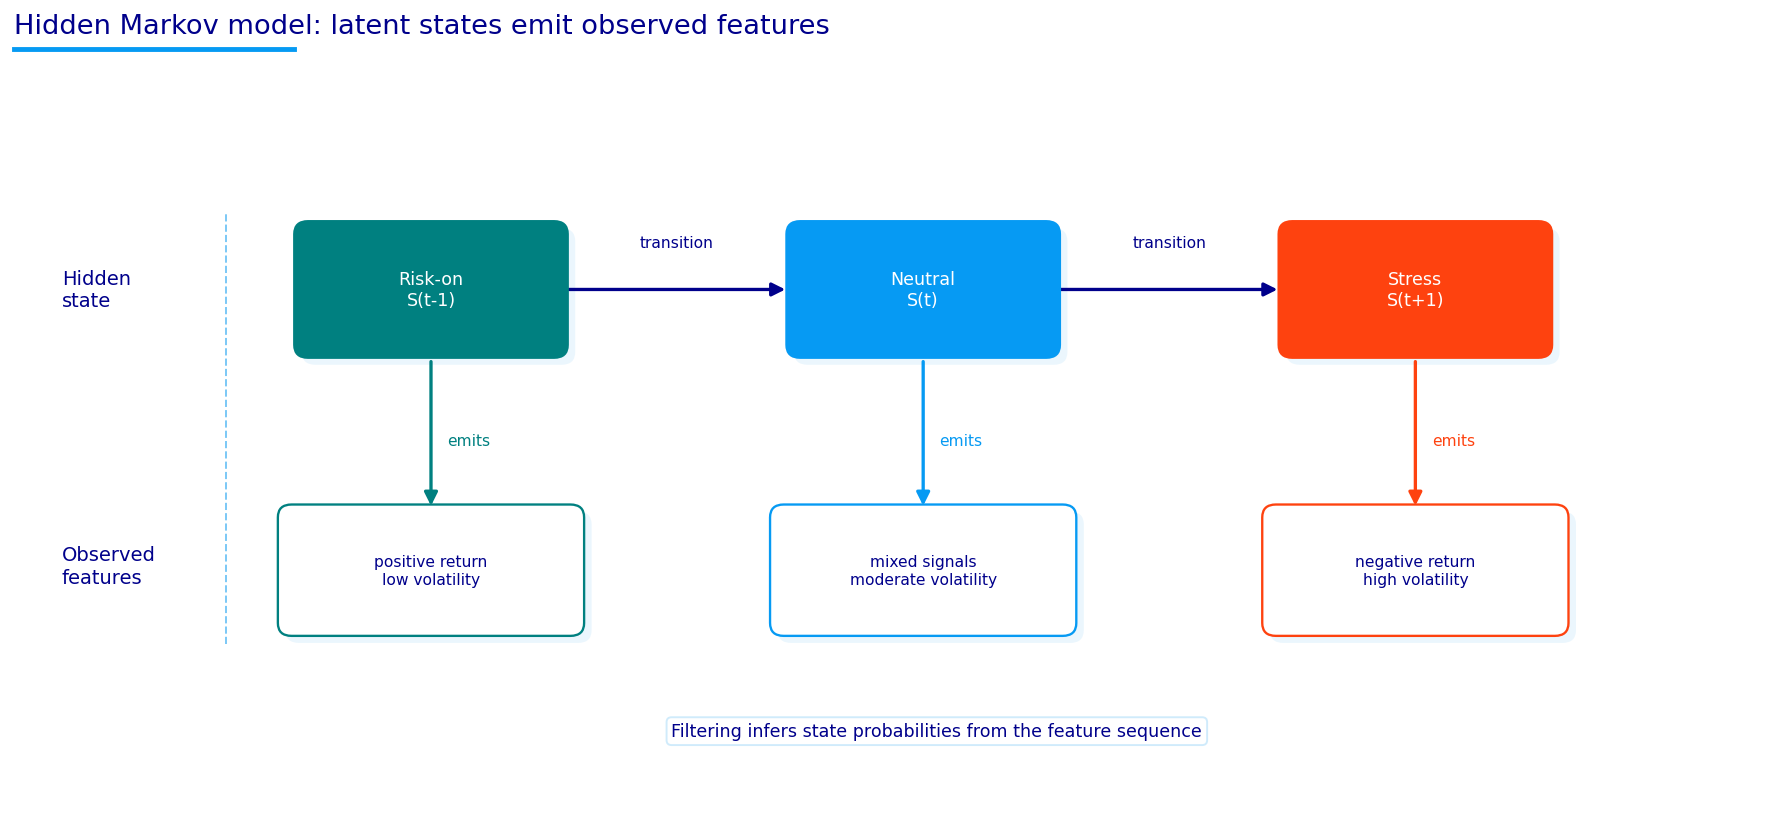

In [52]:
fig, ax = hidden_markov_model()
plt.show()

### 8.2 HMM Training with EM

The HMM parameters are usually estimated by an EM algorithm called **Baum-Welch**. The observed data are $X_{1:T}$, but the state path $S_{1:T}$ is hidden. EM handles this by alternating between estimating state probabilities and updating parameters.

The E-step computes smoothed state probabilities:

$$
\gamma_t(k) = P(S_t=k \mid X_{1:T})
$$

and transition probabilities:

$$
\xi_t(i,j) = P(S_t=i, S_{t+1}=j \mid X_{1:T})
$$

The M-step updates the transition matrix:

$$
A_{ij} = \frac{\sum_{t=1}^{T-1}\xi_t(i,j)}{\sum_{t=1}^{T-1}\gamma_t(i)}
$$

The Gaussian emission mean is updated as:

$$
\mu_k = \frac{\sum_{t=1}^{T}\gamma_t(k)X_t}{\sum_{t=1}^{T}\gamma_t(k)}
$$

and the diagonal variance for feature $m$ is:

$$
\sigma_{k,m}^2 = \frac{\sum_{t=1}^{T}\gamma_t(k)(x_{t,m}-\mu_{k,m})^2}{\sum_{t=1}^{T}\gamma_t(k)}
$$

This is very similar to the GMM EM update, but with one important addition: transition probabilities $\xi_t(i,j)$. GMM treats observations as independent. HMM treats observations as a sequence.

That difference is the main reason HMMs are so natural for market regimes. The current state isn't only determined by today's feature vector. It also depends on where the market probably was yesterday.


The Baum-Welch EM algorithm is important enough to unpack slowly. The difficulty is that we don't observe $S_t$. If we did observe the state path, estimating parameters would be easy. We would count transitions to estimate $A$, and compute the mean/variance of features inside each state to estimate $\mu_k$ and $\Sigma_k$.

Because the states are hidden, EM replaces hard counts with probability-weighted counts.

The E-step computes:

$$
\gamma_t(k)=P(S_t=k\mid X_{1:T})
$$

and:

$$
\xi_t(i,j)=P(S_t=i,S_{t+1}=j\mid X_{1:T})
$$

Here $\gamma_t(k)$ is the probability that date $t$ belongs to state $k$. $\xi_t(i,j)$ is the probability that the model moved from state $i$ to state $j$ between $t$ and $t+1$.

The transition update is:

$$
A_{ij} = \frac{\sum_{t=1}^{T-1}\xi_t(i,j)}{\sum_{t=1}^{T-1}\gamma_t(i)}
$$

The numerator is the expected number of transitions from $i$ to $j$. The denominator is the expected number of times we were in state $i$ before a transition. So $A_{ij}$ is an expected transition frequency.

The emission mean update is:

$$
\mu_k = \frac{\sum_{t=1}^{T}\gamma_t(k)X_t}{\sum_{t=1}^{T}\gamma_t(k)}
$$

This is a weighted average of feature vectors. Dates that strongly belong to state $k$ get high weight. Dates that barely belong to state $k$ get low weight.

For diagonal covariance, the variance of feature $m$ in state $k$ is:

$$
\sigma_{k,m}^2 = \frac{\sum_{t=1}^{T}\gamma_t(k)(x_{t,m}-\mu_{k,m})^2}{\sum_{t=1}^{T}\gamma_t(k)}
$$

So the model learns not only the average feature level in each regime but also the typical variability of each feature inside that regime.

This is exactly why HMMs are more appropriate than static clustering for market regimes. A GMM estimates similar emission distributions, but it treats observations as independent. The HMM adds the transition matrix, so a state assignment is shaped by both today's feature vector and yesterday's inferred state. That is the econometric structure we want for markets.


In [53]:
if hmm_available:
    for n_states in [3, 4]:
        hmm = GaussianHMM(
            n_components=n_states,
            covariance_type="diag",
            n_iter=120,
            random_state=42,
            min_covar=1e-4,
        )
        hmm.fit(z.to_numpy(dtype=float))
        raw = hmm.predict(z.to_numpy(dtype=float))
        proba = pd.DataFrame(hmm.predict_proba(z.to_numpy(dtype=float)), index=z.index)
        lab = pd.Series(raw, index=z.index, name="state")
        order = sort_profile_states(state_profile_local(x_raw, lab, future_for_quality))
        lab = remap_series(lab, order).set_axis(z.index)
        proba = proba[order].set_axis(range(n_states), axis=1)
        ll = hmm.score(z.to_numpy(dtype=float))
        k = (n_states - 1) + n_states * (n_states - 1) + 2 * n_states * z.shape[1]
        eco_outputs[f"HMM {n_states}"] = {"labels": lab, "proba": proba}
        eco_rows.append(quality_row_local(f"HMM {n_states}", lab, x=z, proba=proba, outcomes=future_for_quality, loglike=ll, aic=-2 * ll + 2 * k, bic=-2 * ll + k * np.log(len(z))))
else:
    print("hmmlearn is unavailable")

### 8.3 PCA-HMM

PCA-HMM first compresses the selected feature matrix into principal components, then fits an HMM on those components. This helps when features are correlated and high-dimensional.

If $Z_t$ is the standardized feature vector and $V_m$ contains the first $m$ PCA loadings, then the compressed vector is:

$$
F_t = V_m^\top Z_t
$$

The HMM is then fit on $F_t$ instead of $Z_t$.

The advantage is that PCA removes redundant directions. Instead of fitting emissions on many correlated features, the HMM sees a smaller set of orthogonal factors. The downside is interpretability. A hidden state defined by PCs is less directly tied to original macro and market features.


In [54]:
if hmm_available:
    pca_n = min(5, z.shape[1])
    pca_hmm_scaler = PCA(n_components=pca_n, random_state=42)
    z_pca = pd.DataFrame(pca_hmm_scaler.fit_transform(z), index=z.index, columns=[f"PC{i+1}" for i in range(pca_n)])
    pca_hmm = GaussianHMM(
        n_components=len(regime_names),
        covariance_type="diag",
        n_iter=150,
        random_state=7,
        min_covar=1e-4,
    )
    pca_hmm.fit(z_pca.to_numpy(dtype=float))
    raw = pca_hmm.predict(z_pca.to_numpy(dtype=float))
    proba = pd.DataFrame(pca_hmm.predict_proba(z_pca.to_numpy(dtype=float)), index=z.index)
    lab = pd.Series(raw, index=z.index, name="state")
    order = sort_profile_states(state_profile_local(x_raw, lab, future_for_quality))
    lab = remap_series(lab, order).set_axis(z.index)
    proba = proba[order].set_axis(range(len(regime_names)), axis=1)
    ll = pca_hmm.score(z_pca.to_numpy(dtype=float))
    k = (len(regime_names) - 1) + len(regime_names) * (len(regime_names) - 1) + 2 * len(regime_names) * pca_n
    eco_outputs["PCA-HMM 3"] = {"labels": lab, "proba": proba}
    eco_rows.append(quality_row_local("PCA-HMM 3", lab, x=z_pca, proba=proba, outcomes=future_for_quality, loglike=ll, aic=-2 * ll + 2 * k, bic=-2 * ll + k * np.log(len(z_pca))))

The HMM and the supervised classifier answer different questions, so their disagreement is useful.

The HMM estimates:

$$
P(S_t=k\mid X_{1:t})
$$

where $S_t$ is a latent state. It tries to explain the sequence of observed features through hidden regimes. It cares strongly about persistence because the transition matrix makes today's state depend on yesterday's state.

The supervised classifier estimates:

$$
P(Y_t=k\mid X_t)
$$

where $Y_t$ is a realized future regime label created from the 63-day risk-defensive spread. It tries to predict forward outcomes directly from the current feature vector.

So the HMM is a **state inference** model, while the classifier is a **future-label prediction** model. The two objects are related, but they aren't identical. A current latent state can be risk-on while the future label is neutral if the next 63 days are mixed. A current state can look defensive after a selloff even if the future 63-day return is positive because markets rebound.

This explains why the hybrid system is valuable. The HMM brings sequence discipline and regime persistence. The supervised model brings direct alignment with the forward allocation target. If both agree, the signal is stronger. If they disagree, the hybrid can soften the allocation instead of choosing one model blindly.

The combined regime view can be written as:

$$
p_t^{\text{hybrid}} = \alpha_t p_t^{\text{eco}} + (1-\alpha_t)p_t^{\text{ml}}
$$

where $\alpha_t$ is the rolling utility-based weight. This is a probability ensemble. It combines two different sources of information before the portfolio layer converts probabilities to weights.

A useful interpretation is:

- HMM probability says: "given the feature path and persistence, which latent state are we in?"
- ML probability says: "given today's features, which future regime label is most likely?"
- Hybrid probability says: "which probability engine has recently been more useful for allocation, and how should we blend them now?"

This keeps the workflow coherent. We don't use ML only because it is modern, and we don't use HMM only because it is econometric. We compare both through the same portfolio objective.


## 9) Supervised Learning for Future Regime Prediction

The supervised part turns the project into a classification problem.

The training data is:

$$
\mathcal{D}_{\text{train}} = \{(X_t,Y_t)\}_{t \le T_{\text{train}}}
$$

where:

- $X_t$ is today's feature vector,
- $Y_t$ is the realized future regime label from the 63-day risk-defensive spread.

A classifier estimates:

$$
\hat{p}_{t,k} = P(Y_t=k \mid X_t)
$$

These probabilities are more useful than hard labels because portfolio weights can be blended across states. If the model is only 45% risk-on, 28% defensive, and 27% neutral, we shouldn't treat the market as fully risk-on.

The training/test split uses observations up to 2018-12-31 for training and later observations for testing. This is a time-series split, not a random split. Random splitting would mix future and past observations, making the test set too easy because market regimes are serially correlated.

The classifier score includes:

- **accuracy**, raw fraction correct,
- **balanced accuracy**, average recall across classes,
- **macro F1**, average F1 across classes,
- **log loss**, probability quality,
- **economic utility**, whether the predicted probabilities align with future risk-defensive spread.

Log loss is:

$$
\text{LogLoss} = -\frac{1}{N}\sum_{t=1}^{N}\sum_{k=1}^{K}\mathbf{1}(Y_t=k)\log(\hat{p}_{t,k})
$$

A model can have decent accuracy but bad log loss if it is confidently wrong. In portfolio allocation, confidence matters because high-confidence probabilities can move weights more aggressively.


Supervised learning changes the problem. Instead of discovering states from $X_t$ alone, we train models to predict the realized forward label $Y_t$.

The supervised objective is:

$$
X_t \rightarrow P(Y_t=\text{risk-on}),\;P(Y_t=\text{neutral}),\;P(Y_t=\text{defensive})
$$

This is closer to standard machine learning. We have features, labels, train/test splits, model metrics, and probability outputs. But finance adds three complications:

1. **Labels are delayed.** A 63-day forward label is unknown until 63 trading days later.
2. **Classes are imbalanced.** Risk-on is more common than defensive.
3. **The cost of errors is asymmetric.** Missing defensive periods can hurt more than missing normal periods.

The supervised model estimates a conditional probability:

$$
\hat{p}_{t,k}=P(Y_t=k\mid X_t)
$$

The probability vector is more valuable than a hard class prediction because portfolio weights can be blended across regimes. If the model says 45% risk-on, 30% neutral, and 25% defensive, the portfolio can hold a mixed allocation. This is much more realistic than switching 100% into a single regime sleeve.

The loss function for many probabilistic classifiers is cross-entropy:

$$
\mathcal{L} = -\sum_{t=1}^{N}\sum_{k=1}^{K}\mathbf{1}(Y_t=k)\log \hat{p}_{t,k}
$$

This loss strongly punishes confident wrong predictions. If the true class is defensive and the model assigns only 1% probability to defensive, the penalty is large. That is exactly what we want for portfolio use. A model that is confidently wrong during stress can cause large allocation mistakes.

For this project, probability quality matters at least as much as class accuracy. A classifier with slightly lower accuracy but better probability calibration can be more useful in portfolio construction because weights respond to probabilities, not only hard labels.


A supervised regime model has to solve three problems at once: classification, probability estimation, and economic usefulness.

**Classification** asks whether the predicted class matches the realized class:

$$
\hat{Y}_t = \arg\max_k \hat{p}_{t,k}
$$

This gives accuracy, balanced accuracy, and F1 metrics.

**Probability estimation** asks whether the full vector $\hat{p}_t$ is meaningful. Two models can predict the same hard class but with different confidence. A model predicting $[0.36,0.33,0.31]$ and a model predicting $[0.90,0.07,0.03]$ both choose risk-on, but their portfolio implications are very different.

**Economic usefulness** asks whether the probability direction aligns with the future return spread. The regime signal used in we is:

$$
s_t = \hat{p}_{t,\text{risk-on}} - \hat{p}_{t,\text{defensive}}
$$

If $s_t$ is high, the model leans risk-on. If $s_t$ is negative, it leans defensive. A simple economic utility check multiplies this signal by the future spread $\Delta_t^{63}$:

$$
u_t = s_t \Delta_t^{63}
$$

If the model leans risk-on and the risk sleeve beats the defensive sleeve, $u_t$ is positive. If it leans defensive and the defensive sleeve beats the risk sleeve, $u_t$ is also positive because both $s_t$ and $\Delta_t^{63}$ are negative. If the model leans the wrong way, $u_t$ is negative.

Then the utility ratio is scaled like a Sharpe ratio:

$$
U = \sqrt{12}\frac{E[u_t]}{\operatorname{Std}(u_t)}
$$

This isn't the final strategy return because it ignores actual weights, costs, and constraints. But it tells us whether the probability signal points in an economically useful direction.

This is why the selected classifier can differ from the highest-accuracy classifier. Accuracy treats all correct labels equally. A portfolio cares more about whether probability tilts line up with the return spread and whether the signal is stable enough to trade.

There is also a bias-variance tradeoff across the models.

A high-bias model, like simple logistic regression, may underfit because it can only draw linear boundaries. A high-variance model, like a complex boosted tree, may fit training patterns that don't persist out of sample. LDA sits in an interesting middle ground. It is simple, but it uses class means and covariance geometry. With shrinkage, it can be stable in correlated macro/market feature spaces.

That is a key reason LDA can win in this project. The feature set is already economically engineered. We don't necessarily need a very complex learner to discover everything from scratch. A simpler model can perform well when the features are strong and the sample is limited.


The supervised ML workflow can be summarized as a disciplined pipeline:

1. Build features using only information available at date $t$.
2. Build labels using future outcomes, but only use labels after they become known.
3. Split training and testing chronologically.
4. Fit scalers and models only on the training window.
5. Evaluate both classification metrics and economic utility.
6. Convert probabilities into weights using rules that control turnover and risk.

Each step prevents a common finance-ML mistake.

If features use future information, the signal is leaked. If labels are used before the horizon passes, the training set is leaked. If scaling uses full-sample means and standard deviations, the model sees the future distribution. If we evaluate only accuracy, the model may ignore rare defensive states. If we convert hard predictions into all-in/all-out portfolios, transaction costs and whipsaw can destroy performance.

The whole project is built around avoiding these mistakes. The model outputs probabilities, not just labels. The portfolio layer blends probabilities, smooths weights, applies risk budgets, and anchors to a baseline. The final comparison includes costs and strong non-ML baselines.

This is also why we works as both an ML course and an econometrics course. The ML side teaches features, classifiers, validation, calibration, and model comparison. The econometrics side teaches Markov dependence, hidden states, likelihood, EM, filtering, transition probabilities, and state persistence. The finance layer connects both to allocation.


The supervised model set is deliberately diverse. Each model class has a different bias:

| Model | Main structure | Useful when | Main risk |
|---|---|---|---|
| Logistic regression | linear log-odds | boundaries are simple and probabilities are needed | underfits nonlinear regime interactions |
| LDA | Gaussian class clouds with shared covariance | class means separate regimes cleanly | covariance assumptions are too simple |
| RandomForest | bagged decision trees | nonlinear interactions matter | probabilities can be overconfident or class-biased |
| Gradient boosting / LightGBM | sequential tree correction | tabular nonlinear signals are strong | overfitting if tuned too aggressively |
| SVM | margin-based boundary | separation is geometric and nonlinear kernels help | probability calibration can be weak |
| KNN | local neighborhood voting | similar historical states repeat | sensitive to scaling and sparse samples |

The important modeling question isn't whether one algorithm is universally better. Each one represents a different assumption about the shape of regime boundaries.

Logistic regression assumes class separation is roughly linear in the transformed feature space. A risk-on probability might rise smoothly with breadth and fall smoothly with volatility. LDA assumes the class distributions look like ellipsoids with a shared covariance matrix. Tree models assume regimes can be separated by threshold rules and interactions. SVM focuses on margins. KNN assumes similar past feature vectors imply similar future regimes.

The finance side is what makes this comparison meaningful. If regimes are mostly driven by gradual linear pressure, LDA or logistic regression can work well. If regimes depend on nonlinear combinations such as high volatility plus weak breadth plus tightening FCI, tree models can help. If regimes are local patterns that repeat, KNN can help. If class clouds overlap but have separable margins, SVM can help.


The supervised models can also be understood through their decision surfaces.

**Logistic regression** creates smooth probability surfaces. The log-odds of class $k$ relative to a reference class are linear:

$$
\log\frac{P(Y=k\mid X)}{P(Y=r\mid X)} = \beta_k^\top X
$$

A one-unit increase in feature $j$ changes the log-odds by $\beta_{k,j}$, holding other features fixed. In regime terms, if `vol_change_63` has a positive coefficient for defensive, rising volatility increases defensive probability.

**LDA** creates linear boundaries too, but from a generative assumption. It estimates each class mean $\mu_k$ and shared covariance $\Sigma$. The term $\Sigma^{-1}\mu_k$ means class separation is measured in covariance-adjusted space. If two features are highly correlated, LDA doesn't count them as two fully independent signals. This is one reason shrinkage LDA can work well when VIF is high.

**RandomForest** creates piecewise-constant regions. A tree might split on `dd_level`, then on `fci_blend`, then on `hyg_vol_63`. This creates rules such as: deep drawdown plus tight financial conditions plus high credit volatility implies defensive probability. The forest averages many such trees, reducing dependence on one split.

**Boosting** creates an additive sequence of corrections. A weak tree handles one part of the classification error, then the next tree focuses on the residual mistakes. In tabular finance data, boosting can be very strong, but it can also chase sample-specific interactions if the dataset isn't large enough.

**SVM** focuses on the margin. In a binary setting, the decision boundary is chosen to maximize distance from the closest training points. With kernels, it can bend the boundary. The margin idea is attractive when classes are separable in transformed geometry, but regime classes often overlap.

**KNN** stores history. For a new date, it looks at nearby historical feature vectors and averages their labels. This is intuitive for regimes because "similar market environments" may have similar outcomes. But it becomes fragile in high dimensions because distances become less informative. This is the curse of dimensionality. If every observation is far from every other observation, nearest neighbors aren't very reliable.

The final model table reflects these theoretical differences. RandomForest and LightGBM do well on raw accuracy, which means nonlinear rules are useful. LDA wins the selection score, which means simpler covariance-aware class geometry gives better balance and economic usefulness. KNN and SVM are reasonable but less compelling in this feature space.


In [55]:
x_train = z.loc[train_mask]
y_train = y.loc[train_mask]
x_test = z.loc[test_mask]
y_test = y.loc[test_mask]
class_labels = sorted(y.unique())

def classifier_score_local(name, model):
    pred = model.predict(x_test)
    row = {
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, pred),
        "macro_f1": f1_score(y_test, pred, average="macro"),
        "log_loss": np.nan,
    }
    if hasattr(model, "predict_proba"):
        try:
            row["log_loss"] = log_loss(y_test, model.predict_proba(x_test), labels=class_labels)
        except Exception:
            pass
    return row

ml_models = {}
ml_rows = []

### 9.1 Logistic Regression

Multiclass logistic regression models class probabilities using a softmax function:

$$
P(Y_t=k \mid X_t) = \frac{\exp(\beta_k^\top X_t)}{\sum_{\ell=1}^{K}\exp(\beta_\ell^\top X_t)}
$$

Each class has a coefficient vector $\beta_k$. A positive coefficient means that increasing that feature raises the log-odds of the class relative to others.

The model is estimated by minimizing regularized cross-entropy:

$$
\min_{\beta} -\sum_{t=1}^{N}\sum_{k=1}^{K}\mathbf{1}(Y_t=k)\log P(Y_t=k \mid X_t) + \lambda \sum_k \|\beta_k\|_2^2
$$

Logistic regression is simple, transparent, and often a good baseline. Its weakness is linear decision boundaries. If defensive regimes require nonlinear combinations, such as "rising volatility plus falling breadth plus credit underperformance," logistic regression can miss those interactions unless features explicitly encode them.

In this project, logistic regression isn't the strongest classifier. That doesn't make it useless. It tells us that the regime boundary probably isn't cleanly linear in the selected feature space.


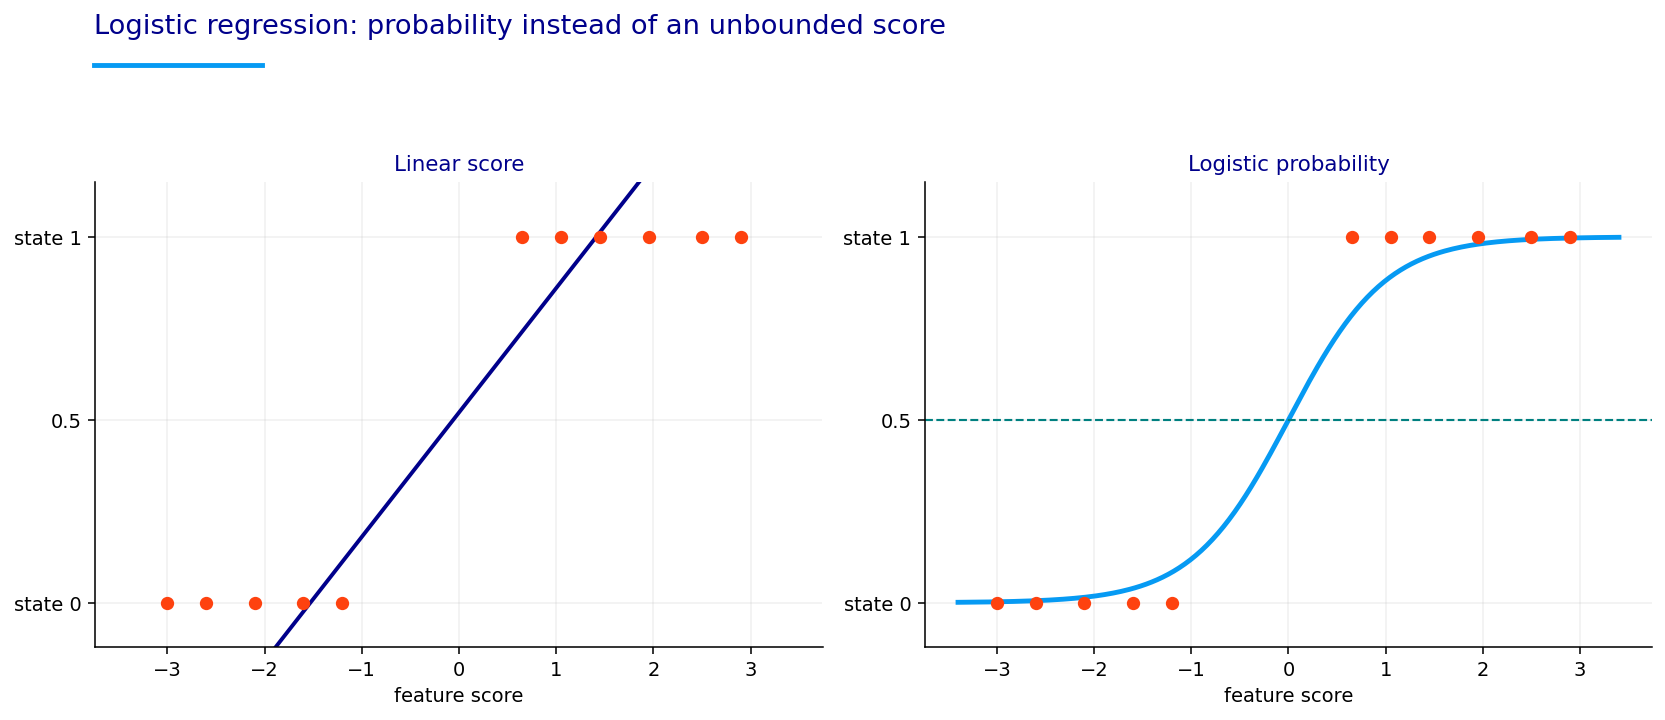

In [56]:
fig, axes = logistic_boundary()
plt.show()

In [57]:
logit = LogisticRegression(max_iter=2500, class_weight="balanced", C=0.75)
logit.fit(x_train, y_train)
ml_models["LogisticRegression"] = logit
ml_rows.append(classifier_score_local("LogisticRegression", logit))

### 9.2 Linear Discriminant Analysis

Linear Discriminant Analysis (LDA) assumes each class has a multivariate Gaussian distribution with a shared covariance matrix:

$$
X_t \mid Y_t=k \sim \mathcal{N}(\mu_k,\Sigma)
$$

The discriminant score for class $k$ is:

$$
\delta_k(X_t) = X_t^\top \Sigma^{-1}\mu_k - \frac{1}{2}\mu_k^\top \Sigma^{-1}\mu_k + \log \pi_k
$$

where:

- $\mu_k$ is the class mean,
- $\Sigma$ is the common covariance matrix,
- $\pi_k$ is the class prior probability.

The predicted class is the class with the largest discriminant score. Probabilities come from transforming these class scores.

The LDA implementation uses shrinkage, which is important because the selected features are correlated. Shrinkage stabilizes the covariance matrix:

$$
\Sigma_{\text{shrink}} = (1-\lambda)\hat{\Sigma} + \lambda T
$$

where $T$ is a target covariance structure, often diagonal or scaled identity.

LDA ends up as the best supervised model by selection score in the main output. It has the highest balanced accuracy, around 0.464, and the highest macro F1, around 0.447. This is meaningful because it shows LDA is doing a better job across all regimes, not just the majority risk-on class. Its raw accuracy is lower than RandomForest and LightGBM, but the class balance problem makes raw accuracy less important.


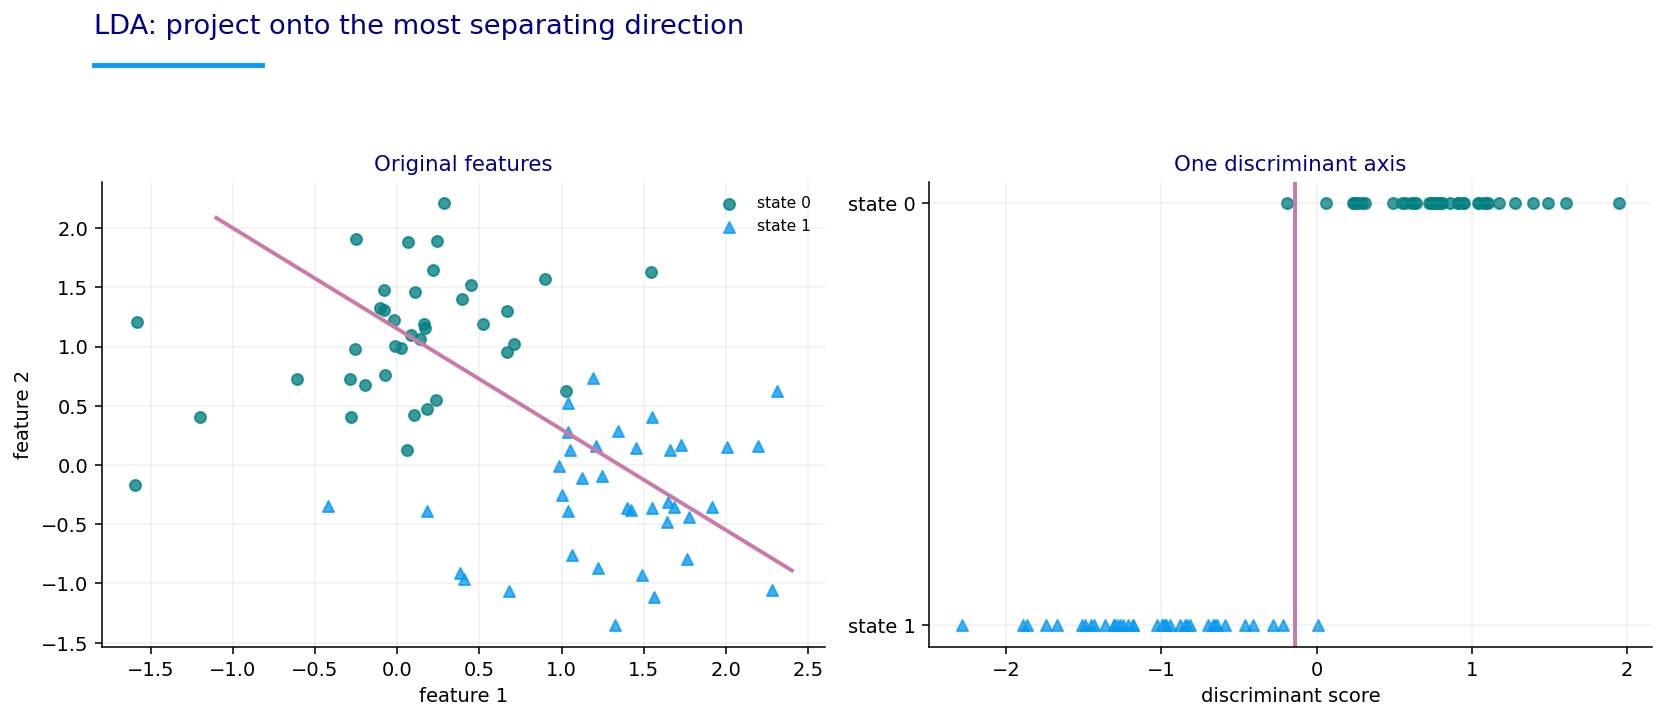

In [58]:
fig, axes = lda_projection()
plt.show()

In [59]:
lda = LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")
lda.fit(x_train, y_train)
ml_models["LinearDiscriminantAnalysis"] = lda
ml_rows.append(classifier_score_local("LinearDiscriminantAnalysis", lda))

### 9.3 Random Forest and Permutation Importance

A RandomForest is an ensemble of decision trees. Each tree partitions the feature space into regions and predicts a class distribution inside each leaf. The forest averages probabilities across trees:

$$
\hat{p}_{t,k} = \frac{1}{B}\sum_{b=1}^{B}\hat{p}_{t,k}^{(b)}
$$

where $B$ is the number of trees.

Each tree is trained on a bootstrap sample and uses random subsets of features at splits. This reduces variance compared with a single tree. The forest can learn nonlinear interactions, such as:

- drawdown is dangerous only when credit is weak,
- high rates are dangerous only when growth is slowing,
- volatility shock matters more when breadth is deteriorating.

RandomForest has the highest raw accuracy in the main classifier table, around 0.583. But its balanced accuracy is only around 0.381, and its macro F1 is around 0.330. This suggests it predicts common regimes well but isn't as balanced across classes as LDA.

That is a common issue in imbalanced financial classification. A model that is good at identifying the dominant state can look strong by accuracy, while still being less useful for defensive detection.


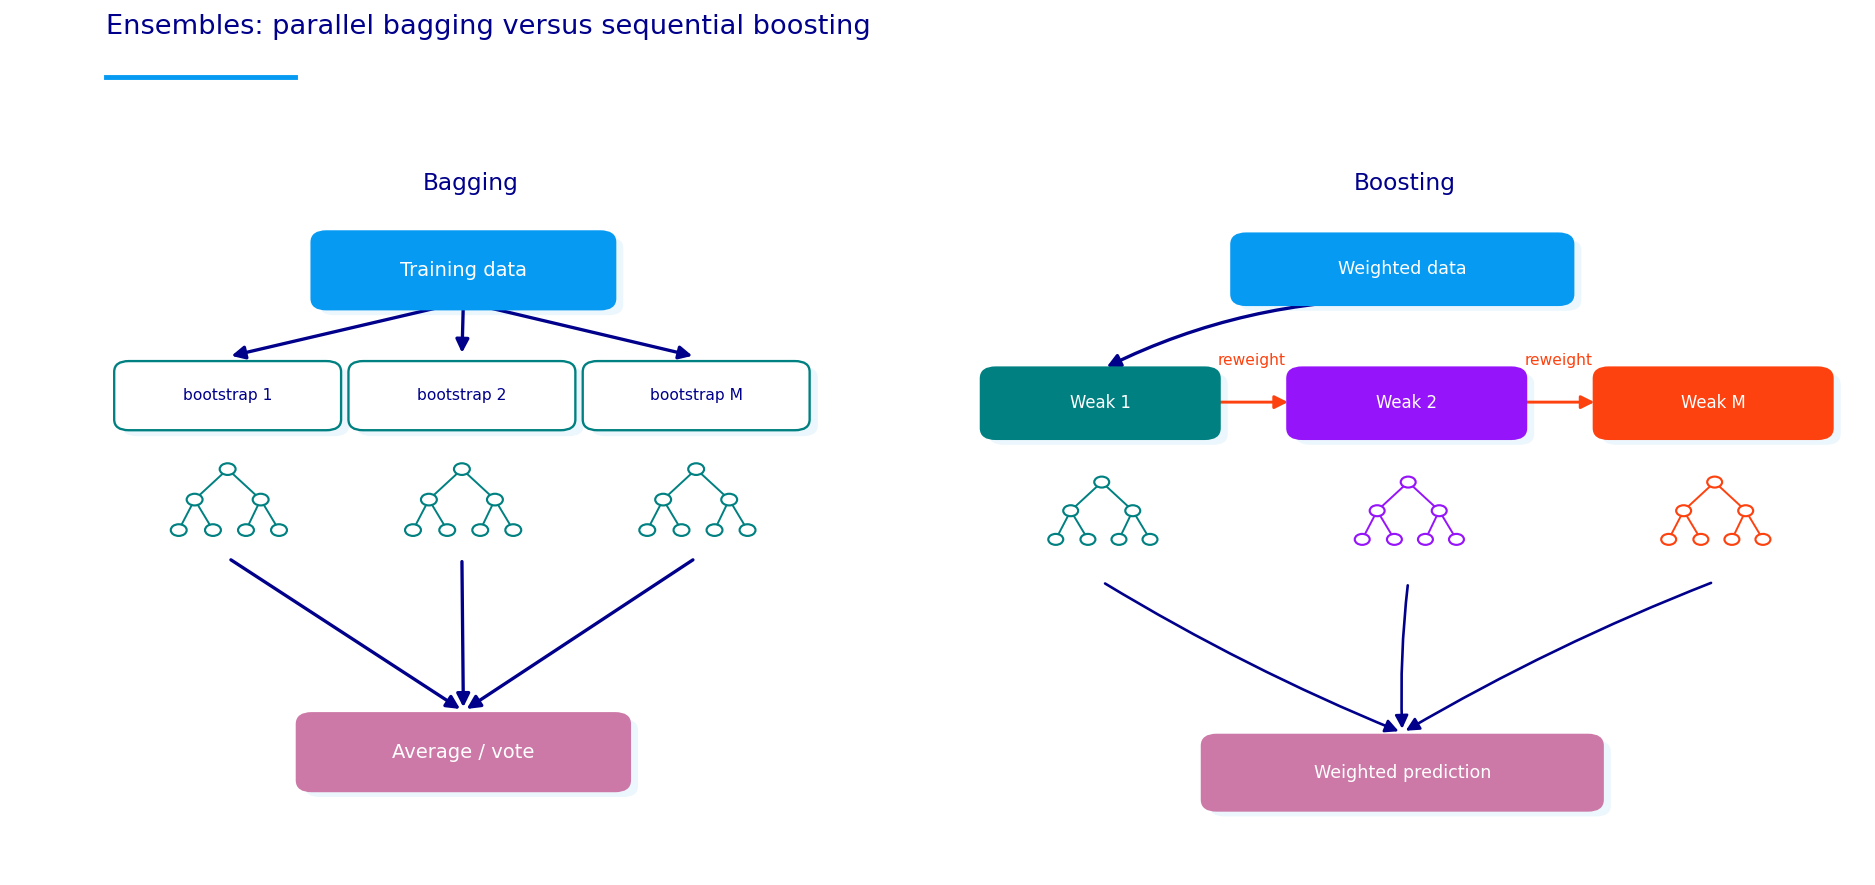

In [60]:
fig, axes = ensemble_bagging()
plt.show()

In [61]:
rf_clf = RandomForestClassifier(
    n_estimators=500,
    min_samples_leaf=20,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=1,
)
rf_clf.fit(x_train, y_train)
ml_models["RandomForestClassifier"] = rf_clf
ml_rows.append(classifier_score_local("RandomForestClassifier", rf_clf))

### 9.4 Gradient Boosting and LightGBM

Boosting builds models sequentially. Each new tree tries to correct errors left by the previous ensemble. In a simplified additive form:

$$
F_m(X) = F_{m-1}(X) + \nu h_m(X)
$$

where:

- $F_m$ is the ensemble after $m$ trees,
- $h_m$ is the new tree,
- $\nu$ is the learning rate.

For classification, boosting minimizes a multiclass loss, usually cross-entropy. The model learns nonlinear boundaries and interactions, often with strong predictive power.

LightGBM is a high-performance gradient boosting implementation. It can fit complex nonlinear models efficiently and often works well on tabular data. In thisn'tebook, LightGBM has high raw accuracy, around 0.563, but balanced accuracy around 0.398. That is better balanced than RandomForest but still below LDA in the main comparison. Its log loss is also weaker than RandomForest in the main output.

Boosting is powerful, but in financial time series it can overfit subtle historical patterns. A complex model can learn regime quirks from one era and fail in a new era. This is why we evaluate both statistical metrics and economic utility.


In [62]:
gb_clf = GradientBoostingClassifier(
    n_estimators=260,
    learning_rate=0.035,
    max_depth=2,
    min_samples_leaf=25,
    random_state=42,
)
gb_clf.fit(x_train, y_train)
ml_models["GradientBoostingClassifier"] = gb_clf
ml_rows.append(classifier_score_local("GradientBoostingClassifier", gb_clf))

In [63]:
if lgbm_available:
    lgbm = LGBMClassifier(
        n_estimators=360,
        learning_rate=0.025,
        num_leaves=15,
        min_child_samples=45,
        subsample=0.85,
        colsample_bytree=0.85,
        objective="multiclass",
        random_state=42,
        verbosity=-1,
        n_jobs=1,
    )
    lgbm.fit(x_train, y_train)
    ml_models["LGBMClassifier"] = lgbm
    ml_rows.append(classifier_score_local("LGBMClassifier", lgbm))
else:
    print("LightGBM unavailable; skipped")

### 9.5 SVM and KNN

The SVM teaching plot shows the margin idea. In a binary linear case, SVM solves:

$$
\min_{w,b,\xi} \frac{1}{2}\|w\|^2 + C\sum_{t=1}^{N}\xi_t
$$

subject to:

$$
y_t(w^\top X_t + b) \ge 1-\xi_t,\qquad \xi_t \ge 0
$$

The model tries to maximize the margin while allowing some violations. With kernels, SVM can create nonlinear boundaries. In we, SVC is used with probability output, so it can feed regime probabilities into portfolio weights.

SVC has balanced accuracy around 0.373 in the main table. It isn't the selected model, but it performs reasonably. The issue is that SVM probabilities can be sensitive to calibration and class imbalance.

KNN predicts using nearby observations:

$$
P(Y_t=k \mid X_t) = \frac{\sum_{i\in \mathcal{N}_K(t)} w_i \mathbf{1}(Y_i=k)}{\sum_{i\in \mathcal{N}_K(t)} w_i}
$$

where $\mathcal{N}_K(t)$ is the set of nearest neighbors. Distance-weighted KNN gives closer neighbors more influence.

KNN is intuitive: if today's feature vector looks like past stress episodes, predict stress. But it has weaknesses in high-dimensional correlated spaces. Distance becomes less meaningful as the number of dimensions grows, and correlated features can over-weight one economic theme.


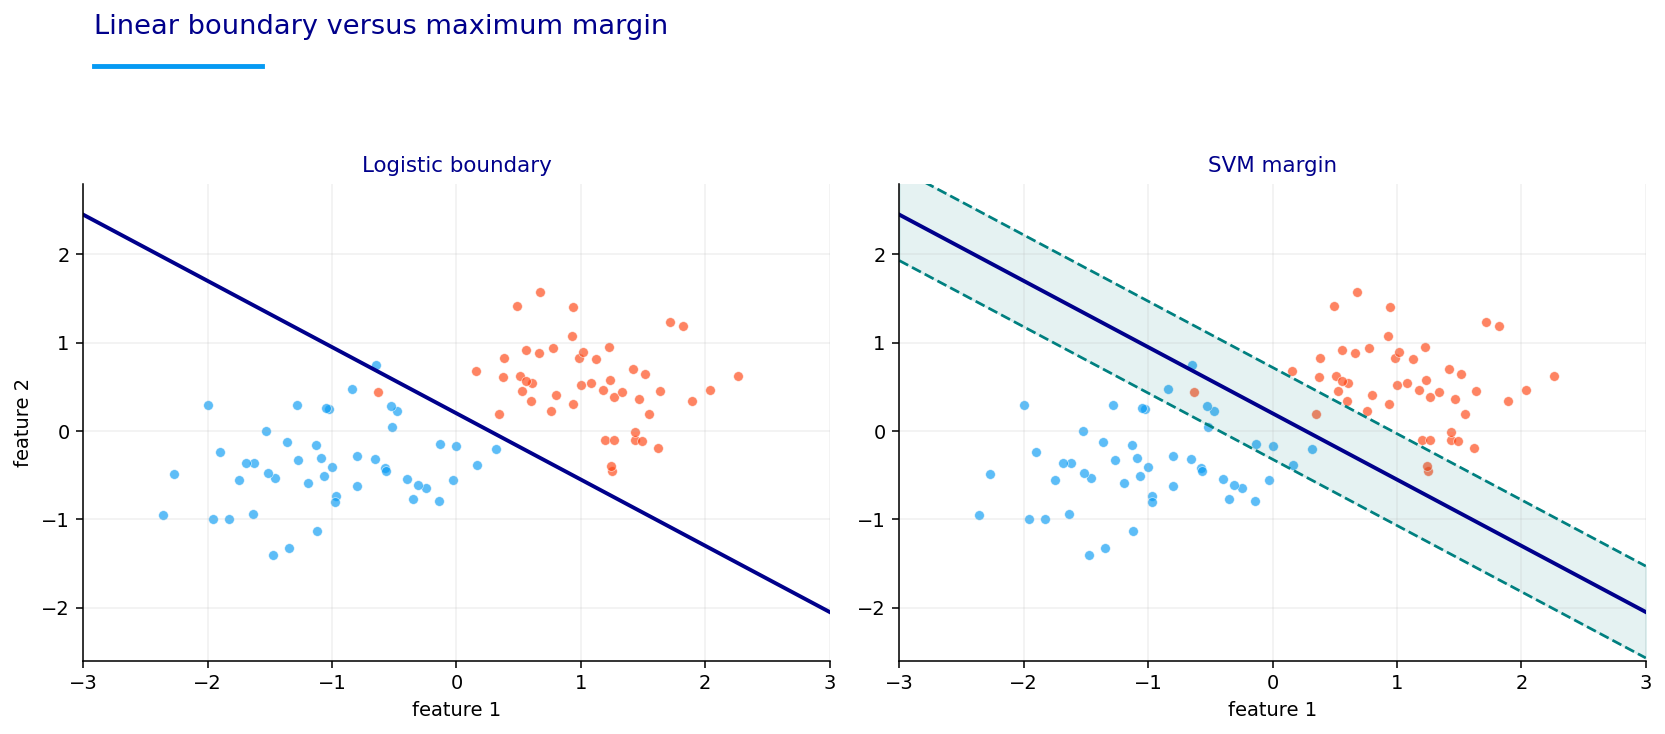

In [64]:
fig, axes = svm_margin()
plt.show()

In [65]:
svm = SVC(C=1.8, gamma="scale", probability=True, class_weight="balanced", random_state=42)
svm.fit(x_train, y_train)
ml_models["SVC"] = svm
ml_rows.append(classifier_score_local("SVC", svm))

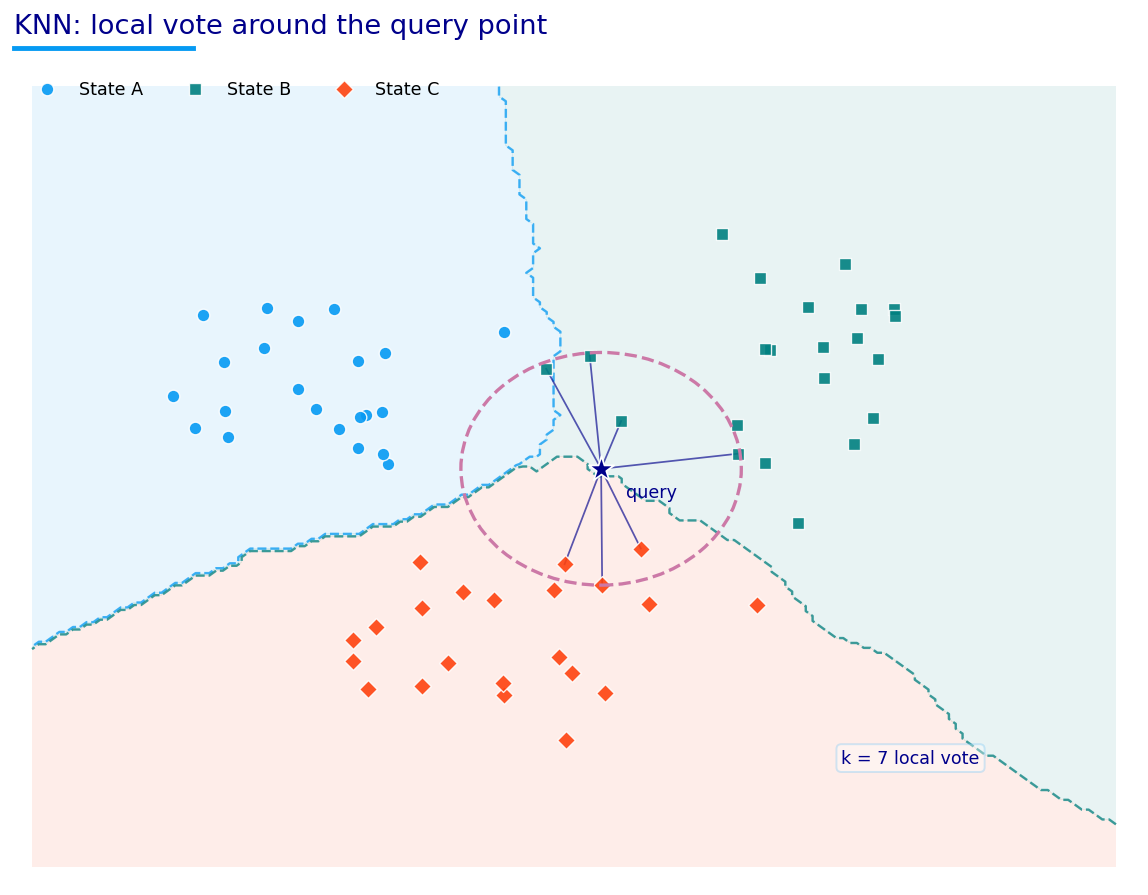

In [66]:
fig, ax = knn_neighbors()
plt.show()

In [67]:
knn = KNeighborsClassifier(n_neighbors=31, weights="distance")
knn.fit(x_train, y_train)
ml_models["KNeighborsClassifier"] = knn
ml_rows.append(classifier_score_local("KNeighborsClassifier", knn))

In [68]:
eco_quality = pd.DataFrame(eco_rows).drop_duplicates("model").set_index("model")
classifier_table = pd.DataFrame(ml_rows).drop_duplicates("model").set_index("model")
display(eco_quality.round(4))
display(classifier_table.sort_values(["balanced_accuracy", "macro_f1", "log_loss"], ascending=[False, False, True]).round(4))

,states,loglike,aic,bic,silhouette,min_state_share,avg_state_duration,transitions_per_year,posterior_confidence,economic_separation
model,,,,,,,,,,
KMeans 3,3,NaN,NaN,NaN,0.1846,0.0556,86.9592,2.8346,NaN,1.4000
KMeans 4,4,NaN,NaN,NaN,0.1718,0.0554,52.6049,4.7243,NaN,1.4315
Agglomerative 3,3,NaN,NaN,NaN,0.1413,0.2673,250.6471,0.9449,NaN,0.4679
Agglomerative 4,4,NaN,NaN,NaN,0.1746,0.0502,250.6471,0.9449,NaN,1.4479
GMM 3 diag,3,-121944.9130,244193.8260,245160.1294,0.1718,0.1990,355.0833,0.6496,0.9969,0.6455
GMM 4 diag,4,-117625.3120,235656.6241,236947.1477,0.1476,0.0784,66.5781,3.7204,0.9861,1.4005
Bayesian GMM,6,-110534.5269,NaN,NaN,0.1315,0.0136,63.5970,3.8976,0.9870,1.8359
MarkovRegression 3,3,-3730.5755,7485.1511,7561.4382,0.0427,0.0774,43.9278,5.6692,0.8945,0.9026
HMM 3,3,-119347.9982,239011.9964,240016.4434,0.1668,0.1727,426.1000,0.5315,0.9991,0.8280


,accuracy,balanced_accuracy,macro_f1,log_loss
model,,,,
LinearDiscriminantAnalysis,0.4746,0.4639,0.4474,1.3525
LGBMClassifier,0.5626,0.3975,0.3802,1.5236
RandomForestClassifier,0.5832,0.3812,0.3304,0.9658
SVC,0.5300,0.3730,0.3539,1.6232
KNeighborsClassifier,0.5214,0.3700,0.3460,6.8068
LogisticRegression,0.4254,0.3637,0.3069,2.3009
GradientBoostingClassifier,0.4328,0.3590,0.3282,1.2648


In the quality table, KMeans with 3 and 4 states has reasonable silhouette scores, around 0.18 and 0.17 in the main application. The 3-state version has a small minimum state share around 5.6%, which means one cluster is quite small. KMeans 4 improves economic separation slightly but adds another cluster. That extra cluster can be useful if the market has a distinct inflation-stress or credit-stress state, but it also makes the final mapping harder because the portfolio policy is built around risk-on, neutral, and defensive.

The model's main strength is interpretability. You can look at centroids and see which features are high or low in each cluster. The weakness is that KMeans gives hard assignments and has no time dependence. If one day is barely on one side of a boundary and the next day is barely on the other side, the state can flip even if the market hasn't really changed.

That is why later models use soft probabilities and Markov persistence.


The main table shows agglomerative clustering has lower transition frequency than KMeans. Agglomerative 3 has an average state duration above 250 observations and only about 0.94 transitions per year. That is much smoother than KMeans. Agglomerative 4 also has strong economic separation, around 1.45, but one state is small.

This tells us the hierarchical grouping is finding more persistent states. In a portfolio setting, persistence is useful because frequent regime switching can create turnover and unstable allocations. But too much persistence can also be a problem. If the model is slow to leave a state, it may miss sudden crashes or sudden recoveries.

So we don't choose a model only by smoothness. We need to compare:

- separation across future outcomes,
- minimum state size,
- state duration,
- transition frequency,
- and whether the probability path can be used in a real walk-forward setting.


In the quality table, GMM 3 and GMM 4 have strong posterior confidence, around 0.997 and 0.986, but their economic separation differs. GMM 4 reaches around 1.40, while GMM 3 is closer to 0.65. This suggests that adding a fourth component helps separate economically different states. The problem is that the final portfolio policy is designed around three named regimes, so a four-state unsupervised discovery model has to be mapped carefully.

This is one of the recurring tradeoffs in regime work:

- more states can capture more market nuance,
- fewer states are easier to interpret and use in allocation,
- too many states can create unstable labels and small-sample profiles.


In the output, the Bayesian GMM has six active labels after filtering, with component weights such as 0.3174, 0.2134, 0.1479, 0.0491, and 0.2582, while one small component is near 0.0138. It also has the strongest economic separation in the main model-quality table, around 1.84. That means its states separate realized future outcomes well. Its weakness is practical: six states are harder to map cleanly into the three allocation regimes.


The output shows that Bayesian GMM finds more economic separation, but it also creates a very small state. That is an honest warning. Rare states can be meaningful, but they can also be sample artifacts. If a state has only a tiny share of observations, we shouldn't let it dominate portfolio policy without further validation.


In the output, PCA-HMM 3 has smoother state behavior than some models, but its economic separation is only around 0.657 in the main table. That suggests compression helped stability but didn't improve the separation of future risk-defensive outcomes enough to dominate.


### HMM Quality in the Main Output

The HMM 3 model has a low silhouette score, around 0.167, but that isn't fatal. Silhouette is a static clustering metric based on geometric separation. HMMs are sequence models, so their strength isn't only static separation. They also use transition persistence.

The HMM 3 model has:

- 3 states,
- minimum state share around 17.3%,
- average state duration around 426 observations,
- transitions per year around 0.53,
- posterior confidence around 0.999,
- economic separation around 0.828.

That profile is very persistent. The model doesn't jump between states often. This makes it attractive for portfolio use because monthly allocations won't flip too aggressively. The selection rule picks **HMM 3** as the best econometric model, even though Bayesian GMM has higher economic separation. The reason is that the selection rule rewards a combination of valid state count, minimum state size, posterior confidence, duration, and lower transition frequency.

This is a reasonable choice for a regime portfolio. A model with extremely high economic separation but too many states or too much label fragmentation can be hard to use in an allocation policy. HMM 3 is less dramatic but more stable.


The HMM quality table shows why HMM 3 becomes the selected econometric model. It doesn't dominate every metric. Bayesian GMM has higher economic separation, and some four-state models separate more nuanced regimes. But HMM 3 has a strong combination of posterior confidence, state persistence, and practical interpretability.

The high posterior confidence means that most dates are assigned with a clear state probability rather than a flat distribution. The long average duration means the state path is stable enough for monthly portfolio allocation. The economic separation isn't the highest, but it is meaningful. In other words, HMM 3 gives a usable state process.

The convergence warnings during walk-forward fitting should be treated honestly. The warnings show that some EM fits reach tiny negative likelihood changes, often on the order of $10^{-6}$ or $10^{-7}$. This usually means the optimizer is extremely close to a numerical plateau. It isn't necessarily a model failure, but it warns us that HMM likelihood surfaces can be flat, sensitive, and initialization-dependent.

For a trading model, this matters because small parameter changes can shift state probabilities. That is one reason the portfolio layer later uses smoothing, probability blending, entropy penalties, and MV anchoring. We don't want the final allocation to overreact to small changes in the hidden-state fit.


### 9.6 Probability Calibration and Portfolio Use

A classifier used for portfolio construction needs usable probabilities, not only good class labels. If a model predicts risk-on with 95% probability but is only right 60% of the time in those cases, the portfolio will take too much risk. If a model is always under-confident, it may never shift weights enough to matter.

A probability model is well calibrated when:

$$
P(Y=k \mid \hat{p}_k \approx q) \approx q
$$

For example, among observations where the model says 70% risk-on, risk-on should occur about 70% of the time. In finance, calibration is hard because regimes drift and the sample is limited, but probability quality still matters.

Log loss helps check calibration because it punishes confident wrong predictions more than mild wrong predictions:

$$
-\log(0.90) \approx 0.105
$$

for a correct 90% prediction, but:

$$
-\log(0.10) \approx 2.303
$$

for a wrong 90% prediction. This asymmetry is exactly what we want. A model that is confidently wrong in stress periods can damage a portfolio.

The portfolio layer also controls this risk by using probability blending, entropy penalties, and smoothing. We don't let a single classifier probability instantly turn into an extreme position.


Probability calibration connects ML output to allocation size. If a classifier gives probabilities, we need those probabilities to mean something. A 70% risk-on forecast should behave roughly like a 70% risk-on condition historically.

A simple calibration condition is:

$$
P(Y=k \mid \hat{p}_{k}\in [a,b]) \approx \frac{a+b}{2}
$$

For example, among all observations where the model assigns risk-on probability around 70%, risk-on should happen around 70% of the time. In finance, this will never be perfect because regimes are nonstationary and samples are small. But wildly miscalibrated probabilities are dangerous.

Log loss is one probability-quality metric:

$$
\text{LogLoss} = -\frac{1}{N}\sum_{t=1}^{N}\log \hat{p}_{t,Y_t}
$$

where $\hat{p}_{t,Y_t}$ is the predicted probability assigned to the true class. If the model assigns high probability to the true class, log loss is small. If it assigns tiny probability to the true class, log loss becomes large.

This matters because later the probability vector directly affects weights:

$$
\tilde{w}_t = \sum_{k=1}^{K}\hat{p}_{t,k}w_t^{(k)}
$$

If probabilities are overconfident, the strategy will swing too hard into one sleeve. If probabilities are too flat, the strategy will barely move. The ML model isn't only a classifier; it is a position-sizing engine.


## 10) Model Selection and Confusion Matrices

The model-quality comparison has two separate panels:

1. econometric/unsupervised/sequence models,
2. supervised classifiers.

The econometric table reports silhouette, state shares, average duration, transitions per year, posterior confidence, entropy, and economic separation. The supervised table reports accuracy, balanced accuracy, macro F1, log loss, and economic utility.

The final selected models are:

- **Best econometric model**: HMM 3.
- **Best ML model**: LinearDiscriminantAnalysis.

The HMM 3 choice is based on stability and probability quality. It has very high posterior confidence and long average state duration. It doesn't have the highest economic separation, but it gives a clean three-state probability process with strong persistence.

The LDA choice is based on balanced classification. It has the best balanced accuracy and macro F1 in the main classifier table. RandomForest and LightGBM have higher raw accuracy, but the regime problem isn't only about predicting the most common class.

The confusion matrix for the LDA model shows the class-level behavior:

- For true risk-on observations, many are correctly predicted as risk-on, but a large number are predicted as neutral.
- For true neutral observations, predictions are spread across all three classes. This confirms neutral is the hardest class.
- For true defensive observations, the model correctly identifies a meaningful number as defensive, which matters for portfolio risk control.

Neutral regimes are naturally difficult because they are boundary states. If the forward risk-defensive spread is near zero, small market changes can move the label from neutral to risk-on or defensive. A model can be economically useful even when neutral classification is imperfect, as long as it gives reasonable probabilities.


The classifier selection score combines statistical and economic criteria. The economic utility component measures whether the model's risk-on-minus-defensive probability aligns with the future risk-defensive spread:

$$
\text{Signal}_t = P_t(\text{risk-on}) - P_t(\text{defensive})
$$

and:

$$
\text{Utility Raw} = \sqrt{12}\cdot \frac{E[\text{Signal}_t \cdot \Delta_t^{63}]}{\operatorname{Std}(\text{Signal}_t \cdot \Delta_t^{63})}
$$

This isn't a full trading strategy, but it checks whether the probability direction has economic content. If a classifier is statistically accurate but its probability signal doesn't align with the future risk-defensive spread, it may not help allocation.

LDA has the strongest final selection score. RandomForest is close because it has good log loss and high accuracy, but LDA's better class balance matters more. This is a good example of model selection being tied to the financial task, not only machine-learning leaderboard metrics.


In [69]:
eco_rank = eco_quality.copy()
eligible_eco = eco_rank[
    eco_rank.index.to_series().str.contains("HMM|GMM|Markov", regex=True)
    & eco_rank["states"].eq(len(regime_names))
    & eco_rank["min_state_share"].ge(0.04)
    & eco_rank["avg_state_duration"].ge(4.0)
].copy()
if eligible_eco.empty:
    eligible_eco = eco_rank[eco_rank["states"].eq(len(regime_names))].copy()
if eligible_eco.empty:
    eligible_eco = eco_rank.copy()
eco_rank_score = (
    eligible_eco["economic_separation"].rank(pct=True)
    + eligible_eco["posterior_confidence"].fillna(0.0).rank(pct=True)
    + eligible_eco["avg_state_duration"].rank(pct=True)
    - eligible_eco["transitions_per_year"].rank(pct=True) * 0.35
    + eligible_eco["min_state_share"].rank(pct=True)
)
best_eco = str(eco_rank_score.sort_values(ascending=False).index[0])

def classifier_economic_utility(model):
    if hasattr(model, "predict_proba"):
        raw = model.predict_proba(x_test)
        proba = pd.DataFrame(0.0, index=x_test.index, columns=range(len(regime_names)))
        for j, cls in enumerate(model.classes_):
            proba[int(cls)] = raw[:, j]
    else:
        pred = pd.Series(model.predict(x_test), index=x_test.index)
        proba = pd.get_dummies(pred).reindex(index=x_test.index, columns=range(len(regime_names)), fill_value=0.0)
    p = proba.rename(columns=dict(enumerate(regime_names)))
    fwd = future_for_quality.reindex(x_test.index)
    utility = fwd["risk_defensive_spread_63"]
    signal = p["risk_on"] - p["defensive"]
    r = (signal * utility).replace([np.inf, -np.inf], np.nan).dropna()
    return np.sqrt(12.0) * r.mean() / r.std(ddof=1) if r.std(ddof=1) > 1e-12 else 0.0

ml_rank = classifier_table.copy()
ml_rank["economic_utility_raw"] = pd.Series({name: classifier_economic_utility(model) for name, model in ml_models.items()})
ml_rank["economic_utility_score"] = 0.30 * ml_rank["economic_utility_raw"].rank(pct=True)
ml_rank["log_loss_bad_rank"] = ml_rank["log_loss"].replace(np.nan, ml_rank["log_loss"].max() + 1.0).rank(pct=True, ascending=True)
ml_rank["selection_score"] = (
    0.40 * ml_rank["balanced_accuracy"]
    + 0.30 * ml_rank["macro_f1"]
    - 0.30 * ml_rank["log_loss_bad_rank"]
    + ml_rank["economic_utility_score"]
)
classifier_table = ml_rank
display(classifier_table.sort_values("selection_score", ascending=False).round(4))
ml_rank_score = classifier_table["selection_score"]
best_ml = str(ml_rank_score.sort_values(ascending=False).index[0])

print("best econometric model:", best_eco)
print("best ML model:", best_ml)

,accuracy,balanced_accuracy,macro_f1,log_loss,economic_utility_raw,economic_utility_score,log_loss_bad_rank,selection_score
model,,,,,,,,
LinearDiscriminantAnalysis,0.4746,0.4639,0.4474,1.3525,1.7929,0.3000,0.4286,0.4912
RandomForestClassifier,0.5832,0.3812,0.3304,0.9658,1.3511,0.2571,0.1429,0.4659
LGBMClassifier,0.5626,0.3975,0.3802,1.5236,1.2197,0.1286,0.5714,0.2302
SVC,0.5300,0.3730,0.3539,1.6232,1.3278,0.1714,0.7143,0.2125
GradientBoostingClassifier,0.4328,0.3590,0.3282,1.2648,0.8907,0.0429,0.2857,0.1992
LogisticRegression,0.4254,0.3637,0.3069,2.3009,1.3338,0.2143,0.8571,0.1947
KNeighborsClassifier,0.5214,0.3700,0.3460,6.8068,1.1237,0.0857,1.0000,0.0375


best econometric model: HMM 3
best ML model: LinearDiscriminantAnalysis


The output shows LDA is selected even though RandomForest has higher raw accuracy. That isn't surprising. LDA has better overall selection score because it balances statistical performance and economic usefulness. It also produces smoother, more stable probabilities. In a portfolio setting, stable probability quality can beat higher raw hit rate.


,pred_0,pred_1,pred_2
true_0,494,338,146
true_1,152,131,126
true_2,95,62,205


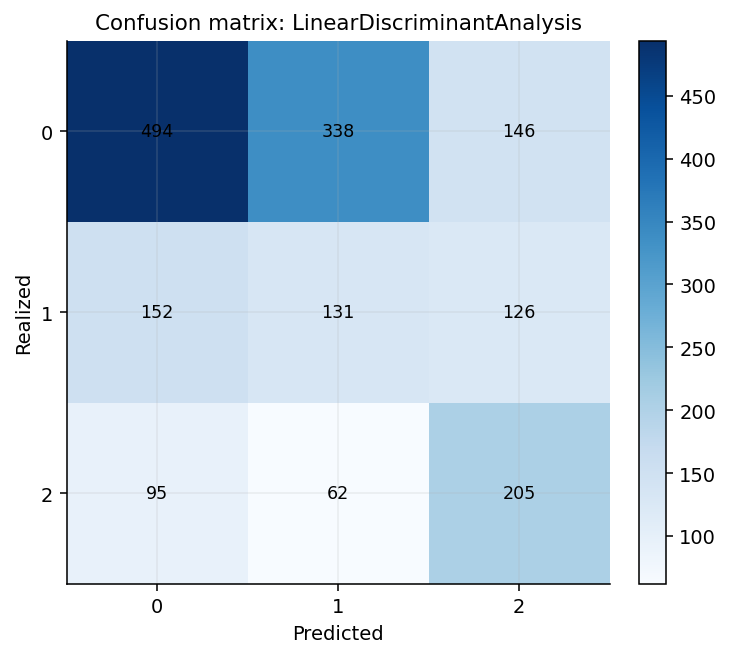

In [70]:
best_pred = ml_models[best_ml].predict(x_test)
best_cm = pd.DataFrame(
    confusion_matrix(y_test, best_pred, labels=class_labels),
    index=[f"true_{i}" for i in class_labels],
    columns=[f"pred_{i}" for i in class_labels],
)
display(best_cm)
fig, ax = plt.subplots(figsize=(5.8, 4.8))
im = ax.imshow(best_cm.values, cmap="Blues")
ax.set_xticks(range(len(class_labels)))
ax.set_yticks(range(len(class_labels)))
ax.set_xticklabels(class_labels)
ax.set_yticklabels(class_labels)
for i in range(best_cm.shape[0]):
    for j in range(best_cm.shape[1]):
        ax.text(j, i, int(best_cm.iloc[i, j]), ha="center", va="center", fontsize=9)
ax.set_xlabel("Predicted")
ax.set_ylabel("Realized")
ax.set_title(f"Confusion matrix: {best_ml}")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

The confusion matrix gives a more concrete view of model behavior. In the main test period, the selected classifier correctly identifies many risk-on observations, but it still confuses a meaningful number of risk-on dates with neutral and some neutral dates with defensive. Defensive recall is better than a naive risk-on-only model, but it isn't perfect.

That pattern is realistic. Neutral is the hardest class because it sits between two strong states. A neutral date can look risk-on by some features and defensive by others. Many regime models struggle with this middle state because markets transition gradually. The neutral label is still useful because it prevents the model from forcing every mixed environment into an extreme sleeve.

For portfolio construction, we care about the practical meaning of the errors:

- **Risk-on predicted as neutral** usually reduces upside but doesn't necessarily create disaster.
- **Neutral predicted as risk-on** can add risk too early.
- **Defensive predicted as risk-on** is the dangerous error because it keeps the portfolio exposed during future stress.
- **Risk-on predicted as defensive** is costly through missed returns.

The model-selection score tries to balance these issues by combining classification metrics with economic utility. The output choosing LDA tells us that a simple, shrinkage-stabilized probabilistic classifier is more usable than a more complex model with slightly better raw accuracy but less balanced or less economically useful behavior.


## 11) Walk-Forward Regime Probabilities

The static train/test comparison is useful, but portfolio construction needs walk-forward probabilities. At each rebalance date, we fit or refit the selected model using only historical data available up to that date, then produce a probability vector for the current state.

The econometric walk-forward probability is:

$$
p^{\text{eco}}_t = \begin{bmatrix} P_t^{\text{eco}}(\text{risk-on}) & P_t^{\text{eco}}(\text{neutral}) & P_t^{\text{eco}}(\text{defensive}) \end{bmatrix}
$$

The ML walk-forward probability is:

$$
p^{\text{ml}}_t = \begin{bmatrix} P_t^{\text{ml}}(\text{risk-on}) & P_t^{\text{ml}}(\text{neutral}) & P_t^{\text{ml}}(\text{defensive}) \end{bmatrix}
$$

The HMM refit produces some convergence warnings with extremely tiny likelihood deltas. These warnings aren't unusual for EM-based models. The output says the current likelihood isn't greater than the previous likelihood by a tiny amount, often around $10^{-6}$ or smaller. That means the algorithm is effectively at a numerical plateau. We shouldn't ignore convergence warnings, but these particular warnings don't necessarily invalidate the estimates.

The latest HMM probabilities show strong regime jumps. In late 2025, the econometric model moves from neutral-heavy probabilities in July through September to risk-on-heavy probabilities in October and November. The ML probabilities are smoother and less certain, with the final observation around 45.5% risk-on, 26.1% neutral, and 28.3% defensive.

This difference is useful. The HMM gives a persistent sequence-based signal. LDA gives a softer feature-classification signal. The hybrid strategy later blends them instead of forcing one to be completely right.


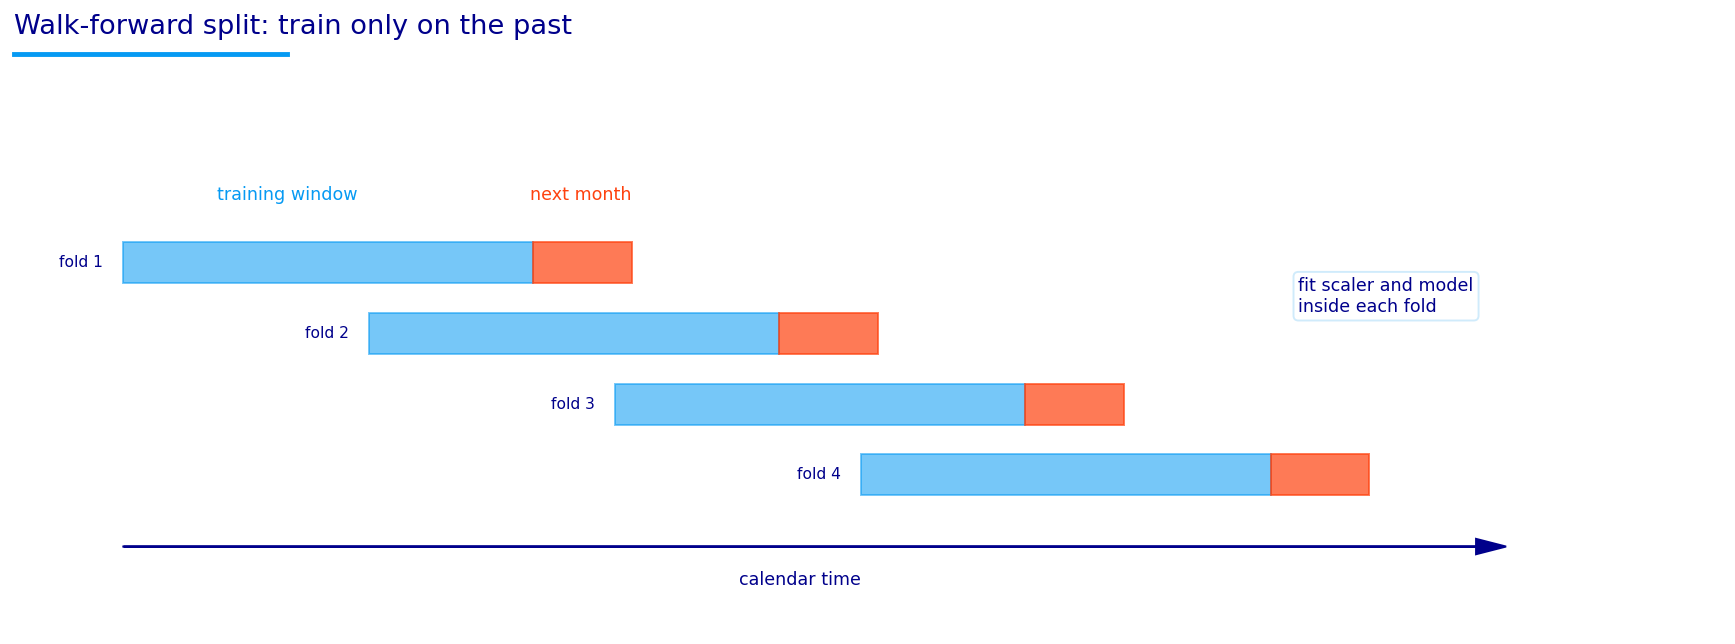

In [71]:
fig, ax = walkforward_split()
plt.show()

The walk-forward split diagram is important because it shows the real-time logic. Labels are only available after the horizon passes. If we use a 63-day forward label, then at date $t$ we can't train on labels for observations too close to $t$, because those future returns aren't known yet. We handle this by using cutoffs that respect the horizon.

This is one of the most important anti-leakage details in the project.

A clean supervised time-series training set at date $t$ should satisfy:

$$
s + h \le t
$$

where $s$ is the feature date and $h$ is the forward-label horizon. If $h=63$, then a feature observation from last week doesn't yet have a realized 63-day label. Training on it would leak future information.

In a normal tabular ML problem, train/test split is simple. In finance, label availability depends on the prediction horizon. This is why walk-forward ML is harder than static ML.


The walk-forward design is where the project becomes realistic. A static train/test split is useful for diagnostics, but a live strategy needs probabilities at each rebalance date using only information available at that date.

At rebalance date $t$, the training set must include only observations $s$ whose forward label is already known:

$$
s+h \le t
$$

where $h$ is the forward horizon, such as 63 trading days. If $s+h>t$, then the label for date $s$ depends on returns that have not happened yet by date $t$. Including it would create lookahead bias.

This is one of the easiest mistakes to make in regime modeling. Feature values are known immediately, but labels are known only after the forward horizon passes. A model can look extremely good if it accidentally trains on labels that weren't available at the rebalance date.

The walk-forward probability vectors:

$$
p_t^{\text{eco}} = \begin{bmatrix}p_{t,0}^{\text{eco}} & p_{t,1}^{\text{eco}} & p_{t,2}^{\text{eco}}\end{bmatrix}
$$

and:

$$
p_t^{\text{ml}} = \begin{bmatrix}p_{t,0}^{\text{ml}} & p_{t,1}^{\text{ml}} & p_{t,2}^{\text{ml}}\end{bmatrix}
$$

are therefore more important than the in-sample state histories. These are the probabilities the portfolio actually sees.

The latest probabilities show a useful disagreement. The econometric HMM moves strongly risk-on by October and November 2025, while the ML model remains more mixed. That disagreement isn't a bug. The two engines read the same environment through different assumptions. HMM emphasizes sequence persistence and emission likelihood. LDA emphasizes current features relative to supervised class means. The hybrid portfolio later blends these signals instead of forcing one model to dominate always.


Time-series validation needs its own explanation because it is one of the biggest differences between finance ML and ordinary tabular ML.

In a normal supervised learning dataset, observations might be treated as exchangeable. If rows are independent, random train/test splitting can be reasonable. Financial rows aren't exchangeable. Date $t$ comes before date $t+1$, labels are forward-looking, volatility clusters, and macro regimes persist.

So the chronological validation rule is:

$$
\max(\text{train dates}) < \min(\text{test dates})
$$

and, with forward labels:

$$
\max(\text{feature date in train}) + h \le \min(\text{test rebalance date})
$$

where $h$ is the label horizon. This prevents using future returns that weren't known at the time.

There is also a difference between **expanding-window** and **rolling-window** training.

In an expanding window, the training set grows through time:

$$
\mathcal{T}_t = \{1,2,\dots,t-h\}
$$

This uses all available history. It is stable and data-efficient, but it can be slow to forget old regimes. A model trained on 2008, 2020, and 2022 all at once may mix crisis types that are economically different.

In a rolling window, the training set keeps a fixed length:

$$
\mathcal{T}_t = \{t-h-L+1,\dots,t-h\}
$$

This adapts more quickly to recent environments, but it has fewer observations. In regime classification, fewer observations can be painful because defensive regimes are already rare.

This project leans toward using enough history for stable model fitting while still evaluating probabilities walk-forward. That is a practical compromise. Purely adaptive models can become too noisy. Fully static models can become stale.

Another validation issue is **overlapping labels**. A 63-day forward label for date $t$ and a 63-day forward label for date $t+1$ share 62 of the same future returns. That means labels are highly autocorrelated. The effective sample size is smaller than the row count. This is one reason we shouldn't overreact to small differences in classifier accuracy.

If labels are overlapping, the effective number of independent horizon blocks is closer to:

$$
N_{\text{eff}} \approx \frac{T}{h}
$$

This is only a rough intuition, but it explains why a few thousand daily rows don't mean we have thousands of independent regime examples. For a 63-day horizon, many adjacent labels describe almost the same future quarter.

This also explains why simple models can beat complex ones. Complex ML models like boosting and random forests can fit subtle patterns in daily overlapping labels. Some of those patterns may not survive in genuinely independent future periods. LDA can win because its lower flexibility acts like a regularizer.


In [72]:
def fit_eco_now(model_name, train_raw):
    local_scaler = StandardScaler()
    train_z = pd.DataFrame(local_scaler.fit_transform(train_raw), index=train_raw.index, columns=train_raw.columns)
    state = {"model_name": model_name, "scaler": local_scaler, "train_z": train_z, "pca": None}
    if model_name.startswith("PCA-HMM"):
        n = int(str(model_name).split()[-1]) if str(model_name).split()[-1].isdigit() else len(regime_names)
        pca_n = min(5, train_z.shape[1])
        local_pca = PCA(n_components=pca_n, random_state=42).fit(train_z)
        z_fit = pd.DataFrame(local_pca.transform(train_z), index=train_z.index)
        model = GaussianHMM(n_components=n, covariance_type="diag", n_iter=100, random_state=42, min_covar=1e-4).fit(z_fit)
        lab = pd.Series(model.predict(z_fit), index=train_z.index)
        mapping = align_model_states_to_regimes(lab, train_raw)
        state.update({"model": model, "pca": local_pca, "mapping": mapping, "train_fit": z_fit})
        return state
    if model_name.startswith("HMM"):
        n = int(model_name.split()[1])
        model = GaussianHMM(n_components=n, covariance_type="diag", n_iter=100, random_state=42, min_covar=1e-4).fit(train_z)
        lab = pd.Series(model.predict(train_z), index=train_z.index)
        mapping = align_model_states_to_regimes(lab, train_raw)
        state.update({"model": model, "mapping": mapping, "train_fit": train_z})
        return state
    if model_name.startswith("GMM 3"):
        model = GaussianMixture(n_components=3, covariance_type="diag", n_init=5, random_state=42, reg_covar=1e-5).fit(train_z)
    elif model_name.startswith("Bayesian"):
        model = BayesianGaussianMixture(n_components=6, covariance_type="diag", random_state=42, max_iter=350, weight_concentration_prior=0.25).fit(train_z)
    else:
        model = GaussianMixture(n_components=4, covariance_type="diag", n_init=5, random_state=42, reg_covar=1e-5).fit(train_z)
    lab = pd.Series(model.predict(train_z), index=train_z.index)
    active = sorted(lab.unique())
    proba_train = pd.DataFrame(model.predict_proba(train_z), index=train_z.index).reindex(columns=active, fill_value=0.0)
    mapping = align_model_states_to_regimes(lab, train_raw)
    state.update({"model": model, "mapping": mapping, "active": active, "train_fit": train_z, "proba_train": proba_train})
    return state

def align_model_states_to_regimes(labels, train_raw):
    known_index = train_raw.index[:-horizon] if len(train_raw) > horizon else train_raw.index
    outcomes = future_for_quality.reindex(known_index).dropna()
    lab = labels.copy() if isinstance(labels, pd.Series) else pd.Series(labels, index=train_raw.index)
    lab = lab.reindex(outcomes.index).dropna()
    common = outcomes.index.intersection(lab.index)
    if len(common) < 60 or lab.loc[common].nunique() < 2:
        prof = state_profile_local(train_raw, labels)
    else:
        prof = state_profile_local(train_raw.reindex(common), lab.loc[common], outcomes.loc[common])
    order = sort_profile_states(prof)
    if not order:
        return {}
    mapping = {}
    if len(order) == 1:
        mapping[int(order[0])] = "neutral"
        return mapping
    mapping[int(order[0])] = "risk_on"
    mapping[int(order[-1])] = "defensive"
    for old in order[1:-1]:
        mapping[int(old)] = "neutral"
    return mapping

def shrink_probabilities(p, base=0.10):
    p = pd.Series(p, dtype=float).reindex(regime_names).fillna(0.0)
    p = p / p.sum() if p.sum() > 1e-12 else pd.Series(1.0 / len(regime_names), index=regime_names)
    confidence = float(p.max())
    shrink = float(base + (0.15 if confidence > 0.98 else 0.0))
    uniform = pd.Series(1.0 / len(p), index=p.index)
    out = (1.0 - shrink) * p + shrink * uniform
    return out / out.sum()

def eco_current_proba(state, current_raw):
    z_cur = pd.DataFrame(state["scaler"].transform(current_raw), index=current_raw.index, columns=current_raw.columns)
    if state["model_name"].startswith("PCA-HMM"):
        z_seq = pd.concat([state["train_fit"], pd.DataFrame(state["pca"].transform(z_cur), index=z_cur.index)], axis=0)
        p_raw = state["model"].predict_proba(z_seq)[-1]
    elif state["model_name"].startswith("HMM"):
        z_seq = pd.concat([state["train_fit"], z_cur], axis=0)
        p_raw = state["model"].predict_proba(z_seq)[-1]
    else:
        p_raw = state["model"].predict_proba(z_cur)[0]
    p = pd.Series(0.0, index=regime_names)
    mapping = state.get("mapping", {})
    for old_i, val in enumerate(p_raw):
        p[mapping.get(int(old_i), "neutral")] += float(val)
    return shrink_probabilities(p, base=0.12)

In [73]:
wf_dates = pd.DatetimeIndex([d for d in rebalance_dates_all if d in x_raw.index and d in y.index or d in x_raw.index])
wf_dates = wf_dates[wf_dates >= x_raw.index[min(train_days, len(x_raw) - 1)]]
refit_every = 3
p_eco_rows = []
eco_state_cache = None

for i, dt in enumerate(wf_dates):
    hist_raw = x_raw.loc[:dt].tail(train_days)
    if len(hist_raw) < 756:
        continue
    if eco_state_cache is None or i % refit_every == 0:
        eco_state_cache = fit_eco_now(best_eco, hist_raw)
    p_now = eco_current_proba(eco_state_cache, x_raw.loc[[dt], selected_features])
    p_now.name = dt
    p_eco_rows.append(p_now)

p_eco = pd.DataFrame(p_eco_rows).sort_index()
display(p_eco.tail().round(4))

Model is not converging.  Current: -28416.947636196703 is not greater than -28416.94762900147. Delta is -7.195230864454061e-06
Model is not converging.  Current: -26932.47641607526 is not greater than -26932.476415575435. Delta is -4.998255462851375e-07
Model is not converging.  Current: -28010.585012426258 is not greater than -28010.585012276977. Delta is -1.4928082237020135e-07
Model is not converging.  Current: -29249.863060795647 is not greater than -29249.863060633983. Delta is -1.6166450222954154e-07


,risk_on,neutral,defensive
2025-07-31,0.09,0.82,0.09
2025-08-29,0.09,0.82,0.09
2025-09-30,0.09,0.82,0.09
2025-10-31,0.82,0.09,0.09
2025-11-28,0.82,0.09,0.09


In [74]:
def make_ml_model(name):
    if name == "LogisticRegression":
        return LogisticRegression(max_iter=2500, class_weight="balanced", C=0.75)
    if name == "LinearDiscriminantAnalysis":
        return LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")
    if name == "RandomForestClassifier":
        return RandomForestClassifier(n_estimators=320, min_samples_leaf=24, class_weight="balanced_subsample", random_state=42, n_jobs=1)
    if name == "GradientBoostingClassifier":
        return GradientBoostingClassifier(n_estimators=260, learning_rate=0.035, max_depth=2, min_samples_leaf=25, random_state=42)
    if name == "LGBMClassifier" and lgbm_available:
        return LGBMClassifier(n_estimators=320, learning_rate=0.025, num_leaves=15, min_child_samples=45, subsample=0.85, colsample_bytree=0.85, objective="multiclass", random_state=42, verbosity=-1, n_jobs=1)
    if name == "SVC":
        return SVC(C=1.8, gamma="scale", probability=True, class_weight="balanced", random_state=42)
    return KNeighborsClassifier(n_neighbors=31, weights="distance")

def make_calibrated_ml_model(name):
    return make_ml_model(name)

def current_ml_proba(model, current_z):
    if hasattr(model, "predict_proba"):
        raw = model.predict_proba(current_z)[0]
        classes = model.classes_
    else:
        pred = model.predict(current_z)[0]
        raw = np.array([1.0])
        classes = np.array([pred])
    p = pd.Series(0.0, index=regime_names)
    for cls, val in zip(classes, raw, strict=False):
        p[regime_names[int(cls)]] = float(val)
    return shrink_probabilities(p, base=0.06)

def current_stress_proba(model, current_z):
    if model is None:
        return 0.0
    raw = model.predict_proba(current_z)[0]
    classes = list(model.classes_)
    return float(raw[classes.index(1)]) if 1 in classes else 0.0

def blend_horizon_and_stress(p_fast, p_slow, p_stress):
    p = shrink_probabilities(0.65 * p_fast + 0.35 * p_slow, base=0.03)
    defensive_floor = 0.85 * float(p_stress)
    if defensive_floor > p["defensive"]:
        p["defensive"] = defensive_floor
        remaining = max(1.0 - p["defensive"], 0.0)
        nondef = p[["risk_on", "neutral"]]
        if nondef.sum() > 1e-12:
            p.loc[["risk_on", "neutral"]] = remaining * nondef / nondef.sum()
        else:
            p.loc[["risk_on", "neutral"]] = remaining / 2.0
    return p / p.sum()

In [75]:
p_ml_rows = []
ml_state_cache = None

for i, dt in enumerate(wf_dates):
    pos = x_raw.index.searchsorted(dt, side="right") - 1
    if pos <= horizon_slow:
        continue
    label_cutoff = x_raw.index[max(0, pos - horizon)]
    slow_cutoff = x_raw.index[max(0, pos - horizon_slow)]
    train_idx = y.loc[:label_cutoff].tail(train_days).index
    slow_idx = y_slow.loc[:slow_cutoff].tail(train_days).index
    stress_idx = stress_label.loc[:label_cutoff].tail(train_days).index
    if len(train_idx) < 756 or y.loc[train_idx].nunique() < 2:
        continue
    if ml_state_cache is None or i % refit_every == 0:
        local_scaler = StandardScaler()
        X_fit = pd.DataFrame(local_scaler.fit_transform(x_raw.loc[train_idx]), index=train_idx, columns=selected_features)
        model_fast = make_calibrated_ml_model(best_ml)
        try:
            model_fast.fit(X_fit, y.loc[train_idx])
        except Exception:
            model_fast = make_ml_model(best_ml)
            model_fast.fit(X_fit, y.loc[train_idx])

        model_slow = None
        if len(slow_idx) >= 756 and y_slow.loc[slow_idx].nunique() > 1:
            X_slow = pd.DataFrame(local_scaler.transform(x_raw.loc[slow_idx]), index=slow_idx, columns=selected_features)
            model_slow = make_calibrated_ml_model(best_ml)
            try:
                model_slow.fit(X_slow, y_slow.loc[slow_idx])
            except Exception:
                model_slow = make_ml_model(best_ml)
                model_slow.fit(X_slow, y_slow.loc[slow_idx])

        stress_model = None
        if len(stress_idx) >= 756 and stress_label.loc[stress_idx].nunique() > 1:
            X_stress = pd.DataFrame(local_scaler.transform(x_raw.loc[stress_idx]), index=stress_idx, columns=selected_features)
            stress_base = RandomForestClassifier(
                n_estimators=350,
                min_samples_leaf=25,
                class_weight="balanced_subsample",
                random_state=42,
                n_jobs=1,
            )
            stress_model = stress_base.fit(X_stress, stress_label.loc[stress_idx])

        ml_state_cache = {"scaler": local_scaler, "model_fast": model_fast, "model_slow": model_slow, "stress_model": stress_model}
    current_z = pd.DataFrame(ml_state_cache["scaler"].transform(x_raw.loc[[dt]]), index=[dt], columns=selected_features)
    p_fast = current_ml_proba(ml_state_cache["model_fast"], current_z)
    p_slow = current_ml_proba(ml_state_cache["model_slow"], current_z) if ml_state_cache["model_slow"] is not None else p_fast
    p_stress = current_stress_proba(ml_state_cache["stress_model"], current_z)
    p_now = blend_horizon_and_stress(p_fast, p_slow, p_stress)
    p_now.name = dt
    p_ml_rows.append(p_now)

p_ml = pd.DataFrame(p_ml_rows).sort_index()
display(p_ml.tail().round(4))

,risk_on,neutral,defensive
2025-07-31,0.6109,0.1971,0.1920
2025-08-29,0.6708,0.1303,0.1989
2025-09-30,0.4145,0.2211,0.3645
2025-10-31,0.3484,0.3157,0.3359
2025-11-28,0.4553,0.2613,0.2833


## 12) From Regime Probabilities to Portfolio Weights

The portfolio layer takes regime probabilities and converts them into allocations. This is the applied finance part of the project.

For each state, we build a sleeve:

$$
w_t^{(\text{risk-on})},\quad w_t^{(\text{neutral})},\quad w_t^{(\text{defensive})}
$$

Then we combine them using the probability vector:

$$
\tilde{w}_t = p_{t,0}w_t^{(\text{risk-on})} + p_{t,1}w_t^{(\text{neutral})} + p_{t,2}w_t^{(\text{defensive})}
$$

where $p_{t,k}$ is the probability of state $k$.

The sleeve construction itself is score-based. For candidate assets, scores combine:

- 63-day trend,
- 126-day trend,
- skip momentum,
- annualized mean return,
- hit rate,
- negative volatility,
- drawdown level.

A simplified score looks like:

$$
\text{Score}_{t,i} = 0.20z(R_{63,i}) + 0.25z(R_{126,i}) + 0.20z(R_{252,21,i}) + 0.15z(\mu_i) + 0.08z(\text{hit}_i) + 0.07z(-\sigma_i) + 0.05z(\text{DD}_i)
$$

The score is transformed into top-$n$ weights with maximum asset caps. This avoids allocating to every asset when only a few assets have strong regime-consistent scores.

The neutral sleeve blends the MV benchmark with scored assets. The defensive sleeve starts from SHY, IEF, GLD, TLT, and LQD, and can adapt based on recent defensive asset scores.


The model also uses a **regime risk budget**. A probability vector doesn't only change which risky assets we hold. It also changes how much total risk we allow.

The risk budget function is based on:

$$
p_t = \begin{bmatrix}p_{\text{risk-on}} & p_{\text{neutral}} & p_{\text{defensive}}\end{bmatrix}
$$

and entropy:

$$
H(p_t) = -\frac{\sum_{k=1}^{K}p_{t,k}\log(p_{t,k})}{\log K}
$$

Entropy is near 0 when the model is confident in one state, and near 1 when probabilities are evenly spread. The risk budget is higher when risk-on probability is high and lower when defensive probability or uncertainty is high:

$$
b_t = \operatorname{clip}\left(0.90 + 0.45p_{\text{risk-on}} - 0.75p_{\text{defensive}} - 0.10H(p_t), 0.35, 1.00\right)
$$

Then the final allocation is:

$$
w_t = b_t w_t^{\text{risky blend}} + (1-b_t)w_t^{\text{defensive}}
$$

This is a nice design because it separates two decisions:

1. **Composition**, which assets inside the risky or defensive sleeve look strongest.
2. **Risk level**, how much of the portfolio should be in the risky blend at all.

A model can be risk-on but uncertain, in which case the entropy term prevents the allocation from becoming too aggressive. A model can be defensive with high confidence, in which case the risk budget falls and the defensive sleeve gets more weight.


### 12.1 Smoothing and Anchoring

The raw regime allocation can change abruptly when probabilities move. To reduce turnover, we smooth weights through time:

$$
w_t^{\text{smooth}} = \alpha w_t^{\text{target}} + (1-\alpha)w_{t-1}^{\text{smooth}}
$$

where $\alpha$ controls how quickly the schedule reacts. If $\alpha=1$, there is no smoothing. If $\alpha$ is smaller, the portfolio moves more slowly toward the new target.

We also anchor regime schedules to the MV baseline:

$$
w_t^{\text{final}} = \eta w_t^{\text{signal}} + (1-\eta)w_t^{\text{MV}}
$$

where $\eta$ is the signal share. This keeps the regime portfolio from becoming a pure classifier trade. The MV anchor adds a stable optimization-based structure, while the regime signal adds state-awareness.

This design is practical. Pure ML allocations can become unstable because the model's probability surface changes with refits. Pure MV allocations can ignore regime information. The anchored schedule combines both.


The regime-to-portfolio mapping can be read as a layered control system.

The first layer is **asset scoring**. Inside each regime sleeve, assets are ranked using recent trend, momentum, mean return, hit rate, volatility, and drawdown. A simplified score is:

$$
\text{Score}_{t,i} = a_1 z(\text{trend}_{63,i}) + a_2 z(\text{trend}_{126,i}) + a_3 z(\text{mom}_{252,21,i}) + a_4 z(\mu_{t,i}) - a_5 z(\sigma_{t,i}) + a_6 z(DD_{t,i})
$$

The exact weights are design choices. The main idea is to reward assets with strong trend and return quality while penalizing volatility and drawdown damage.

The second layer is **state-specific selection**. A risk-on state can favor equities, credit, commodities, and growth assets. A defensive state can favor GLD, IEF, TLT, SHY, and higher-quality bonds. A neutral state can spread between them. This means the same asset score can matter differently across states.

The third layer is **probability blending**:

$$
\tilde{w}_t = \sum_{k=1}^{K}p_{t,k}w_t^{(k)}
$$

The fourth layer is **risk budgeting** through $b_t$. This controls how much of the blended risky sleeve is actually allowed to enter the final portfolio.

The fifth layer is **smoothing**, which reduces turnover.

The sixth layer is **anchoring**, which keeps the allocation connected to the MV baseline.

These layers create a portfolio that is more cautious than a raw classifier. A raw classifier might say 55% risk-on and immediately jump into a risk-on sleeve. The layered system says: probability is only one input. We also care about uncertainty, asset quality, risk budget, turnover, and baseline stability.

This is why the regime strategy can be more diversified than tail-optimized baselines. Mean-CVaR and Wasserstein can concentrate strongly when their optimization objective finds attractive risk/reward pockets. The regime strategy is driven by state probabilities and sleeve logic, so it tends to rotate more gradually across a broader set of assets.


The portfolio layer is the place where regime probabilities become actual financial decisions. A probability vector alone isn't a strategy. We still need rules for:

- which assets belong in each regime sleeve,
- how much risk to take,
- how quickly to adjust,
- how to control turnover,
- how to combine econometric and ML signals.

A clean state-weighted allocation starts with state-specific portfolios:

$$
w_t^{(0)},\;w_t^{(1)},\;w_t^{(2)}
$$

for risk-on, neutral, and defensive states. The probability-weighted target is:

$$
\tilde{w}_t = p_{t,0}w_t^{(0)} + p_{t,1}w_t^{(1)} + p_{t,2}w_t^{(2)}
$$

This is a soft regime switch. If $p_{t,0}=1$, we hold the risk-on sleeve. If probabilities are mixed, we hold a weighted blend. This avoids a binary rule that flips the whole portfolio because one probability crosses a threshold.

The risk budget adds another dimension. Let:

$$
H(p_t) = -\frac{\sum_{k=1}^{K}p_{t,k}\log p_{t,k}}{\log K}
$$

Entropy is low when the model is confident and high when the model is uncertain. The risk budget:

$$
b_t = \operatorname{clip}(0.90 + 0.45p_{t,\text{risk-on}} - 0.75p_{t,\text{defensive}} - 0.10H(p_t),0.35,1.00)
$$

means:

- risk-on probability increases risk capacity,
- defensive probability reduces risk capacity,
- uncertainty also reduces risk capacity,
- the final budget is bounded between 35% and 100%.

This is an important practical rule. If the model is uncertain, the portfolio doesn't aggressively choose one regime. It reduces risk slightly and lets the neutral/defensive pieces matter. If defensive probability rises, the portfolio cuts risky exposure. If risk-on probability rises and uncertainty is low, it can carry more risk.

Smoothing controls turnover:

$$
w_t^{\text{smooth}} = \alpha w_t^{\text{target}} + (1-\alpha)w_{t-1}^{\text{smooth}}
$$

If $\alpha$ is high, the portfolio reacts quickly. If $\alpha$ is low, the portfolio changes slowly. In finance, smoothing is often necessary because model probabilities can move faster than a real trading process should.

The MV anchor:

$$
w_t^{\text{final}} = \eta w_t^{\text{signal}} + (1-\eta)w_t^{\text{MV}}
$$

keeps the final portfolio connected to a stable optimization baseline from Project 2. This is especially important because ML probabilities can be wrong. Anchoring prevents a classifier from becoming the only source of risk allocation.

The hybrid blend between econometric and ML schedules uses a rolling utility comparison:

$$
\alpha_t = \frac{1}{1+\exp(-\theta(U_t^{\text{eco}}-U_t^{\text{ml}}))}
$$

If the econometric schedule has recently produced better utility, the blend leans toward it. If the ML schedule has been stronger, the blend leans toward ML. The logistic transform keeps the blend weight between 0 and 1 and avoids sudden discontinuous switching.


A probability-weighted allocation example makes the portfolio rule clearer. Suppose the three regime sleeves allocate risky assets differently:

$$
w^{(\text{risk-on})} = 80\%\text{ risky} + 20\%\text{ defensive}
$$

$$
w^{(\text{neutral})} = 55\%\text{ risky} + 45\%\text{ defensive}
$$

$$
w^{(\text{defensive})} = 25\%\text{ risky} + 75\%\text{ defensive}
$$

If the model probability is:

$$
p_t = \begin{bmatrix}0.50 & 0.30 & 0.20\end{bmatrix}
$$

then the raw risky allocation is:

$$
0.50(0.80)+0.30(0.55)+0.20(0.25)=0.615
$$

So the probability blend gives 61.5% risky exposure before the risk-budget and smoothing layers. If defensive probability rises to 50%:

$$
p_t = \begin{bmatrix}0.25 & 0.25 & 0.50\end{bmatrix}
$$

the raw risky allocation becomes:

$$
0.25(0.80)+0.25(0.55)+0.50(0.25)=0.4625
$$

That is a meaningful risk reduction without a binary switch. The strategy doesn't need to go from fully invested to fully defensive. It reduces risk gradually as the probability mass moves toward defensive.

This is important because regime probabilities are uncertain. A hard rule such as "if defensive probability is above 50%, sell risk assets" can create unstable behavior around thresholds. A probability-weighted rule changes smoothly. The model can express partial concern, and the portfolio can reflect partial concern.

The risk-budget layer then adjusts this again. If the same probability vector has high entropy, meaning the model is uncertain, $b_t$ lowers the final risky exposure further. If the model is confident and risk-on, $b_t$ allows more exposure. This creates a direct bridge from probabilistic uncertainty to position sizing.


There is also an implementation reason to keep the portfolio mapping smooth. The underlying models are estimated from noisy financial data, and their probabilities can shift when the training window changes. If every small probability change created a large trade, the strategy would become a model-noise amplifier. Smoothing and anchoring make the final allocation less sensitive to small estimation differences.

This is a common principle in applied finance ML: the prediction model can be complex, but the action rule should be stable. The action rule is where transaction costs, turnover, and risk limits enter. A model that predicts well but trades too aggressively can underperform a simpler model with steadier weights.

For this reason, the final model comparison should be read at the strategy level, not only at the classifier level. A classifier can look good on balanced accuracy and still create weak portfolio weights if its probability changes are too noisy. A classifier can look modest statistically and still help the portfolio if its probabilities are stable, directionally useful, and combined with good risk controls. Project 16 is built around this full chain from data to probability to allocation to costed return.

That chain is what makes the project more than a collection of algorithms. The same regime probability has different value depending on how it is validated, how it is translated into weights, and how it behaves after realistic trading costs. So the model layer and portfolio layer have to be evaluated together.

This final connection is the central lesson of the project.

It is also why the sector application matters: it tests whether the same learning architecture still works when the tradable universe and regime economics change.


In [76]:
rebal_dates = pd.DatetimeIndex(sorted(p_eco.index.intersection(p_ml.index)))
returns_bt = returns[backtest_cols].reindex(returns.index).fillna(0.0)

def align_benchmark_to_regime(w):
    out = w.reindex(index=rebal_dates, columns=backtest_cols).ffill().bfill()
    return out.fillna(0.0)

w_equal = align_benchmark_to_regime(w_equal_all)
w_mv = align_benchmark_to_regime(w_mv_all)
w_mean_cvar = align_benchmark_to_regime(w_mean_cvar_all)
w_wasserstein = align_benchmark_to_regime(w_wasserstein_all)
display(w_equal.head().round(4))
display(w_mv.head().round(4))
display(w_mean_cvar.head().round(4))
display(w_wasserstein.head().round(4))

,SPY,QQQ,IWM,EFA,EEM,VNQ,DBC,GLD,IEF,TLT,LQD,HYG,SHY
2014-01-31,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0
2014-02-28,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0
2014-03-31,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0
2014-04-30,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0
2014-05-30,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0


,SPY,QQQ,IWM,EFA,EEM,VNQ,DBC,GLD,IEF,TLT,LQD,HYG,SHY
2014-01-31,0.3798,0.3476,0.0043,0.0002,0.0,0.0,0.0,0.0012,0.2035,0.0000,0.0239,0.0395,0.0
2014-02-28,0.1876,0.3528,0.0007,0.0002,0.0,0.0,0.0,0.0012,0.1983,0.0000,0.2202,0.0390,0.0
2014-03-31,0.1906,0.3450,0.0006,0.0002,0.0,0.0,0.0,0.0002,0.1997,0.0010,0.2231,0.0395,0.0
2014-04-30,0.1917,0.2309,0.0001,0.0002,0.0,0.0,0.0,0.0002,0.1995,0.1139,0.2240,0.0395,0.0
2014-05-30,0.1910,0.2283,0.0000,0.0002,0.0,0.0,0.0,0.0002,0.1982,0.1216,0.2217,0.0388,0.0


,SPY,QQQ,IWM,EFA,EEM,VNQ,DBC,GLD,IEF,TLT,LQD,HYG,SHY
2014-01-31,0.1718,0.4000,0.0000,0.0000,0.0,0.0,0.0,0.0,0.0,0.0282,0.4,0.0,0.0
2014-02-28,0.0000,0.4000,0.1267,0.1365,0.0,0.0,0.0,0.0,0.0,0.3368,0.0,0.0,0.0
2014-03-31,0.1557,0.4000,0.1250,0.0000,0.0,0.0,0.0,0.0,0.0,0.3193,0.0,0.0,0.0
2014-04-30,0.4000,0.3080,0.0000,0.0000,0.0,0.0,0.0,0.0,0.0,0.2920,0.0,0.0,0.0
2014-05-30,0.4000,0.3065,0.0000,0.0000,0.0,0.0,0.0,0.0,0.0,0.2935,0.0,0.0,0.0


,SPY,QQQ,IWM,EFA,EEM,VNQ,DBC,GLD,IEF,TLT,LQD,HYG,SHY
2014-01-31,0.2342,0.4000,0.1498,0.1048,0.0,0.0,0.0,0.0,0.0,0.0000,0.1112,0.0000,0.0
2014-02-28,0.0094,0.4000,0.1387,0.1009,0.0,0.0,0.0,0.0,0.0,0.2051,0.1460,0.0000,0.0
2014-03-31,0.1973,0.4000,0.2265,0.0000,0.0,0.0,0.0,0.0,0.0,0.1761,0.0000,0.0000,0.0
2014-04-30,0.3696,0.3072,0.0000,0.0000,0.0,0.0,0.0,0.0,0.0,0.2942,0.0290,0.0000,0.0
2014-05-30,0.3489,0.1355,0.0000,0.0000,0.0,0.0,0.0,0.0,0.0,0.2713,0.2276,0.0167,0.0


In [77]:
period_prices = close[backtest_cols].reindex(rebal_dates).ffill()
period_returns = period_prices.shift(-1) / period_prices - 1.0

def zscore_assets(values, candidates=None):
    universe = list(candidates) if candidates is not None else backtest_cols
    s = pd.Series(values, dtype=float).reindex(universe).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    scale = s.std(ddof=0)
    return (s - s.mean()) / (scale if scale > 1e-12 else 1.0)

def sleeve_from_scores(scores, top_n=5, max_weight=0.30):
    s = pd.Series(scores, dtype=float).replace([np.inf, -np.inf], np.nan).dropna()
    s = s[s.index.isin(backtest_cols)].sort_values(ascending=False)
    w = pd.Series(0.0, index=backtest_cols, dtype=float)
    if s.empty:
        w.loc[assets] = 1.0 / len(assets)
        return w
    selected = s.head(top_n)
    raw = selected - min(0.0, float(selected.min())) + 1e-6
    if raw.sum() <= 1e-12:
        raw = pd.Series(1.0, index=selected.index)
    alloc = raw / raw.sum()
    for _ in range(10):
        over = alloc > max_weight
        if not bool(over.any()):
            break
        excess = float((alloc[over] - max_weight).sum())
        alloc[over] = max_weight
        room = (max_weight - alloc[~over]).clip(lower=0.0)
        if room.sum() <= 1e-12:
            break
        alloc.loc[room.index] += excess * room / room.sum()
    w.loc[alloc.index] = alloc
    w[cash_ticker] = max(1.0 - w[assets].sum(), 0.0)
    return w / w.sum()

def smooth_weights(weights, alpha=0.50):
    rows = []
    prev = None
    neutral = pd.Series(0.0, index=backtest_cols, dtype=float)
    neutral.loc[assets] = 1.0 / len(assets)
    for dt, row in weights.iterrows():
        target = row.reindex(backtest_cols).fillna(0.0).astype(float)
        target = target / target.sum() if target.sum() > 1e-12 else neutral.copy()
        current = target if prev is None else alpha * target + (1.0 - alpha) * prev
        current = current / current.sum() if current.sum() > 1e-12 else neutral.copy()
        rows.append(current.rename(dt))
        prev = current
    return pd.DataFrame(rows)

asset_trend_63 = close[backtest_cols] / close[backtest_cols].shift(63) - 1.0
asset_trend_126 = close[backtest_cols] / close[backtest_cols].shift(126) - 1.0
asset_trend_252_21 = close[backtest_cols].shift(21) / close[backtest_cols].shift(252) - 1.0
asset_vol_126 = returns[backtest_cols].rolling(126).std(ddof=1) * np.sqrt(annualization)
asset_dd_252 = close[backtest_cols] / close[backtest_cols].rolling(252, min_periods=63).max() - 1.0

risk_on_candidates = ["SPY", "QQQ", "IWM", "EFA", "EEM", "VNQ", "DBC", "GLD", "HYG"]
defensive_candidates = ["SHY", "IEF", "TLT", "GLD", "LQD"]

def scored_sleeve(dt, candidates, top_n=5, max_weight=0.30):
    candidates = [c for c in candidates if c in backtest_cols]
    hist = returns.loc[:dt, candidates].tail(504)
    mu = hist.tail(252).mean() * annualization
    hit = hist.tail(252).gt(0.0).mean()
    trend_63 = asset_trend_63.loc[:dt].iloc[-1].reindex(candidates)
    trend_126 = asset_trend_126.loc[:dt].iloc[-1].reindex(candidates)
    skip_trend = asset_trend_252_21.loc[:dt].iloc[-1].reindex(candidates)
    vol = asset_vol_126.loc[:dt].iloc[-1].reindex(candidates)
    dd = asset_dd_252.loc[:dt].iloc[-1].reindex(candidates)
    score = (
        0.20 * zscore_assets(trend_63, candidates)
        + 0.25 * zscore_assets(trend_126, candidates)
        + 0.20 * zscore_assets(skip_trend, candidates)
        + 0.15 * zscore_assets(mu, candidates)
        + 0.08 * zscore_assets(hit, candidates)
        + 0.07 * zscore_assets(-vol, candidates)
        + 0.05 * zscore_assets(dd, candidates)
    )
    return sleeve_from_scores(score, top_n=top_n, max_weight=max_weight)

def neutral_sleeve(dt):
    mv = w_mv.reindex([dt], method="ffill").iloc[0].reindex(backtest_cols).fillna(0.0)
    scored = scored_sleeve(dt, assets, top_n=6, max_weight=0.25)
    w = 0.55 * mv + 0.45 * scored
    return w / w.sum() if w.sum() > 1e-12 else scored

def state_sleeves_at(dt, p_table, lookback_days=1008):
    hist_days = returns.index[returns.index < pd.Timestamp(dt)][-int(lookback_days):]
    R_hist = returns.loc[hist_days, assets].dropna(how="all")
    P_hist = p_table.reindex(hist_days.union(p_table.index)).sort_index().ffill().reindex(hist_days)
    P_hist = P_hist.dropna(how="all")
    common = R_hist.index.intersection(P_hist.index)
    trend = asset_trend_126.loc[:dt].iloc[-1]
    skip_trend = asset_trend_252_21.loc[:dt].iloc[-1]
    vol = asset_vol_126.loc[:dt].iloc[-1]
    dd = asset_dd_252.loc[:dt].iloc[-1]
    sleeves = {}
    for state in p_table.columns:
        if len(common) < 126 or state not in P_hist:
            score = 0.40 * zscore_assets(trend) + 0.20 * zscore_assets(skip_trend) + 0.20 * zscore_assets(-vol) + 0.20 * zscore_assets(dd)
            sleeves[state] = sleeve_from_scores(score)
            continue
        R_state = R_hist.loc[common]
        P_state = P_hist.loc[common]
        w_state = P_state[state].clip(lower=0.0)
        if w_state.sum() <= 1e-12:
            w_state = pd.Series(1.0, index=P_state.index)
        w_state = w_state / w_state.sum()
        mu = R_state.mul(w_state, axis=0).sum(axis=0) * annualization
        hit = R_state.gt(0.0).mul(w_state, axis=0).sum(axis=0)
        score = (
            0.30 * zscore_assets(mu)
            + 0.20 * zscore_assets(hit)
            + 0.20 * zscore_assets(trend)
            + 0.15 * zscore_assets(-vol)
            + 0.15 * zscore_assets(dd)
        )
        sleeves[state] = sleeve_from_scores(score)
    return pd.DataFrame(sleeves).T

def defensive_sleeve():
    base = pd.Series({"SHY": 0.40, "IEF": 0.24, "GLD": 0.20, "TLT": 0.10, "LQD": 0.06})
    w = pd.Series(0.0, index=backtest_cols, dtype=float)
    for ticker, weight in base.items():
        if ticker in w.index:
            w[ticker] = weight
    return w / w.sum() if w.sum() > 1e-12 else w

def adaptive_defensive_sleeve(dt):
    scored = scored_sleeve(dt, defensive_candidates, top_n=3, max_weight=0.45)
    base = defensive_sleeve()
    w = 0.60 * scored + 0.40 * base
    return w / w.sum() if w.sum() > 1e-12 else base

def regime_risk_budget(p):
    p = pd.Series(p, dtype=float).reindex(regime_names).fillna(0.0)
    p = p / p.sum() if p.sum() > 1e-12 else pd.Series(1.0 / len(regime_names), index=regime_names)
    entropy = -(p.clip(lower=1e-12) * np.log(p.clip(lower=1e-12))).sum() / np.log(len(p))
    risky_weight = 0.90 + 0.45 * p["risk_on"] - 0.75 * p["defensive"] - 0.10 * entropy
    return float(np.clip(risky_weight, 0.35, 1.00))

def blend_state_sleeves(dt, p_table):
    p = p_table.loc[dt].reindex(regime_names).fillna(0.0)
    if p.sum() <= 1e-12:
        p[:] = 1.0 / len(p)
    p = p / p.sum()
    risk_on = scored_sleeve(dt, risk_on_candidates, top_n=5, max_weight=0.30)
    neutral = neutral_sleeve(dt)
    defensive = adaptive_defensive_sleeve(dt)
    w = p["risk_on"] * risk_on + p["neutral"] * neutral + p["defensive"] * defensive
    if p["risk_on"] > 0.55:
        w = 0.75 * w + 0.25 * risk_on
    if p["defensive"] > 0.55:
        w = 0.70 * w + 0.30 * defensive
    w = w / w.sum()
    risky_budget = regime_risk_budget(p)
    risky_sleeve = w.copy()
    risky_sleeve[cash_ticker] = 0.0
    risky_sleeve = risky_sleeve / risky_sleeve.sum() if risky_sleeve.sum() > 1e-12 else neutral
    out = risky_budget * risky_sleeve + (1.0 - risky_budget) * defensive
    return out / out.sum()

def apply_mv_anchor(signal_weights, mv_weights, signal_share=0.80):
    mv_aligned = mv_weights.reindex(signal_weights.index).ffill().bfill().reindex(columns=signal_weights.columns).fillna(0.0)
    W = signal_share * signal_weights + (1.0 - signal_share) * mv_aligned
    return W.div(W.sum(axis=1), axis=0).fillna(0.0)

In [78]:
w_eco_signal = pd.DataFrame([blend_state_sleeves(dt, p_eco).rename(dt) for dt in rebal_dates])
w_eco_signal = smooth_weights(w_eco_signal.reindex(columns=backtest_cols).fillna(0.0), alpha=0.50)
w_eco = apply_mv_anchor(w_eco_signal, w_mv, signal_share=0.70)
display(w_eco.tail().round(4))

,SPY,QQQ,IWM,EFA,EEM,VNQ,DBC,GLD,IEF,TLT,LQD,HYG,SHY
2025-07-31,0.0274,0.0368,0.0004,0.0861,0.0312,0.0024,0.0017,0.2978,0.2234,0.0173,0.0582,0.1288,0.0884
2025-08-29,0.0349,0.0474,0.0133,0.0974,0.0561,0.0012,0.0009,0.2815,0.2076,0.0123,0.0468,0.1364,0.0643
2025-09-30,0.0389,0.0563,0.0228,0.1007,0.0583,0.0006,0.0004,0.2809,0.2004,0.0097,0.0401,0.1379,0.0530
2025-10-31,0.0630,0.1396,0.0321,0.0768,0.1068,0.0003,0.0002,0.2461,0.1698,0.0058,0.0248,0.1082,0.0265
2025-11-28,0.0818,0.1485,0.0169,0.0970,0.1315,0.0001,0.0024,0.2357,0.1561,0.0039,0.0188,0.0940,0.0132


In [79]:
w_ml_signal = pd.DataFrame([blend_state_sleeves(dt, p_ml).rename(dt) for dt in rebal_dates])
w_ml_signal = smooth_weights(w_ml_signal.reindex(columns=backtest_cols).fillna(0.0), alpha=0.50)
w_ml = apply_mv_anchor(w_ml_signal, w_mv, signal_share=0.85)
display(w_ml.tail().round(4))

,SPY,QQQ,IWM,EFA,EEM,VNQ,DBC,GLD,IEF,TLT,LQD,HYG,SHY
2025-07-31,0.0780,0.1346,0.0008,0.1291,0.1244,0.0112,0.0044,0.2960,0.0914,0.0048,0.0221,0.0961,0.0070
2025-08-29,0.0956,0.1483,0.0261,0.0820,0.1460,0.0056,0.0022,0.3005,0.0826,0.0054,0.0259,0.0730,0.0069
2025-09-30,0.0763,0.1204,0.0324,0.0617,0.1057,0.0028,0.0011,0.3187,0.1012,0.0126,0.0588,0.0652,0.0430
2025-10-31,0.0607,0.1197,0.0279,0.0553,0.0933,0.0014,0.0006,0.2970,0.1260,0.0158,0.0758,0.0649,0.0615
2025-11-28,0.0636,0.1132,0.0176,0.0699,0.0986,0.0007,0.0017,0.2859,0.1344,0.0156,0.0763,0.0638,0.0586


In [80]:
def schedule_period_returns(weights):
    aligned_ret = period_returns.reindex(weights.index).reindex(columns=weights.columns).fillna(0.0)
    return weights.mul(aligned_ret, axis=0).sum(axis=1)

def rolling_utility_weight(ra, rb, window=24, temperature=3.0):
    rows = []
    for dt in ra.index:
        a_hist = ra.loc[:dt].iloc[:-1].tail(window)
        b_hist = rb.loc[:dt].iloc[:-1].tail(window)
        if len(a_hist) < 12 or len(b_hist) < 12:
            alpha = 0.50
        else:
            ua = a_hist.mean() / (a_hist.std(ddof=1) + 1e-6)
            ub = b_hist.mean() / (b_hist.std(ddof=1) + 1e-6)
            scores = np.exp(np.clip(temperature * np.array([ua, ub]), -20, 20))
            alpha = float(scores[0] / scores.sum())
            alpha = float(np.clip(alpha, 0.25, 0.75))
        rows.append((dt, alpha))
    return pd.Series(dict(rows), name="eco_weight")

eco_period_ret = schedule_period_returns(w_eco)
ml_period_ret = schedule_period_returns(w_ml)
hybrid_eco_weight = rolling_utility_weight(eco_period_ret, ml_period_ret)
w_hybrid_signal = w_eco_signal.mul(hybrid_eco_weight, axis=0) + w_ml_signal.mul(1.0 - hybrid_eco_weight, axis=0)
w_hybrid_signal = w_hybrid_signal.div(w_hybrid_signal.sum(axis=1), axis=0).fillna(0.0)
w_hybrid = w_eco.mul(hybrid_eco_weight, axis=0) + w_ml.mul(1.0 - hybrid_eco_weight, axis=0)
w_hybrid = w_hybrid.div(w_hybrid.sum(axis=1), axis=0).fillna(0.0)
display(hybrid_eco_weight.tail().round(3).to_frame())
display(w_hybrid.tail().round(4))

,eco_weight
2025-07-31,0.477
2025-08-29,0.484
2025-09-30,0.522
2025-10-31,0.541
2025-11-28,0.558


,SPY,QQQ,IWM,EFA,EEM,VNQ,DBC,GLD,IEF,TLT,LQD,HYG,SHY
2025-07-31,0.0539,0.0880,0.0007,0.1086,0.0800,0.0070,0.0031,0.2969,0.1543,0.0108,0.0393,0.1117,0.0458
2025-08-29,0.0662,0.0994,0.0199,0.0895,0.1024,0.0035,0.0016,0.2913,0.1431,0.0087,0.0360,0.1037,0.0347
2025-09-30,0.0568,0.0869,0.0274,0.0821,0.0809,0.0016,0.0008,0.2990,0.1530,0.0111,0.0491,0.1032,0.0482
2025-10-31,0.0619,0.1304,0.0302,0.0669,0.1006,0.0008,0.0004,0.2695,0.1497,0.0104,0.0482,0.0883,0.0426
2025-11-28,0.0738,0.1329,0.0172,0.0850,0.1170,0.0004,0.0021,0.2579,0.1465,0.0091,0.0442,0.0807,0.0333


The latest econometric weights and ML weights show the difference between the two probability engines. The econometric allocation is more defensive in July through September 2025, with large GLD and IEF weights. By October and November, as the HMM moves toward risk-on, QQQ, EEM, and SPY weights rise.

The ML allocation is smoother and more diversified. It still holds a large GLD weight, but it spreads more across SPY, QQQ, EFA, EEM, IEF, LQD, and HYG. This reflects the softer LDA probabilities.

The hybrid weight is a rolling blend of the econometric and ML schedules. The blend weight is based on rolling utility:

$$
\alpha_t = \frac{1}{1+\exp\left(-\theta(U^{\text{eco}}_t - U^{\text{ml}}_t)\right)}
$$

where $U$ is a rolling return-to-volatility utility estimate. If the econometric schedule has recently had better utility than the ML schedule, the hybrid gives it more weight. The clip keeps $\alpha_t$ from going to 0 or 1 too aggressively.

The latest hybrid allocation is high-risk overall, with risky allocation around 96.7%, but the composition isn't a pure equity bet. It holds GLD around 25.8%, IEF around 14.7%, QQQ around 13.3%, EEM around 11.7%, EFA around 8.5%, HYG around 8.1%, and SPY around 7.4%. That tells us the regime model sees enough positive risk evidence to avoid cash, but it still values gold and intermediate duration as diversifiers.


## 13) Strategy Comparison and Portfolio Risk

The final strategy comparison includes:

- Global EW,
- MV,
- Mean-CVaR 95,
- Wasserstein DRMV,
- Econometric Regime,
- ML Regime,
- Hybrid Regime.

The summary table gives an honest result. The strongest portfolio in the main cross-asset application is **Wasserstein DRMV**, with CAGR around 11.3% and Sharpe around 0.621. Mean-CVaR also performs strongly, with CAGR around 9.7% and Sharpe around 0.584. The ML Regime portfolio reaches CAGR around 9.3% and Sharpe around 0.545. Hybrid Regime reaches around 9.0% CAGR and 0.536 Sharpe. Econometric Regime reaches around 8.7% CAGR and 0.506 Sharpe.

So the regime layer improves over Global EW and MV, but it doesn't beat the best robust optimization baseline in the main application.

That is still a useful result. The regime layer has a different purpose from Wasserstein DRMV. Wasserstein DRMV is a robust optimizer that handles estimation uncertainty. The regime layer uses market state probabilities to change allocation structure. In this sample, robust optimization is stronger on pure performance, while the regime models give interpretable dynamic exposure.

The turnover comparison is also important:

- Mean-CVaR and Wasserstein DRMV have high turnover above 0.30 monthly.
- ML Regime and Econometric Regime have lower turnover, around 0.11 and 0.10.
- Hybrid Regime has turnover around 0.093.

The regime portfolios aren't free to trade, but they are less turnover-heavy than the tail/robust baselines. That matters if costs are higher than the assumed 10 bps.


In [81]:
weights_by_strategy = {
    "Global EW": w_equal,
    "MV": w_mv,
    "Mean-CVaR 95": w_mean_cvar,
    "Wasserstein DRMV": w_wasserstein,
    "Econometric Regime": w_eco,
    "ML Regime": w_ml,
    "Hybrid Regime": w_hybrid,
}
w_max = pd.Series(0.40, index=backtest_cols)
w_max[cash_ticker] = 1.0
results = run_many_weights_backtests(
    weights_by_strategy,
    returns=returns_bt,
    cost_bps=cost_bps,
    rf_daily=rf_daily,
    w_min=0.0,
    w_max=w_max,
    long_only=True,
    normalize=True,
    weight_timing="next_close",
)
nav = pd.concat({name: res.net_values for name, res in results.items()}, axis=1).dropna(how="all")
strategy_returns = pd.concat({name: res.net_returns for name, res in results.items()}, axis=1).dropna(how="all")
turnover = pd.concat({name: res.turnover for name, res in results.items()}, axis=1)
costs = pd.concat({name: res.costs for name, res in results.items()}, axis=1)
display(nav.tail().round(4))

,Global EW,MV,Mean-CVaR 95,Wasserstein DRMV,Econometric Regime,ML Regime,Hybrid Regime
date,,,,,,,
2026-06-11,2.5064,2.2195,3.1251,3.6888,2.7843,2.9914,2.8909
2026-06-12,2.5112,2.2205,3.1320,3.7081,2.7913,2.9972,2.8975
2026-06-15,2.5340,2.2376,3.1935,3.8128,2.8422,3.0473,2.9484
2026-06-16,2.5230,2.2358,3.1762,3.7639,2.8278,3.0366,2.9355
2026-06-17,2.5017,2.2210,3.1466,3.7328,2.8005,3.0057,2.9065


In [82]:
summary = selection.build_strategy_summary(results, rf_daily=rf_daily, annualization=annualization)
display(summary.round(4))

,Optimizer,Mu model,Covariance model,CAGR,Vol,Sharpe,Max Drawdown,Calmar,Sortino,Turnover,Total Turnover,Cost Drag,Effective N,Fallbacks
Strategy,,,,,,,,,,,,,,
Global EW,Global EW,-,-,0.0771,0.1031,0.3993,-0.2218,0.3476,0.4954,0.0149,2.1349,0.0012,12.0000,0
MV,MV,-,-,0.0667,0.0739,0.3984,-0.1700,0.3927,0.5224,0.0653,9.3408,0.0060,4.3815,0
Mean-CVaR 95,Mean-CVaR 95,-,-,0.0973,0.1023,0.5836,-0.1703,0.5711,0.7596,0.3030,43.3332,0.0218,3.2994,0
Wasserstein DRMV,Wasserstein DRMV,-,-,0.1126,0.1238,0.6207,-0.1864,0.6037,0.8019,0.3157,45.1419,0.0203,3.3156,0
Econometric Regime,Econometric Regime,-,-,0.0870,0.0967,0.5064,-0.2062,0.4217,0.6133,0.0957,13.6782,0.0073,6.7002,0
ML Regime,ML Regime,-,-,0.0932,0.1035,0.5449,-0.1941,0.4802,0.6728,0.1125,16.0807,0.0084,6.7795,0
Hybrid Regime,Hybrid Regime,-,-,0.0902,0.0981,0.5362,-0.1992,0.4530,0.6549,0.0933,13.3438,0.0071,7.0601,0


The comparison table is one of the most important outputs because it prevents the project from becoming only a modeling exercise. A regime model can be intellectually impressive and still fail as a portfolio strategy. Here we compare it against strong baselines: Global EW, MV, Mean-CVaR, and Wasserstein DRMV.

The main result is balanced. Wasserstein DRMV is the strongest performer in the main cross-asset application, with CAGR around 11.3% and Sharpe around 0.62. Mean-CVaR is also strong, with CAGR around 9.7% and Sharpe around 0.58. The ML Regime, Hybrid Regime, and Econometric Regime strategies improve over Global EW and MV but don't beat the best robust optimizer.

This is a good result because it is honest. It shows that regime learning adds value, but robust optimization remains hard to beat in this universe. The robust models from Project 10 directly optimize portfolio weights against mean/covariance uncertainty and tail behavior. Regime models add a probability overlay. They are useful, but they aren't magic.

The model comparison has several layers:

**Return and Sharpe.** Robust and tail-aware baselines lead in the main universe. ML Regime and Hybrid Regime still produce better Sharpe than Global EW and MV.

**Drawdown.** MV has low drawdown because it is defensive. Regime portfolios sit between defensive MV and more aggressive robust strategies.

**Turnover.** Mean-CVaR and Wasserstein have high turnover, around 30% monthly. Regime portfolios have lower turnover, around 9% to 11%, which makes them more implementable.

**Diversification.** Regime portfolios have higher effective number of assets than robust/tail baselines. That means they aren't simply concentrating into a few optimized bets.

**Interpretability.** Regime models produce a probability path and state interpretation. Robust optimizers produce strong portfolios but less direct macro/regime explanation.

This means Project 16's contribution isn't only "beat everything." Its contribution is a full ML/econometric regime layer that can be compared honestly against optimization baselines and used to explain portfolio behavior.


In [83]:
rf_importance_table = importance.set_index("feature")
realized_profile_show = future_profile[[c for c in future_profile.columns if c.startswith("outcome_")]]
risky_hybrid = 1.0 - w_hybrid[cash_ticker]

### Post-Model Diagnostics

The final diagnostic plots help explain the full system.

The selected-feature correlation heatmap still shows clusters of related predictors. That supports the earlier VIF results. The model isn't working with independent variables. It is learning from a structured economic feature space.

The selected-feature PCA plot shows that a few components explain a large share of feature variance, but not enough to reduce the whole problem to one factor. This supports the use of both full-feature models and PCA-HMM. The feature space has common market pressure, but it also has credit, duration, macro, volatility, and international leadership dimensions.

The feature-importance panel shows that FCI, volatility change, drawdown level, macro conflict, and relative equity performance are important. This confirms that the regime model isn't just a price momentum model. It is combining macro and market-internal information.

The model-quality plots compare econometric separation and classifier balanced accuracy. The econometric side shows that models like Bayesian GMM can create strong economic separation, while HMM 3 gives more usable state persistence. The supervised side shows that LDA is the most balanced classifier even if RandomForest and boosting look stronger by raw accuracy.

The probability plots show the different behavior of the probability engines. HMM probabilities can be persistent and sometimes sharp. ML probabilities are softer. The max-posterior-confidence plot shows when the model is highly confident and when the market state is ambiguous. Ambiguity is important because uncertain regimes should produce more diversified portfolios, not extreme bets.


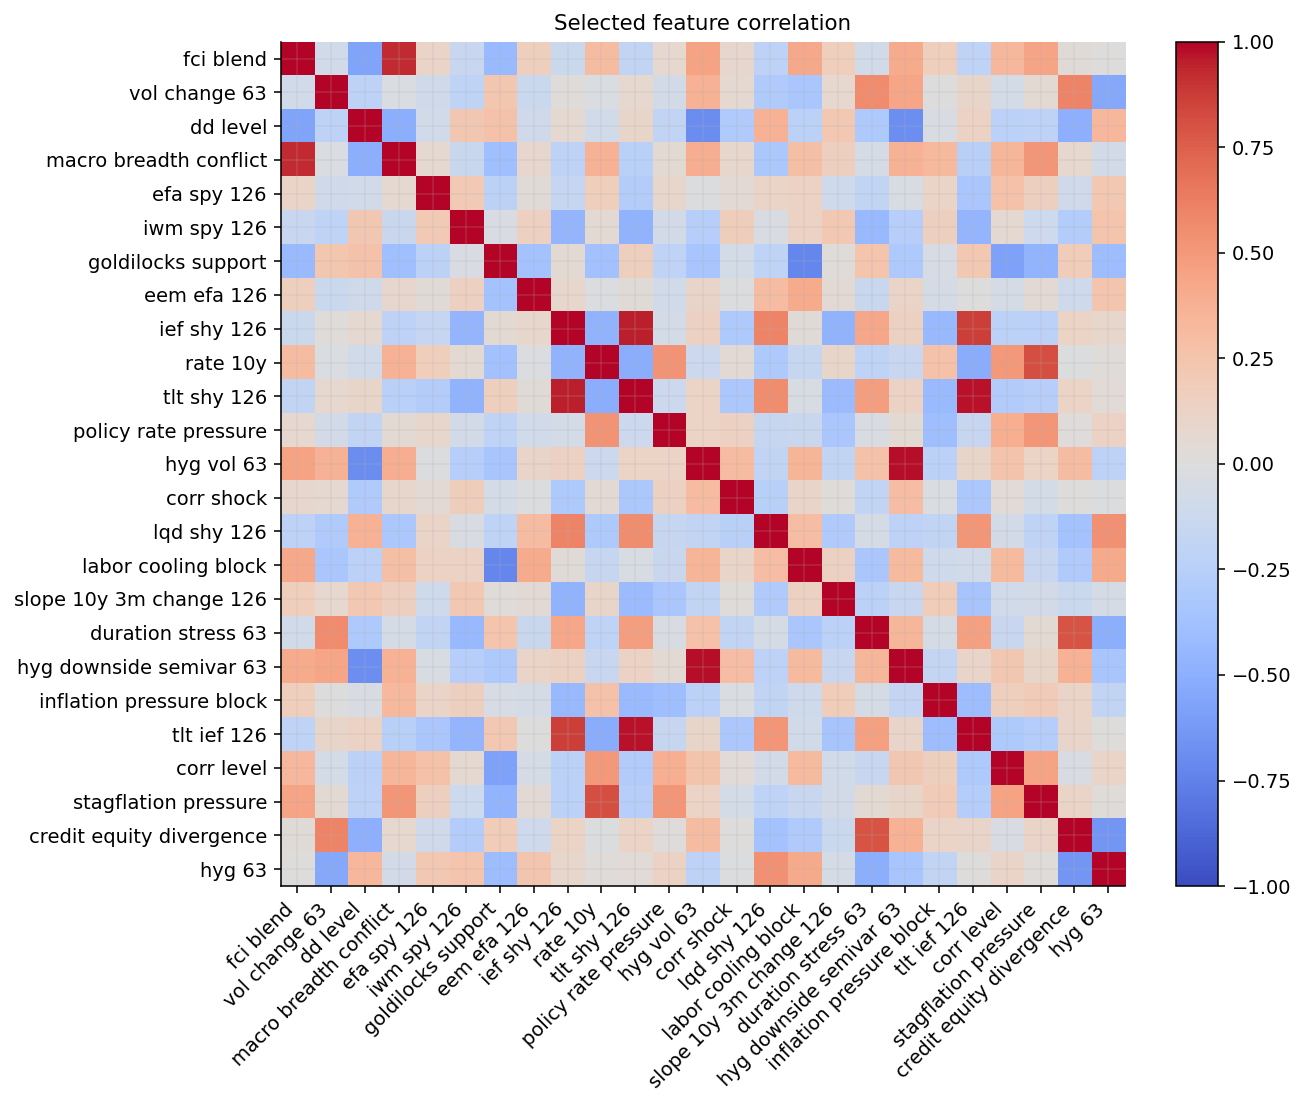

In [84]:
fig, ax = plt.subplots(figsize=(10.5, 8.0))
plot_corr_heatmap(ax, x_raw.corr(), title="Selected feature correlation", annotate=False)
plt.tight_layout()
plt.show()

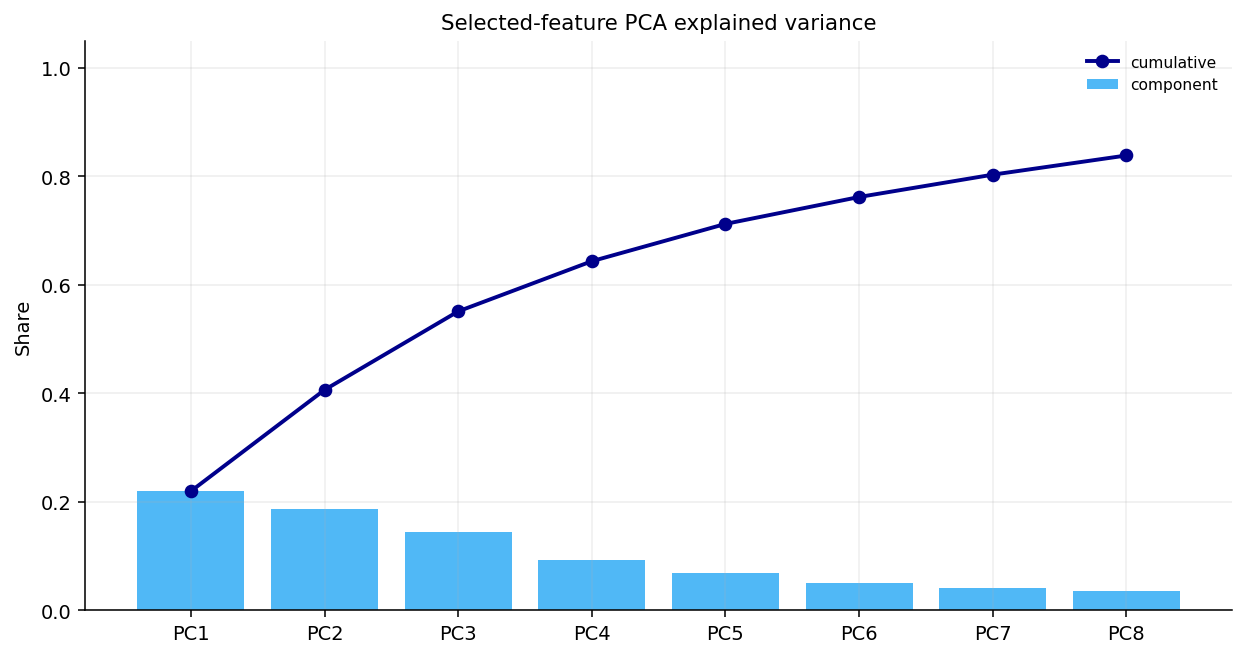

In [85]:
fig, ax = plt.subplots(figsize=(9.0, 4.8))
ax.bar(pca_explained.index, pca_explained["explained_variance_ratio"], color=LAB_COLORS[0], alpha=0.70, label="component")
ax.plot(pca_explained.index, pca_explained["cumulative"], color=LAB_COLORS[2], marker="o", lw=2.0, label="cumulative")
ax.set_title("Selected-feature PCA explained variance")
ax.set_ylabel("Share")
ax.set_ylim(0, 1.05)
ax.grid(True, axis="y", alpha=0.22)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

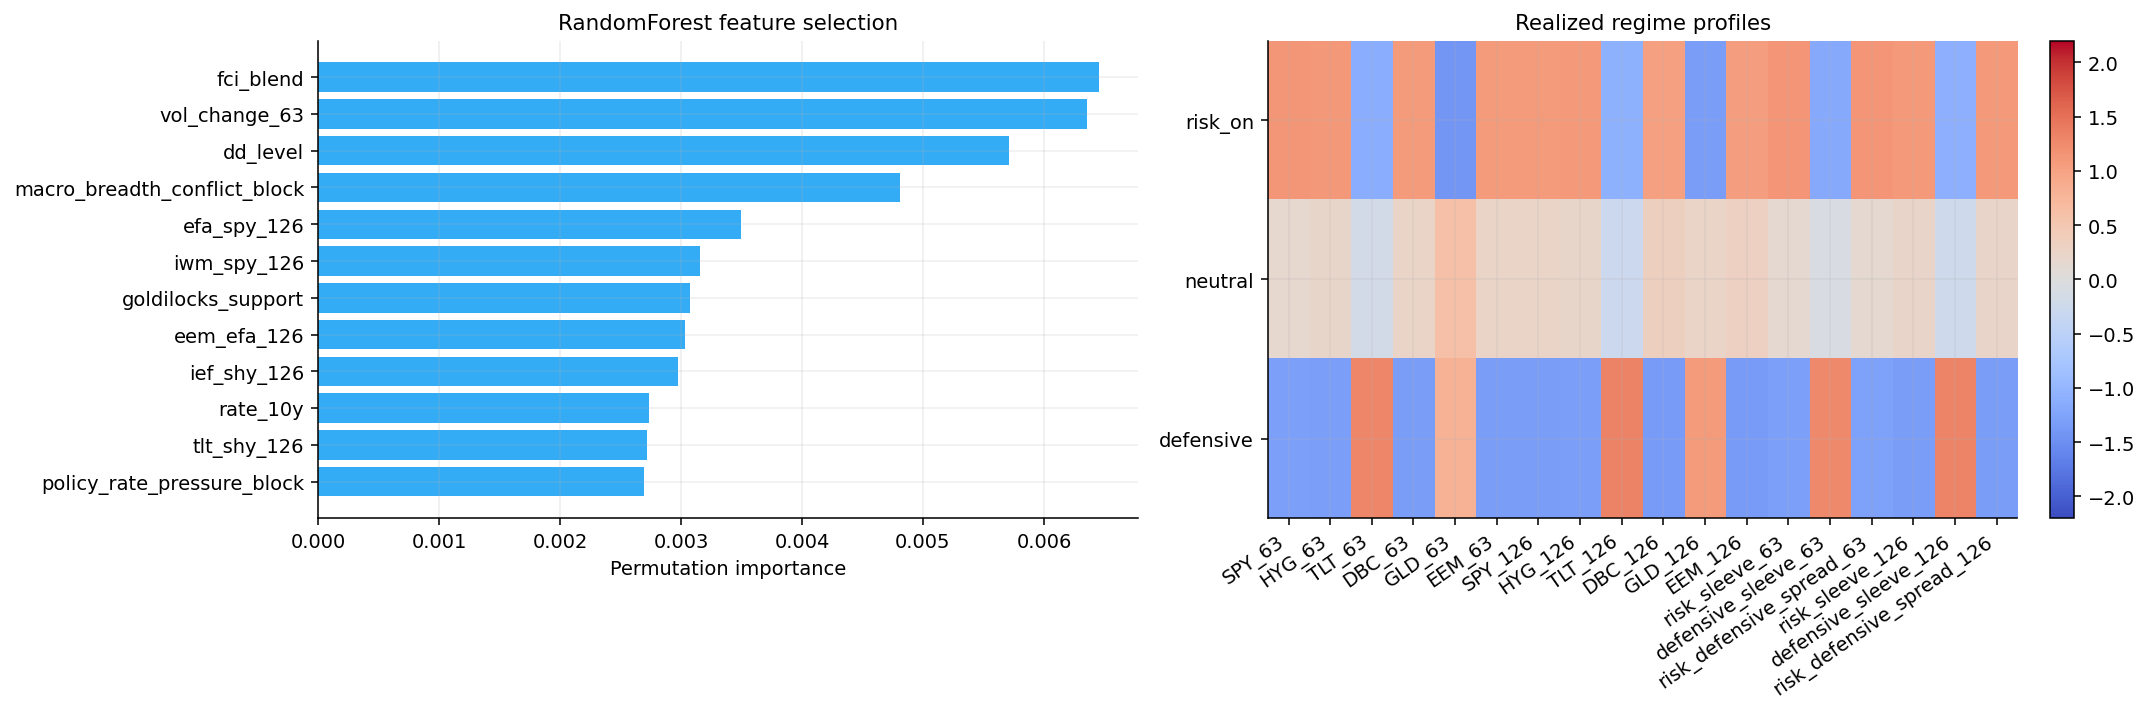

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.2))
top_imp = importance.head(12).sort_values("permutation_importance")
axes[0].barh(top_imp["feature"], top_imp["permutation_importance"], color=LAB_COLORS[0], alpha=0.82)
axes[0].set_title("RandomForest feature selection")
axes[0].set_xlabel("Permutation importance")
axes[0].grid(True, axis="x", alpha=0.22)
profile_plot = realized_profile_show.copy()
profile_plot = (profile_plot - profile_plot.mean()) / profile_plot.std(ddof=0).replace(0.0, np.nan)
im = axes[1].imshow(profile_plot.fillna(0.0).values, aspect="auto", cmap="coolwarm", vmin=-2.2, vmax=2.2)
axes[1].set_yticks(range(len(profile_plot.index)))
axes[1].set_yticklabels(profile_plot.index)
axes[1].set_xticks(range(len(profile_plot.columns)))
axes[1].set_xticklabels([c.replace("outcome_", "") for c in profile_plot.columns], rotation=35, ha="right")
axes[1].set_title("Realized regime profiles")
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

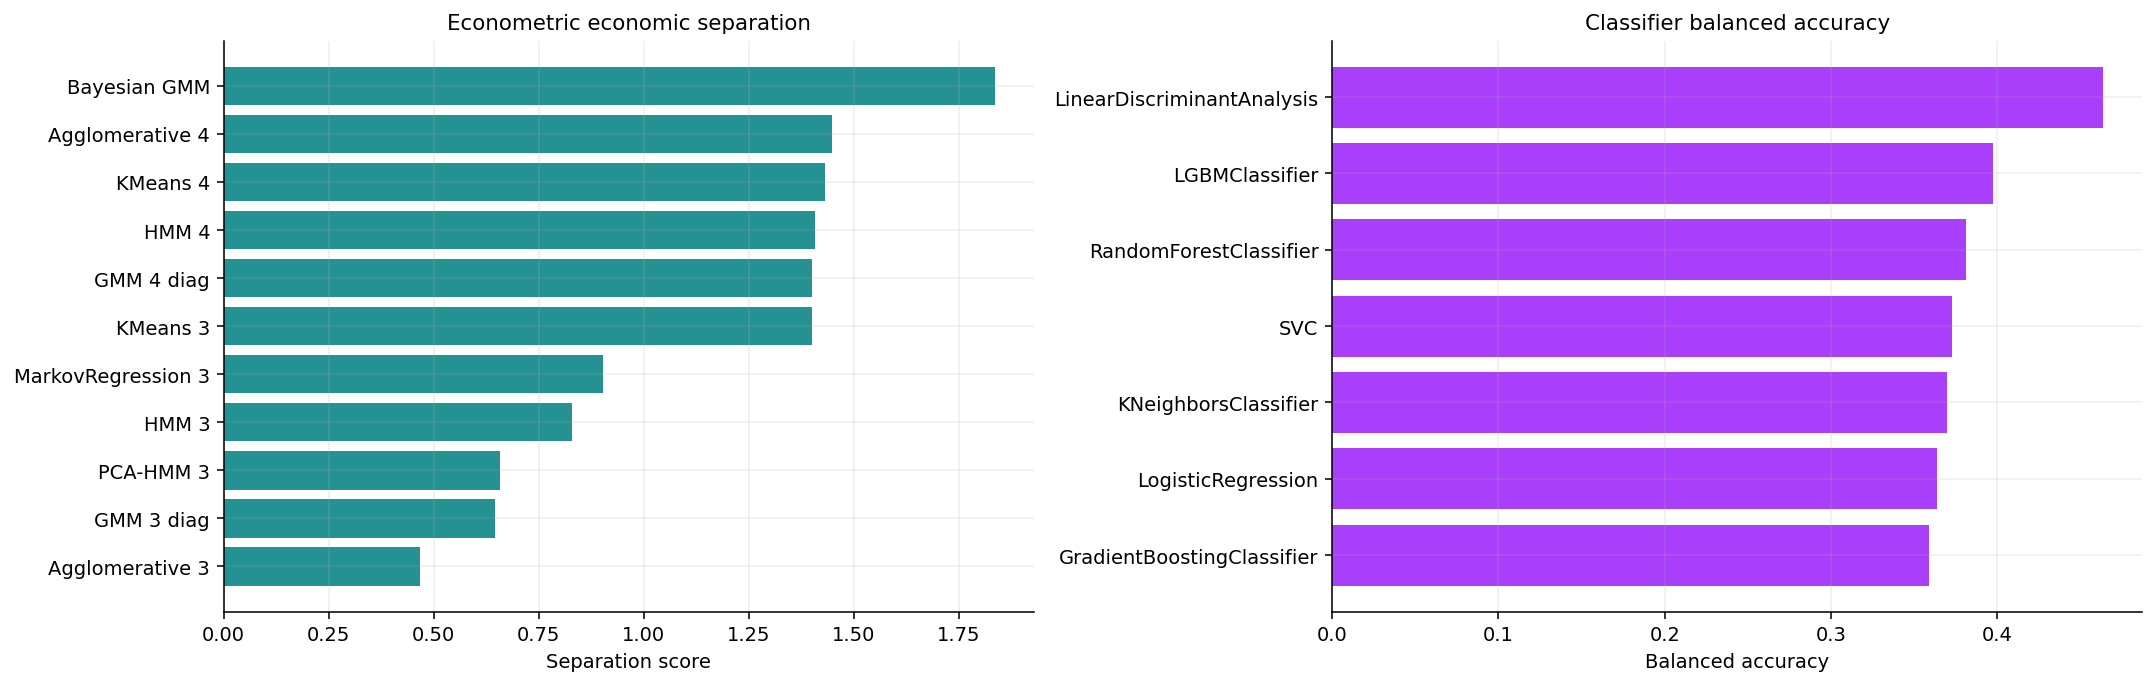

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.0))
eco_show = eco_quality["economic_separation"].sort_values()
axes[0].barh(eco_show.index, eco_show.values, color=LAB_COLORS[3], alpha=0.86)
axes[0].set_title("Econometric economic separation")
axes[0].set_xlabel("Separation score")
axes[0].grid(True, axis="x", alpha=0.22)
ml_show = classifier_table["balanced_accuracy"].sort_values()
axes[1].barh(ml_show.index, ml_show.values, color=LAB_COLORS[6], alpha=0.82)
axes[1].set_title("Classifier balanced accuracy")
axes[1].set_xlabel("Balanced accuracy")
axes[1].grid(True, axis="x", alpha=0.22)
plt.tight_layout()
plt.show()

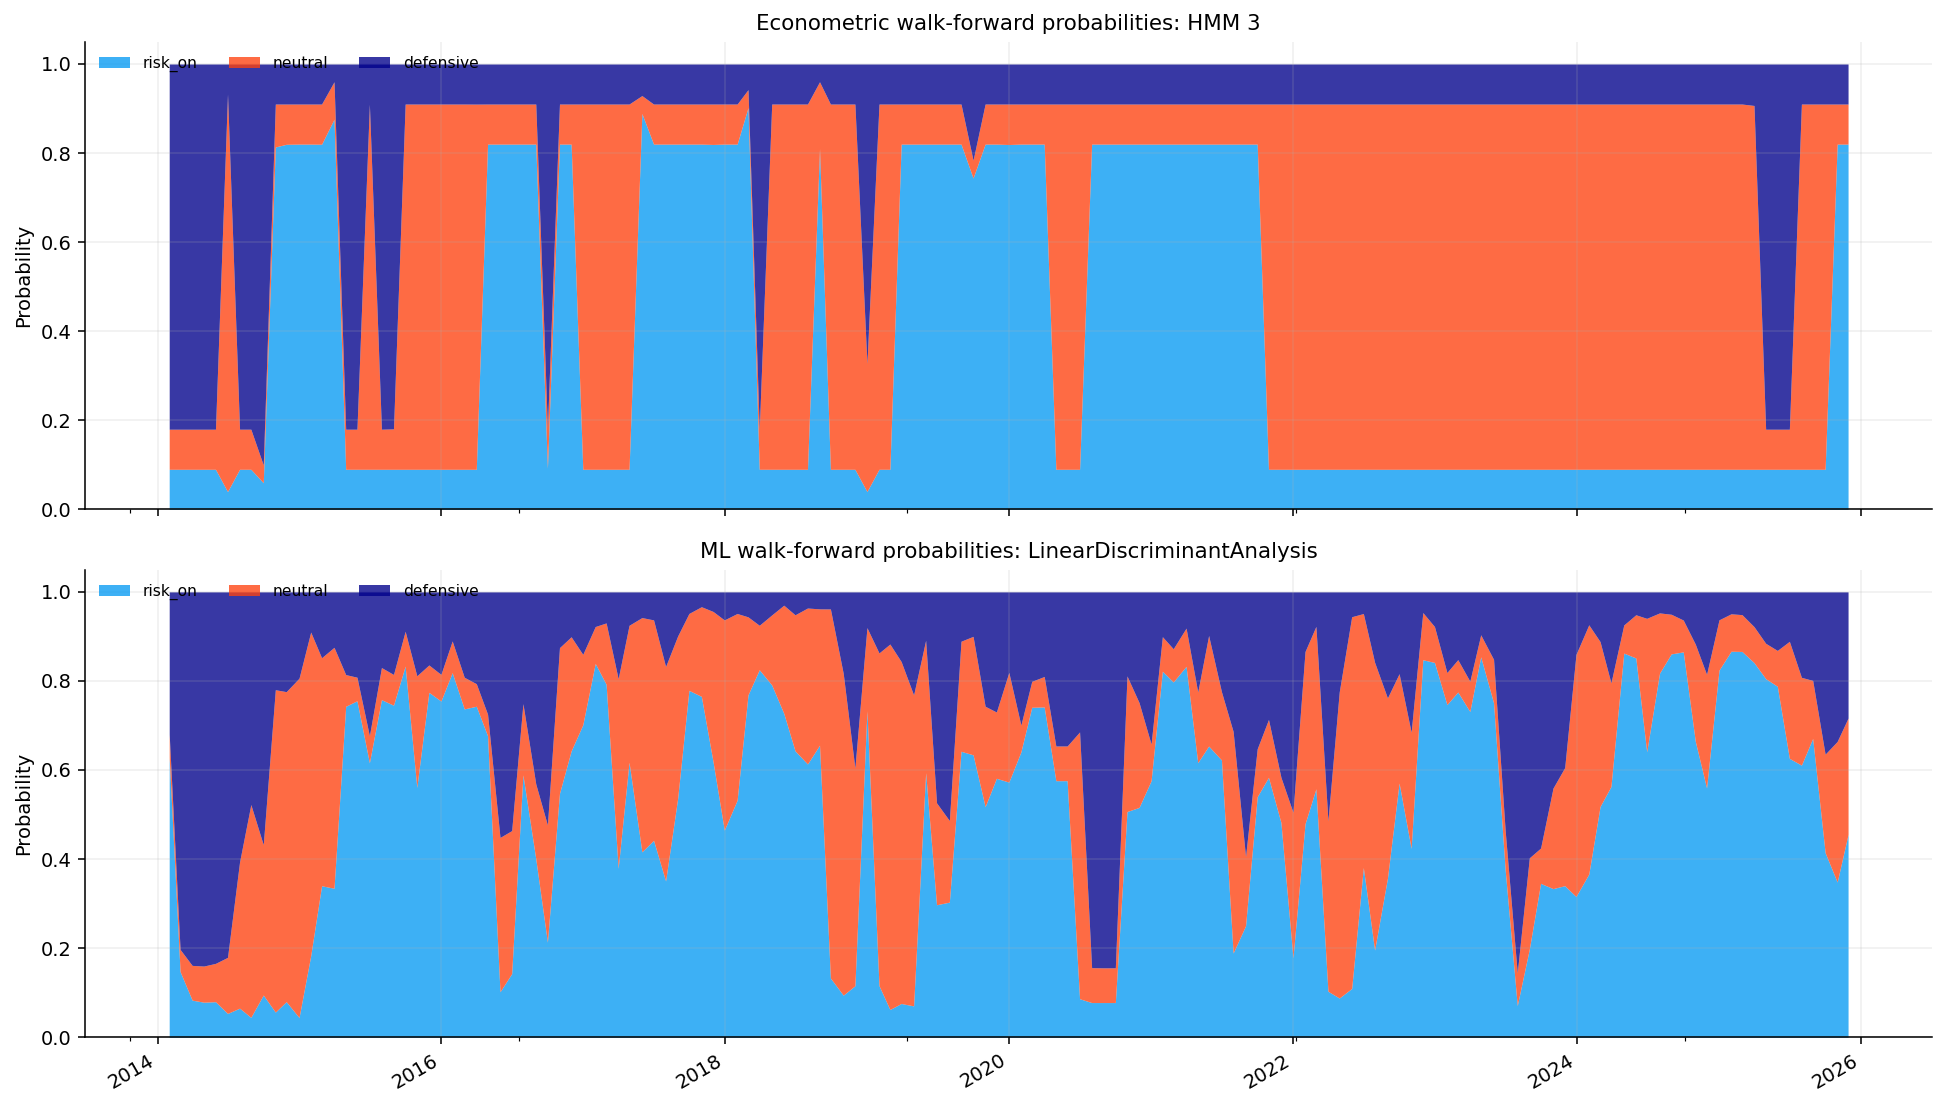

In [88]:
fig, axes = plt.subplots(2, 1, figsize=(14.0, 8.0), sharex=True)
p_eco.plot.area(ax=axes[0], stacked=True, color=LAB_COLORS[:p_eco.shape[1]], alpha=0.78, linewidth=0)
axes[0].set_title(f"Econometric walk-forward probabilities: {best_eco}")
axes[0].set_ylabel("Probability")
axes[0].legend(ncol=p_eco.shape[1], frameon=False, loc="upper left")
p_ml.plot.area(ax=axes[1], stacked=True, color=LAB_COLORS[:p_ml.shape[1]], alpha=0.78, linewidth=0)
axes[1].set_title(f"ML walk-forward probabilities: {best_ml}")
axes[1].set_ylabel("Probability")
axes[1].legend(ncol=p_ml.shape[1], frameon=False, loc="upper left")
plt.tight_layout()
plt.show()

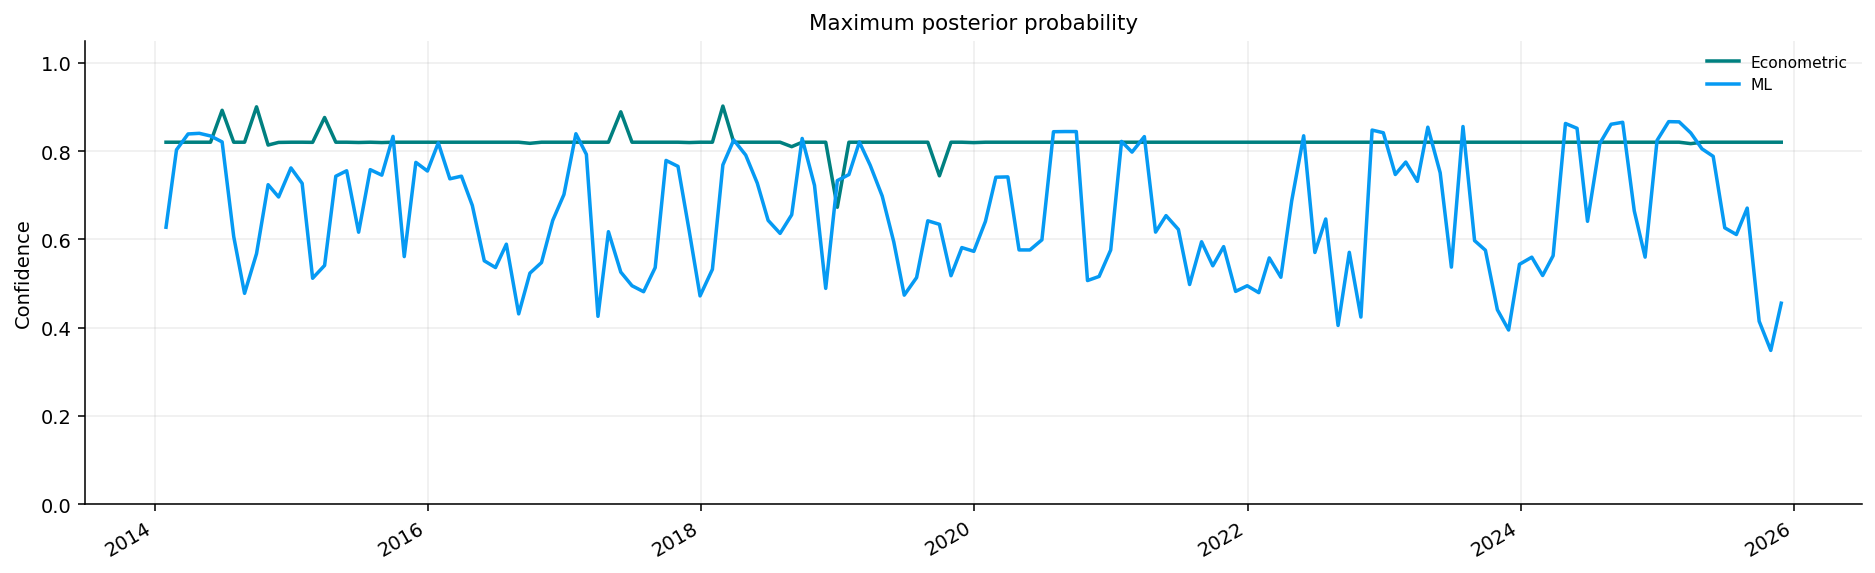

In [89]:
fig, ax = plt.subplots(figsize=(13.5, 4.2))
p_eco.max(axis=1).plot(ax=ax, color=LAB_COLORS[3], lw=1.8, label="Econometric")
p_ml.max(axis=1).plot(ax=ax, color=LAB_COLORS[0], lw=1.8, label="ML")
ax.set_title("Maximum posterior probability")
ax.set_ylabel("Confidence")
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.22)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

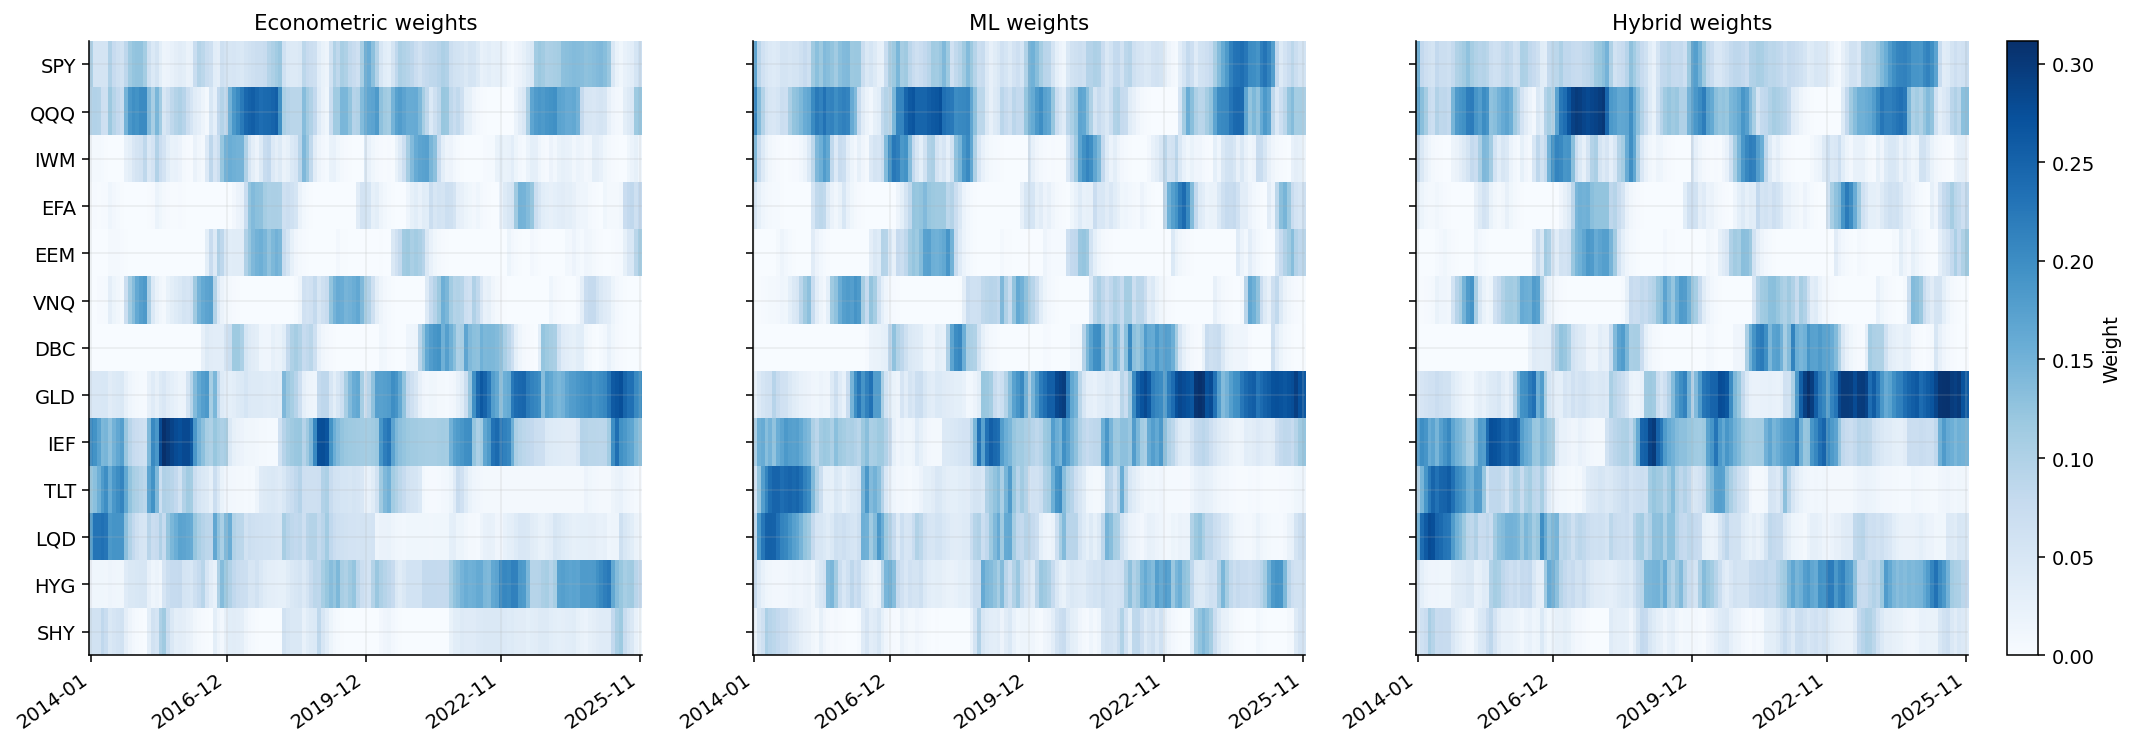

In [90]:
fig, axes = plt.subplots(1, 3, figsize=(18.0, 5.7), sharey=True)
for ax, schedule, title in zip(axes, [w_eco, w_ml, w_hybrid], ["Econometric weights", "ML weights", "Hybrid weights"], strict=False):
    im = ax.imshow(schedule.T.values, aspect="auto", cmap="Blues", vmin=0.0, vmax=max(0.22, float(schedule.max().max())))
    ax.set_title(title)
    ax.set_yticks(range(len(schedule.columns)))
    ax.set_yticklabels(schedule.columns)
    tick_pos = np.linspace(0, len(schedule.index) - 1, min(5, len(schedule.index))).astype(int)
    ax.set_xticks(tick_pos)
    ax.set_xticklabels([schedule.index[i].strftime("%Y-%m") for i in tick_pos], rotation=35, ha="right")
fig.colorbar(im, ax=axes, fraction=0.018, pad=0.02, label="Weight")
plt.show()

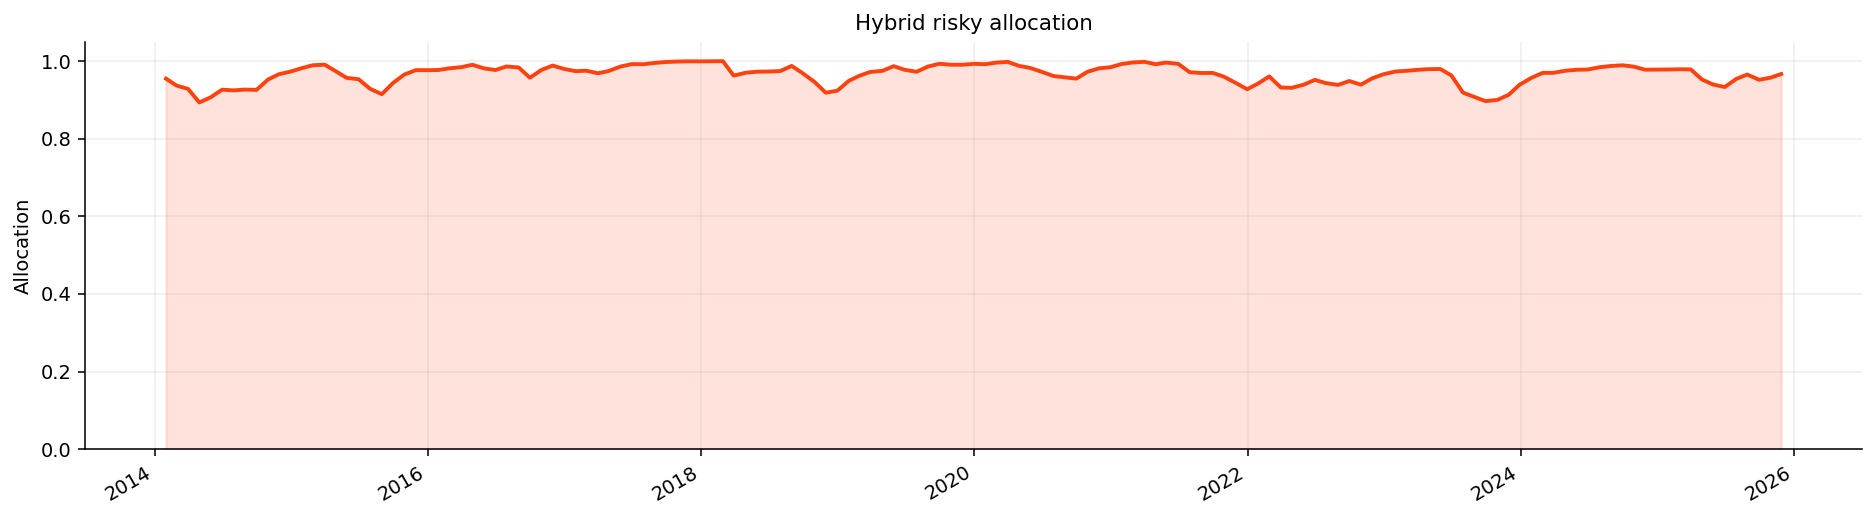

In [91]:
fig, ax = plt.subplots(figsize=(13.5, 3.8))
risky_hybrid.plot(ax=ax, color=LAB_COLORS[1], lw=2.0)
ax.fill_between(risky_hybrid.index, 0.0, risky_hybrid.values, color=LAB_COLORS[1], alpha=0.15)
ax.set_title("Hybrid risky allocation")
ax.set_ylabel("Allocation")
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.22)
plt.tight_layout()
plt.show()

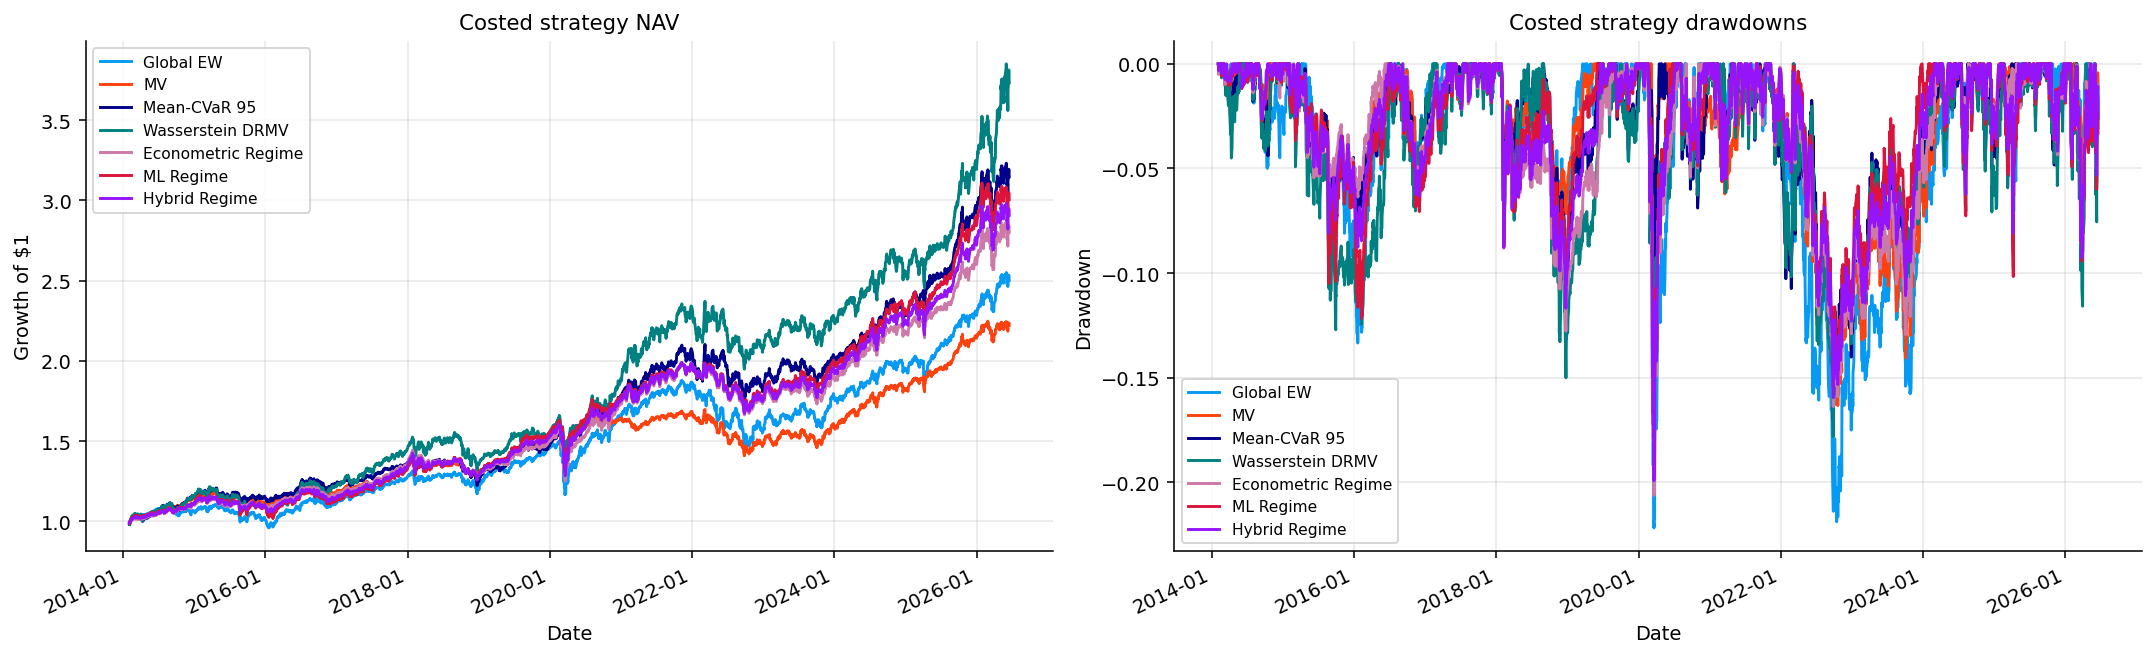

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(15.5, 4.8))
plot_strategy_nav(nav, ax=axes[0], title="Costed strategy NAV")
plot_strategy_drawdowns(nav, ax=axes[1], title="Costed strategy drawdowns")
plt.tight_layout()
plt.show()

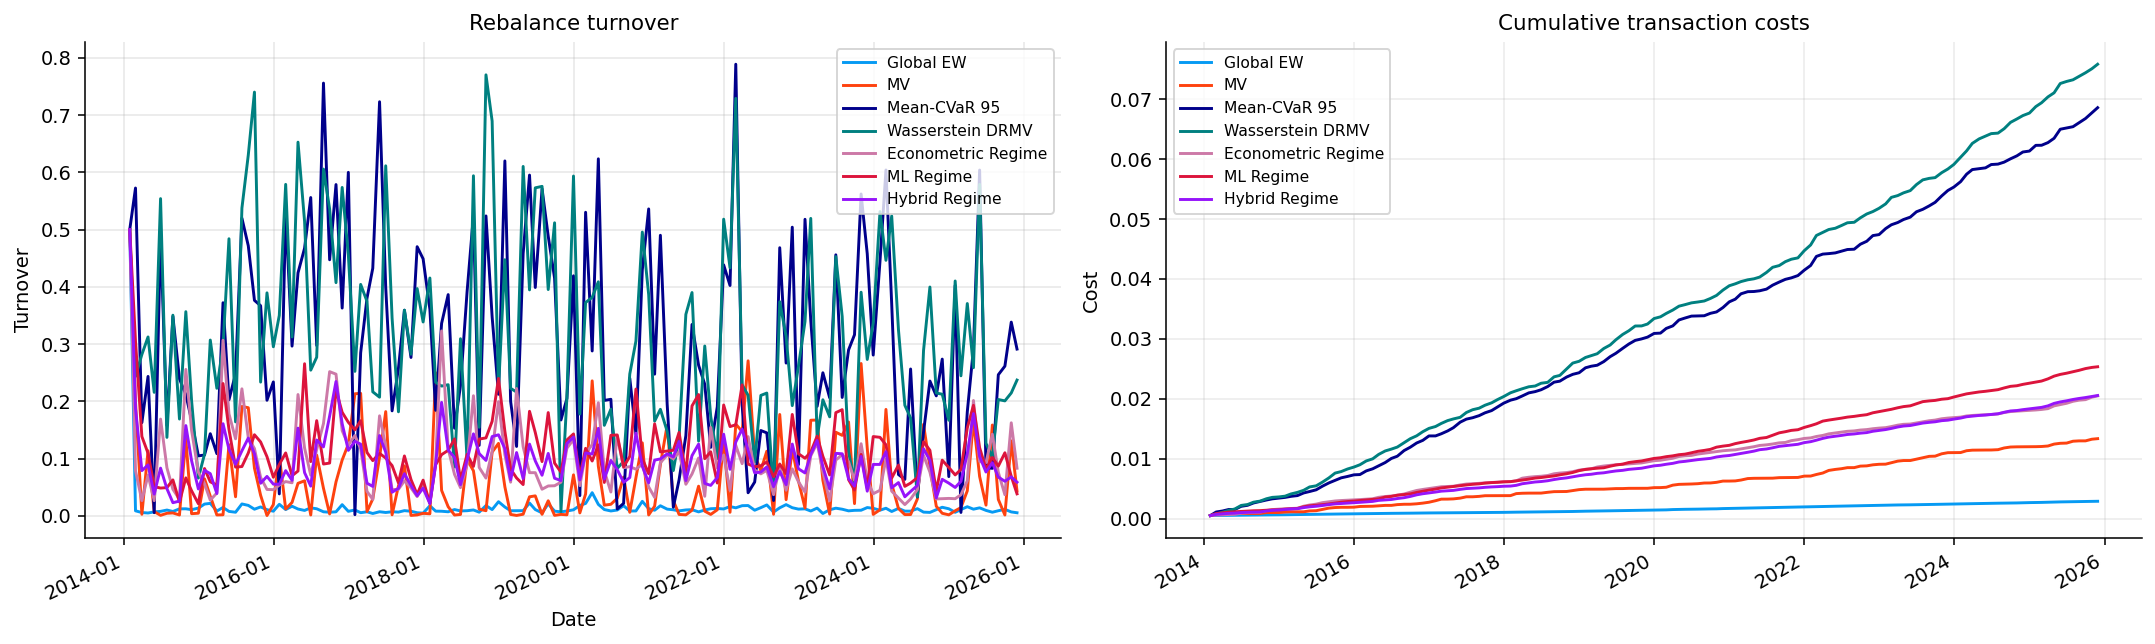

In [93]:
fig, axes = plt.subplots(1, 2, figsize=(15.5, 4.7))
plot_turnover(turnover, ax=axes[0], title="Rebalance turnover")
costs.cumsum().plot(ax=axes[1])
axes[1].set_title("Cumulative transaction costs")
axes[1].set_ylabel("Cost")
axes[1].grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

The weight heatmaps show the practical consequence of probabilities. Econometric, ML, and Hybrid schedules don't simply chase one asset. They rotate between GLD, duration, QQQ, EEM, SPY, HYG, and other assets depending on state probabilities and asset scores.

The hybrid risky allocation plot shows that the strategy usually keeps meaningful risk exposure, but it can reduce risk when defensive probability rises or uncertainty increases. This is a smoother way to implement regime switching than binary all-in/all-out rules.

The NAV and drawdown plots confirm the summary table: regime strategies improve over simpler baselines in some ways, but Wasserstein and Mean-CVaR remain very competitive. The drawdowns aren't eliminated. The regime layer is a probability-based allocation overlay, not a crash predictor with perfect timing.

The turnover and cumulative cost plots show that the hybrid strategy has controlled turnover compared with the more optimization-heavy portfolios. This is a practical strength. A model that looks good before costs but trades constantly can be fragile. Here, the regime schedules are smoothed and anchored, so turnover stays moderate.


The post-model diagnostic plots tie the project together. The feature-correlation heatmap confirms that the selected predictors still contain structured dependence. This is expected because macro stress, volatility, credit weakness, and drawdown often move together. The selected-feature PCA plot confirms that a few common factors explain much of the variation, but not all of it. The feature-importance plot shows that macro/FCI, volatility change, drawdown, and market-internal conflict are central to the final regime logic.

The probability plots are especially important. They show that HMM probabilities are more state-persistent, while ML probabilities are softer and more mixed. This is exactly what we expect from the model structures. HMM has a transition matrix, so it naturally resists rapid switching. LDA reads the current feature vector relative to class means, so it can express uncertainty when the current environment lies between historical regimes.

The weight heatmaps show that this probability difference becomes an allocation difference. The econometric schedule can make stronger regime moves. The ML schedule is more diversified. The hybrid combines both, so it doesn't become fully dependent on one modeling philosophy.

The latest hybrid snapshot is a good example. It has high risky allocation because the econometric model is strongly risk-on, but it still holds large GLD and IEF weights because the ML model is mixed and the asset scores favor some defensive/real-asset exposure. This isn't a contradiction. It is exactly what a soft regime allocation can produce: high total risk budget, but diversified across assets that currently score well.

That kind of portfolio would be hard to obtain from a binary regime rule. A binary rule might simply choose risk-on assets or defensive assets. The probability-weighted system can hold a state-aware mixture.


In [94]:
latest_dt = w_hybrid.index[-1]
latest_snapshot = pd.DataFrame(
    {
        "eco_probability": p_eco.loc[latest_dt],
        "ml_probability": p_ml.loc[latest_dt],
    }
)
latest_weights = w_hybrid.loc[latest_dt].sort_values(ascending=False).to_frame("hybrid_weight")
latest_risky = 1.0 - float(w_hybrid.loc[latest_dt, cash_ticker])
print("latest rebalance:", latest_dt.date())
display(latest_snapshot.round(4))
display(latest_weights[latest_weights["hybrid_weight"] > 0.001].round(4))
print("latest risky allocation:", round(latest_risky, 4))

latest rebalance: 2025-11-28


,eco_probability,ml_probability
risk_on,0.82,0.4553
neutral,0.09,0.2613
defensive,0.09,0.2833


,hybrid_weight
GLD,0.2579
IEF,0.1465
QQQ,0.1329
EEM,0.1170
EFA,0.0850
HYG,0.0807
SPY,0.0738
LQD,0.0442
SHY,0.0333
IWM,0.0172


latest risky allocation: 0.9667


The latest snapshot is economically interesting. The econometric model gives 82% risk-on probability, while the ML model is more mixed: about 45.5% risk-on, 26.1% neutral, and 28.3% defensive. The hybrid allocation responds by taking high risky allocation, around 96.7%, but with a large gold and intermediate Treasury component.

That combination can happen because the portfolio construction separates **regime risk budget** from **asset ranking**. The regime budget says risk exposure can be high, but the asset scoring still sees GLD and IEF as strong or useful. This produces a portfolio that isn't a naive equity-only risk-on portfolio.

The latest hybrid weights are concentrated in GLD, IEF, QQQ, EEM, EFA, HYG, and SPY, with smaller SHY, IWM, TLT, and DBC. This fits a late-sample environment where equity leadership and EM strength are present, but gold and duration still carry important diversification roles.


,hist_var5,hist_es5,cf_var5,cf_es5,fhs_var5,fhs_es5
object,,,,,,
Econometric Regime,0.0086,0.0146,0.0095,0.0250,0.0219,0.0322
Global EW,0.0096,0.0153,0.0100,0.0273,0.0139,0.0212
Hybrid Regime,0.0090,0.0149,0.0095,0.0247,0.0210,0.0312
ML Regime,0.0094,0.0158,0.0101,0.0244,0.0195,0.0297
MV,0.0071,0.0112,0.0074,0.0138,0.0118,0.0178
Mean-CVaR 95,0.0100,0.0154,0.0104,0.0192,0.0225,0.0325
Wasserstein DRMV,0.0123,0.0190,0.0128,0.0220,0.0330,0.0477


breach_count  breach_rate  coverage_error  abs_coverage_error  longest_breach_streak  avg_gap_days  kupiec_p  christoffersen_p  \
object             method                                                                                                                                   
Econometric Regime cf               148       0.0517          0.0017              0.0017                      3       19.3946    0.6696            0.0049   
                   fhs              157       0.0549          0.0049              0.0049                      3       18.2564    0.2367            0.0068   
                   hist             158       0.0552          0.0052              0.0052                      3       18.1592    0.2053            0.0078   
Global EW          cf               162       0.0566          0.0066              0.0066                      4       17.7081    0.1101            0.0131   
                   fhs              154       0.0538          0.0038              0.0038                      3       18.6144    0.3510            0.0253   
                   hist             170       0.0594          0.0094              0.0094                      4       16.8994    0.0243            0.0028   
Hybrid Regime      cf               145       0.0507          0.0007              0.0007                      3       19.7986    0.8641            0.0001   
                   fhs              159       0.0556          0.0056              0.0056                      3       18.0443    0.1772            0.0037   
                   hist             162       0.0566          0.0066              0.0066                      3       17.7081    0.1101            0.0001   
ML Regime          cf               154       0.0538          0.0038              0.0038                      3       18.6536    0.3510            0.0006   
                   fhs              159       0.0556          0.0056              0.0056                      3       18.0443    0.1772            0.0005   
                   hist             168       0.0587          0.0087              0.0087                      3       17.0898    0.0366            0.0051   
MV                 cf               140       0.0490         -0.0010              0.0010                      4       20.5108    0.7962            0.0000   
                   fhs              156       0.0545          0.0045              0.0045                      3       18.3742    0.2714            0.0142   
                   hist             161       0.0563          0.0063              0.0063                      4       17.8188    0.1297            0.0000   
Mean-CVaR 95       cf               155       0.0542          0.0042              0.0042                      4       18.5130    0.3094            0.0020   
                   fhs              150       0.0524          0.0024              0.0024                      3       19.1141    0.5512            0.0157   
                   hist             164       0.0573          0.0073              0.0073                      4       17.4908    0.0780            0.0002   
Wasserstein DRMV   cf               156       0.0545          0.0045              0.0045                      3       18.3935    0.2714            0.0023   
                   fhs              157       0.0549          0.0049              0.0049                      3       18.2564    0.2367            0.0353   
                   hist             168       0.0587          0.0087              0.0087                      3       17.0719    0.0366            0.0022   

                           quantile_loss  accuracy_rank  accuracy_score  is_best  
object             method                                                         
Econometric Regime cf             0.0008            1.0          0.1250     True  
                   fhs            0.0007            1.0          0.1250    False  
                   hist           0.0008            3.0          0.0909    False  


,object,cum_return,max_dd,worst_day,worst_week
window,,,,,
2018 Q4,Econometric Regime,-0.0662,-0.0855,-0.0168,-0.0253
2018 Q4,Global EW,-0.0720,-0.0964,-0.0165,-0.0322
2018 Q4,Hybrid Regime,-0.0706,-0.0896,-0.0192,-0.0240
2018 Q4,ML Regime,-0.0742,-0.0929,-0.0212,-0.0238
2018 Q4,MV,-0.0389,-0.0516,-0.0113,-0.0166
2018 Q4,Mean-CVaR 95,-0.0819,-0.1011,-0.0150,-0.0334
2018 Q4,Wasserstein DRMV,-0.1080,-0.1252,-0.0239,-0.0426
2022 rates/inflation shock,Econometric Regime,-0.1427,-0.1582,-0.0262,-0.0277
2022 rates/inflation shock,Global EW,-0.1865,-0.2110,-0.0324,-0.0392


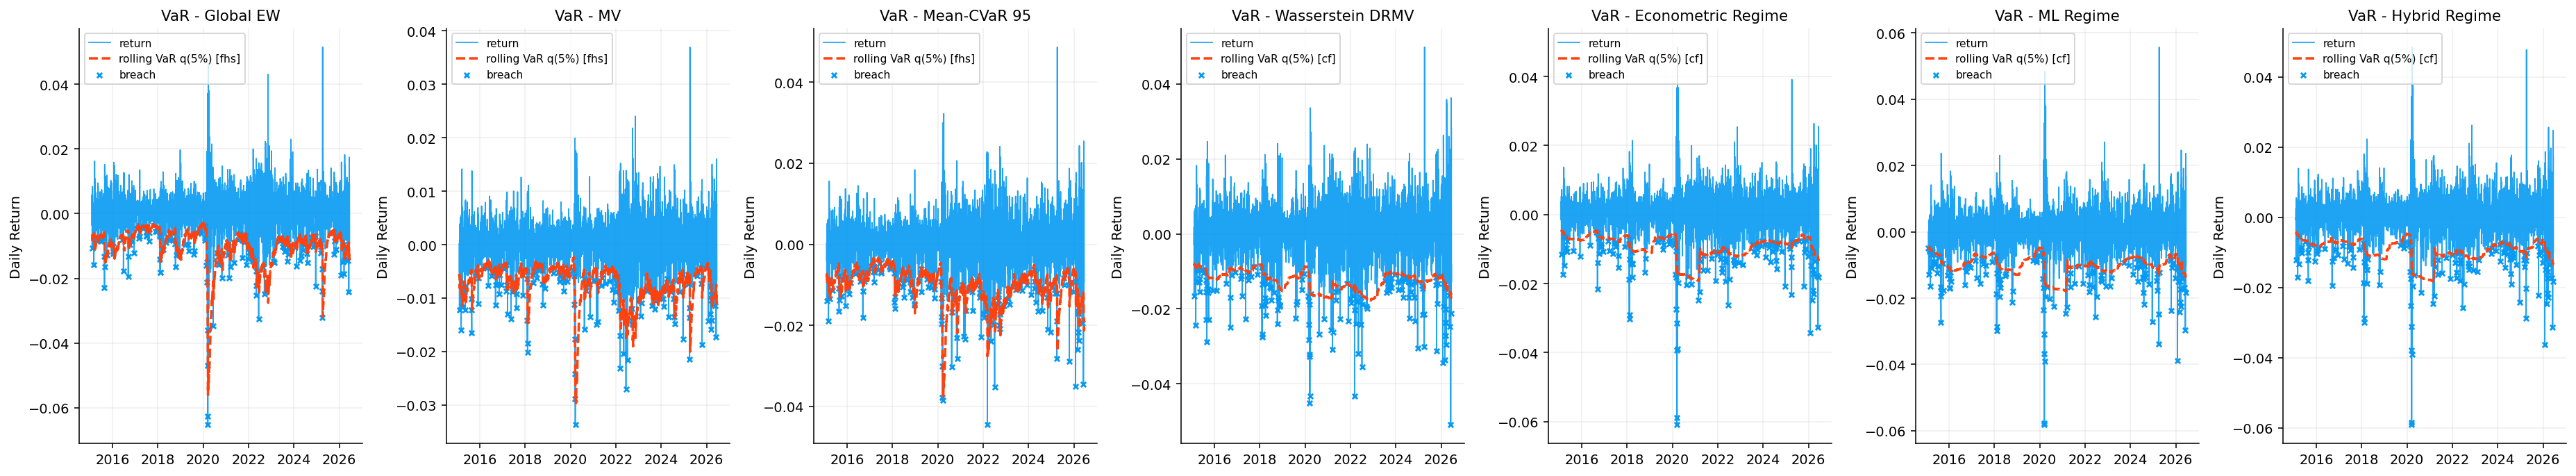

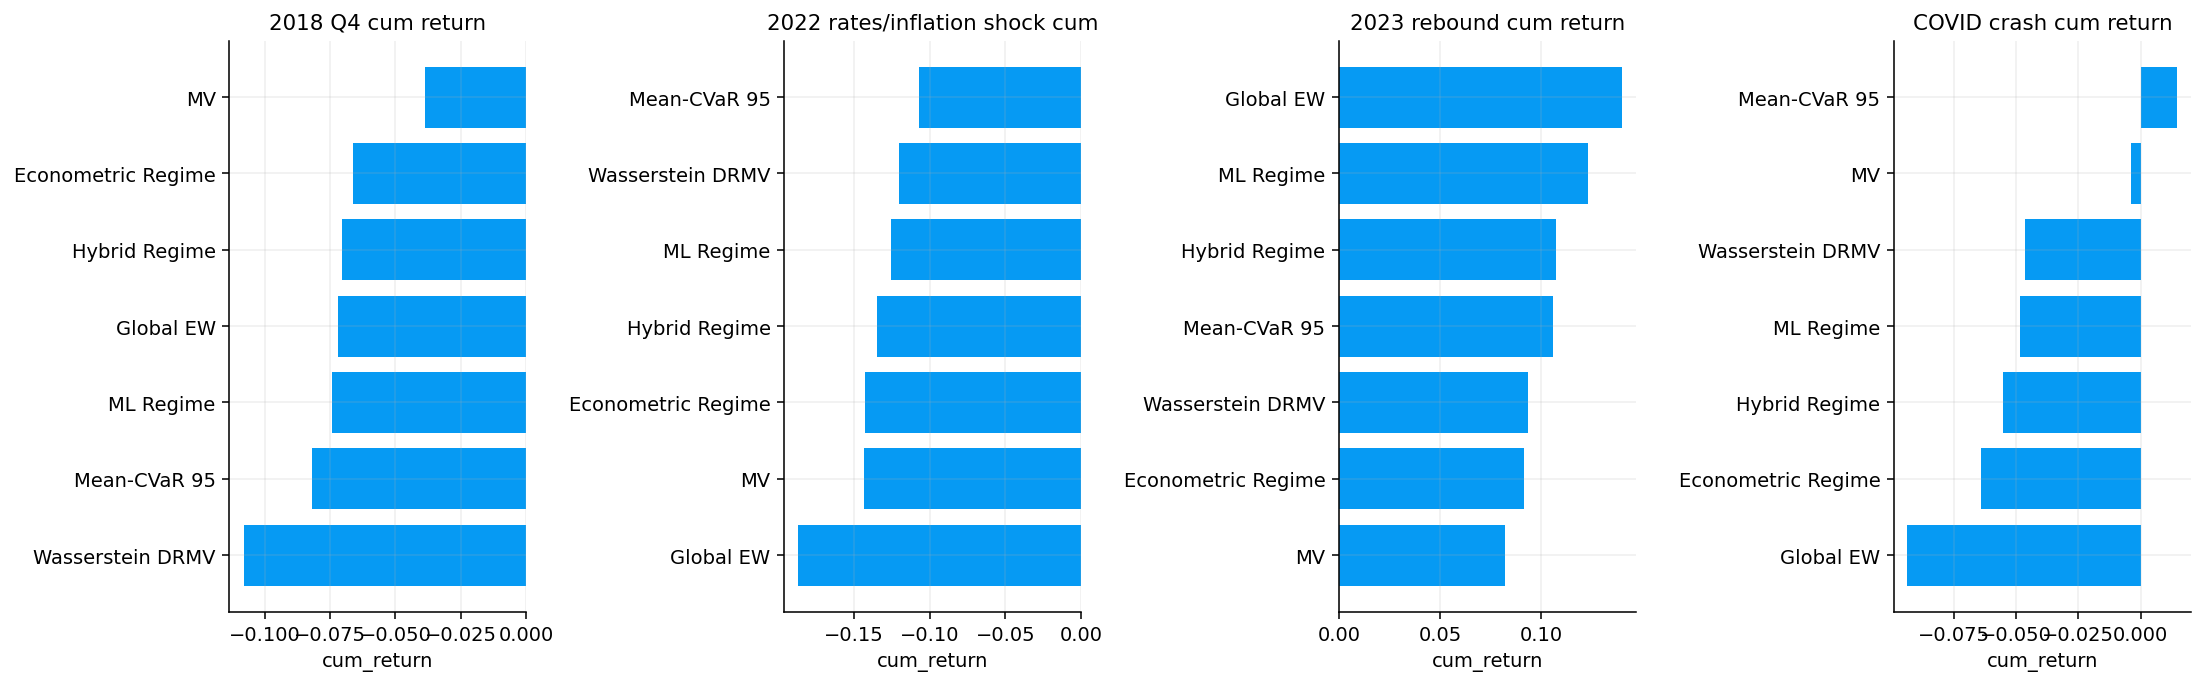

In [95]:
stress_windows = {
    "2018 Q4": ("2018-10-01", "2018-12-31"),
    "COVID crash": ("2020-02-20", "2020-04-30"),
    "2022 rates/inflation shock": ("2022-01-03", "2022-10-31"),
    "2023 rebound": ("2023-01-01", "2023-12-31"),
}
available_windows = {
    name: window
    for name, window in stress_windows.items()
    if strategy_returns.index.min() <= pd.Timestamp(window[1]) and strategy_returns.index.max() >= pd.Timestamp(window[0])
}
risk_report_artifacts = risk_report(
    objects={name: strategy_returns[name].dropna() for name in strategy_returns.columns},
    rf_daily=rf_daily,
    include={
        "performance_tables": False,
        "shape_tables": False,
        "drawdowns": False,
        "drawdown_episodes": False,
        "var_es": True,
        "var_backtest": True,
        "stress": True,
        "capm": False,
        "rolling_beta": False,
        "correlation": False,
        "attribution": False,
        "exec_bullets": False,
    },
    var_settings={"alpha": 0.05, "methods": ["hist", "cf", "fhs"]},
    backtest_settings={"alpha": 0.05, "methods": ["hist", "cf", "fhs"], "lookback": 252, "plot_method": "best"},
    stress_settings={"windows": available_windows, "worst_only": False},
    layout={"ncols": len(strategy_returns.columns), "sharex": True, "sharey": False},
    output={"display_table_keys": ["var_es", "var_backtest", "stress"], "round_tables": 4, "short_labels": False},
)

The risk report adds another layer. MV has the lowest VaR/ES numbers because it is defensive and low-volatility. Wasserstein DRMV has higher return but also higher VaR/ES. The regime portfolios sit in the middle.

For VaR backtesting, the target breach rate is 5%. The Cornish-Fisher VaR method for the Hybrid Regime is very close, with a breach rate around 5.07%. The Econometric Regime CF method is also close, around 5.17%. That means unconditional coverage is reasonable. However, the Christoffersen p-values are often low, which indicates breach clustering. This is common in financial returns because losses cluster during stress periods rather than arriving independently.

That is a useful limitation. The regime model helps adapt weights, but it doesn't eliminate volatility clustering. When a crisis begins, breaches can still cluster before the model fully adapts or before the portfolio can rebalance.

The stress-window table shows the same pattern. During COVID, all strategies suffer significant losses because the crash is fast. During the 2022 rates/inflation shock, robust and tail-aware models generally handle the period better than pure equal weight, while the regime strategies reduce some risk but don't dominate. In 2023 rebound, ML and riskier strategies capture more upside than the more defensive regime variant.

The interpretation is balanced: regime learning is valuable, but it isn't magic. It improves state awareness and gives dynamic allocation logic, but it still faces delay, label noise, model uncertainty, and regime changes that don't look like the past.


The risk diagnostics show the same tradeoff from a tail perspective. MV has the lowest VaR and ES because it carries less volatility. Wasserstein has higher VaR/ES because it takes more return-seeking exposure. The regime models sit in the middle.

Historical VaR at 5% is the empirical 5th percentile of returns:

$$
VaR_{5\%}^{\text{hist}} = -q_{0.05}(R_p)
$$

Historical ES averages losses beyond that quantile:

$$
ES_{5\%}^{\text{hist}} = -E[R_p \mid R_p \le q_{0.05}(R_p)]
$$

Cornish-Fisher VaR adjusts the normal quantile using skewness and kurtosis. This helps when returns aren't normal, but it can still fail in clustered crisis periods. Filtered historical simulation uses volatility-standardized residuals and then rescales them by current volatility, which makes it more adaptive to changing risk conditions.

The breach-rate target for 5% VaR is 5%. Hybrid CF VaR is very close, around 5.07%, and Econometric Regime CF VaR is also close, around 5.17%. That means unconditional coverage is reasonable. But Christoffersen tests often show low p-values, meaning breaches are clustered. This is common in financial returns. Losses aren't independent. They arrive in stress clusters.

The regime model helps adapt exposure, but it doesn't remove the fundamental clustering of losses. That is an important limitation. Regime probabilities can reduce risk when the model sees stress building, but sudden shocks and volatility cascades can still create clustered breaches.


The final system still has model risk, and it is important to state it inside the workflow rather than hiding it at the end.

**Regime labels are constructed, not observed.** There is no official "true" risk-on or defensive label. We define labels from future risk-versus-defensive sleeve performance. That target is economically sensible, but another investor could define regimes differently. A volatility-targeting investor might use realized drawdowns. A macro investor might use recession indicators. A credit investor might use spreads.

**The feature set is engineered.** Strong feature engineering is a strength, but it also means the model inherits the researcher's assumptions. We decide that credit, duration, FCI, breadth, and relative momentum matter. That is defensible, but it is still a modeling choice.

**The sample has few true crises.** Even with data back to the late 1990s, the number of independent defensive regimes is small. Dot-com, GFC, COVID, 2022 inflation shock, and a few smaller episodes don't cover every possible future crisis. A model can learn past stress signatures and still miss a new type of stress.

**Probabilities aren't guarantees.** A 70% risk-on probability means the model sees an environment historically associated with risk-on outcomes. It doesn't mean risk assets must outperform. The portfolio layer handles this by blending, smoothing, anchoring, and using entropy, but the uncertainty remains.

**Economic performance can change.** The sector application shows ML working better than in the cross-asset application. That doesn't mean ML will always be better for sectors. It means that in this sample and design, sector rotation offered more repeatable patterns for the supervised model.

These limitations aren't reasons to discard the project. They are reasons to evaluate it like a real model. A useful regime framework should be interpretable, tested against strong baselines, honest about uncertainty, and robust enough that one wrong state probability doesn't destroy the portfolio.


## 14) Sector Regime Switching with the Library

The final cell repeats the full regime-switching workflow on a sector ETF universe using the packaged library implementation. This is the secondary application. The data again comes from:

- [data/core_cross_asset_etfs](https://github.com/ramtin-asadi/Quantitative-Finance-Lab/tree/main/data/core_cross_asset_etfs)
- [data/sector_etfs](https://github.com/ramtin-asadi/Quantitative-Finance-Lab/tree/main/data/sector_etfs)

The sector tradable universe includes XLB, XLE, XLF, XLI, XLK, XLP, XLU, XLV, XLY, IYR, and IYZ. This application is different from the main cross-asset one because all tradable assets are equity sectors. There is still a cash proxy, SHY, but the main rotation is inside equity sectors.

The sector features are built around sector breadth, dispersion, cyclicals vs defensives, technology leadership, energy/materials versus rates, real estate versus duration, sector drawdown, sector average volatility, sector correlations, leadership concentration, and rotation spread. These features are more about **equity market internals** than global cross-asset allocation.

The realized sector regimes are defined from future sector sleeve behavior:

- growth sleeve: XLK and XLY,
- cyclical sleeve: XLF, XLI, XLB, XLE, IYR, IYZ,
- inflation sleeve: XLE and XLB,
- defensive sleeve: XLP, XLU, XLV plus some SHY.

This setup asks a different question: given current market internals, should the sector portfolio lean into growth, cyclicals, inflation beneficiaries, defensives, or cash?


,states,loglike,aic,bic,silhouette,min_state_share,avg_state_duration,transitions_per_year,posterior_confidence,posterior_entropy,economic_separation
model,,,,,,,,,,,
KMeans 3,3,NaN,NaN,NaN,0.2350,0.1419,25.4615,9.0626,NaN,NaN,0.6045
KMeans 4,4,NaN,NaN,NaN,0.2034,0.1358,28.9220,8.7880,NaN,NaN,0.8635
Agglomerative 3,3,NaN,NaN,NaN,0.2518,0.0911,107.6793,1.8308,NaN,NaN,0.8579
Agglomerative 4,4,NaN,NaN,NaN,0.1760,0.0911,83.3756,2.6547,NaN,NaN,0.9266
GMM 3,3,-40662.8497,81473.6994,81913.0123,0.2331,0.1312,38.3258,6.0417,0.9699,0.0676,0.5975
GMM 4,4,-39127.9137,78453.8275,79041.5568,0.2084,0.1372,34.3378,6.9571,0.9654,0.0622,0.7579
Bayesian GMM,6,-37102.8463,NaN,NaN,0.1304,0.0736,37.2929,7.2318,0.9675,0.0481,1.0557
MarkovRegression 3,3,-3300.1979,6624.3957,6695.6357,0.0744,0.0229,25.2037,8.2387,0.9099,0.2001,1.3459
HMM 3,3,-41559.5806,83279.1612,83754.0940,0.0354,0.3181,33.6296,175.3932,0.6907,0.4359,0.2135


,accuracy,balanced_accuracy,macro_f1,log_loss
model,,,,
Logistic,0.3362,0.3194,0.2748,1.7724
LDA,0.4765,0.3121,0.3068,1.3474
RandomForest,0.4346,0.3253,0.3004,0.9965
GradientBoosting,0.5507,0.3166,0.3125,0.9704
SVM,0.4188,0.4018,0.2959,1.0881
KNN,0.4822,0.3719,0.3273,4.9350
LightGBM,0.5478,0.3218,0.3100,1.2833


best econometric: PCA-HMM 3
best ML: GradientBoosting


,selected_features
0,sector_avg_corr_252
1,sector_avg_vol_change_63
2,dbc_ief_126
3,sector_corr_shock
4,sector_avg_vol_63
5,gld_spy_126
6,fin_ind_mat_energy_def_126
7,sector_corr_change_63
8,rotation_spread_126
9,hyg_lqd_change_63


,observations,share,XLB_63,XLE_63,XLF_63,XLI_63,XLK_63,XLP_63,XLU_63,XLV_63,XLY_63,IYR_63,IYZ_63,XLB_126,XLE_126,XLF_126,XLI_126,XLK_126,XLP_126,XLU_126,XLV_126,XLY_126,IYR_126,IYZ_126,growth_sleeve_63,cyclical_sleeve_63,inflation_sleeve_63,risk_sleeve_63,defensive_sleeve_63,risk_defensive_spread_63,growth_sleeve_126,cyclical_sleeve_126,inflation_sleeve_126,risk_sleeve_126,defensive_sleeve_126,risk_defensive_spread_126,outcome_XLB_63,outcome_XLE_63,outcome_XLF_63,outcome_XLI_63,outcome_XLK_63,outcome_XLP_63,outcome_XLU_63,outcome_XLV_63,outcome_XLY_63,outcome_IYR_63,outcome_IYZ_63,outcome_XLB_126,outcome_XLE_126,outcome_XLF_126,outcome_XLI_126,outcome_XLK_126,outcome_XLP_126,outcome_XLU_126,outcome_XLV_126,outcome_XLY_126,outcome_IYR_126,outcome_IYZ_126,outcome_growth_sleeve_63,outcome_cyclical_sleeve_63,outcome_inflation_sleeve_63,outcome_risk_sleeve_63,outcome_defensive_sleeve_63,outcome_risk_defensive_spread_63,outcome_growth_sleeve_126,outcome_cyclical_sleeve_126,outcome_inflation_sleeve_126,outcome_risk_sleeve_126,outcome_defensive_sleeve_126,outcome_risk_defensive_spread_126
risk_on,2049,0.6718,0.0517,0.0705,0.0582,0.0576,0.0776,0.0240,0.0234,0.0319,0.0587,0.0269,0.0261,0.0691,0.0929,0.0872,0.0831,0.1249,0.0421,0.0468,0.0576,0.0819,0.0367,0.0338,0.0682,0.0485,0.0611,0.1092,0.0190,0.0902,0.1034,0.0671,0.0810,0.1555,0.0358,0.1197,0.0517,0.0705,0.0582,0.0576,0.0776,0.0240,0.0234,0.0319,0.0587,0.0269,0.0261,0.0691,0.0929,0.0872,0.0831,0.1249,0.0421,0.0468,0.0576,0.0819,0.0367,0.0338,0.0682,0.0485,0.0611,0.1092,0.0190,0.0902,0.1034,0.0671,0.0810,0.1555,0.0358,0.1197
neutral,707,0.2318,-0.0058,-0.0471,0.0086,0.0064,0.0256,0.0241,0.0433,0.0327,0.0139,0.0227,-0.0000,0.0123,-0.0429,0.0357,0.0364,0.0745,0.0489,0.0700,0.0495,0.0516,0.0433,0.0238,0.0197,-0.0025,-0.0265,0.0290,0.0253,0.0037,0.0630,0.0181,-0.0153,0.0812,0.0425,0.0387,-0.0058,-0.0471,0.0086,0.0064,0.0256,0.0241,0.0433,0.0327,0.0139,0.0227,-0.0000,0.0123,-0.0429,0.0357,0.0364,0.0745,0.0489,0.0700,0.0495,0.0516,0.0433,0.0238,0.0197,-0.0025,-0.0265,0.0290,0.0253,0.0037,0.0630,0.0181,-0.0153,0.0812,0.0425,0.0387
defensive,294,0.0964,-0.1012,-0.1613,-0.0936,-0.0863,-0.0734,-0.0008,0.0109,-0.0241,-0.0895,-0.0479,-0.0549,-0.0236,-0.1026,-0.0420,-0.0070,0.0221,0.0321,0.0574,0.0149,-0.0038,0.0112,-0.0009,-0.0814,-0.0909,-0.1313,-0.0623,-0.0008,-0.0615,0.0092,-0.0275,-0.0631,0.0315,0.0279,0.0036,-0.1012,-0.1613,-0.0936,-0.0863,-0.0734,-0.0008,0.0109,-0.0241,-0.0895,-0.0479,-0.0549,-0.0236,-0.1026,-0.0420,-0.0070,0.0221,0.0321,0.0574,0.0149,-0.0038,0.0112,-0.0009,-0.0814,-0.0909,-0.1313,-0.0623,-0.0008,-0.0615,0.0092,-0.0275,-0.0631,0.0315,0.0279,0.0036


...

,accuracy,balanced_accuracy,macro_f1,log_loss,economic_utility_raw,economic_utility_score,log_loss_bad_rank,selection_score
model,,,,,,,,
Logistic,0.3362,0.3194,0.2748,1.7724,0.1058,0.0429,0.8571,-0.0041
LDA,0.4765,0.3121,0.3068,1.3474,1.2499,0.0857,0.7143,0.0883
RandomForest,0.4346,0.3253,0.3004,0.9965,1.9690,0.1714,0.2857,0.3059
GradientBoosting,0.5507,0.3166,0.3125,0.9704,2.1204,0.2143,0.1429,0.3918
SVM,0.4188,0.4018,0.2959,1.0881,2.3245,0.2571,0.4286,0.3781
KNN,0.4822,0.3719,0.3273,4.9350,1.4237,0.1286,1.0000,0.0755
LightGBM,0.5478,0.3218,0.3100,1.2833,2.3548,0.3000,0.5714,0.3503


,Optimizer,Mu model,Covariance model,CAGR,Vol,Sharpe,Max Drawdown,Calmar,Sortino,Turnover,Total Turnover,Cost Drag,Effective N,Fallbacks
Strategy,,,,,,,,,,,,,,
Sector EW,Sector EW,-,-,0.1369,0.1813,0.5834,-0.3603,0.3800,0.6856,0.0232,1.3917,0.0007,11.0000,0
MV,MV,-,-,0.1450,0.1706,0.6567,-0.3076,0.4714,0.7957,0.1969,11.8130,0.0068,3.3882,0
Mean-CVaR 95,Mean-CVaR 95,-,-,0.1308,0.1711,0.5842,-0.3143,0.4161,0.7048,0.2500,14.9985,0.0086,3.2751,0
Wasserstein DRMV,Wasserstein DRMV,-,-,0.1408,0.1777,0.6192,-0.3143,0.4480,0.7649,0.2533,15.1952,0.0083,3.1665,0
Econometric Regime,Econometric Regime,-,-,0.1160,0.1634,0.5227,-0.3344,0.3470,0.6032,0.1389,8.3369,0.0052,6.0521,0
ML Regime,ML Regime,-,-,0.1586,0.1876,0.6764,-0.3407,0.4654,0.8147,0.1514,9.0847,0.0051,6.0777,0
Hybrid Regime,Hybrid Regime,-,-,0.1376,0.1731,0.6129,-0.3375,0.4077,0.7203,0.1313,7.8750,0.0046,7.6400,0


MV choice: MV (EWMA, Momentum)
MaxSharpe source for Mean-CVaR/Wasserstein: MaxSharpe (LedoitWolf, BayesStein)


,econometric,ml
risk_on,0.493,0.80
neutral,0.467,0.12
defensive,0.040,0.08


,weight
IYZ,0.266
XLK,0.234
XLY,0.137
XLI,0.131
XLU,0.082
XLF,0.058
XLP,0.039
XLV,0.034
SHY,0.016
IYR,0.003


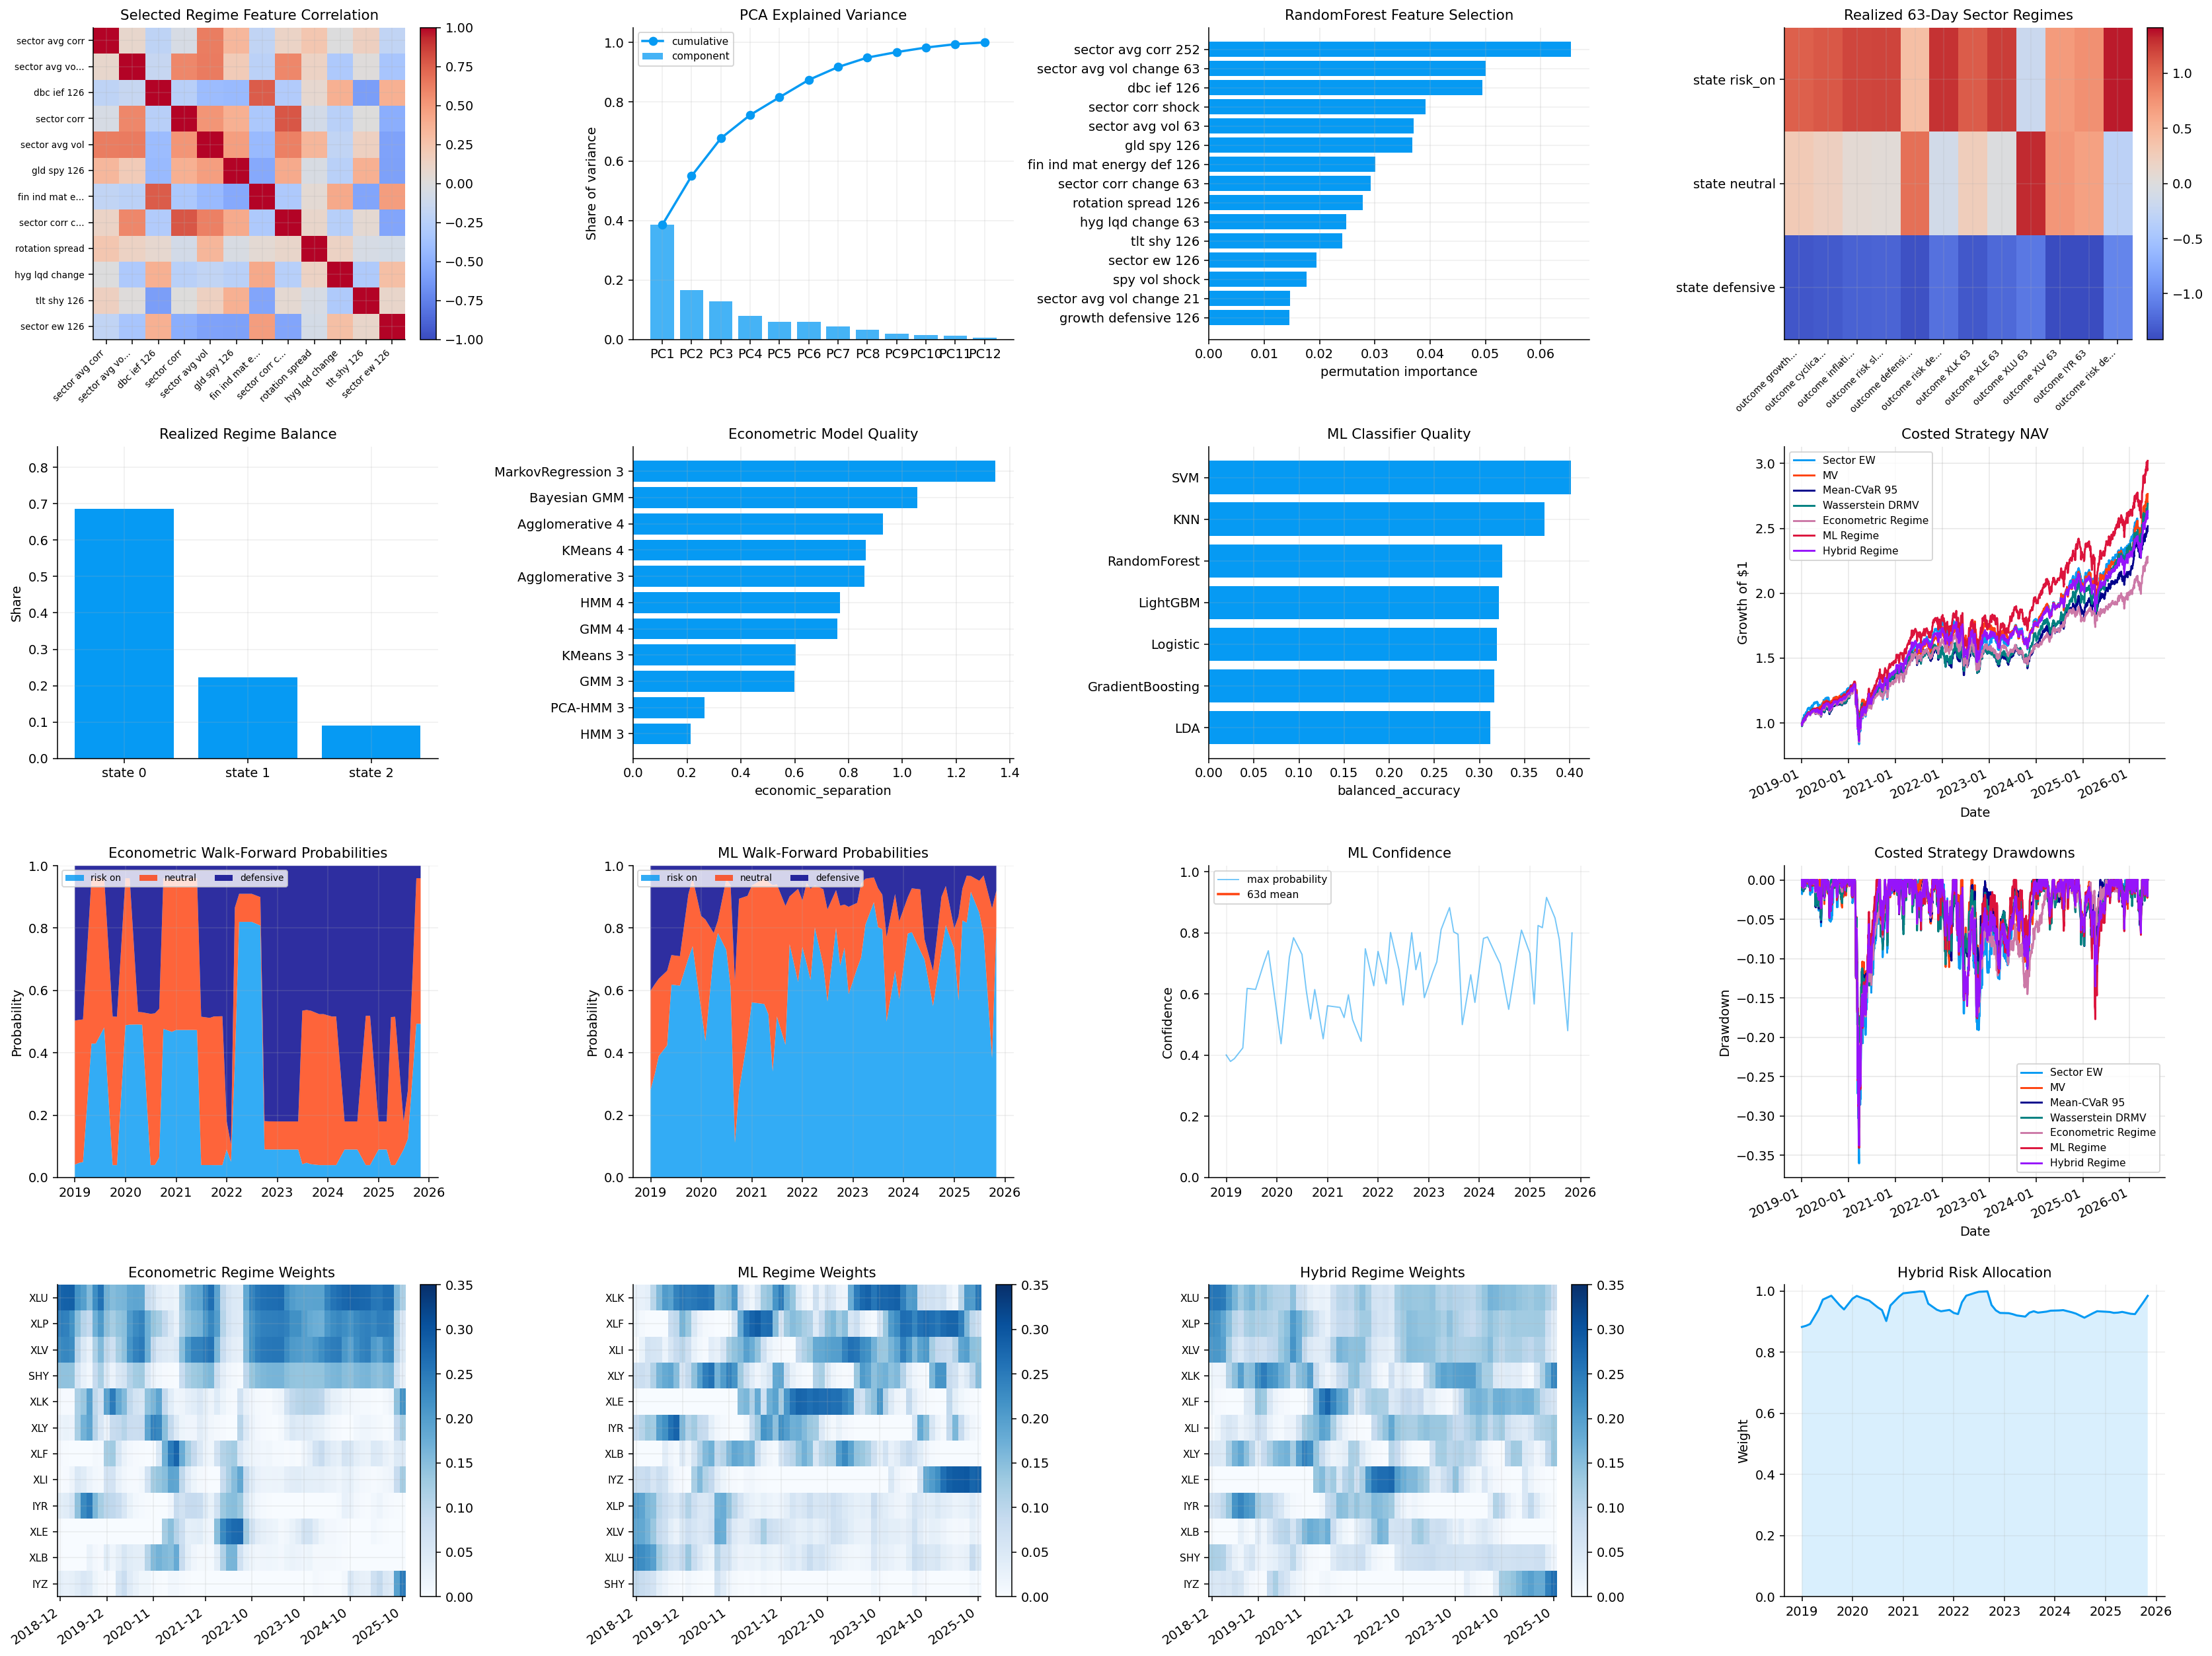

,hist_var5,hist_es5,cf_var5,cf_es5,fhs_var5,fhs_es5
object,,,,,,
Econometric Regime,0.0130,0.0241,0.0132,0.0615,0.0154,0.0228
Hybrid Regime,0.0146,0.0256,0.0146,0.0586,0.0164,0.0238
ML Regime,0.0165,0.0277,0.0166,0.0553,0.0172,0.0250
MV,0.0149,0.0244,0.0138,0.0543,0.0189,0.0264
Mean-CVaR 95,0.0141,0.0245,0.0130,0.0593,0.0142,0.0209
Sector EW,0.0153,0.0271,0.0159,0.0564,0.0107,0.0156
Wasserstein DRMV,0.0147,0.0253,0.0144,0.0559,0.0166,0.0243


breach_count  breach_rate  coverage_error  abs_coverage_error  longest_breach_streak  avg_gap_days  kupiec_p  christoffersen_p  \
object             method                                                                                                                                   
Econometric Regime cf                80       0.0488         -0.0012              0.0012                      3       20.4304    0.8157            0.0057   
                   fhs               93       0.0567          0.0067              0.0067                      2       17.5543    0.2242            0.7423   
                   hist              92       0.0561          0.0061              0.0061                      3       17.7363    0.2685            0.0055   
Hybrid Regime      cf                83       0.0506          0.0006              0.0006                      3       19.6829    0.9145            0.0002   
                   fhs               91       0.0555          0.0055              0.0055                      2       17.9333    0.3188            0.6626   
                   hist              87       0.0530          0.0030              0.0030                      3       18.7674    0.5786            0.0020   
ML Regime          cf                88       0.0536          0.0036              0.0036                      3       18.5517    0.5051            0.0000   
                   fhs               92       0.0561          0.0061              0.0061                      2       17.3516    0.2685            0.4132   
                   hist              93       0.0567          0.0067              0.0067                      3       17.5435    0.2242            0.0006   
MV                 cf                97       0.0591          0.0091              0.0091                      4       16.8125    0.0993            0.0015   
                   fhs               88       0.0536          0.0036              0.0036                      3       18.5517    0.5051            0.1427   
                   hist              92       0.0561          0.0061              0.0061                      4       17.7363    0.2685            0.0001   
Mean-CVaR 95       cf                88       0.0536          0.0036              0.0036                      4       18.5517    0.5051            0.0007   
                   fhs               88       0.0536          0.0036              0.0036                      2       18.5517    0.5051            0.1390   
                   hist              91       0.0555          0.0055              0.0055                      4       17.9333    0.3188            0.0004   
Sector EW          cf                87       0.0530          0.0030              0.0030                      3       18.7674    0.5786            0.0066   
                   fhs               92       0.0561          0.0061              0.0061                      2       17.7473    0.2685            0.1012   
                   hist              85       0.0518          0.0018              0.0018                      3       19.2143    0.7397            0.0013   
Wasserstein DRMV   cf                91       0.0555          0.0055              0.0055                      4       17.9333    0.3188            0.0014   
                   fhs               83       0.0506          0.0006              0.0006                      2       19.2561    0.9145            0.9173   
                   hist              88       0.0536          0.0036              0.0036                      4       18.1494    0.5051            0.0007   

                           quantile_loss  accuracy_rank  accuracy_score  is_best  
object             method                                                         
Econometric Regime cf             0.0013            1.0          0.1429     True  
                   fhs            0.0011            2.0          0.1111    False  
                   hist           0.0013            3.0          0.0909    False  


,object,cum_return,max_dd,worst_day,worst_week
window,,,,,
2022 rates/inflation shock,Econometric Regime,-0.0711,-0.1717,-0.0405,-0.0936
2022 rates/inflation shock,Hybrid Regime,-0.0574,-0.1739,-0.0417,-0.0952
2022 rates/inflation shock,ML Regime,-0.0452,-0.1759,-0.0455,-0.0967
2022 rates/inflation shock,MV,-0.0200,-0.1291,-0.0395,-0.0913
2022 rates/inflation shock,Mean-CVaR 95,-0.0441,-0.1419,-0.0375,-0.0843
2022 rates/inflation shock,Sector EW,-0.1038,-0.1910,-0.0388,-0.0700
2022 rates/inflation shock,Wasserstein DRMV,-0.0403,-0.1449,-0.0362,-0.0778
2023 rebound,Econometric Regime,0.0119,-0.0943,-0.0175,-0.0260
2023 rebound,Hybrid Regime,0.0640,-0.0944,-0.0178,-0.0439


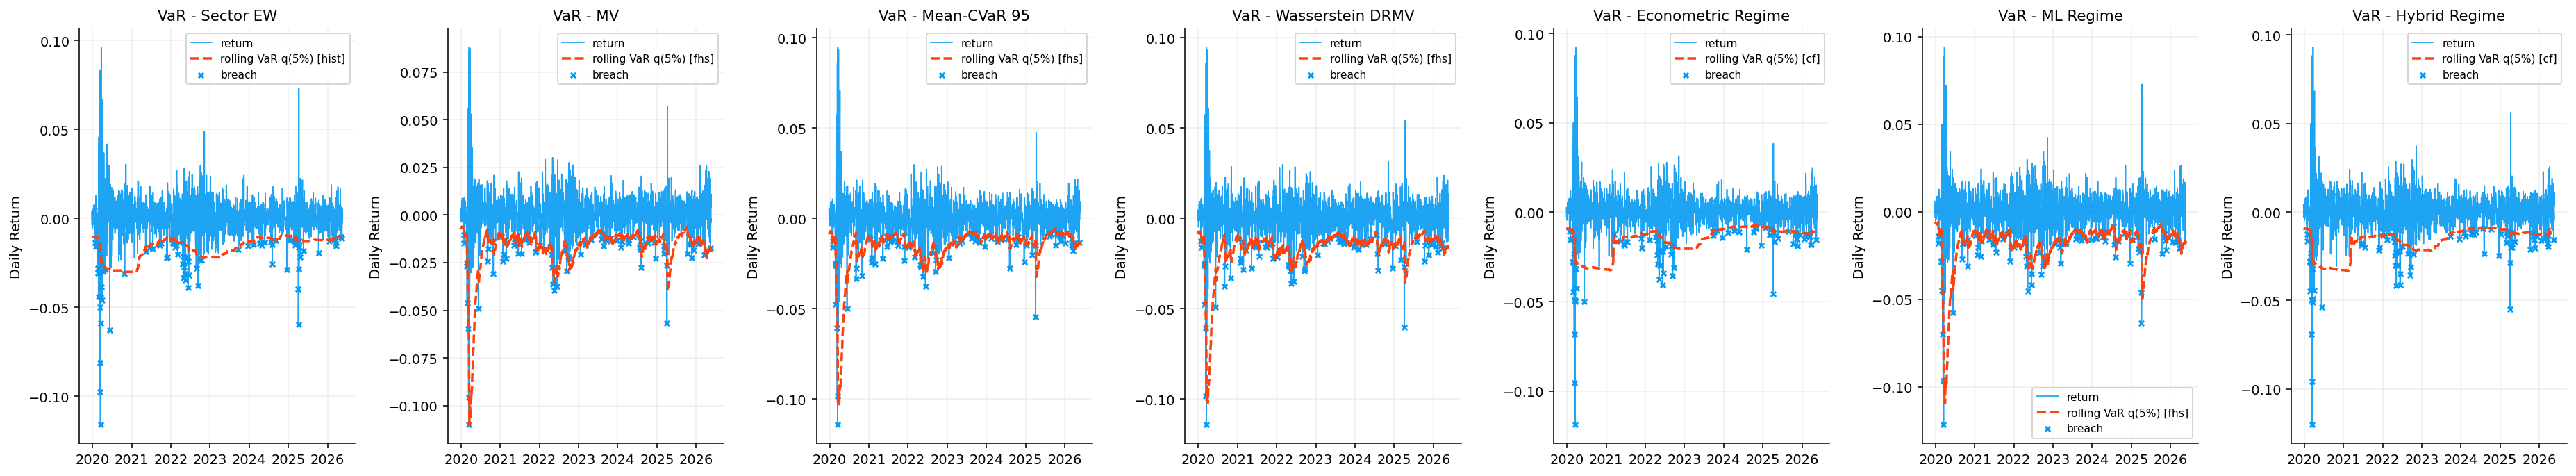

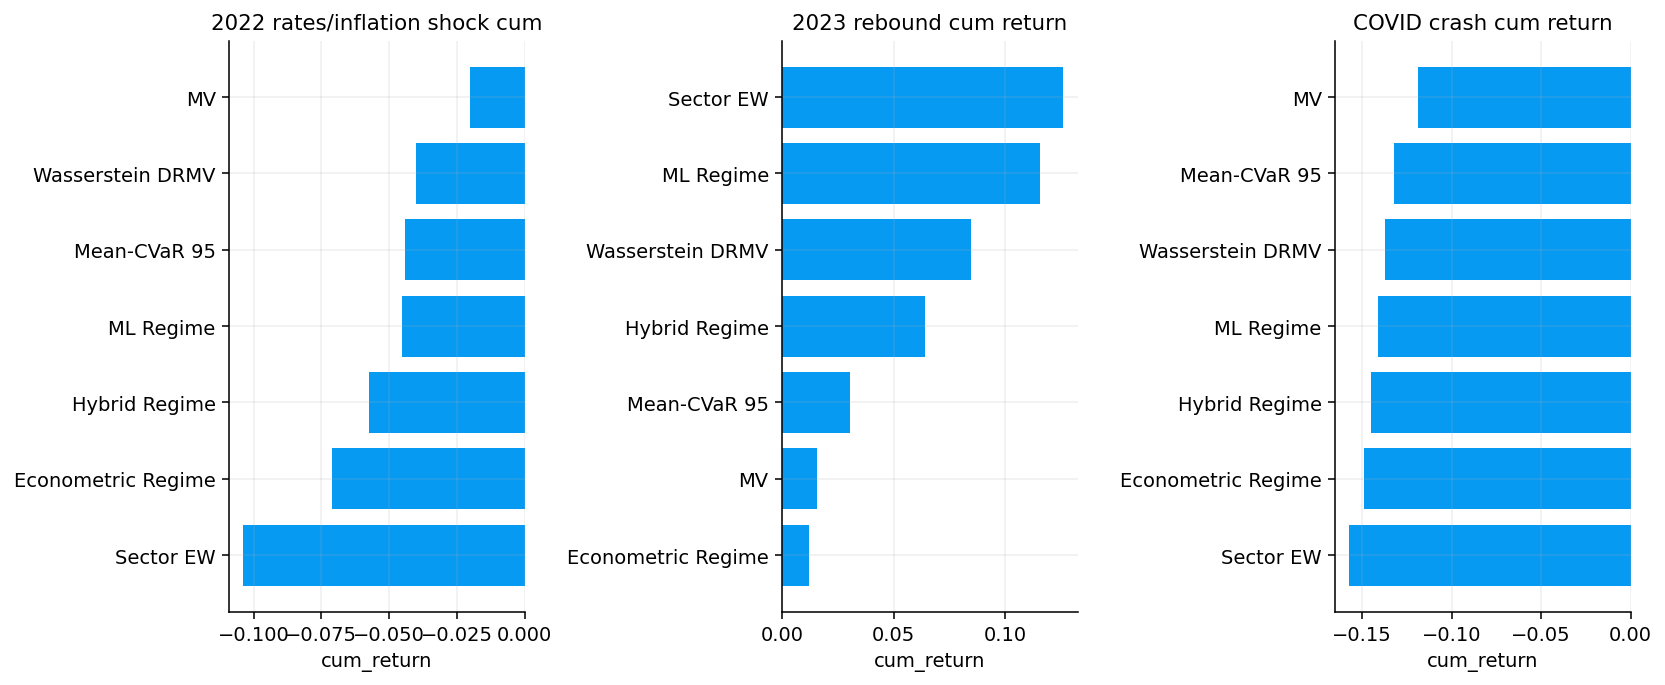

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.mixture import BayesianGaussianMixture, GaussianMixture
from sklearn.model_selection import TimeSeriesSplit
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression

from hmmlearn.hmm import GaussianHMM
try:
    from lightgbm import LGBMClassifier
    lgbm_available = True
except ImportError:
    LGBMClassifier = None
    lgbm_available = False

from quantfinlab.backtest.portfolio import run_many_weights_backtests
from quantfinlab.dataio.panel import load_yfinance_panel, prices_to_returns_panel
from quantfinlab.portfolio import covariance, expected_returns, make_rebalance_dates, optimizers
from quantfinlab.portfolio.cvar import mean_cvar_weight_frame
from quantfinlab.portfolio.robust import wasserstein_weight_frame
from quantfinlab.portfolio.selection import build_strategy_summary, parse_strategy_spec
from quantfinlab.portfolio.walkforward import run_walkforward_grid
from quantfinlab.reports.risk_report import risk_report

from quantfinlab.ml.classifiers import classifier_scores, rf_importance
from quantfinlab.ml.features import (
    breadth,
    dispersion,
    drawdown_change,
    drawdown_level,
    feature_vif,
    future_return,
    pca_tables,
    realized_vol,
    relative_return,
    rolling_avg_corr,
    rolling_pair_corr,
    skip_return,
    total_return,
)
from quantfinlab.ml.regimes import (
    duration_table,
    model_quality_row,
    posterior_confidence,
    posterior_entropy,
    proba_frame,
    regime_separation_score,
    remap_labels,
    sort_states_by_profile,
    state_profile,
    transition_table,
)
from quantfinlab.ml.sequence_models import (
    align_state_probabilities,
    hmm_proba_frame,
    hmm_quality_row,
    pca_hmm_inputs,
)
from quantfinlab.portfolio.regimes import (
    blend_sleeves,
    hybrid_weights,
    regime_asset_scores,
    risky_allocation,
    sleeve_weights,
)

from quantfinlab.plotting.regimes import (
    class_balance,
    confusion,
    feature_corr,
    feature_importance,
    model_quality,
    pca_explained,
    pca_loadings,
    probability_confidence,
    regime_probabilities,
    regime_profiles,
    risky_allocation as risky_allocation_plot,
    weight_heatmap,
)

from quantfinlab.plotting.portfolio import plot_strategy_drawdowns, plot_strategy_nav

data_path = Path("../data")
etf_path = [data_path / "core_cross_asset_etfs.csv", data_path / "sector_etfs.csv"]

feature_tickers = [
    "SPY", "QQQ", "IWM", "EFA", "EEM",
    "VNQ", "DBC", "GLD", "IEF", "TLT",
    "LQD", "HYG", "SHY",
]

sector_tickers = [
    "XLB", "XLE", "XLF", "XLI", "XLK",
    "XLP", "XLU", "XLV", "XLY",
    "IYR", "IYZ",
]

cash_ticker = "SHY"
benchmark_ticker = "SPY"
regime_names = ["risk_on", "neutral", "defensive"]
annualization = 252.0
rf_daily = (1.0 + 0.04) ** (1.0 / annualization) - 1.0
horizon = 63
horizon_slow = 126
tickers = sorted(set(feature_tickers + sector_tickers + [cash_ticker, benchmark_ticker]))

panels = load_yfinance_panel(
    etf_path,
    fields=("close", "volume"),
    tickers=tickers,
    start="2013-01-01",
)

close = panels["close"].ffill(limit=3)
volume = panels["volume"].ffill(limit=3)
ret_d = prices_to_returns_panel(close).fillna(0.0)
close_m = close.resample("ME").last()
ret_m = close_m.pct_change(fill_method=None).dropna(how="all")

feature_close = close[feature_tickers]
feature_ret = ret_d[feature_tickers]
sector_close = close[sector_tickers]
sector_ret_d = ret_d[sector_tickers]
sector_ret_m = ret_m[sector_tickers]
cash_ret_d = ret_d[[cash_ticker]]
spy_ret_d = ret_d[benchmark_ticker]

risk_assets = ["SPY", "QQQ", "IWM", "EFA", "EEM", "VNQ", "HYG"]
defensive_assets = ["IEF", "TLT", "GLD", "SHY"]
cyclical = ["XLB", "XLE", "XLF", "XLI", "XLK", "XLY", "IYR", "IYZ"]
defensive = ["XLP", "XLU", "XLV"]
sector_ew_price = sector_close.mean(axis=1)

x_all = pd.concat(
    {
        "sector_breadth_63": breadth(sector_close, 63),
        "sector_breadth_126": breadth(sector_close, 126),
        "sector_dispersion_21": dispersion(sector_close, 21),
        "sector_dispersion_63": dispersion(sector_close, 63),
        "cyclical_defensive_63": total_return(sector_close[cyclical], 63).mean(axis=1) - total_return(sector_close[defensive], 63).mean(axis=1),
        "cyclical_defensive_126": total_return(sector_close[cyclical], 126).mean(axis=1) - total_return(sector_close[defensive], 126).mean(axis=1),
        "growth_defensive_126": total_return(sector_close[["XLK", "XLY"]], 126).mean(axis=1) - total_return(sector_close[defensive], 126).mean(axis=1),
        "fin_ind_mat_energy_def_126": total_return(sector_close[["XLF", "XLI", "XLB", "XLE"]], 126).mean(axis=1) - total_return(sector_close[defensive], 126).mean(axis=1),
        "technology_vs_sector_126": total_return(sector_close["XLK"], 126) - total_return(sector_ew_price, 126),
        "energy_materials_ief_126": total_return(sector_close[["XLE", "XLB"]], 126).mean(axis=1) - total_return(feature_close["IEF"], 126),
        "real_estate_tlt_126": total_return(sector_close["IYR"], 126) - total_return(feature_close["TLT"], 126),
        "defensive_relative_126": total_return(sector_close[defensive], 126).mean(axis=1) - total_return(sector_ew_price, 126),
        "sector_ew_126": total_return(sector_ew_price, 126),
        "sector_ew_drawdown": drawdown_level(sector_ew_price, 252),
        "sector_ew_dd_speed": drawdown_change(sector_ew_price, 252, 21),
        "sector_avg_vol_63": realized_vol(sector_ret_d, 63).mean(axis=1),
        "sector_avg_vol_change_21": realized_vol(sector_ret_d, 63).mean(axis=1).diff(21),
        "sector_avg_vol_change_63": realized_vol(sector_ret_d, 63).mean(axis=1).diff(63),
        "sector_avg_corr_252": rolling_avg_corr(sector_ret_d, 252),
        "sector_corr_shock": rolling_avg_corr(sector_ret_d, 63) - rolling_avg_corr(sector_ret_d, 252),
        "sector_corr_change_21": rolling_avg_corr(sector_ret_d, 126).diff(21),
        "sector_corr_change_63": rolling_avg_corr(sector_ret_d, 126).diff(63),
        "sector_breadth_speed_21": breadth(sector_close, 63).diff(21),
        "sector_breadth_speed_63": breadth(sector_close, 126).diff(63),
        "leadership_concentration_63": total_return(sector_close, 63).max(axis=1) - total_return(sector_close, 63).median(axis=1),
        "rotation_spread_63": total_return(sector_close, 63).apply(lambda row: row.nlargest(3).mean() - row.nsmallest(3).mean(), axis=1),
        "rotation_spread_126": total_return(sector_close, 126).apply(lambda row: row.nlargest(3).mean() - row.nsmallest(3).mean(), axis=1),
        "spy_252_21": skip_return(feature_close["SPY"], 252, 21),
        "hyg_lqd_126": relative_return(feature_close["HYG"], feature_close["LQD"], 126),
        "hyg_lqd_change_21": relative_return(feature_close["HYG"], feature_close["LQD"], 63).diff(21),
        "hyg_lqd_change_63": relative_return(feature_close["HYG"], feature_close["LQD"], 126).diff(63),
        "tlt_shy_126": relative_return(feature_close["TLT"], feature_close["SHY"], 126),
        "duration_equity_divergence_126": relative_return(feature_close["TLT"], feature_close["SPY"], 126),
        "dbc_ief_126": relative_return(feature_close["DBC"], feature_close["IEF"], 126),
        "gld_spy_126": relative_return(feature_close["GLD"], feature_close["SPY"], 126),
        "spy_vol_shock": realized_vol(feature_ret["SPY"], 21) / realized_vol(feature_ret["SPY"], 126),
        "spy_dd_level": drawdown_level(feature_close["SPY"], 252),
        "spy_dd_speed": drawdown_change(feature_close["SPY"], 252, 21),
    },
    axis=1,
).dropna()

train_end = "2018-12-31"
n_label_states = len(regime_names)
future_63 = future_return(sector_close, horizon)
future_126 = future_return(sector_close, horizon_slow)
cash_future_63 = future_return(close[cash_ticker], horizon)
cash_future_126 = future_return(close[cash_ticker], horizon_slow)

growth_sleeve_63 = future_63[["XLK", "XLY"]].mean(axis=1)
cyclical_sleeve_63 = future_63[["XLF", "XLI", "XLB", "XLE", "IYR", "IYZ"]].mean(axis=1)
inflation_sleeve_63 = future_63[["XLE", "XLB"]].mean(axis=1)
risk_sleeve_63 = pd.concat(
    [growth_sleeve_63, cyclical_sleeve_63, inflation_sleeve_63],
    axis=1,
).max(axis=1)
defensive_sleeve_63 = 0.70 * future_63[defensive].mean(axis=1) + 0.30 * cash_future_63
spread_63 = risk_sleeve_63 - defensive_sleeve_63

growth_sleeve_126 = future_126[["XLK", "XLY"]].mean(axis=1)
cyclical_sleeve_126 = future_126[["XLF", "XLI", "XLB", "XLE", "IYR", "IYZ"]].mean(axis=1)
inflation_sleeve_126 = future_126[["XLE", "XLB"]].mean(axis=1)
risk_sleeve_126 = pd.concat(
    [growth_sleeve_126, cyclical_sleeve_126, inflation_sleeve_126],
    axis=1,
).max(axis=1)
defensive_sleeve_126 = 0.70 * future_126[defensive].mean(axis=1) + 0.30 * cash_future_126
spread_126 = risk_sleeve_126 - defensive_sleeve_126

y_future = pd.concat(
    [
        future_63.add_suffix("_63"),
        future_126.add_suffix("_126"),
        growth_sleeve_63.rename("growth_sleeve_63"),
        cyclical_sleeve_63.rename("cyclical_sleeve_63"),
        inflation_sleeve_63.rename("inflation_sleeve_63"),
        risk_sleeve_63.rename("risk_sleeve_63"),
        defensive_sleeve_63.rename("defensive_sleeve_63"),
        spread_63.rename("risk_defensive_spread_63"),
        growth_sleeve_126.rename("growth_sleeve_126"),
        cyclical_sleeve_126.rename("cyclical_sleeve_126"),
        inflation_sleeve_126.rename("inflation_sleeve_126"),
        risk_sleeve_126.rename("risk_sleeve_126"),
        defensive_sleeve_126.rename("defensive_sleeve_126"),
        spread_126.rename("risk_defensive_spread_126"),
    ],
    axis=1,
).dropna()

common_index = x_all.index.intersection(y_future.index)
x_all = x_all.loc[common_index]
y_future = y_future.loc[common_index]

y = pd.Series(1, index=y_future.index, name="realized_regime")
y.loc[y_future["risk_defensive_spread_63"] > 0.025] = 0
y.loc[y_future["risk_defensive_spread_63"] < -0.025] = 2

y_slow = pd.Series(1, index=y_future.index, name="slow_regime")
y_slow.loc[y_future["risk_defensive_spread_126"] > 0.05] = 0
y_slow.loc[y_future["risk_defensive_spread_126"] < -0.05] = 2

stress_label = (
    (y_future["risk_defensive_spread_63"] < -0.06)
    | (future_63.mean(axis=1).reindex(y_future.index) < -0.10)
).astype(int).rename("stress_63")

profile = state_profile(y_future, y, y_future)
profile.index = regime_names

x_train_all = x_all.loc[:train_end]
y_train_all = y.loc[x_train_all.index]

rf_for_importance = RandomForestClassifier(
    n_estimators=500,
    max_depth=5,
    min_samples_leaf=25,
    random_state=42,
    n_jobs=1,
)
rf_for_importance.fit(x_train_all, y_train_all)

imp = rf_importance(
    rf_for_importance,
    x_train_all,
    y_train_all,
    n_repeats=8,
    random_state=42,
)

model_features = imp.head(12).index.tolist()
def selected_feature_transform(x, min_history=252, clip=4.0):
    base = x.replace([np.inf, -np.inf], np.nan).astype(float)
    mean = base.expanding(min_periods=int(min_history)).mean().shift(1)
    std = base.expanding(min_periods=int(min_history)).std(ddof=1).shift(1).replace(0.0, np.nan)
    out = ((base - mean) / std).clip(-float(clip), float(clip))
    return out

x_raw = selected_feature_transform(x_all[model_features]).dropna(how="any")
common_index = x_raw.index.intersection(y.index)
x_raw = x_raw.loc[common_index]
y = y.loc[common_index].astype(int)
y_slow = y_slow.loc[common_index].astype(int)
stress_label = stress_label.loc[common_index].astype(int)
y_future = y_future.loc[common_index]
vif = feature_vif(x_raw)
pca_info, pca_loading = pca_tables(x_raw)

scaler = StandardScaler()
z = pd.DataFrame(
    scaler.fit_transform(x_raw),
    index=x_raw.index,
    columns=x_raw.columns,
)

kmeans_3 = KMeans(n_clusters=3, n_init=50, random_state=42).fit(z)
kmeans_4 = KMeans(n_clusters=4, n_init=50, random_state=42).fit(z)

agg_3 = AgglomerativeClustering(n_clusters=3, linkage="ward").fit(z)
agg_4 = AgglomerativeClustering(n_clusters=4, linkage="ward").fit(z)

gmm_3 = GaussianMixture(n_components=3, covariance_type="diag", n_init=10, random_state=42, reg_covar=1e-5).fit(z)
gmm_4 = GaussianMixture(n_components=4, covariance_type="diag", n_init=10, random_state=42, reg_covar=1e-5).fit(z)

bgmm = BayesianGaussianMixture(
    n_components=6,
    covariance_type="diag",
    weight_concentration_prior_type="dirichlet_process",
    weight_concentration_prior=0.25,
    random_state=42,
).fit(z)

ew_ret = sector_ret_d.mean(axis=1).reindex(z.index).dropna() * 100.0
ms_fit = None
try:
    ms_model = MarkovRegression(
        ew_ret,
        k_regimes=3,
        trend="c",
        switching_variance=True,
    )
    ms_fit = ms_model.fit(search_reps=10, em_iter=8, maxiter=100, disp=False)
except Exception as exc:
    print("MarkovRegression skipped:", exc)

hmm_3 = GaussianHMM(n_components=3, covariance_type="diag", n_iter=250, random_state=42, min_covar=1e-4).fit(z)
hmm_4 = GaussianHMM(n_components=4, covariance_type="diag", n_iter=250, random_state=42, min_covar=1e-4).fit(z)

z_pca, pca_scaler, pca = pca_hmm_inputs(z, n_components=min(5, z.shape[1]), random_state=42)
pca_hmm_3 = GaussianHMM(n_components=n_label_states, covariance_type="diag", n_iter=250, random_state=42, min_covar=1e-4).fit(z_pca)

eco_rows = []
eco_rows.append(model_quality_row("KMeans 3", z, kmeans_3.labels_, outcomes=y_future))
eco_rows.append(model_quality_row("KMeans 4", z, kmeans_4.labels_, outcomes=y_future))
eco_rows.append(model_quality_row("Agglomerative 3", z, agg_3.labels_, outcomes=y_future))
eco_rows.append(model_quality_row("Agglomerative 4", z, agg_4.labels_, outcomes=y_future))
eco_rows.append(model_quality_row("GMM 3", z, gmm_3.predict(z), proba=gmm_3.predict_proba(z), outcomes=y_future, likelihood=gmm_3.score(z) * len(z), bic=gmm_3.bic(z), aic=gmm_3.aic(z)))
eco_rows.append(model_quality_row("GMM 4", z, gmm_4.predict(z), proba=gmm_4.predict_proba(z), outcomes=y_future, likelihood=gmm_4.score(z) * len(z), bic=gmm_4.bic(z), aic=gmm_4.aic(z)))
eco_rows.append(model_quality_row("Bayesian GMM", z, bgmm.predict(z), proba=bgmm.predict_proba(z), outcomes=y_future, likelihood=bgmm.score(z) * len(z)))
if ms_fit is not None:
    p_ms = pd.DataFrame(np.asarray(ms_fit.smoothed_marginal_probabilities), index=ew_ret.index)
    lab_ms = p_ms.idxmax(axis=1).astype(int)
    eco_rows.append(model_quality_row("MarkovRegression 3", z.loc[lab_ms.index], lab_ms, proba=p_ms, outcomes=y_future, likelihood=ms_fit.llf, bic=ms_fit.bic, aic=ms_fit.aic))
eco_rows.append(hmm_quality_row("HMM 3", hmm_3, z, outcomes=y_future))
eco_rows.append(hmm_quality_row("HMM 4", hmm_4, z, outcomes=y_future))
eco_rows.append(hmm_quality_row("PCA-HMM 3", pca_hmm_3, z_pca, outcomes=y_future))

eco_table = pd.DataFrame(eco_rows).set_index("model")
display(eco_table.round(4))

supervised_train = z.loc[:train_end]
supervised_test = z.loc[train_end:].iloc[1:]
y_train = y.loc[supervised_train.index]
y_test = y.loc[supervised_test.index]
class_labels = sorted(y.unique())

logit = LogisticRegression(max_iter=2000, class_weight="balanced").fit(supervised_train, y_train)
lda = LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto").fit(supervised_train, y_train)
rf = RandomForestClassifier(n_estimators=420, max_depth=5, min_samples_leaf=25, class_weight="balanced", random_state=42, n_jobs=1).fit(supervised_train, y_train)
gb = GradientBoostingClassifier(n_estimators=240, learning_rate=0.035, max_depth=2, min_samples_leaf=25, random_state=42).fit(supervised_train, y_train)
svm = SVC(C=2.0, gamma="scale", probability=True, class_weight="balanced", random_state=42).fit(supervised_train, y_train)
knn = KNeighborsClassifier(n_neighbors=25, weights="distance").fit(supervised_train, y_train)

classifiers = {
    "Logistic": logit,
    "LDA": lda,
    "RandomForest": rf,
    "GradientBoosting": gb,
    "SVM": svm,
    "KNN": knn,
}
if lgbm_available:
    lgbm = LGBMClassifier(n_estimators=300, learning_rate=0.03, num_leaves=15, min_child_samples=45, subsample=0.8, colsample_bytree=0.8, objective="multiclass", random_state=42, verbosity=-1, n_jobs=1).fit(supervised_train, y_train)
    classifiers["LightGBM"] = lgbm

ml_table = classifier_scores(classifiers, supervised_test, y_test, labels=class_labels)
display(ml_table.round(4))

hmm_candidates = eco_table.loc[eco_table.index.to_series().str.contains("HMM", regex=False)].copy()
eligible = hmm_candidates[
    hmm_candidates["states"].eq(n_label_states)
    & hmm_candidates["min_state_share"].ge(0.03)
    & hmm_candidates["avg_state_duration"].ge(4.0)
].copy()
if eligible.empty:
    eligible = eco_table[
        eco_table.index.to_series().str.contains("HMM|GMM|Markov", regex=True)
        & eco_table["states"].eq(n_label_states)
        & eco_table["min_state_share"].ge(0.03)
        & eco_table["avg_state_duration"].ge(4.0)
    ].copy()
if eligible.empty:
    eligible = eco_table[eco_table["states"].eq(n_label_states)].copy()
if eligible.empty:
    eligible = eco_table.copy()

best_eco_name = (
    1.60 * eligible["economic_separation"].rank(pct=True)
    + 1.10 * eligible["avg_state_duration"].rank(pct=True)
    + 0.70 * eligible["silhouette"].fillna(0.0).rank(pct=True)
    + 0.50 * eligible["posterior_confidence"].fillna(0.0).rank(pct=True)
    - 0.45 * eligible["transitions_per_year"].rank(pct=True)
    - 0.25 * eligible["posterior_entropy"].fillna(0.0).rank(pct=True)
).sort_values(ascending=False).index[0]

def classifier_economic_utility(model):
    if hasattr(model, "predict_proba"):
        raw = model.predict_proba(supervised_test)
        proba = pd.DataFrame(0.0, index=supervised_test.index, columns=range(n_label_states))
        for j, cls in enumerate(model.classes_):
            proba[int(cls)] = raw[:, j]
    else:
        pred = pd.Series(model.predict(supervised_test), index=supervised_test.index)
        proba = pd.get_dummies(pred).reindex(index=supervised_test.index, columns=range(n_label_states), fill_value=0.0)
    p = proba.rename(columns=dict(enumerate(regime_names)))
    fwd = y_future.reindex(supervised_test.index)
    sector_beta = fwd["risk_defensive_spread_63"]
    signal = p["risk_on"] - p["defensive"]
    r = (signal * sector_beta).replace([np.inf, -np.inf], np.nan).dropna()
    return np.sqrt(12.0) * r.mean() / r.std(ddof=1) if r.std(ddof=1) > 1e-12 else 0.0

ml_rank = ml_table.copy()
ml_rank["economic_utility_raw"] = pd.Series({name: classifier_economic_utility(model) for name, model in classifiers.items()})
ml_rank["economic_utility_score"] = 0.30 * ml_rank["economic_utility_raw"].rank(pct=True)
ml_rank["log_loss_bad_rank"] = ml_rank["log_loss"].replace(np.nan, ml_rank["log_loss"].max() + 1.0).rank(pct=True, ascending=True)
ml_rank["selection_score"] = (
    0.40 * ml_rank["balanced_accuracy"]
    + 0.30 * ml_rank["macro_f1"]
    - 0.30 * ml_rank["log_loss_bad_rank"]
    + ml_rank["economic_utility_score"]
)
ml_table = ml_rank
best_ml_name = ml_table["selection_score"].sort_values(ascending=False).index[0]

best_ml_template = classifiers[best_ml_name]
print("best econometric:", best_eco_name)
print("best ML:", best_ml_name)

def shrink_probability(p, base=0.10):
    p = pd.Series(p, dtype=float).reindex(regime_names).fillna(0.0)
    p = p / p.sum() if p.sum() > 1e-12 else pd.Series(1.0 / len(regime_names), index=regime_names)
    confidence = float(p.max())
    shrink = base + (0.15 if confidence > 0.98 else 0.0)
    uniform = pd.Series(1.0 / len(regime_names), index=regime_names)
    out = (1.0 - shrink) * p + shrink * uniform
    return out / out.sum()

def economic_state_mapping(labels, train_x):
    labels = pd.Series(labels, index=train_x.index)
    known_index = train_x.index[:-horizon] if len(train_x) > horizon else train_x.index
    known_outcomes = y_future.reindex(known_index).dropna(how="any")
    known_labels = labels.reindex(known_outcomes.index).dropna()
    common = known_outcomes.index.intersection(known_labels.index)
    if len(common) >= 60 and known_labels.loc[common].nunique() >= 2:
        prof = state_profile(train_x.reindex(common), known_labels.loc[common], known_outcomes.loc[common])
    else:
        prof = state_profile(train_x, labels)
    order = list(sort_states_by_profile(prof))
    if not order:
        return {}
    mapping = {int(s): "neutral" for s in order}
    mapping[int(order[0])] = "risk_on"
    mapping[int(order[-1])] = "defensive"
    return mapping

def fit_eco_model(name, train_x):
    sc = StandardScaler().fit(train_x)
    z_train = pd.DataFrame(sc.transform(train_x), index=train_x.index, columns=train_x.columns)
    out = {"name": name, "scaler": sc, "train_z": z_train, "pca": None, "pca_scaler": None}
    if str(name).startswith("PCA-HMM"):
        n_states = int(str(name).split()[-1]) if str(name).split()[-1].isdigit() else n_label_states
        z_fit, pca_scaler_t, pca_t = pca_hmm_inputs(z_train, n_components=min(5, z_train.shape[1]), random_state=42)
        model = GaussianHMM(n_components=n_states, covariance_type="diag", n_iter=200, random_state=42, min_covar=1e-4).fit(z_fit)
        labels = pd.Series(model.predict(z_fit), index=train_x.index)
        out.update({"model": model, "pca": pca_t, "pca_scaler": pca_scaler_t, "train_fit": z_fit, "mapping": economic_state_mapping(labels, train_x)})
        return out
    if str(name).startswith("HMM"):
        n_states = int(str(name).split()[1])
        model = GaussianHMM(n_components=n_states, covariance_type="diag", n_iter=200, random_state=42, min_covar=1e-4).fit(z_train)
        labels = pd.Series(model.predict(z_train), index=train_x.index)
        out.update({"model": model, "train_fit": z_train, "mapping": economic_state_mapping(labels, train_x)})
        return out
    if str(name).startswith("GMM 3"):
        model = GaussianMixture(n_components=3, covariance_type="diag", n_init=5, random_state=42, reg_covar=1e-5).fit(z_train)
    elif str(name).startswith("Bayesian"):
        model = BayesianGaussianMixture(n_components=6, covariance_type="diag", max_iter=300, weight_concentration_prior=0.25, random_state=42).fit(z_train)
    else:
        model = GaussianMixture(n_components=4, covariance_type="diag", n_init=5, random_state=42, reg_covar=1e-5).fit(z_train)
    labels = pd.Series(model.predict(z_train), index=train_x.index)
    out.update({"model": model, "train_fit": z_train, "mapping": economic_state_mapping(labels, train_x)})
    return out

def eco_probability(fitted, last_x):
    z_last = pd.DataFrame(fitted["scaler"].transform(last_x), index=last_x.index, columns=last_x.columns)
    if str(fitted["name"]).startswith("PCA-HMM"):
        z_last, _, _ = pca_hmm_inputs(
            z_last,
            n_components=fitted["train_fit"].shape[1],
            scaler=fitted["pca_scaler"],
            pca=fitted["pca"],
        )
        seq = pd.concat([fitted["train_fit"], z_last], axis=0)
        raw = hmm_proba_frame(fitted["model"], seq, index=seq.index).iloc[-1].to_numpy()
    elif str(fitted["name"]).startswith("HMM"):
        seq = pd.concat([fitted["train_fit"], z_last], axis=0)
        raw = hmm_proba_frame(fitted["model"], seq, index=seq.index).iloc[-1].to_numpy()
    else:
        raw = fitted["model"].predict_proba(z_last)[0]
    p = pd.Series(0.0, index=regime_names)
    for i, val in enumerate(raw):
        p[fitted.get("mapping", {}).get(int(i), "neutral")] += float(val)
    return shrink_probability(p, base=0.12)

def make_calibrated_model(name):
    return clone(best_ml_template)

def ml_probability(model, last_x):
    p = pd.Series(0.0, index=regime_names)
    raw = model.predict_proba(last_x)[0] if hasattr(model, "predict_proba") else np.array([1.0])
    classes = model.classes_ if hasattr(model, "classes_") else np.array([model.predict(last_x)[0]])
    for cls, val in zip(classes, raw, strict=False):
        p[regime_names[int(cls)]] = float(val)
    return shrink_probability(p, base=0.06)

def stress_probability(model, last_x):
    if model is None:
        return 0.0
    raw = model.predict_proba(last_x)[0]
    classes = list(model.classes_)
    return float(raw[classes.index(1)]) if 1 in classes else 0.0

def blend_horizons(p_fast, p_slow, p_stress):
    p = shrink_probability(0.65 * p_fast + 0.35 * p_slow, base=0.03)
    defensive_floor = 0.85 * float(p_stress)
    if defensive_floor > p["defensive"]:
        p["defensive"] = defensive_floor
        remaining = max(1.0 - p["defensive"], 0.0)
        nondef = p[["risk_on", "neutral"]]
        if nondef.sum() > 1e-12:
            p.loc[["risk_on", "neutral"]] = remaining * nondef / nondef.sum()
        else:
            p.loc[["risk_on", "neutral"]] = remaining / 2.0
    return p / p.sum()

rebalance_dates = close_m.index
rebalance_dates = rebalance_dates[rebalance_dates >= "2018-12-31"]
p_eco_rows = {}
p_ml_rows = {}
eco_fit = None
ml_fit = None

for i, dt in enumerate(rebalance_dates):
    if dt not in x_raw.index:
        pos = x_raw.index.searchsorted(dt, side="right") - 1
        if pos < 0:
            continue
        dt = x_raw.index[pos]
    train_x = x_raw.loc[:dt].tail(1260)
    if len(train_x) < 1000:
        continue
    pos = x_raw.index.searchsorted(dt, side="right") - 1
    if pos <= horizon_slow:
        continue
    label_cutoff = x_raw.index[max(0, pos - horizon)]
    slow_cutoff = x_raw.index[max(0, pos - horizon_slow)]
    train_idx = y.loc[:label_cutoff].tail(len(train_x)).index
    slow_idx = y_slow.loc[:slow_cutoff].tail(len(train_x)).index
    stress_idx = stress_label.loc[:label_cutoff].tail(len(train_x)).index
    train_x_ml = x_raw.loc[train_idx]
    train_y = y.loc[train_idx]
    if train_y.nunique() < 2:
        continue
    if eco_fit is None or i % 3 == 0:
        eco_fit = fit_eco_model(best_eco_name, train_x)
    p_eco_rows[pd.Timestamp(dt)] = eco_probability(eco_fit, x_raw.loc[[dt]])
    if ml_fit is None or i % 3 == 0:
        sc_t = StandardScaler().fit(train_x_ml)
        z_train = pd.DataFrame(sc_t.transform(train_x_ml), index=train_x_ml.index, columns=train_x_ml.columns)
        model_t = make_calibrated_model(best_ml_name)
        try:
            model_t.fit(z_train, train_y)
        except Exception:
            model_t = clone(best_ml_template).fit(z_train, train_y)

        model_slow = None
        if len(slow_idx) >= 756 and y_slow.loc[slow_idx].nunique() > 1:
            z_slow = pd.DataFrame(sc_t.transform(x_raw.loc[slow_idx]), index=slow_idx, columns=x_raw.columns)
            model_slow = make_calibrated_model(best_ml_name)
            try:
                model_slow.fit(z_slow, y_slow.loc[slow_idx])
            except Exception:
                model_slow = clone(best_ml_template).fit(z_slow, y_slow.loc[slow_idx])

        stress_model = None
        if len(stress_idx) >= 756 and stress_label.loc[stress_idx].nunique() > 1:
            z_stress = pd.DataFrame(sc_t.transform(x_raw.loc[stress_idx]), index=stress_idx, columns=x_raw.columns)
            stress_base = RandomForestClassifier(
                n_estimators=350,
                min_samples_leaf=25,
                class_weight="balanced_subsample",
                random_state=42,
                n_jobs=1,
            )
            stress_model = stress_base.fit(z_stress, stress_label.loc[stress_idx])

        ml_fit = {"scaler": sc_t, "model": model_t, "model_slow": model_slow, "stress_model": stress_model}
    z_last = pd.DataFrame(ml_fit["scaler"].transform(x_raw.loc[[dt]]), index=[dt], columns=x_raw.columns)
    p_fast = ml_probability(ml_fit["model"], z_last)
    p_slow = ml_probability(ml_fit["model_slow"], z_last) if ml_fit["model_slow"] is not None else p_fast
    p_stress = stress_probability(ml_fit["stress_model"], z_last)
    p_ml_rows[pd.Timestamp(dt)] = blend_horizons(p_fast, p_slow, p_stress)

p_eco = pd.DataFrame.from_dict(p_eco_rows, orient="index").sort_index()
p_ml = pd.DataFrame.from_dict(p_ml_rows, orient="index").sort_index()
rebalance = p_eco.index.intersection(p_ml.index).intersection(sector_ret_m.index)
p_eco = p_eco.loc[rebalance]
p_ml = p_ml.loc[rebalance]

ret_for_backtest = pd.concat([sector_ret_d, cash_ret_d], axis=1).fillna(0.0)

w_equal = pd.DataFrame(1.0 / len(sector_tickers), index=rebalance, columns=sector_tickers)
w_equal[cash_ticker] = 0.0

benchmark_cov_lookback = 756
benchmark_mu_lookback = 252
benchmark_ewma_lambda = 0.97
benchmark_w_min = 0.0
benchmark_w_max = 0.35
benchmark_mv_lambda = 6.0
benchmark_alt_mv_lambda = 3.0
benchmark_cov_models = {
    "LedoitWolf": covariance.ledoit_wolf_covariance,
    "OAS": covariance.oas_covariance,
    "EWMA": covariance.ewma_covariance,
}
benchmark_mu_models = {
    "Momentum": expected_returns.momentum_mu,
    "BayesStein": expected_returns.bayes_stein_mu,
    "BayesSteinMomentum": expected_returns.bayes_stein_momentum_mu,
}

universe_by_date = {
    pd.Timestamp(dt): {"tickers": list(sector_tickers), "avg_dollar_volume": pd.Series(1.0, index=sector_tickers)}
    for dt in rebalance
}

mv_grid = run_walkforward_grid(
    returns=ret_for_backtest[sector_tickers],
    close=sector_close,
    rebalance_dates=rebalance,
    universe_by_date=universe_by_date,
    cov_models=benchmark_cov_models,
    mu_models=benchmark_mu_models,
    optimizers={
        "MV": optimizers.mean_variance,
        "MaxSharpe": optimizers.max_sharpe_slsqp,
    },
    strategy_specs=[
        {"name": f"{optimizer_name} ({cov_name}, {mu_name})", "optimizer": optimizer_name, "cov_model": cov_name, "mu_model": mu_name}
        for optimizer_name in ["MV", "MaxSharpe"]
        for cov_name in benchmark_cov_models
        for mu_name in benchmark_mu_models
    ],
    max_weight=benchmark_w_max,
    min_weight=benchmark_w_min,
    trading_cost_bps=10,
    turnover_penalty_bps=10,
    cov_lookback=benchmark_cov_lookback,
    mu_lookback=benchmark_mu_lookback,
    min_cov_observations=benchmark_cov_lookback - 1,
    min_mu_observations=benchmark_mu_lookback - 1,
    fallback="equal",
    annualization=annualization,
    rf_daily=rf_daily,
    ewma_lambda=benchmark_ewma_lambda,
    optimizer_params={"MV": {"mv_lambda": benchmark_mv_lambda}},
)

mv_pick = mv_grid.results[
    mv_grid.results["Optimizer"].eq("MV")
].sort_values(
    ["Sharpe", "Max Drawdown", "Turnover"],
    ascending=[False, False, True],
).index[0]

maxsharpe_candidates = mv_grid.results[
    mv_grid.results["Optimizer"].eq("MaxSharpe")
].dropna(subset=["Sharpe"])
maxsharpe_source = (
    maxsharpe_candidates.sort_values(
        ["Sharpe", "Max Drawdown", "Turnover", "CAGR"],
        ascending=[False, False, True, False],
    ).index[0]
    if not maxsharpe_candidates.empty
    else mv_pick
)

w_mv = mv_grid.weights[mv_pick].copy()
w_mv[cash_ticker] = 0.0
w_mv = w_mv.reindex(index=rebalance, columns=sector_tickers + [cash_ticker]).fillna(0.0)

_, maxsharpe_mu_model, maxsharpe_cov_model = parse_strategy_spec(maxsharpe_source, mv_grid.backtests[maxsharpe_source])

def align_benchmark_weights(w):
    out = w.reindex(index=rebalance, columns=sector_tickers).ffill()
    out = out.fillna(1.0 / len(sector_tickers))
    out[cash_ticker] = 0.0
    return out.reindex(columns=sector_tickers + [cash_ticker]).fillna(0.0)

w_mean_cvar = align_benchmark_weights(
    mean_cvar_weight_frame(
        cache=mv_grid.cache,
        rebalance_dates=rebalance,
        cov_model=maxsharpe_cov_model,
        mu_model=maxsharpe_mu_model,
        reference="equal",
        alpha=0.95,
        budget_scale=0.90,
        w_min=benchmark_w_min,
        w_max=benchmark_w_max,
    )
)

w_wasserstein = align_benchmark_weights(
    wasserstein_weight_frame(
        cache=mv_grid.cache,
        rebalance_dates=rebalance,
        cov_model="EWMA",
        mu_model="BayesStein",
        radius=2.0,
        mv_lambda=1.0,
        w_min=benchmark_w_min,
        w_max=benchmark_w_max,
    )
)

neutral_weight = pd.Series(1.0 / len(sector_tickers), index=sector_tickers + [cash_ticker])
neutral_weight[cash_ticker] = 0.0

def defensive_weight():
    w = pd.Series(0.0, index=sector_tickers + [cash_ticker])
    for ticker, weight in {"SHY": 0.30, "XLU": 0.25, "XLP": 0.22, "XLV": 0.23}.items():
        if ticker in w.index:
            w[ticker] = weight
    return w

def regime_risk_budget(p):
    p = pd.Series(p, dtype=float).reindex(regime_names).fillna(0.0)
    p = p / p.sum() if p.sum() > 1e-12 else pd.Series(1.0 / len(regime_names), index=regime_names)
    entropy = -(p * np.log(p + 1e-12)).sum() / np.log(len(p))
    risk = 0.92 + 0.50 * p["risk_on"] - 0.72 * p["defensive"] - 0.08 * entropy
    return float(np.clip(risk, 0.45, 1.00))

def normalize_target(w):
    out = w.reindex(sector_tickers + [cash_ticker]).fillna(0.0).astype(float)
    out[cash_ticker] = max(1.0 - float(out[sector_tickers].sum()), 0.0)
    return out / float(out.sum()) if float(out.sum()) > 1e-12 else neutral_weight.copy()

def smooth_schedule(w, alpha=0.50):
    rows = []
    prev = None
    for dt, row in w.iterrows():
        target = row.reindex(sector_tickers + [cash_ticker]).fillna(0.0).astype(float)
        target = target / float(target.sum()) if float(target.sum()) > 1e-12 else neutral_weight.copy()
        cur = target if prev is None else alpha * target + (1.0 - alpha) * prev
        cur = cur / float(cur.sum()) if float(cur.sum()) > 1e-12 else neutral_weight.copy()
        rows.append(cur.rename(dt))
        prev = cur
    return pd.DataFrame(rows)

sector_trend_63 = sector_close / sector_close.shift(63) - 1.0
sector_trend_126 = sector_close / sector_close.shift(126) - 1.0
sector_trend_252_21 = sector_close.shift(21) / sector_close.shift(252) - 1.0
sector_vol_126 = sector_ret_d.rolling(126).std(ddof=1) * np.sqrt(annualization)
sector_dd_252 = sector_close / sector_close.rolling(252, min_periods=63).max() - 1.0

def sector_zscore(values, candidates):
    s = pd.Series(values, dtype=float).reindex(candidates).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    scale = s.std(ddof=0)
    return (s - s.mean()) / (scale if scale > 1e-12 else 1.0)

def sector_sleeve_from_scores(scores, top_n=5, max_weight=0.30):
    s = pd.Series(scores, dtype=float).replace([np.inf, -np.inf], np.nan).dropna()
    s = s[s.index.isin(sector_tickers)].sort_values(ascending=False)
    w = pd.Series(0.0, index=sector_tickers + [cash_ticker], dtype=float)
    if s.empty:
        w.loc[sector_tickers] = 1.0 / len(sector_tickers)
        return w
    selected = s.head(top_n)
    raw = selected - min(0.0, float(selected.min())) + 1e-6
    if float(raw.sum()) <= 1e-12:
        raw = pd.Series(1.0, index=selected.index)
    alloc = raw / float(raw.sum())
    for _ in range(10):
        over = alloc > max_weight
        if not bool(over.any()):
            break
        excess = float((alloc[over] - max_weight).sum())
        alloc[over] = max_weight
        room = (max_weight - alloc[~over]).clip(lower=0.0)
        if float(room.sum()) <= 1e-12:
            break
        alloc.loc[room.index] += excess * room / float(room.sum())
    w.loc[alloc.index] = alloc
    return w / float(w.sum()) if float(w.sum()) > 1e-12 else w

def sector_score_sleeve(dt, candidates, top_n=5, max_weight=0.30):
    candidates = [c for c in candidates if c in sector_tickers]
    hist = sector_ret_d.loc[:dt, candidates].tail(504)
    mu = hist.tail(252).mean() * annualization
    hit = hist.tail(252).gt(0.0).mean()
    score = (
        0.20 * sector_zscore(sector_trend_63.loc[:dt].iloc[-1], candidates)
        + 0.25 * sector_zscore(sector_trend_126.loc[:dt].iloc[-1], candidates)
        + 0.20 * sector_zscore(sector_trend_252_21.loc[:dt].iloc[-1], candidates)
        + 0.15 * sector_zscore(mu, candidates)
        + 0.08 * sector_zscore(hit, candidates)
        + 0.07 * sector_zscore(-sector_vol_126.loc[:dt].iloc[-1], candidates)
        + 0.05 * sector_zscore(sector_dd_252.loc[:dt].iloc[-1], candidates)
    )
    return sector_sleeve_from_scores(score, top_n=top_n, max_weight=max_weight)

def state_weight(dt, probabilities):
    p_now = probabilities.loc[dt].reindex(regime_names).fillna(0.0)
    p_now = p_now / float(p_now.sum()) if float(p_now.sum()) > 1e-12 else pd.Series(1.0 / len(regime_names), index=regime_names)
    risk_sleeve = sector_score_sleeve(dt, cyclical, top_n=5, max_weight=0.30)
    neutral_sleeve = 0.50 * w_mv.loc[dt].reindex(neutral_weight.index).fillna(0.0) + 0.50 * sector_score_sleeve(dt, sector_tickers, top_n=6, max_weight=0.25)
    neutral_sleeve = neutral_sleeve / float(neutral_sleeve.sum()) if float(neutral_sleeve.sum()) > 1e-12 else neutral_weight.copy()
    safe_sleeve = defensive_weight()
    target = p_now["risk_on"] * risk_sleeve + p_now["neutral"] * neutral_sleeve + p_now["defensive"] * safe_sleeve
    if p_now["risk_on"] > 0.55:
        target = 0.75 * target + 0.25 * risk_sleeve
    if p_now["defensive"] > 0.55:
        target = 0.75 * target + 0.25 * safe_sleeve
    risky = target.copy()
    risky[cash_ticker] = 0.0
    risky = risky / float(risky.sum()) if float(risky.sum()) > 1e-12 else neutral_weight.copy()
    risk_budget = regime_risk_budget(p_now)
    target = risk_budget * risky + (1.0 - risk_budget) * safe_sleeve
    return normalize_target(target)

w_eco_raw = pd.DataFrame.from_dict(
    {pd.Timestamp(dt): state_weight(dt, p_eco) for dt in rebalance},
    orient="index",
).reindex(columns=sector_tickers + [cash_ticker]).fillna(0.0)

w_ml_raw = pd.DataFrame.from_dict(
    {pd.Timestamp(dt): state_weight(dt, p_ml) for dt in rebalance},
    orient="index",
).reindex(columns=sector_tickers + [cash_ticker]).fillna(0.0)

w_eco = smooth_schedule(w_eco_raw, alpha=0.58)
w_ml = smooth_schedule(w_ml_raw, alpha=0.62)

period_prices = close[sector_tickers + [cash_ticker]].reindex(rebalance).ffill()
period_returns = period_prices.shift(-1) / period_prices - 1.0

def schedule_period_returns(w):
    aligned = w.reindex(index=period_returns.index, columns=period_returns.columns).fillna(0.0)
    return (aligned * period_returns).sum(axis=1).dropna()

def rolling_utility_weight(a, b, window=24, temperature=3.0):
    def util(x):
        vol = x.rolling(window).std(ddof=1)
        return x.rolling(window).mean() / vol.replace(0.0, np.nan)
    spread = (util(a).shift(1) - util(b).shift(1)).reindex(rebalance).fillna(0.0)
    alpha = 1.0 / (1.0 + np.exp(-temperature * spread))
    return alpha.clip(0.25, 0.75)

eco_period = schedule_period_returns(w_eco)
ml_period = schedule_period_returns(w_ml)
hybrid_eco_weight = rolling_utility_weight(eco_period, ml_period).reindex(w_eco.index).ffill().fillna(0.50)
w_hybrid = w_eco.mul(hybrid_eco_weight, axis=0) + w_ml.mul(1.0 - hybrid_eco_weight, axis=0)
w_hybrid = w_hybrid.div(w_hybrid.sum(axis=1), axis=0).fillna(0.0)

w_max = pd.Series(0.40, index=sector_tickers + [cash_ticker])
w_max[cash_ticker] = 1.0

weights = {
    "Sector EW": w_equal,
    "MV": w_mv,
    "Mean-CVaR 95": w_mean_cvar,
    "Wasserstein DRMV": w_wasserstein,
    "Econometric Regime": w_eco,
    "ML Regime": w_ml,
    "Hybrid Regime": w_hybrid,
}

results = run_many_weights_backtests(
    weights,
    returns=ret_for_backtest[sector_tickers + [cash_ticker]],
    cost_bps=10,
    w_min=0.0,
    w_max=w_max,
    rf_daily=rf_daily,
    weight_timing="next_close",
)

summary = build_strategy_summary(results, rf_daily=rf_daily, annualization=annualization)
display(pd.DataFrame({"selected_features": model_features}))
display(profile.round(4))
display(vif.head(12).round(2))
display(eco_table.round(4))
display(ml_table.round(4))
display(summary.round(4))
print("MV choice:", mv_pick)
print("MaxSharpe source for Mean-CVaR/Wasserstein:", maxsharpe_source)

nav = pd.concat({name: result.net_values for name, result in results.items()}, axis=1).dropna(how="all")
strategy_returns = pd.concat({name: result.net_returns for name, result in results.items()}, axis=1).dropna(how="all")
risk_share = risky_allocation(w_hybrid, risky_assets=sector_tickers)

latest_weights = w_hybrid.iloc[-1].sort_values(ascending=False).to_frame("weight")
latest_prob = pd.concat({"econometric": p_eco.iloc[-1], "ml": p_ml.iloc[-1]}, axis=1).fillna(0.0)
display(latest_prob.round(3))
display(latest_weights[latest_weights["weight"] > 0.001].round(3))

fig, axes = plt.subplots(4, 4, figsize=(24, 18))
axes = axes.ravel()

feature_corr(axes[0], x_raw, title="Selected Regime Feature Correlation")
pca_explained(axes[1], pca_info, title="PCA Explained Variance")
feature_importance(axes[2], imp, title="RandomForest Feature Selection")
regime_profiles(
    axes[3],
    profile,
    cols=[
        "outcome_growth_sleeve_63",
        "outcome_cyclical_sleeve_63",
        "outcome_inflation_sleeve_63",
        "outcome_risk_sleeve_63",
        "outcome_defensive_sleeve_63",
        "outcome_risk_defensive_spread_63",
        "outcome_XLK_63",
        "outcome_XLE_63",
        "outcome_XLU_63",
        "outcome_XLV_63",
        "outcome_IYR_63",
        "outcome_risk_defensive_spread_126",
    ],
    title="Realized 63-Day Sector Regimes",
)

class_balance(axes[4], y, title="Realized Regime Balance")
model_quality(axes[5], eco_table, title="Econometric Model Quality")
model_quality(axes[6], ml_table, title="ML Classifier Quality")
plot_strategy_nav(nav, ax=axes[7], title="Costed Strategy NAV")

regime_probabilities(axes[8], p_eco, title="Econometric Walk-Forward Probabilities")
regime_probabilities(axes[9], p_ml, title="ML Walk-Forward Probabilities")
probability_confidence(axes[10], p_ml, title="ML Confidence")
plot_strategy_drawdowns(nav, ax=axes[11], title="Costed Strategy Drawdowns")

weight_heatmap(axes[12], w_eco, title="Econometric Regime Weights")
weight_heatmap(axes[13], w_ml, title="ML Regime Weights")
weight_heatmap(axes[14], w_hybrid, title="Hybrid Regime Weights")
risky_allocation_plot(axes[15], risk_share, title="Hybrid Risk Allocation")

fig.tight_layout()
plt.show()

stress_windows = {
    "2018 Q4": ("2018-10-01", "2018-12-31"),
    "COVID crash": ("2020-02-20", "2020-04-30"),
    "2022 rates/inflation shock": ("2022-01-03", "2022-10-31"),
    "2023 rebound": ("2023-01-01", "2023-12-31"),
}

available_windows = {
    name: window
    for name, window in stress_windows.items()
    if strategy_returns.index.min() <= pd.Timestamp(window[1])
    and strategy_returns.index.max() >= pd.Timestamp(window[0])
}

risk = risk_report(
    objects={name: strategy_returns[name].dropna() for name in strategy_returns.columns},
    market_ret=spy_ret_d.reindex(strategy_returns.index).dropna(),
    rf_daily=rf_daily,
    include={
        "performance_tables": False,
        "shape_tables": False,
        "drawdowns": False,
        "drawdown_episodes": False,
        "var_es": True,
        "var_backtest": True,
        "stress": True,
        "capm": False,
        "rolling_beta": False,
        "correlation": False,
        "attribution": False,
        "exec_bullets": False,
    },
    var_settings={"alpha": 0.05, "methods": ["hist", "cf", "fhs"]},
    backtest_settings={"alpha": 0.05, "methods": ["hist", "cf", "fhs"], "lookback": 252, "plot_method": "best"},
    stress_settings={"windows": available_windows, "worst_only": False},
    layout={"ncols": len(strategy_returns.columns), "sharex": True, "sharey": False},
    output={
        "display_tables": True,
        "show_figures": True,
        "display_table_keys": ["var_es", "var_backtest", "stress"],
        "round_tables": 4,
        "short_labels": False,
    },
)


The sector output shows a more favorable result for the ML regime model. In the secondary application, **ML Regime** has the highest Sharpe among the listed sector strategies, around 0.676, with CAGR around 15.9%. MV is close, with Sharpe around 0.657 and CAGR around 14.5%. Sector EW has strong return but higher drawdown and lower Sharpe. Econometric Regime underperforms, with Sharpe around 0.523.

This makes sense. Sector rotation is a more supervised-learning-friendly problem than broad cross-asset crisis timing. Sector leadership patterns are often tied to features like breadth, dispersion, technology leadership, energy/materials strength, defensive relative performance, and volatility. A classifier can learn these patterns more directly.

The latest sector probabilities also show disagreement between models:

- Econometric probability is almost split between risk-on and neutral, with very low defensive probability.
- ML probability is strongly risk-on, around 80%.

The latest sector hybrid weights are concentrated in IYZ, XLK, XLY, XLI, XLU, XLF, XLP, XLV, and a small SHY position. This looks like a risk-on sector portfolio with technology/communication leadership, consumer discretionary, industrials, and some utilities/staples/healthcare ballast.

The stress output shows the limits. During COVID, all sector strategies fall sharply because sector portfolios are still equity portfolios. There is no full cross-asset escape unless SHY receives a large weight before the crash. During 2022, sector rotation helps because energy and materials behave very differently from growth and real estate. This is where regime-aware sector allocation can add real value.


The sector implementation closes the project nicely because it shows that regime switching isn't one model. It is a workflow:

1. define the tradable universe,
2. build features that match that universe,
3. define economically meaningful forward labels,
4. compare discovery and prediction models,
5. convert probabilities into portfolio rules,
6. test performance and risk after costs.

In the cross-asset version, robust optimization is still the strongest benchmark. In the sector version, the ML regime strategy becomes more competitive and even leads the summary table. That tells us the usefulness of regime learning depends on the domain. Cross-asset regime timing is hard because crises are rare and different from each other. Sector rotation gives the model more repeated patterns across growth, cyclicals, defensives, energy, and rate-sensitive sectors.

The final risk report for the sector version confirms the same caution as the main version. VaR coverage can be close to target, but breaches can still cluster. Stress periods remain difficult. The regime model improves allocation awareness, but it doesn't remove equity beta or crash risk. The model is strongest when it is used as a structured probability layer over portfolio construction, not as a promise of perfect regime detection.


The sector case also gives a clean lesson about domain fit. ML performance isn't only about model class. It depends on whether the target contains repeated patterns that the feature set can learn.

Cross-asset regime timing includes rare events: crises, rate shocks, inflation shocks, liquidity stress, and policy reversals. These events are important, but the sample has only a limited number of them. A model trained from 1999 onward sees dot-com, GFC, COVID, 2022 inflation/rates shock, and a few smaller drawdowns. That isn't a huge sample for learning all possible crisis types.

Sector rotation gives more repeated structure. Leadership rotates across technology, energy, financials, defensives, cyclicals, and real estate more often than full cross-asset crisis regimes occur. That gives supervised ML more examples of patterns such as:

- growth leadership with XLK/XLY/IYZ strength,
- inflation leadership with XLE/XLB strength,
- defensive rotation into XLP/XLV/XLU,
- cyclical recovery through XLI/XLF,
- rate-sensitive weakness in real estate and utilities when yields rise.

This is why ML Regime can lead in the sector application even though it doesn't beat Wasserstein in the main cross-asset application. The method fits the domain better.

The sector stress windows also show the limits. During COVID, every sector gets hit because all are equity-linked. Sector rotation can reduce damage but can't create the same safe-haven effect as Treasury or gold exposure in the cross-asset universe. During 2022, sector rotation has more room to help because inflation and rates created large dispersion between energy/materials and long-duration growth/real-estate sectors.

So the secondary application isn't just a repeated library demo. It shows when regime learning is more naturally useful: when the universe has recurring leadership cycles and enough cross-sectional dispersion for the model to exploit.


The sector application changes the nature of the problem. In the cross-asset universe, the model decides between equities, credit, duration, commodities, gold, and cash-like exposure. In the sector universe, most tradable assets are U.S. equity sectors. That means the model can't escape equity beta as easily. It has to rotate inside equities.

This makes the ML regime model more useful in the secondary application. Sector leadership patterns repeat more often than large cross-asset crisis regimes. Technology, communication services, discretionary, energy, utilities, staples, healthcare, financials, industrials, and real estate all respond differently to macro and market conditions.

A few economic examples:

- **Technology and communication services** usually benefit from growth leadership, falling discount-rate pressure, and risk appetite.
- **Energy and materials** can lead during inflationary or commodity-supported regimes.
- **Utilities, staples, and healthcare** often behave defensively when growth weakens or volatility rises.
- **Financials and industrials** tend to respond to cyclical breadth, credit conditions, and yield-curve dynamics.
- **Real estate** is equity-like but also very rate-sensitive.

The secondary results show ML Regime leading the sector strategy table, with Sharpe around 0.676 and CAGR around 15.9%. MV is close, but ML has better return. The hybrid also performs reasonably, though it trails ML in this application. Econometric Regime underperforms.

That tells us the usefulness of regime learning depends on the universe. In the broad cross-asset case, robust optimization is very strong. In sector rotation, the supervised ML layer finds more repeated patterns. This makes sense because sector cycles often have recurring leadership structures, while cross-asset crises are rarer and more heterogeneous.

The 2022 stress window is especially informative. Energy and materials behaved very differently from long-duration growth sectors. A sector-aware ML model can use macro/inflation/FCI and market-internal features to rotate toward the sectors that are less damaged by inflation and rate shocks. It can't eliminate equity risk, but it can reduce the damage compared with a naive sector allocation.

The latest sector weights are concentrated in IYZ, XLK, XLY, XLI, and some XLU, with smaller weights in financials, staples, healthcare, SHY, and real estate. That is a growth/communication/industrial tilt with some defensive ballast. The probabilities show the ML model is much more risk-on than the econometric model, which explains why the sector ML strategy is more aggressive.

The sector version closes the project naturally because it shows that regime switching is a reusable workflow, not one fixed model. We keep the learning structure, but the feature interpretation, state mapping, and portfolio impact change with the tradable universe.
